In [ ]:
import json
from datetime import datetime

from datasets import load_dataset, Dataset, Value
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from process_data.utils_data import *
from process_data.filter_data import *
from process_data.extract_answer import *

/home/gabriel/miniconda3/envs/rome/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and filter data

### AM-Deepseek-Distill

Filter: 100%|██████████| 8779/8779 [00:00<00:00, 27976.60 examples/s]


Filtered 17.89% of the dataset
Features: ['question', 'answer', 'question_source', 'answer_source', 'category', 'ground_truth', 'test_case', 'instruction_constrain', 'pass_rate_r1', 'pass_rate_7b', 'pass_rate_1.5b', 'verify_score', 'ppl', 'model_name']
Number of samples: 8211
Sample: {
    "answer": "<think>Okay, so the problem here is about figuring out how many flowers the orphanage received. The guy bought roses, lilies, sunflowers, and daisies. Each type of flower he bought 40 pieces. The question is asking for the total number of flowers. Hmm, that seems straightforward, but let me break it down step by step to make sure I don't make a mistake.\n\nFirst, let's list out the different types of flowers he bought. There are four kinds: roses, lilies, sunflowers, and daisies. Each of these he purchased 40 pieces of. So, roses \u2013 40, lilies \u2013 40, sunflowers \u2013 40, and daisies \u2013 40. That's four different flowers, each with 40 pieces.\n\nNow, to find the total number of 

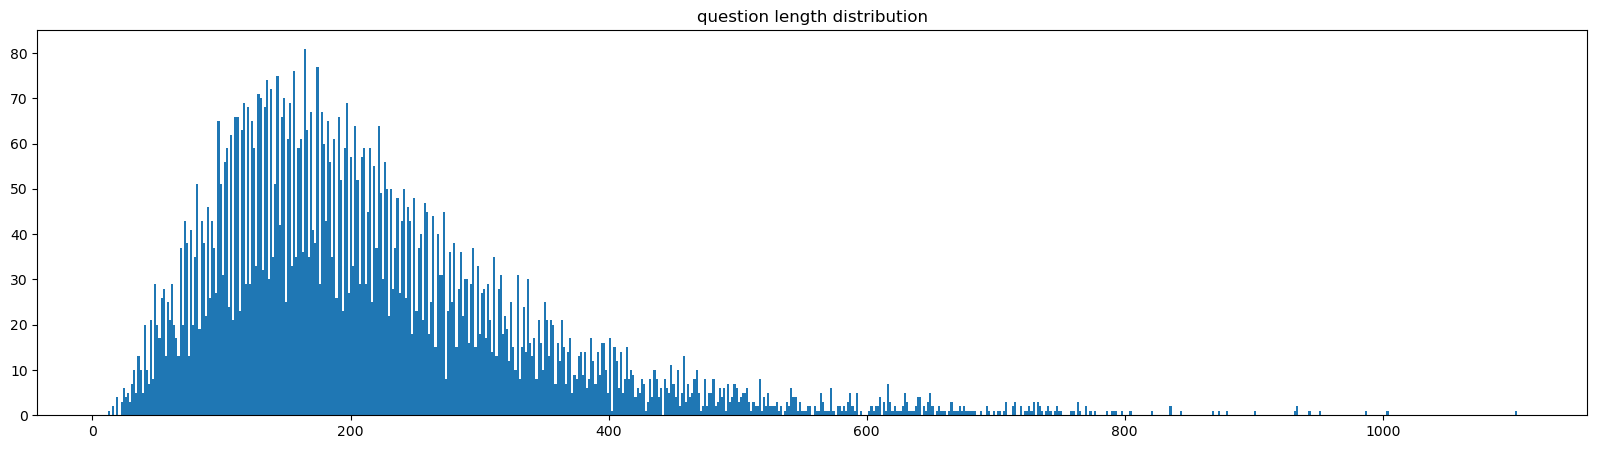

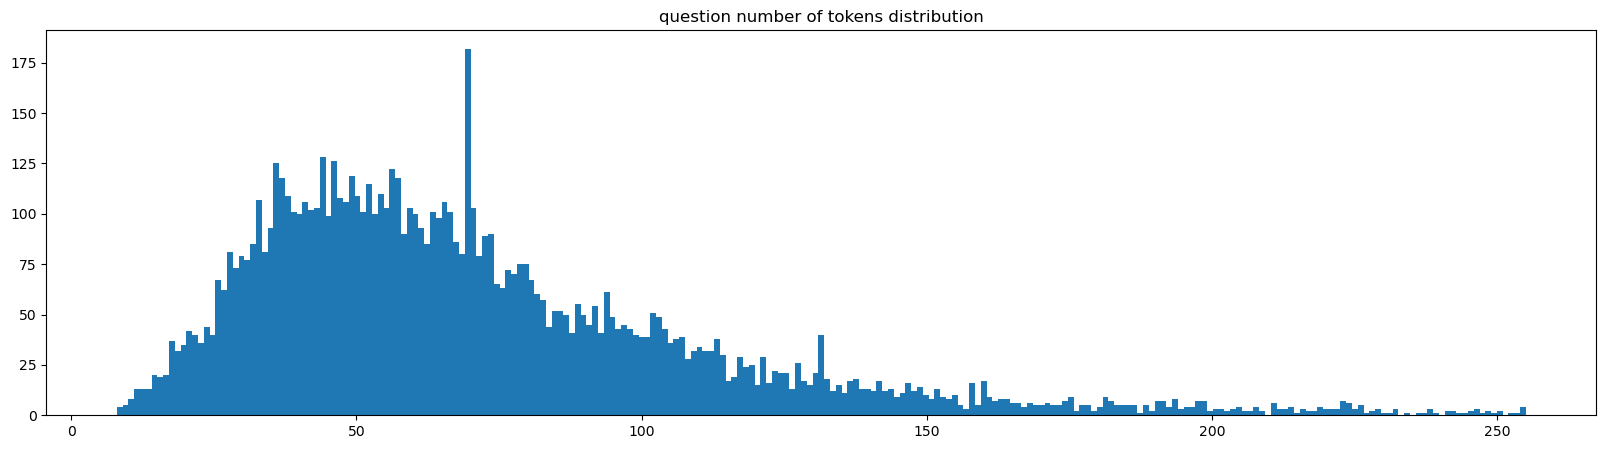

There is 8211 unique question.


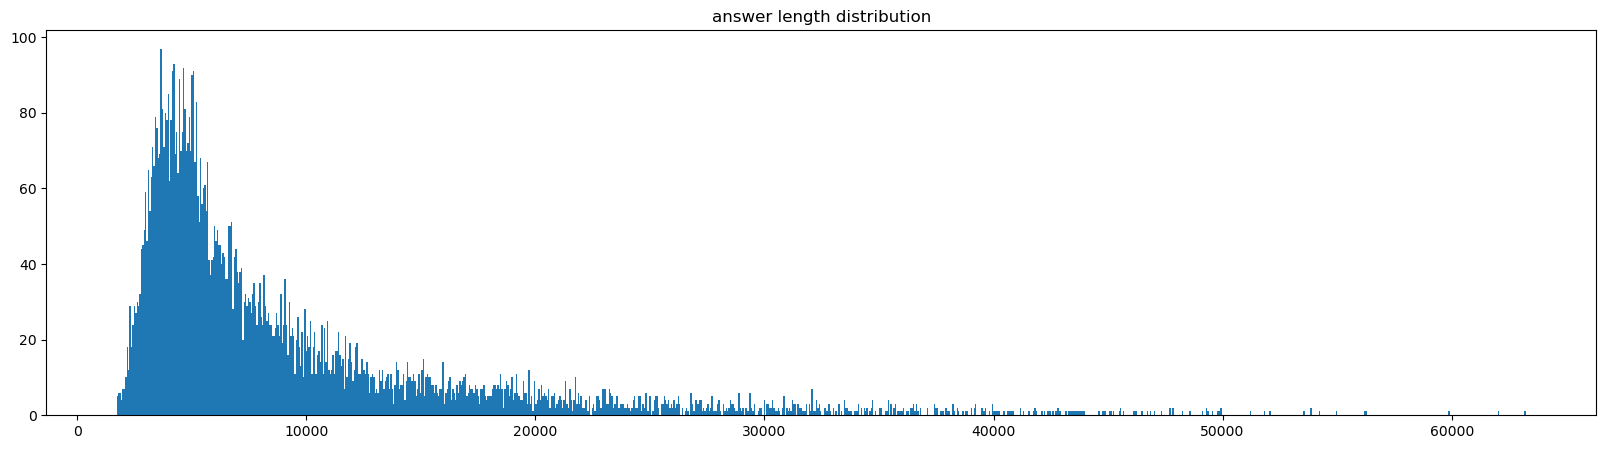

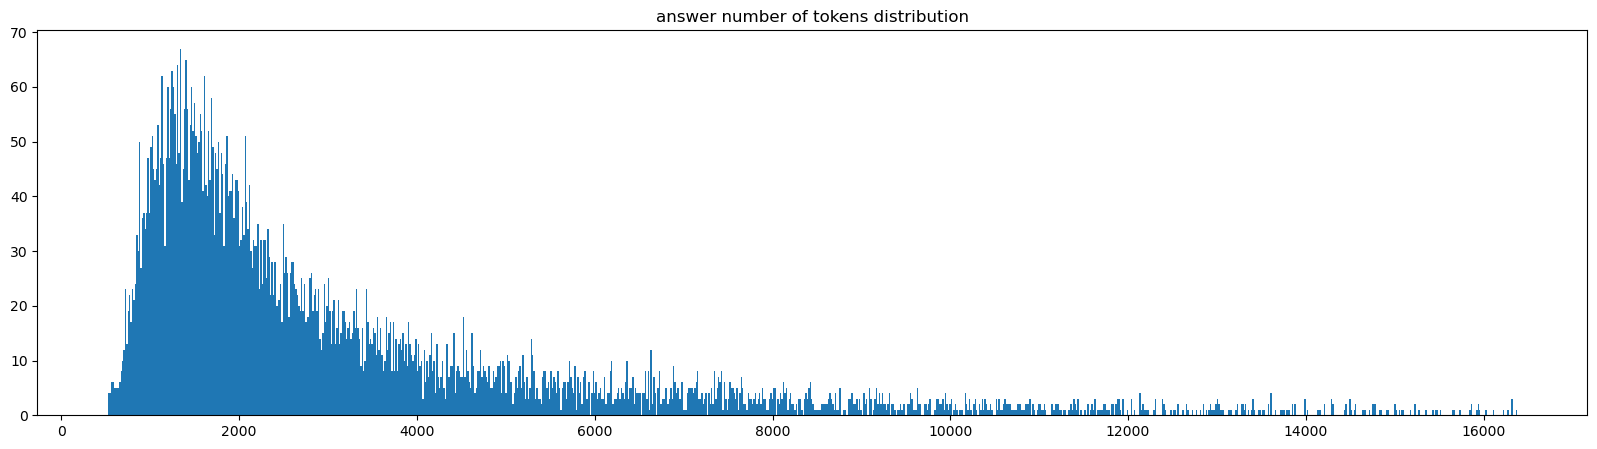

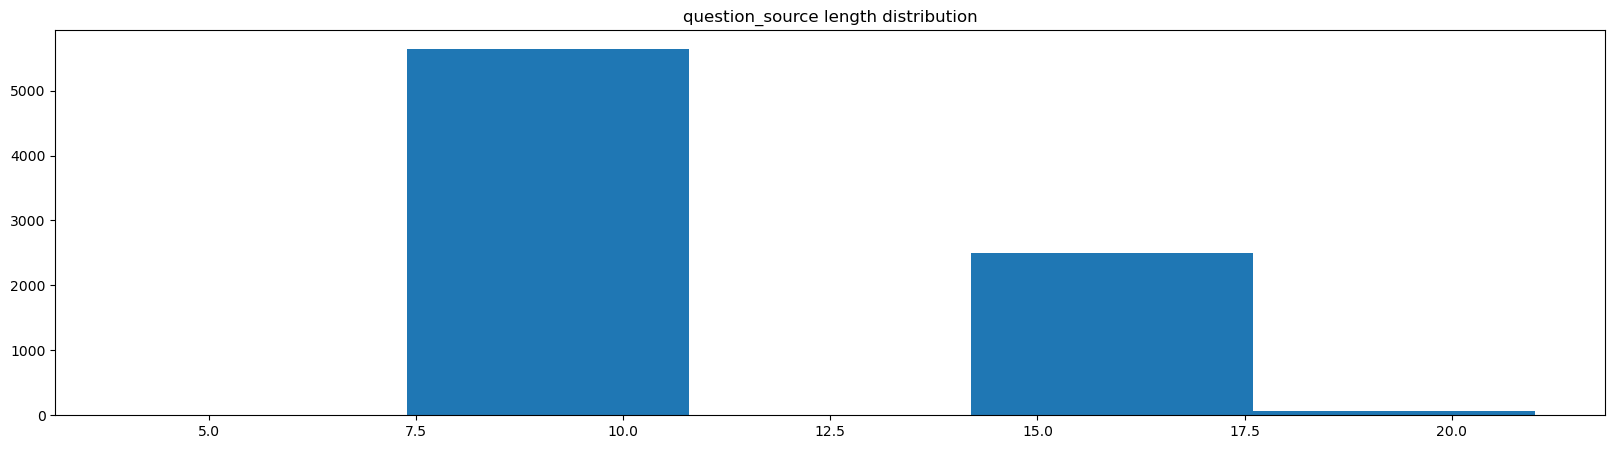

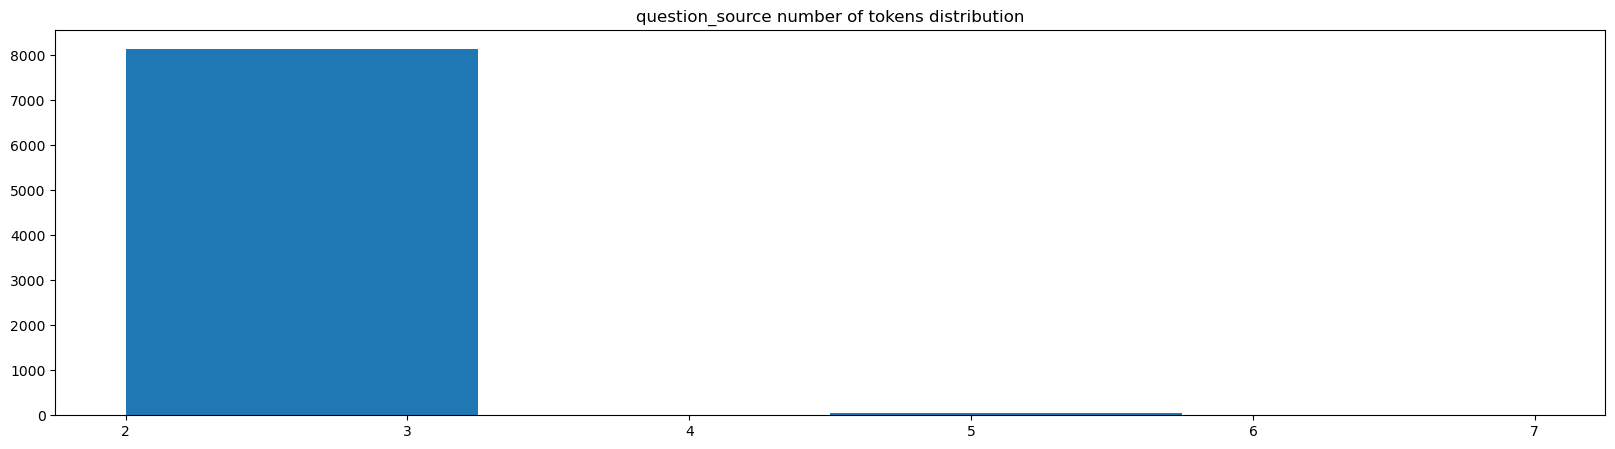

There is 6 unique question_source.


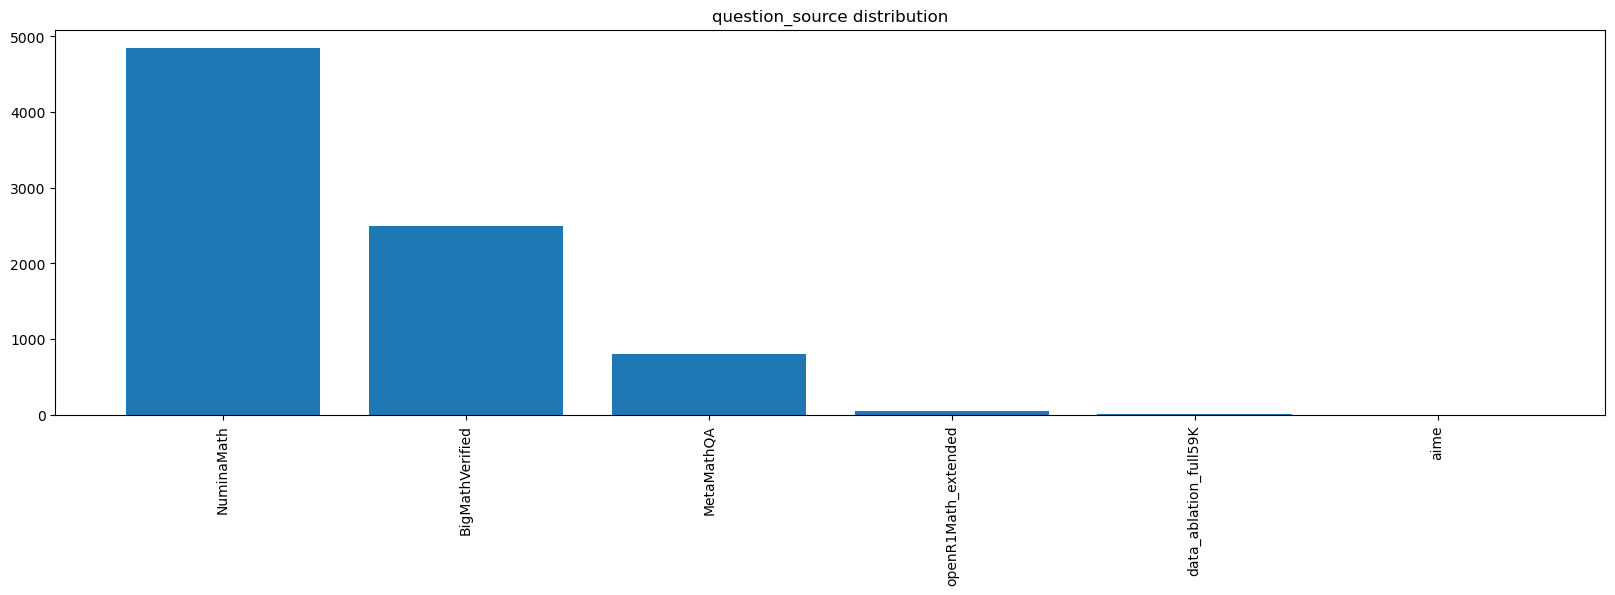

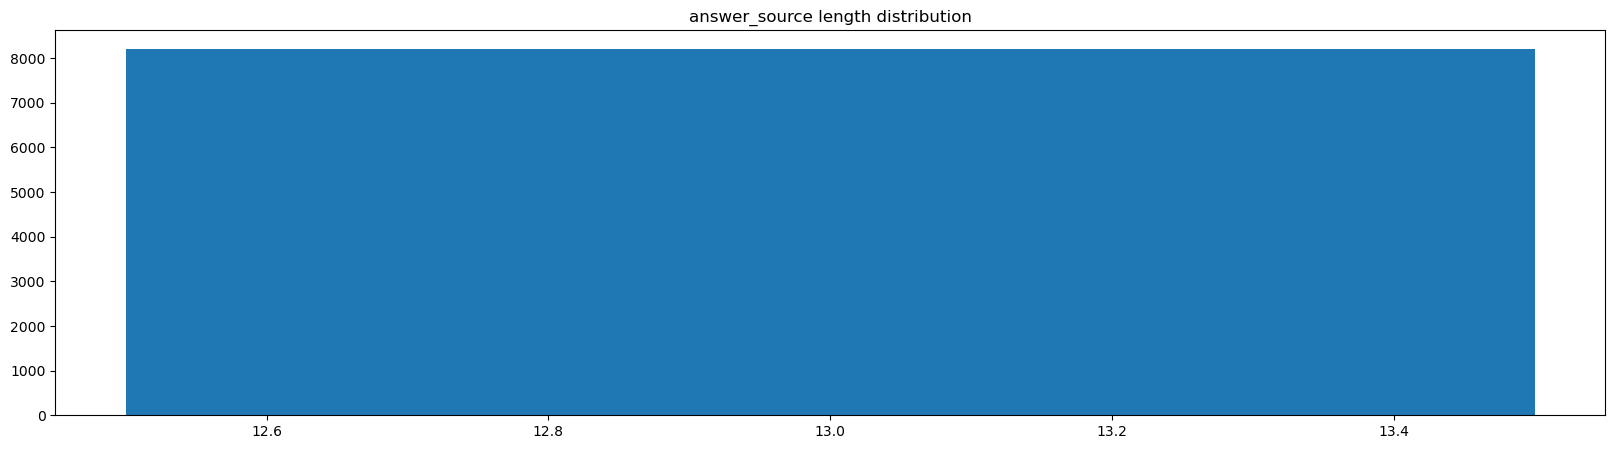

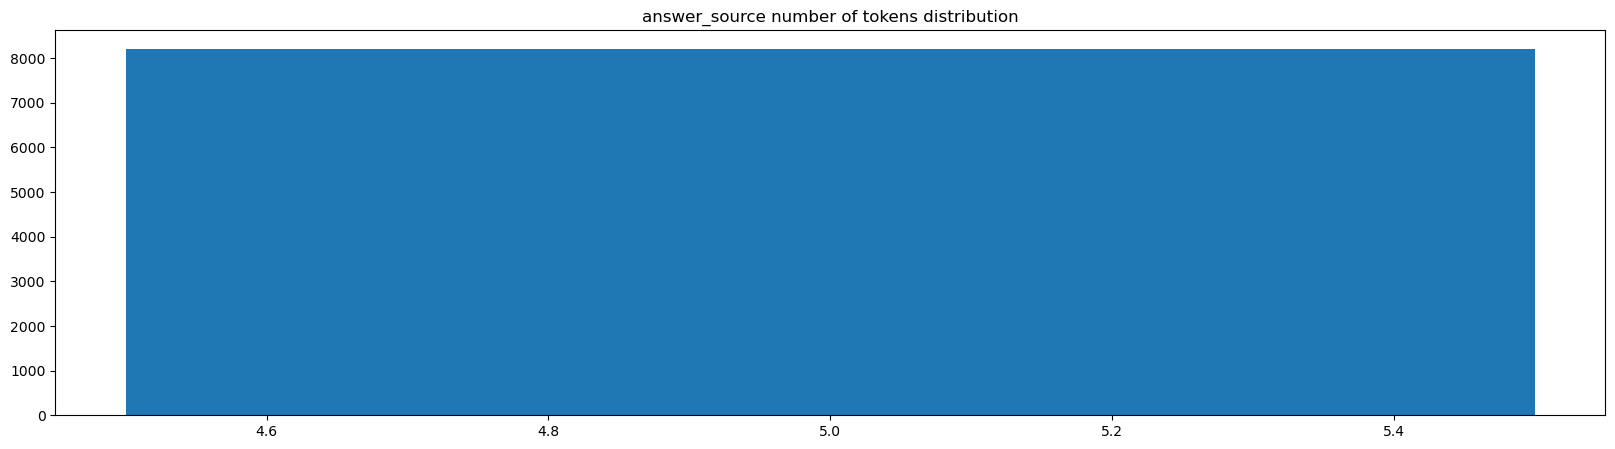

There is 1 unique answer_source.


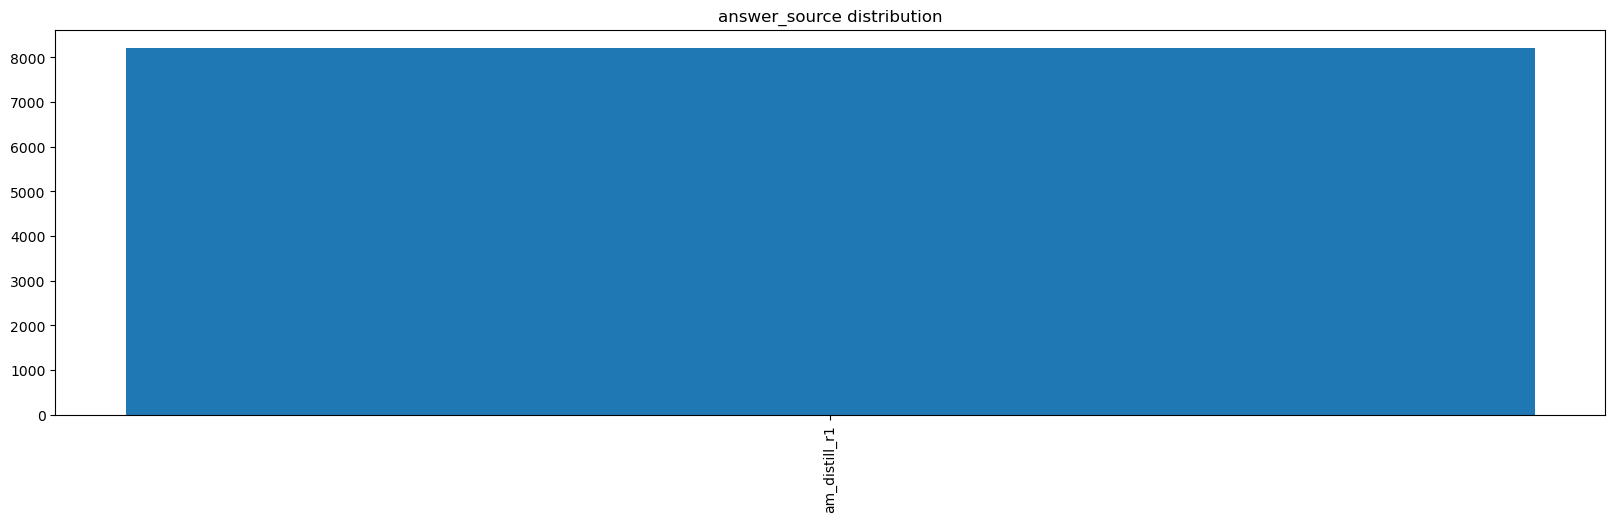

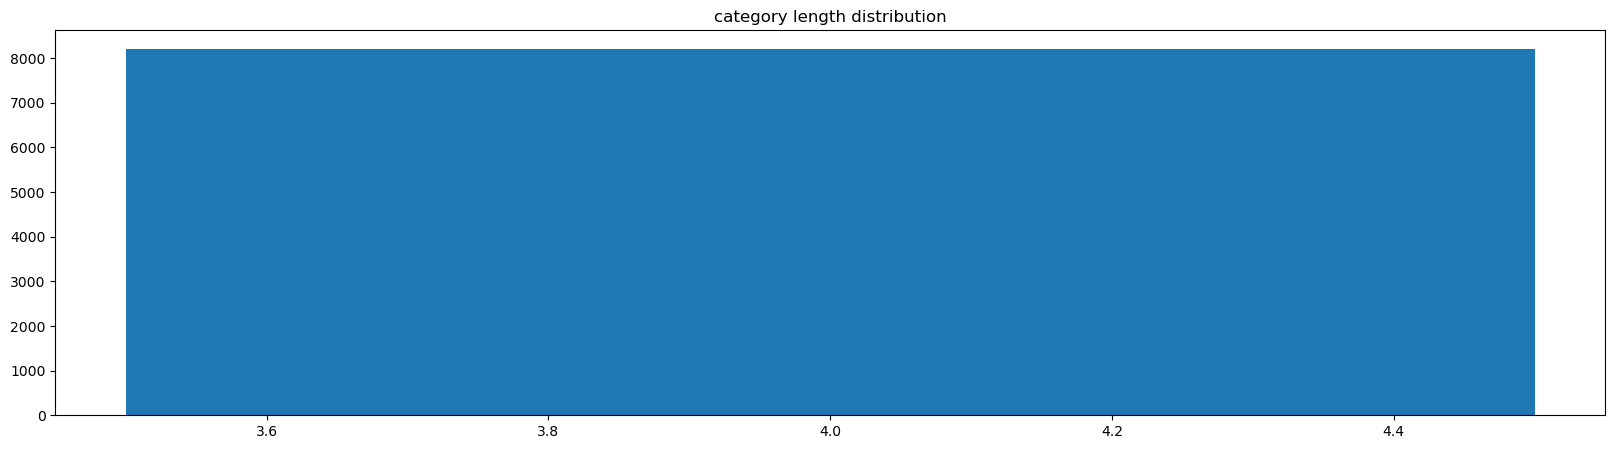

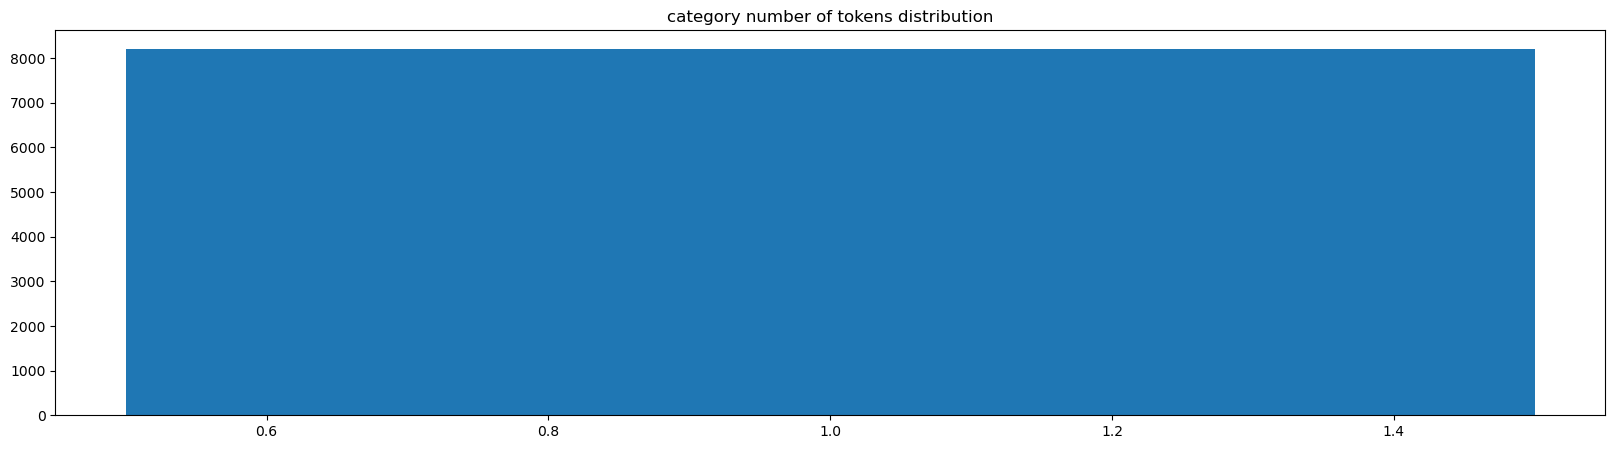

There is 1 unique category.


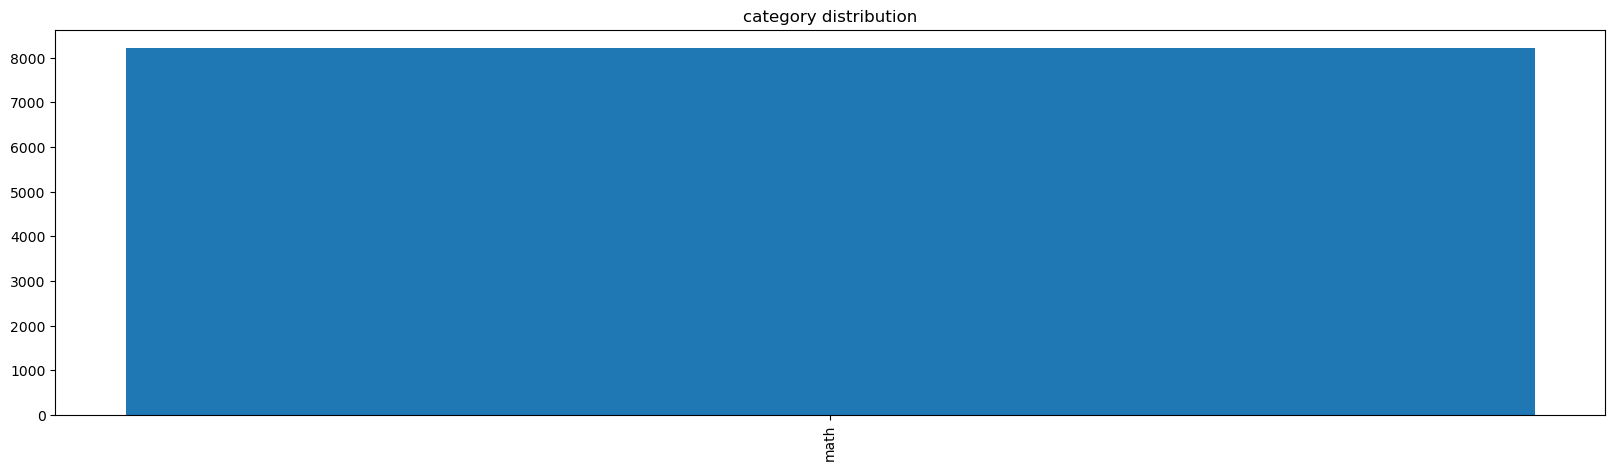

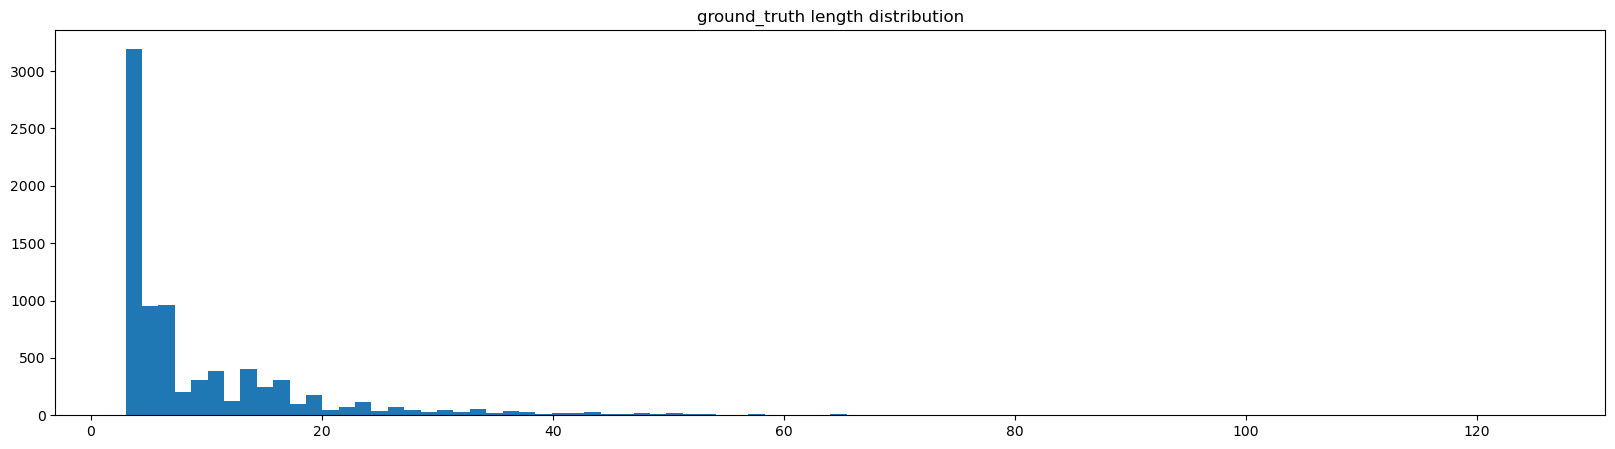

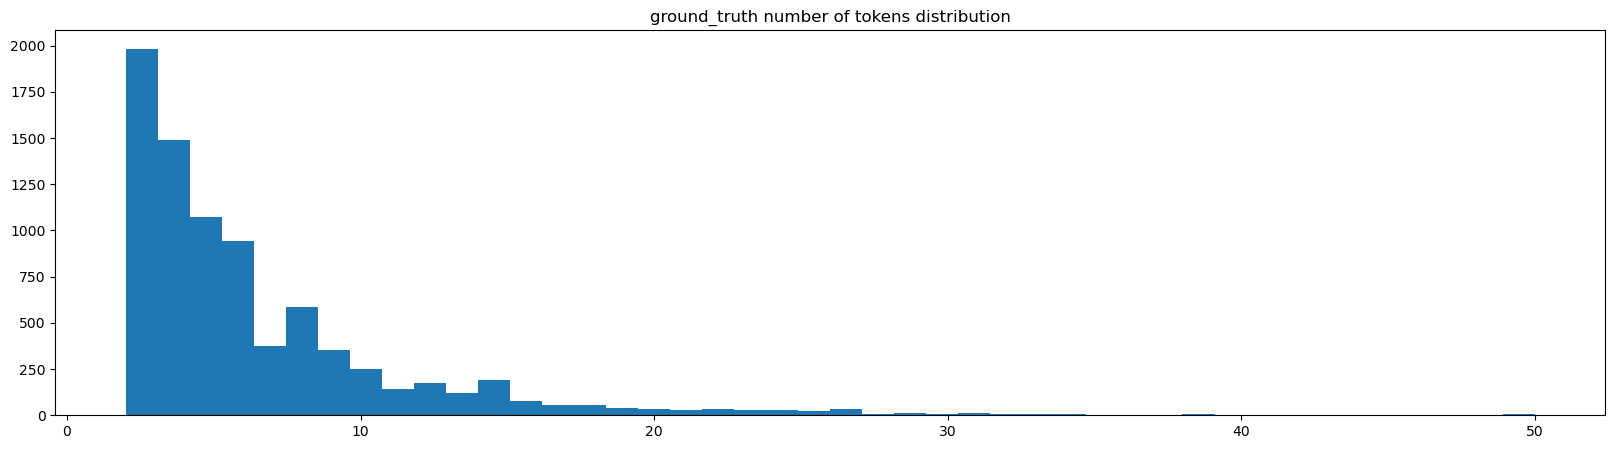

There is 3620 unique ground_truth.
Number of 'None' test_case: 8211
Number of 'None' instruction_constrain: 8211


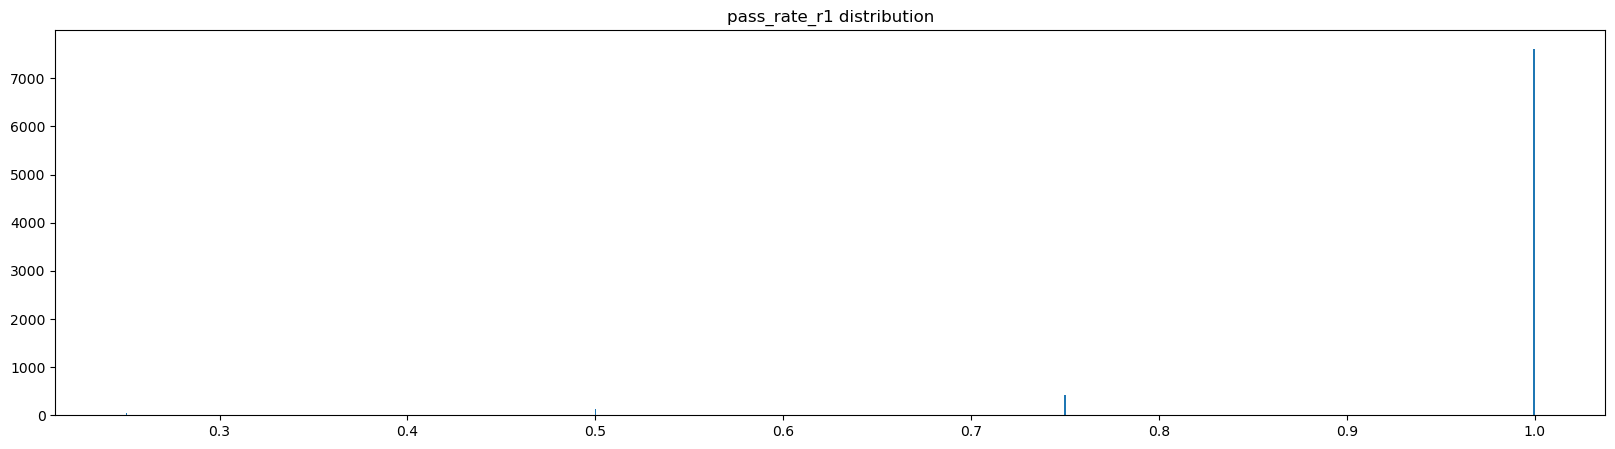

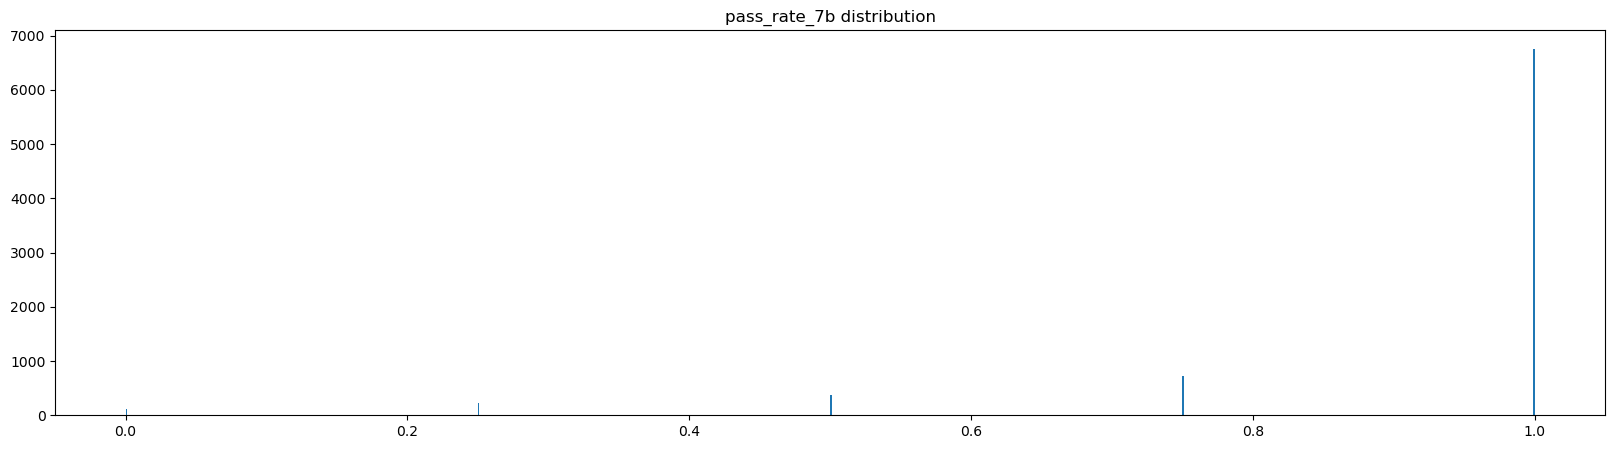

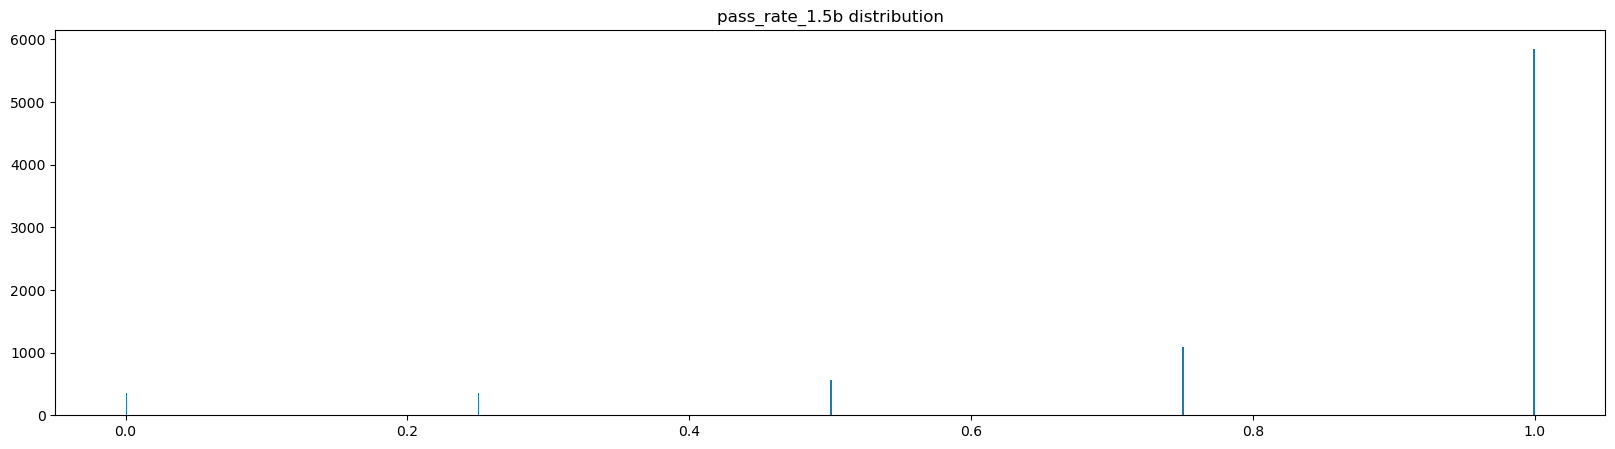

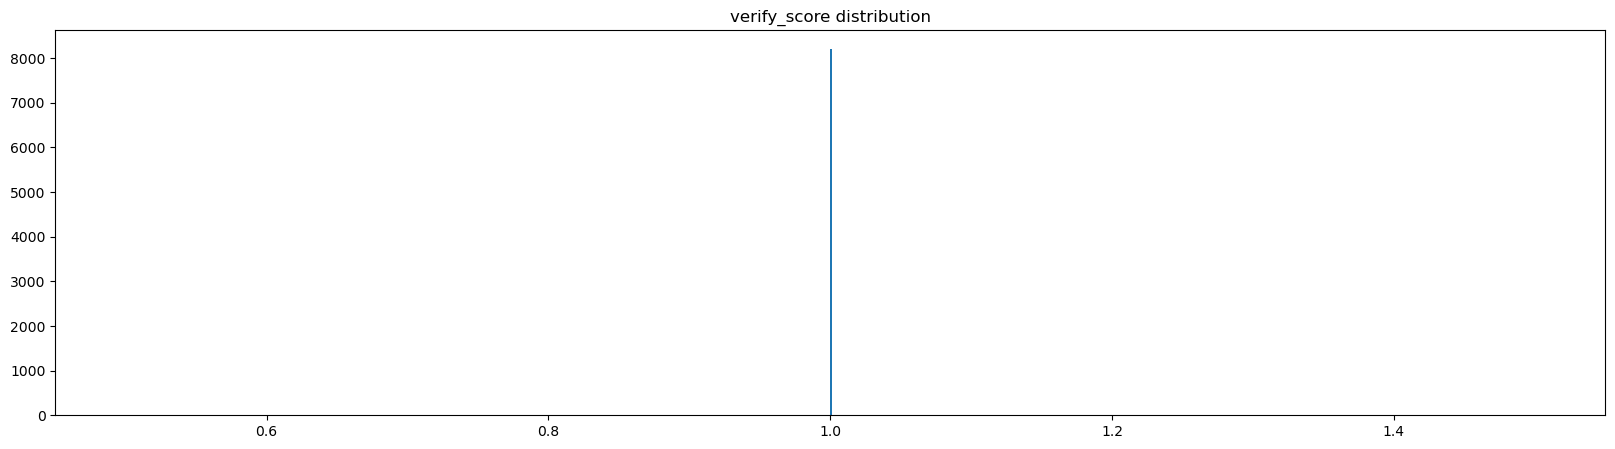

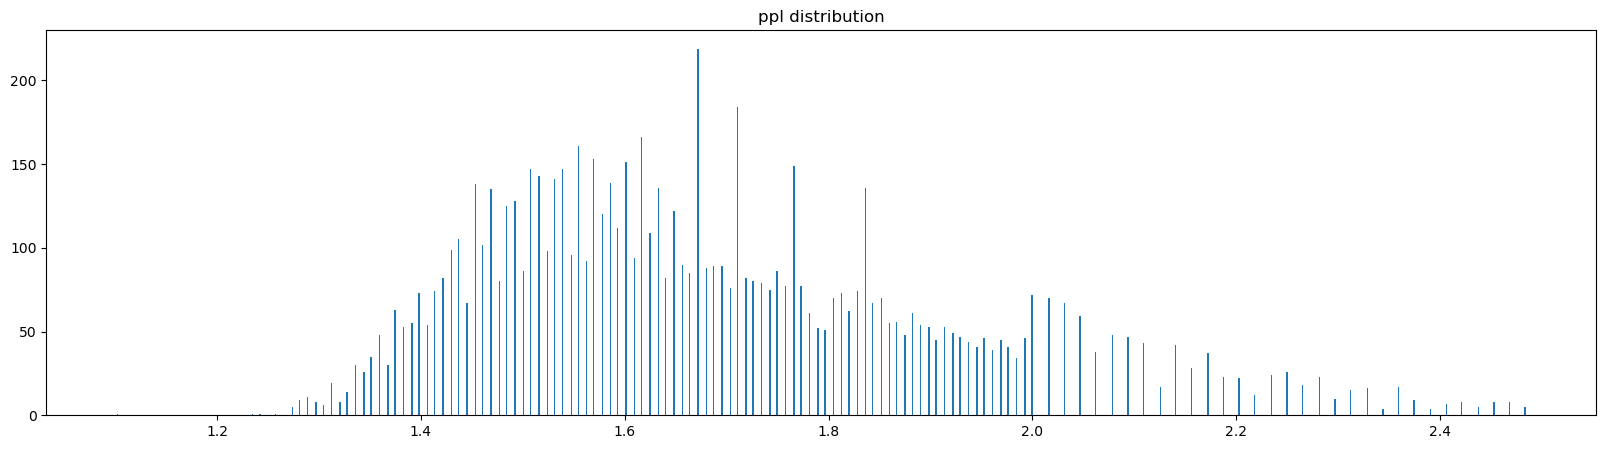

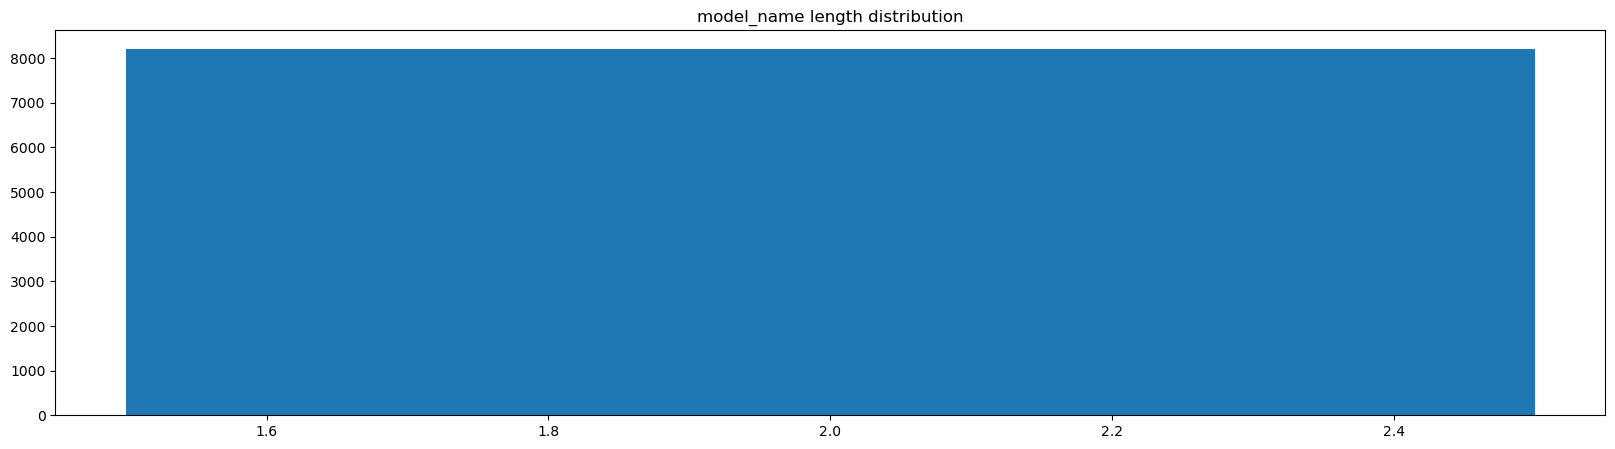

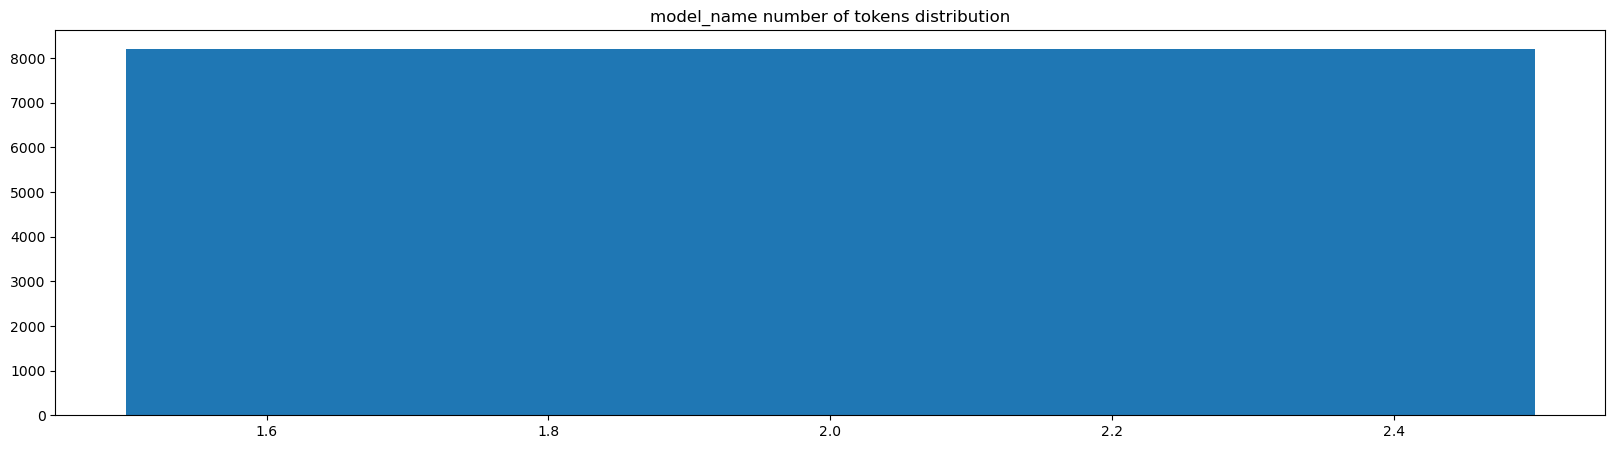

There is 1 unique model_name.


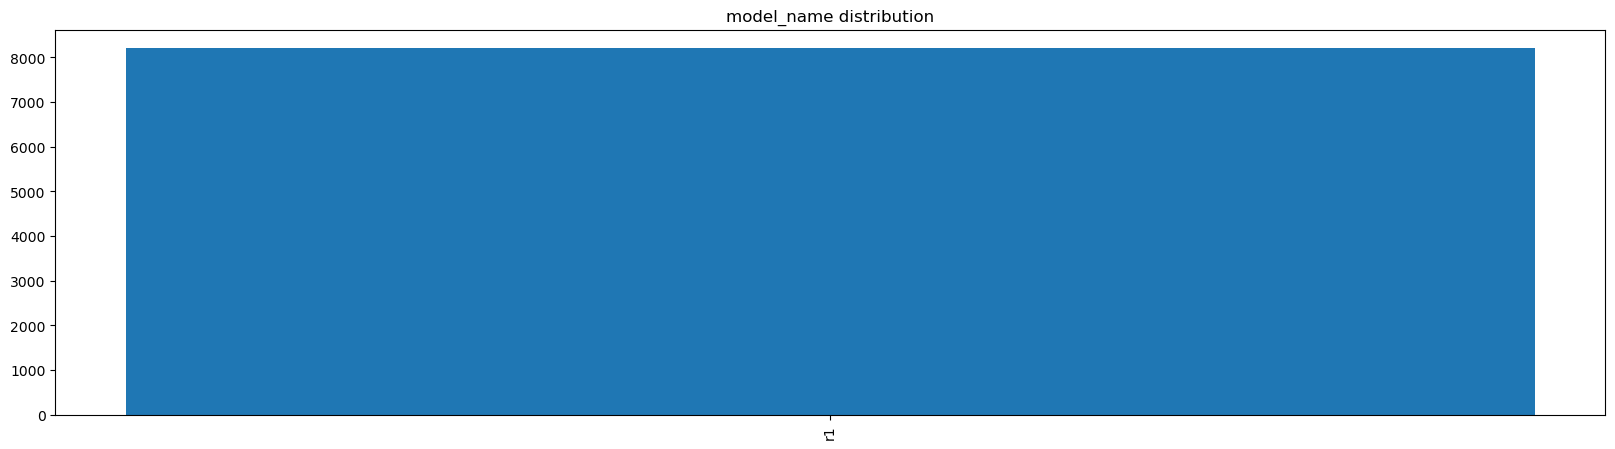

In [2]:
am_deepseek_distill = load_data("AM-DeepSeek-Distilled-40M").select(range(10000))
am_deepseek_distill = filter_am_deepseek_distill(am_deepseek_distill)
print_distributions(am_deepseek_distill, ['question', 'answer', 'question_source', 'answer_source', 'category', 'ground_truth', 'test_case', 'instruction_constrain', 'pass_rate_r1', 'pass_rate_7b', 'pass_rate_1.5b', 'verify_score', 'ppl', 'model_name'])

### BigMath

Filtered 11.79% of the dataset
Features: ['problem', 'answer', 'source', 'domain', 'llama8b_solve_rate']
Number of samples: 8821
Sample: {
    "answer": "26",
    "domain": [
        "Mathematics -> Algebra -> Algebraic Expressions"
    ],
    "llama8b_solve_rate": 0.203125,
    "problem": "Simplify and find the value of $(3x^{2}y-2xy^{2})-(xy^{2}-2x^{2}y)-2(-3x^{2}y-xy^{2})$, where $x=-1$ and $y=2$.",
    "source": "cn_k12"
}


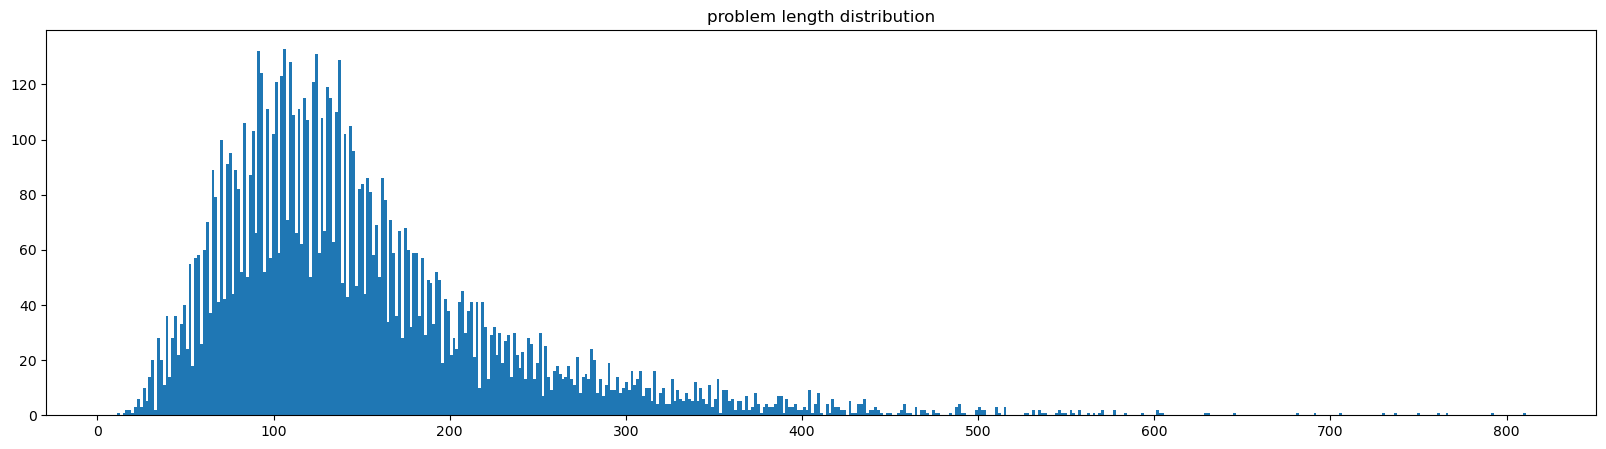

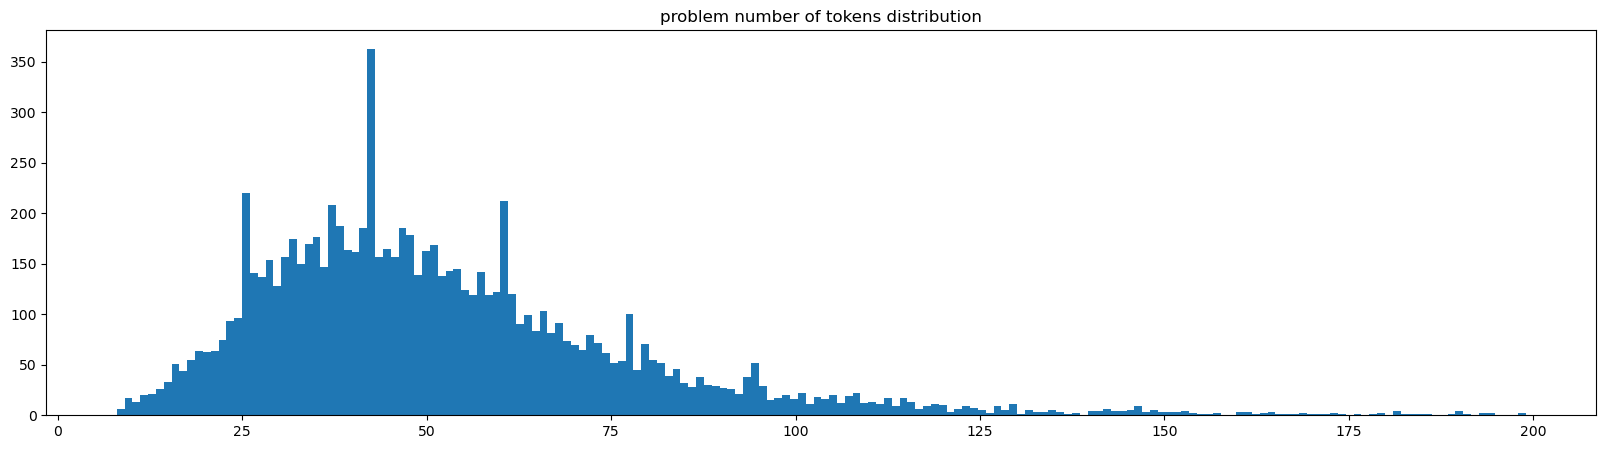

There is 8821 unique problem.


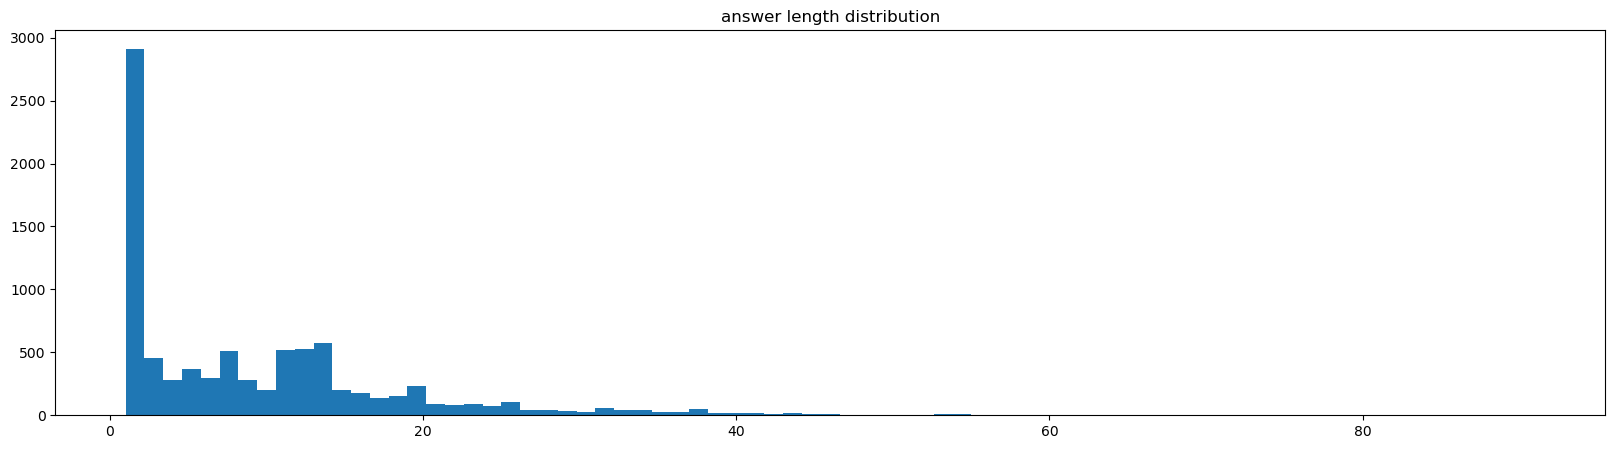

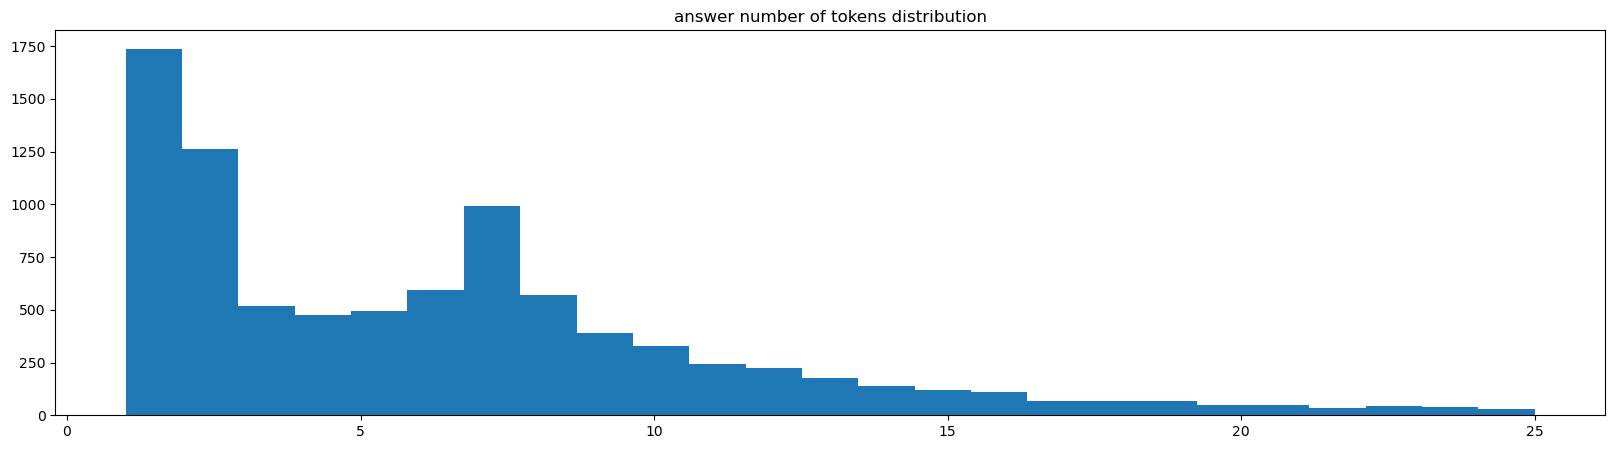

There is 4320 unique answer.


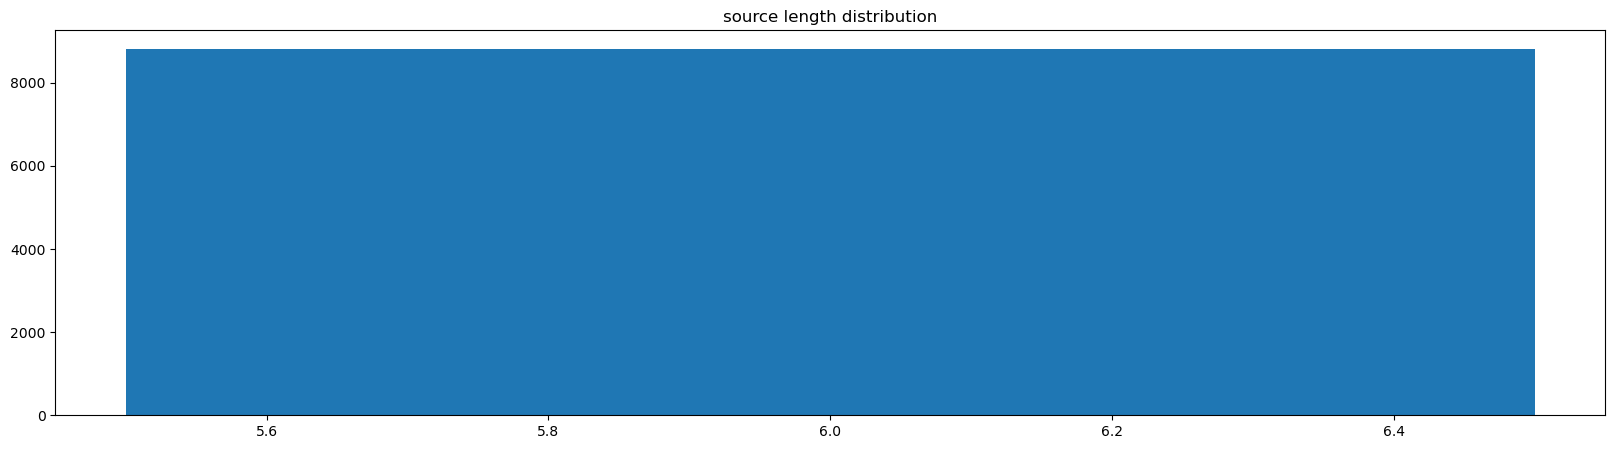

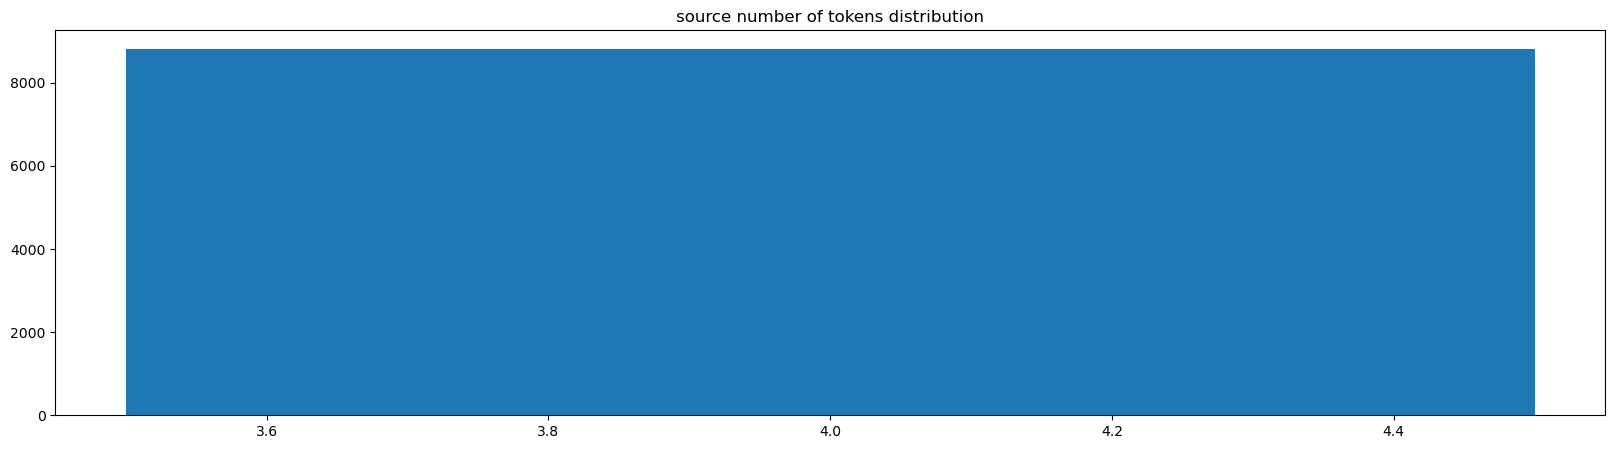

There is 1 unique source.


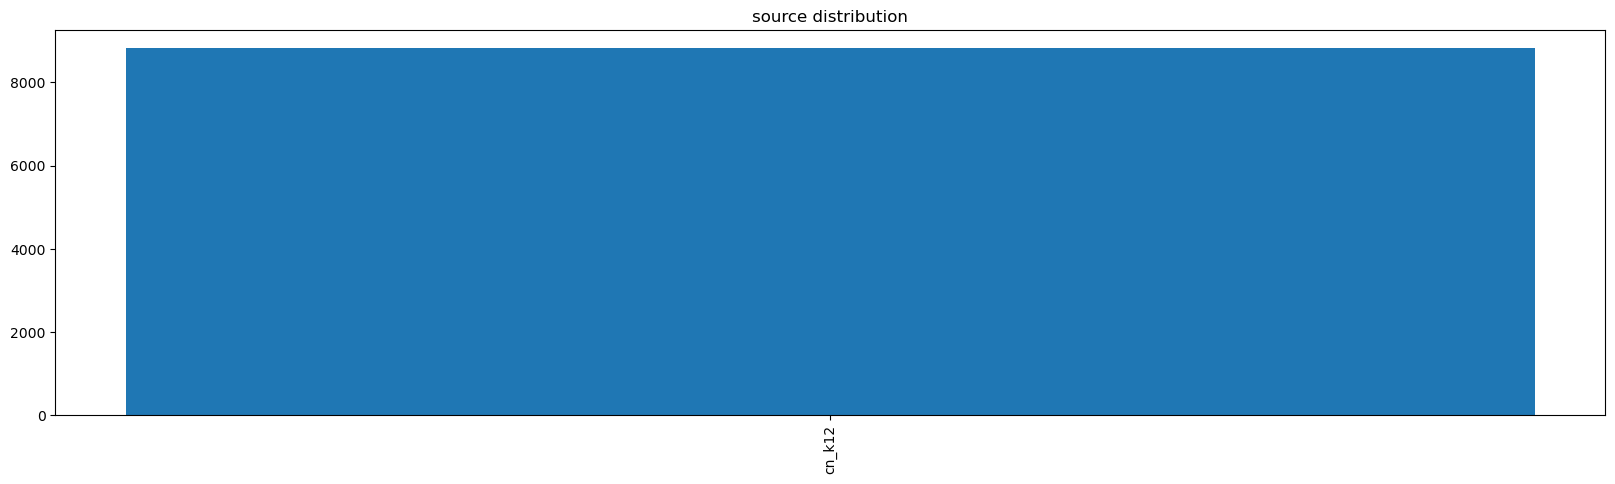

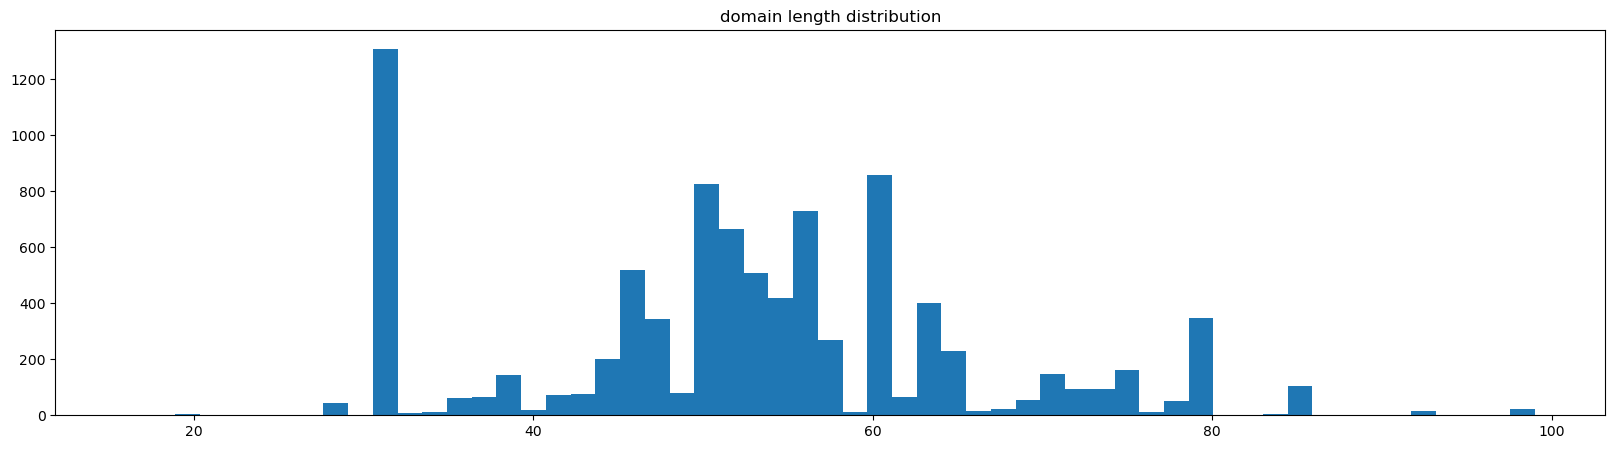

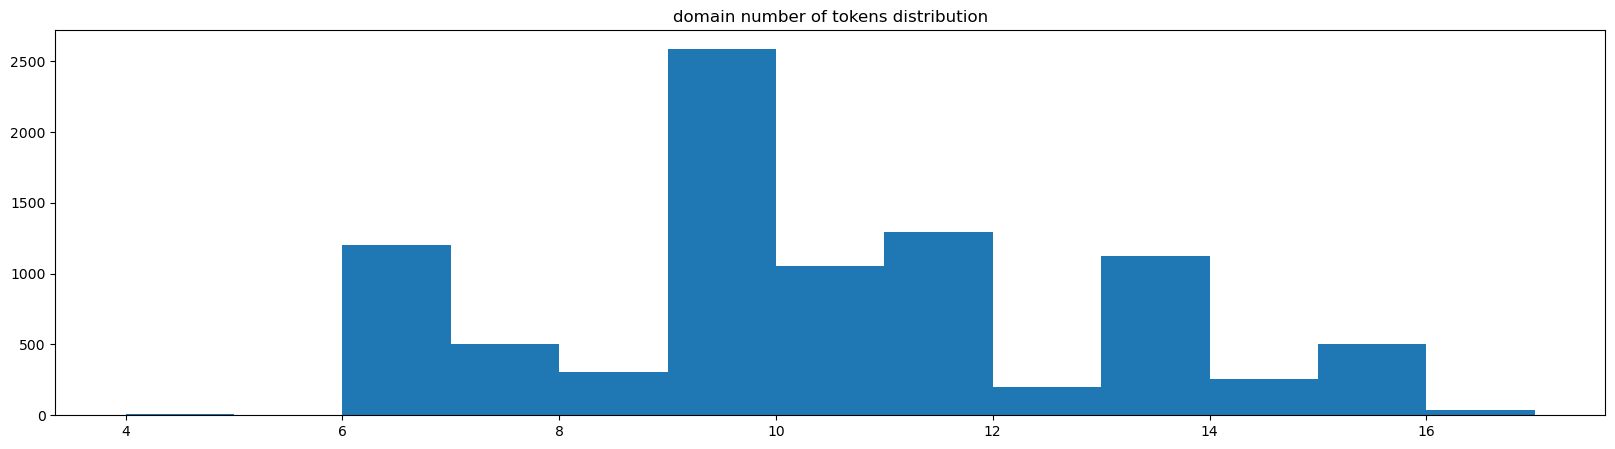

There is 208 unique domain.


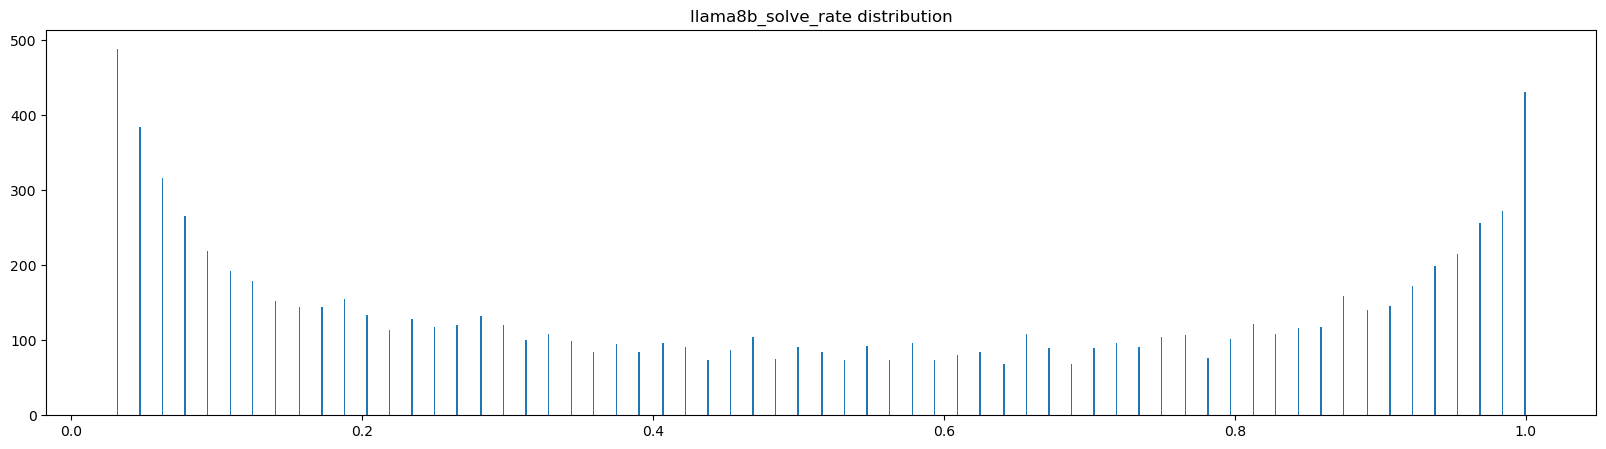

In [3]:
big_math = load_data("Big-Math-RL-Verified").select(range(10000))
big_math = filter_big_math(big_math)
print_distributions(big_math, ['problem', 'answer', 'source', 'domain', 'llama8b_solve_rate'])

### LIMO

Filtered 3.0599755201958385% of the dataset
Features: ['question', 'solution', 'answer']
Number of samples: 792
Sample: {
    "answer": "850",
    "question": "Let $P(x) = x^2 - 3x - 9$ . A real number $x$ is chosen at random from the interval $5 \\le x \\le 15$ . The probability that $\\left\\lfloor\\sqrt{P(x)}\\right\\rfloor = \\sqrt{P(\\lfloor x \\rfloor)}$ is equal to $\\frac{\\sqrt{a} + \\sqrt{b} + \\sqrt{c} - d}{e}$ , where $a$ , $b$ , $c$ , $d$ , and $e$ are positive integers. Find $a + b + c + d + e$ .",
    "solution": "Okay, so I've got this problem here that I need to solve. Let me take a deep breath and try to unpack it step by step. \n\nThe problem is about probability and functions. It says:\n\nLet \\( P(x) = x^2 - 3x - 9 \\). A real number \\( x \\) is chosen at random from the interval \\( 5 \\leq x \\leq 15 \\). We need to find the probability that \\( \\left\\lfloor \\sqrt{P(x)} \\right\\rfloor = \\sqrt{P(\\lfloor x \\rfloor)} \\). They mention that this probability c

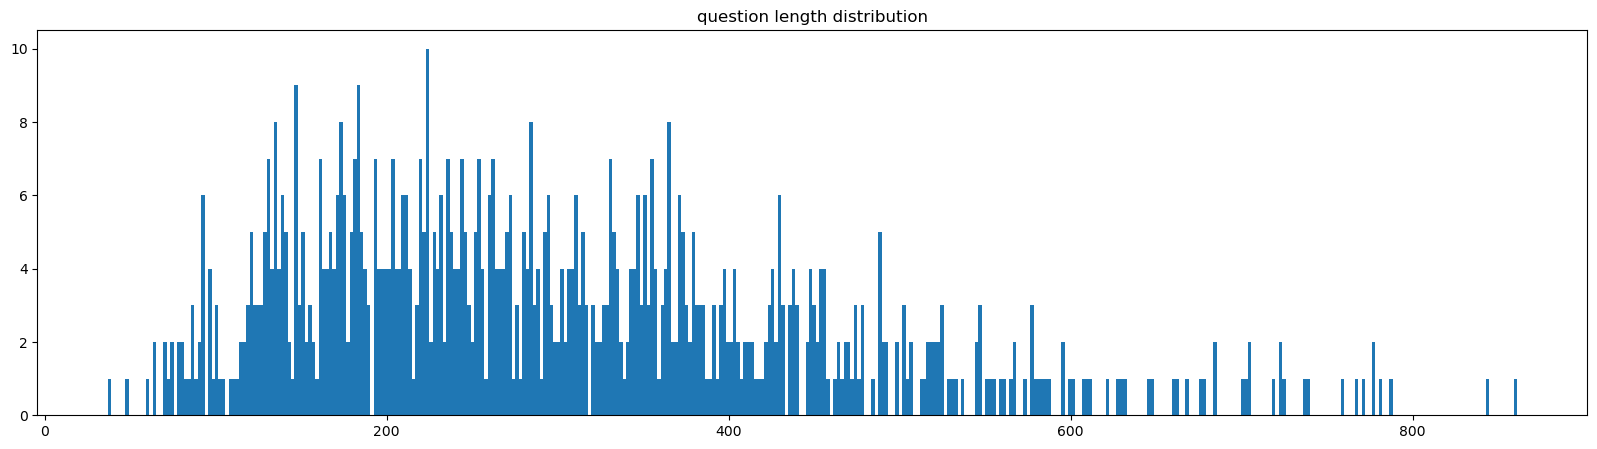

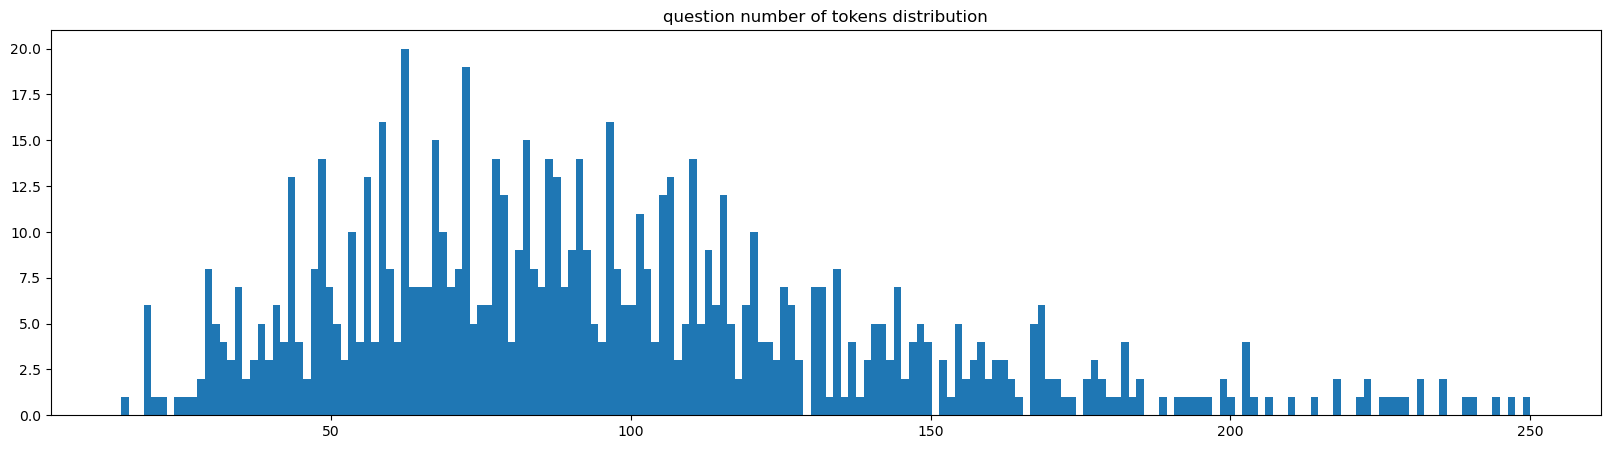

There is 792 unique question.


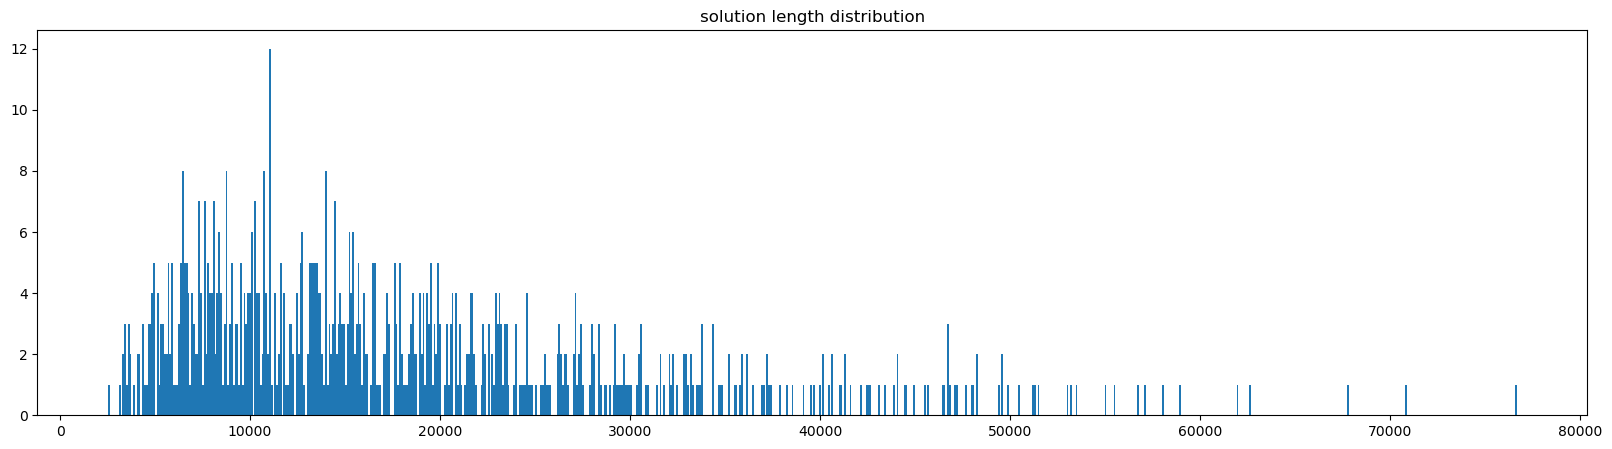

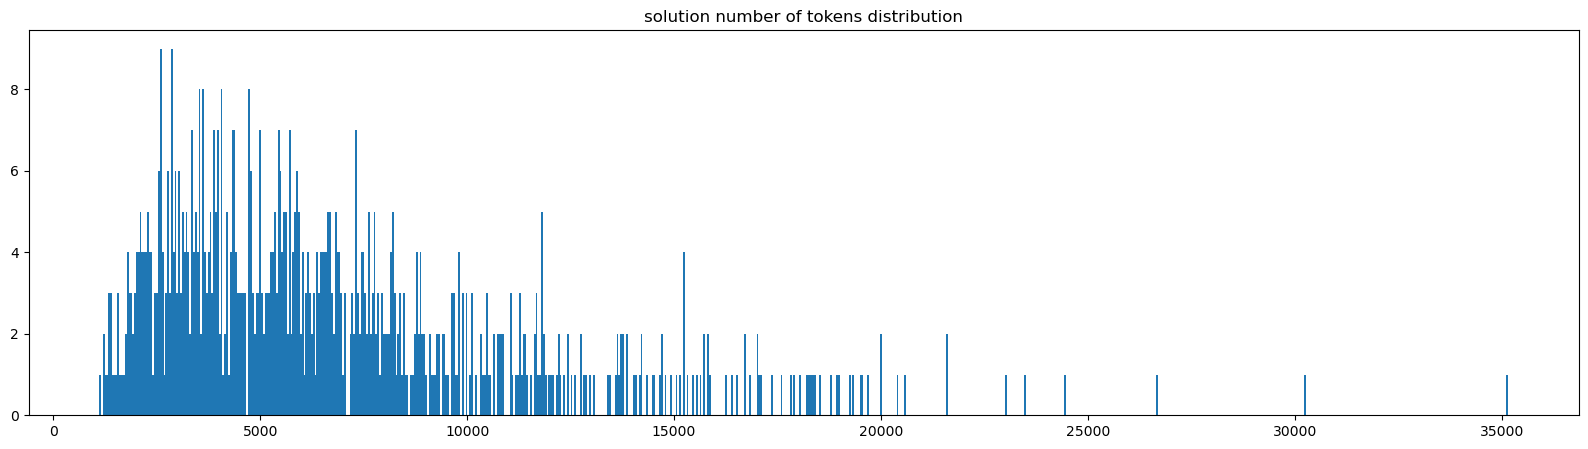

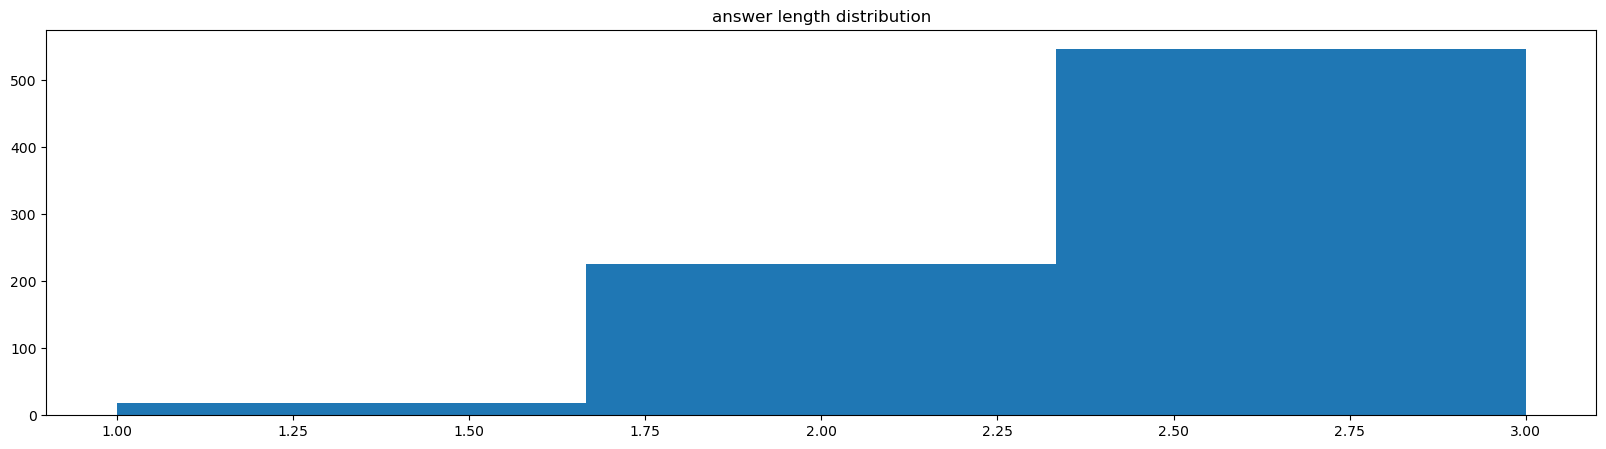

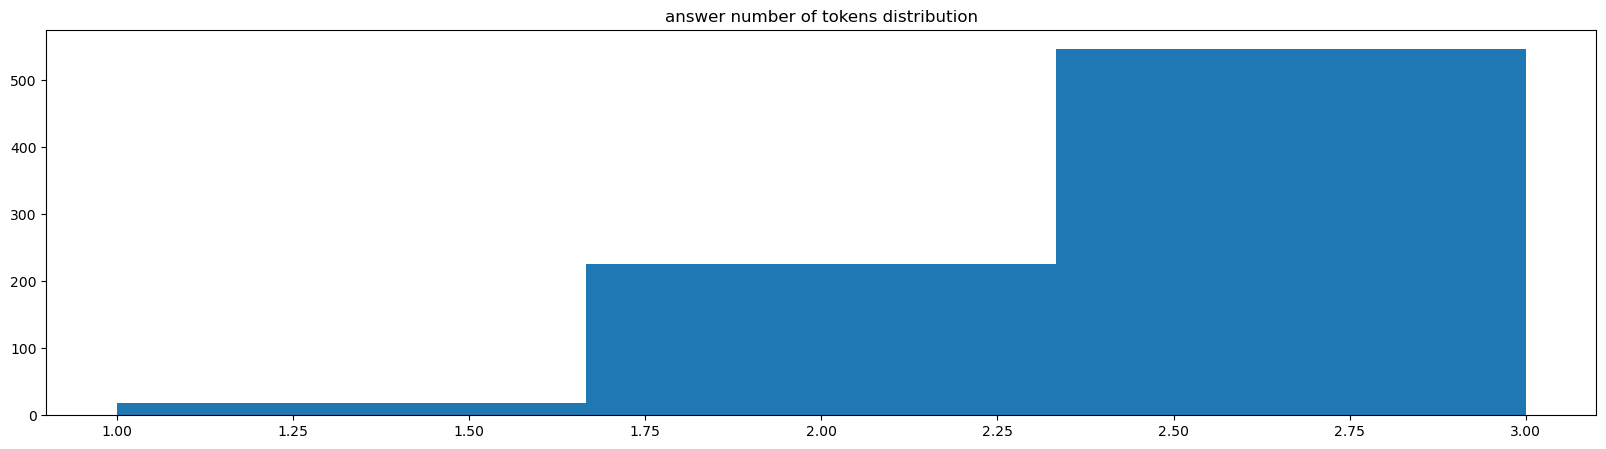

There is 454 unique answer.


In [4]:
limo = load_data("LIMO")
limo = filter_limo(limo)
print_distributions(limo, ['question', 'solution', 'answer'])

### LIMR

Filter: 100%|██████████| 1370/1370 [00:00<00:00, 12690.03 examples/s]


Filtered 1.7278617710583153% of the dataset
Features: ['id', 'prompt', 'answer', 'source']
Number of samples: 1365
Sample: {
    "answer": "6",
    "id": "3a4106df-1d76-445a-9809-2881a6b7881d",
    "prompt": "Let $S$ denote the value of the sum\\[\\sum_{n=0}^{668} (-1)^{n} {2004 \\choose 3n}\\]Determine the remainder obtained when $S$ is divided by $1000$.",
    "source": "math"
}


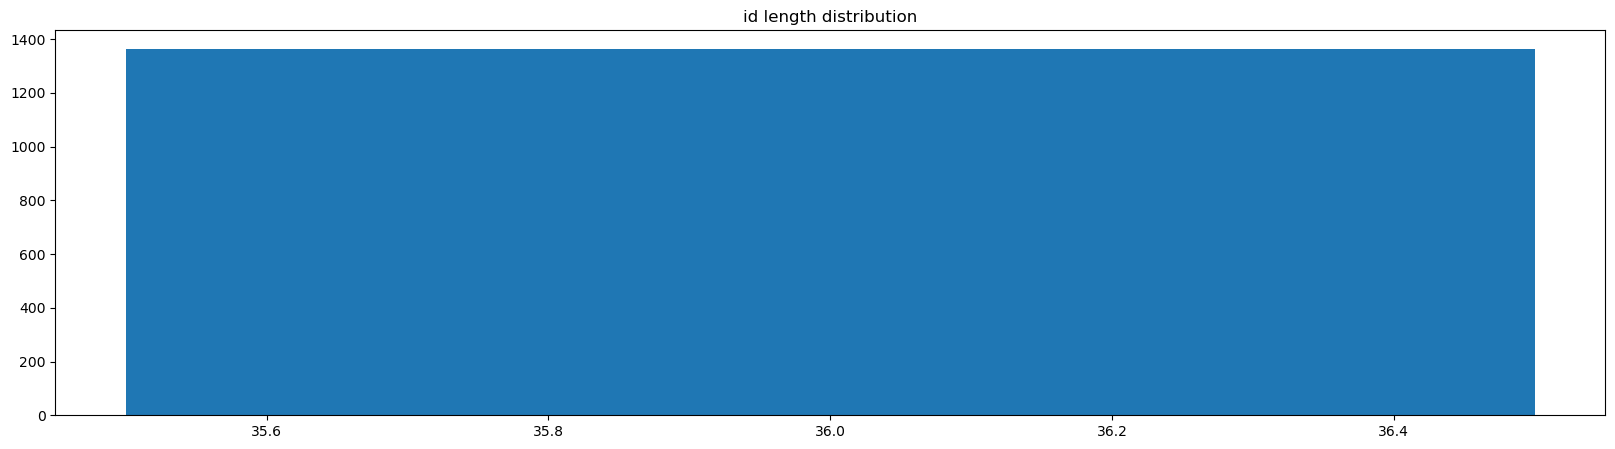

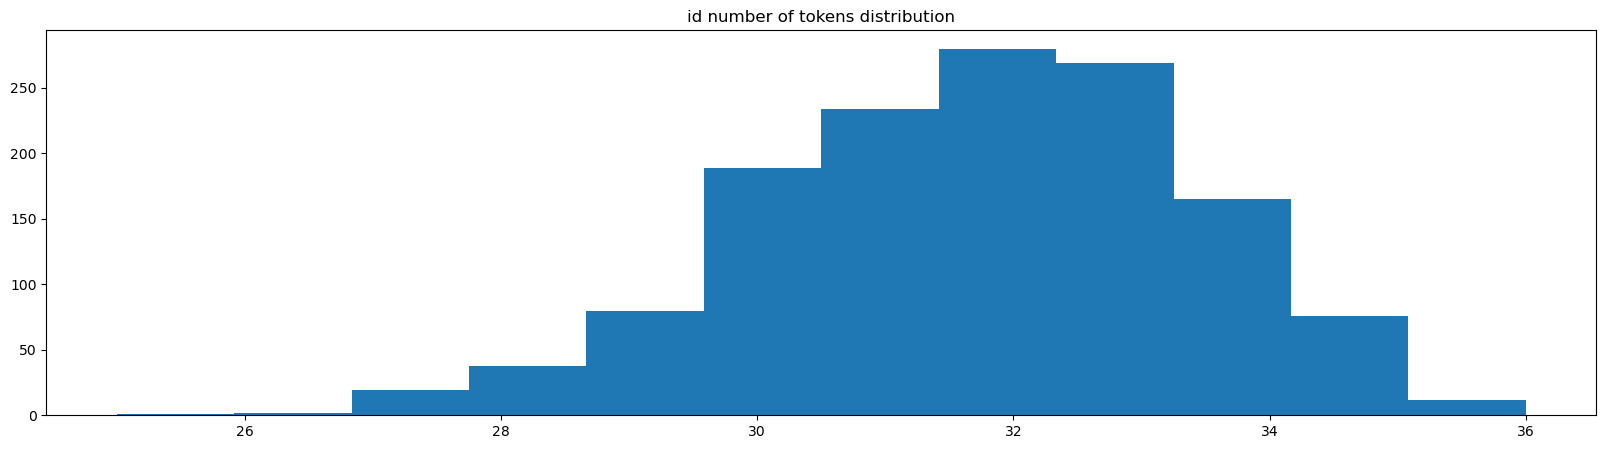

There is 1365 unique id.


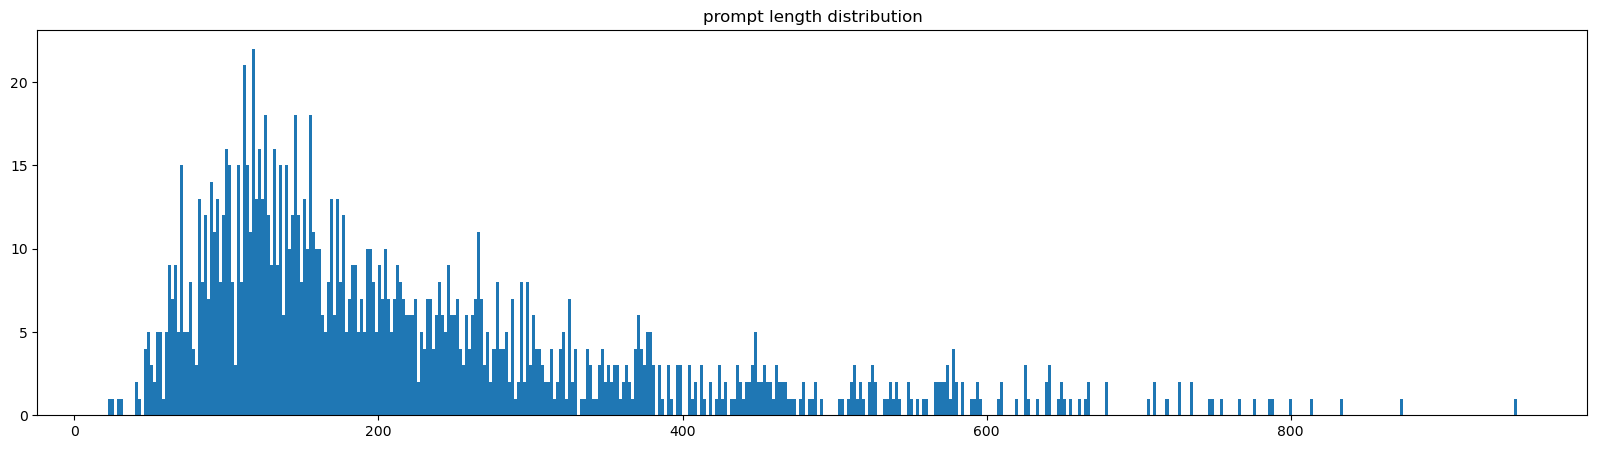

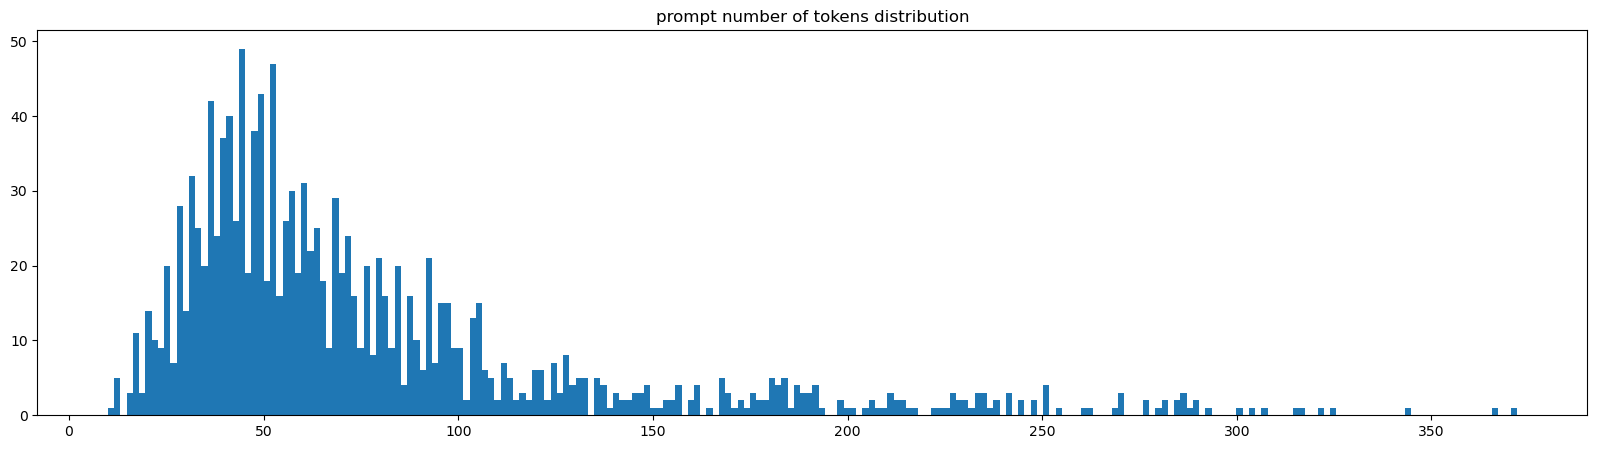

There is 1365 unique prompt.


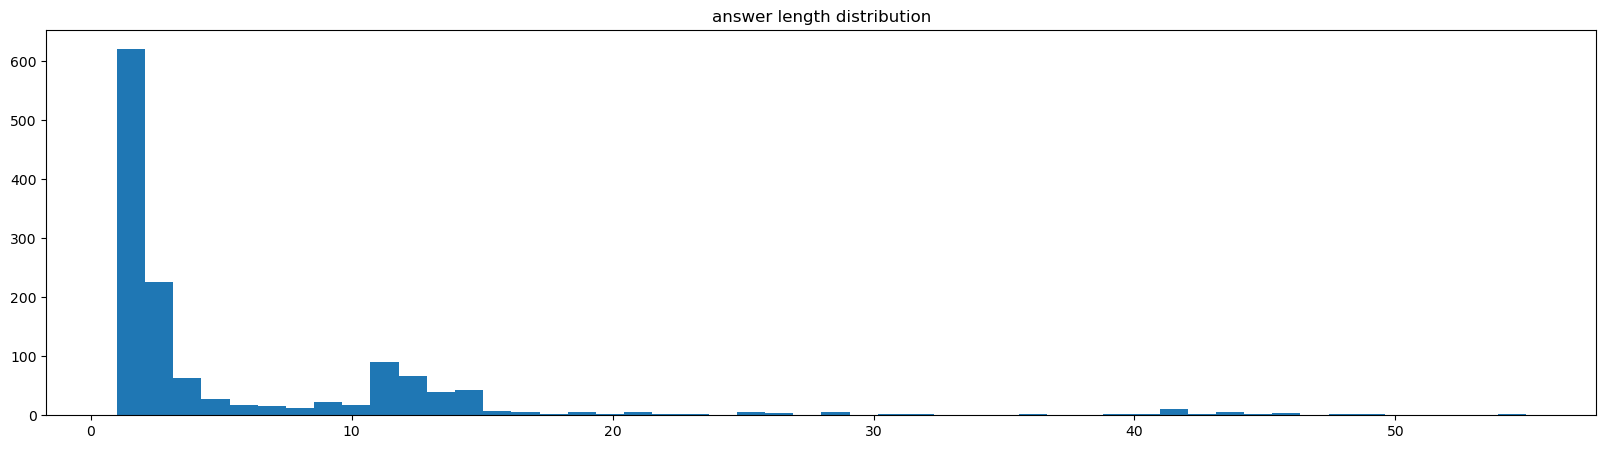

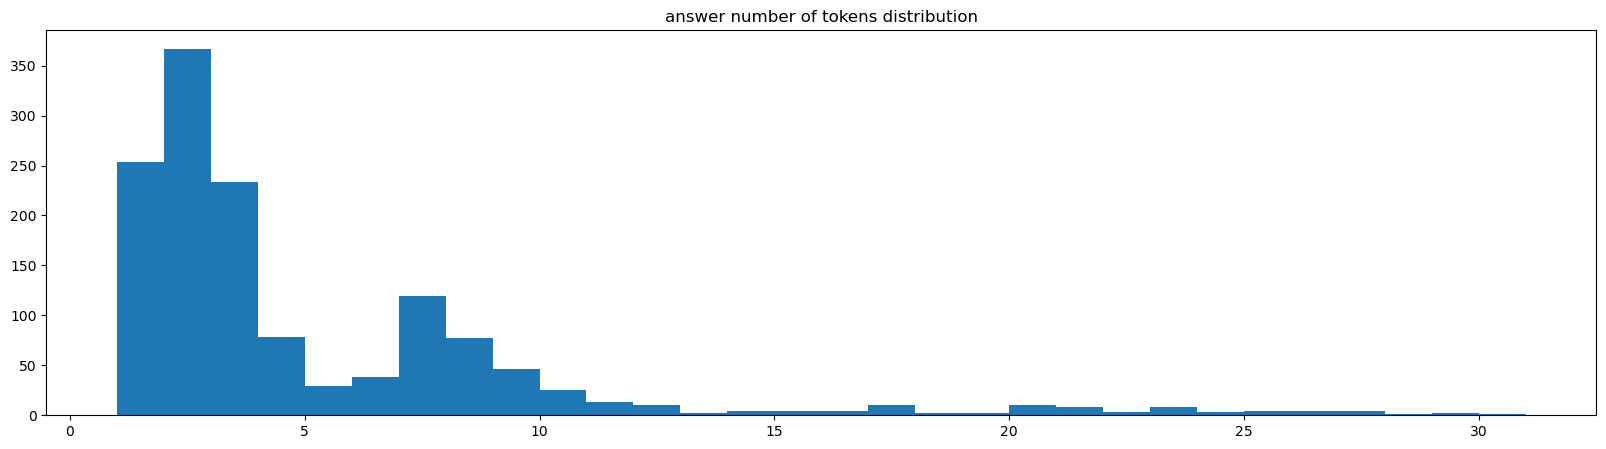

There is 716 unique answer.


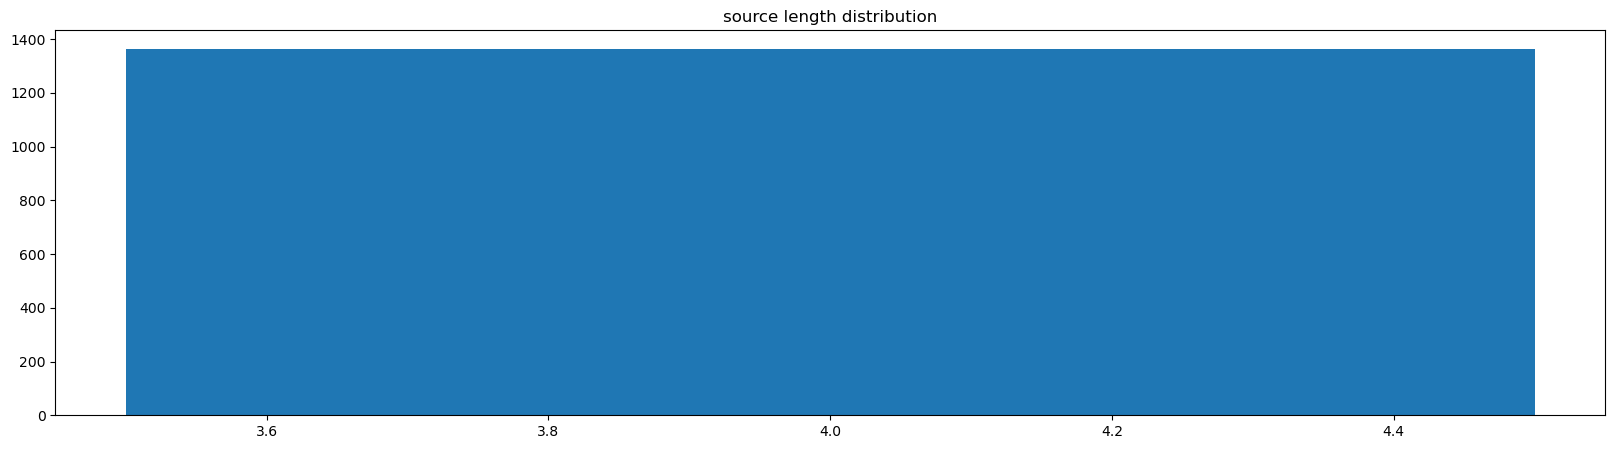

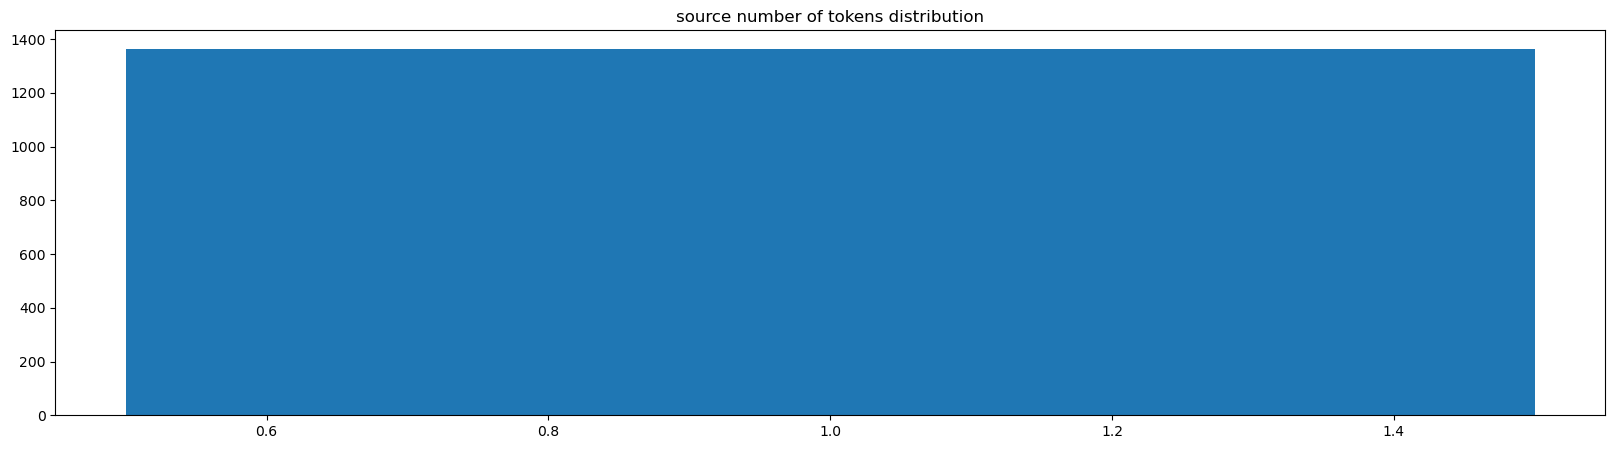

There is 1 unique source.


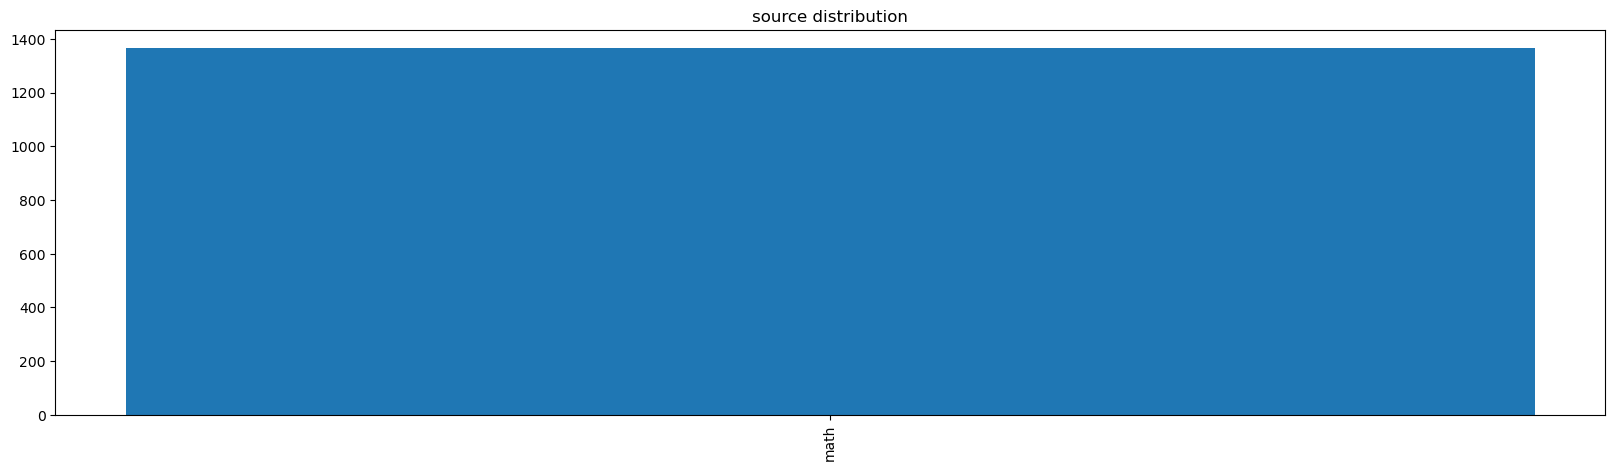

In [2]:
limr = load_data("LIMR")
limr = filter_limr(limr)
print_distributions(limr, ['id', 'prompt', 'answer', 'source'])

### Llama-Nemotron

Filter: 100%|██████████| 9845/9845 [00:00<00:00, 12338.47 examples/s]


Filtered 3.39% of the dataset
Features: ['input', 'output', 'category', 'license', 'reasoning', 'generator', 'used_in_training', 'version', 'system_prompt', 'answer']
Number of samples: 9661
Sample: {
    "answer": "66",
    "category": "math",
    "generator": "Qwen-2.5-32B-Instruct, DeepSeek-R1",
    "input": [
        {
            "content": "Solve the following math problem. Make sure to put the answer (and only answer) inside \\boxed{}.\n\nIf $m+\\frac{1}{m}=8$, then what is the value of $m^{2}+\\frac{1}{m^{2}}+4$?",
            "role": "user"
        }
    ],
    "license": "cc-by-4.0",
    "output": "<think>\nOkay, let's see. The problem says that m plus 1 over m equals 8, and we need to find the value of m squared plus 1 over m squared plus 4. Hmm, algebra, right? I think this is one of those problems where you have to manipulate the given equation to find the value they're asking for.\n\nSo, starting with the given equation: m + 1/m = 8. I remember that when you have expressi

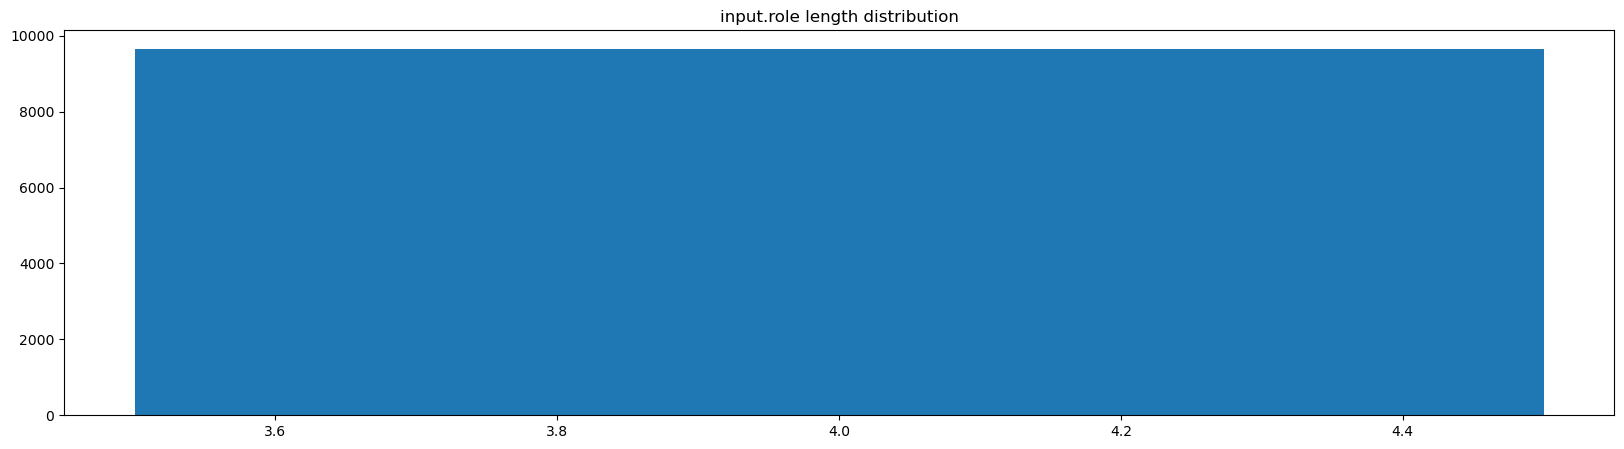

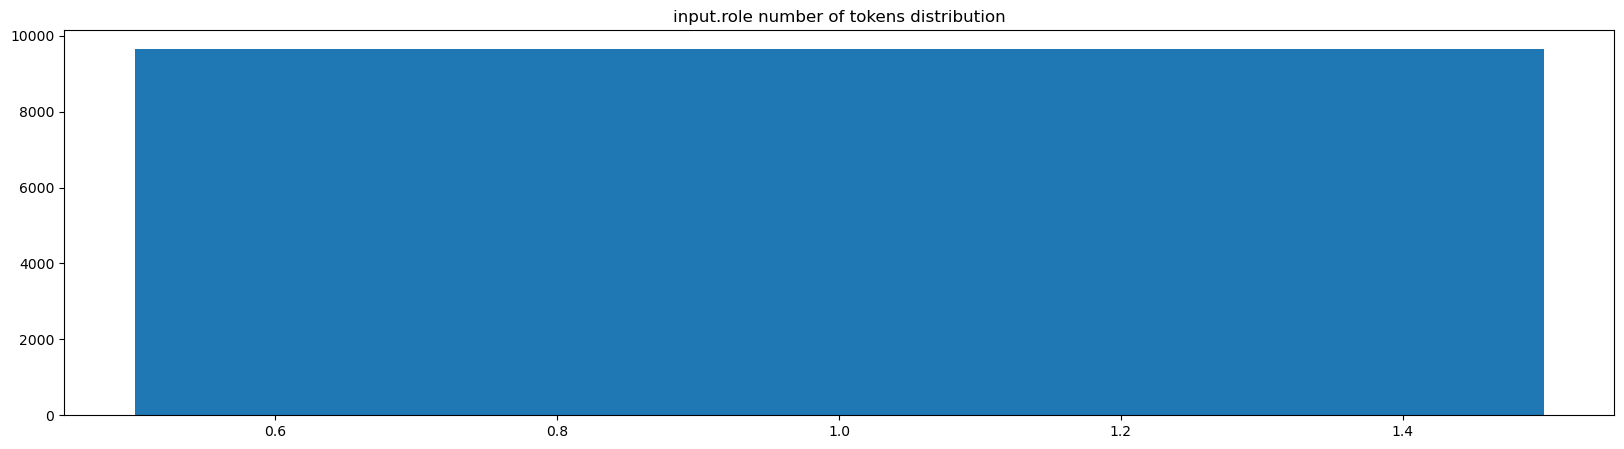

There is 1 unique input.role.


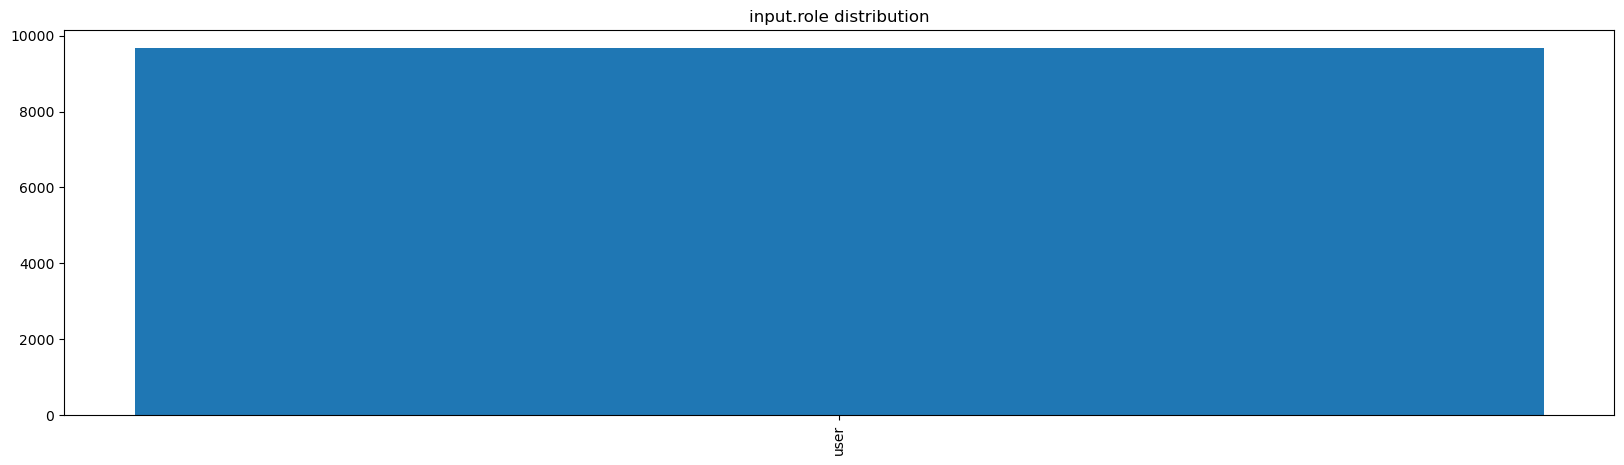

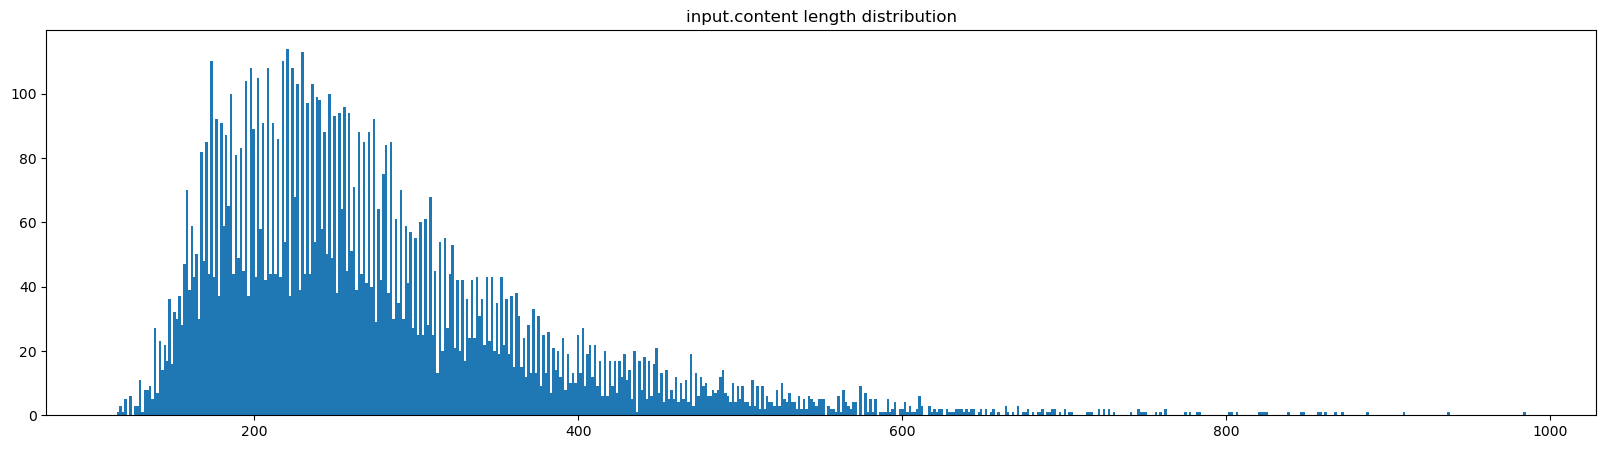

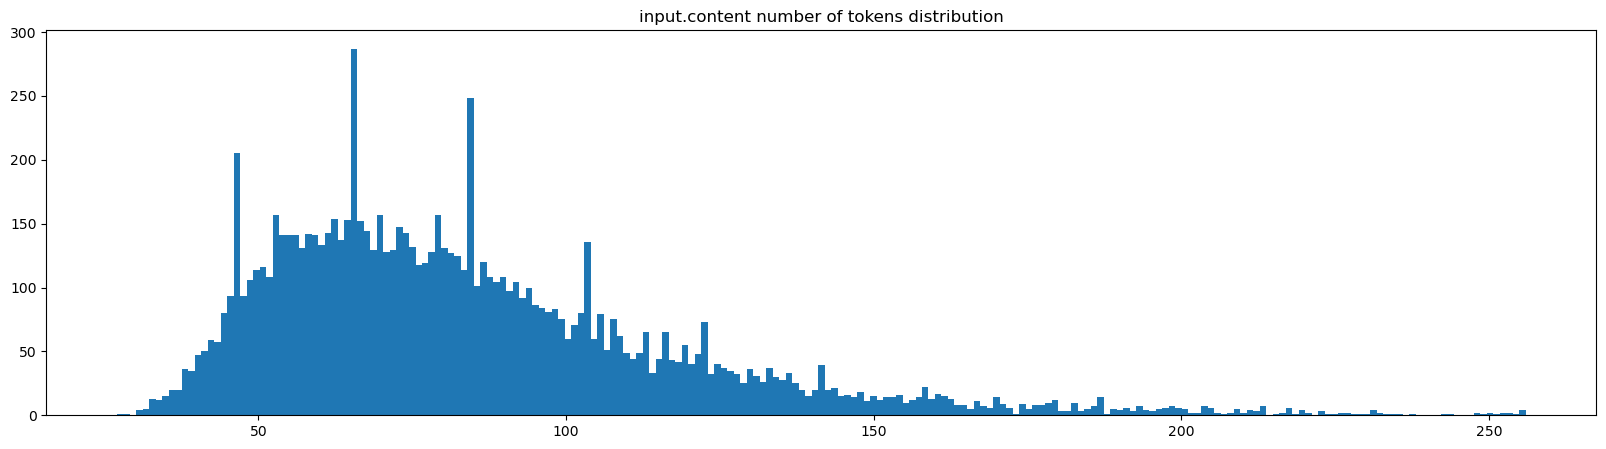

There is 9406 unique input.content.


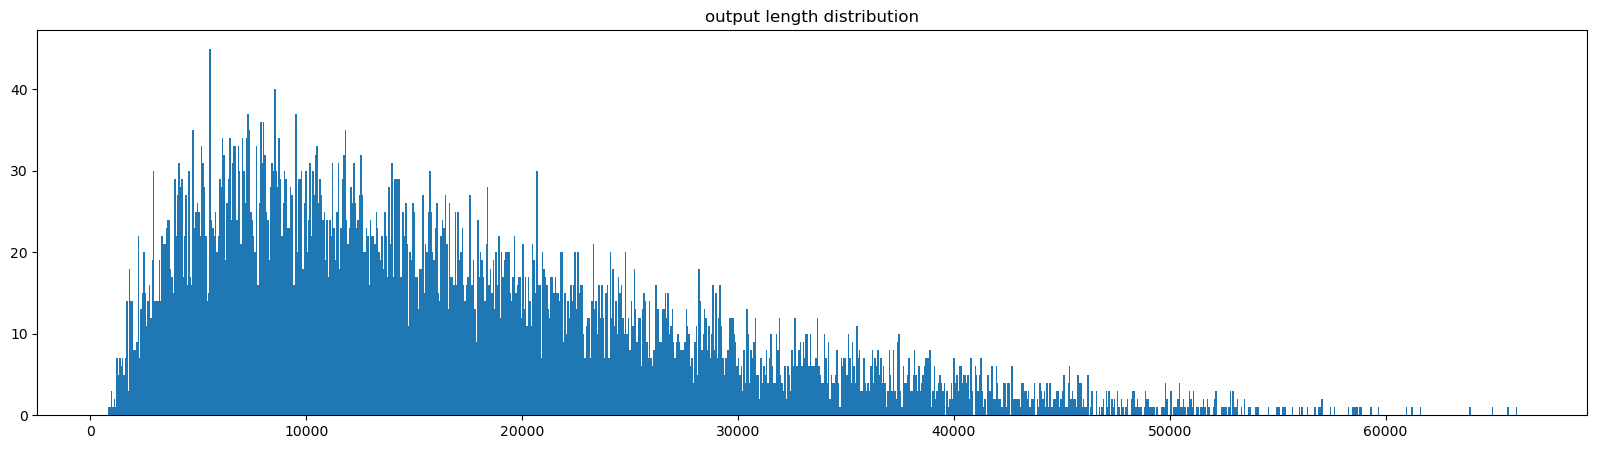

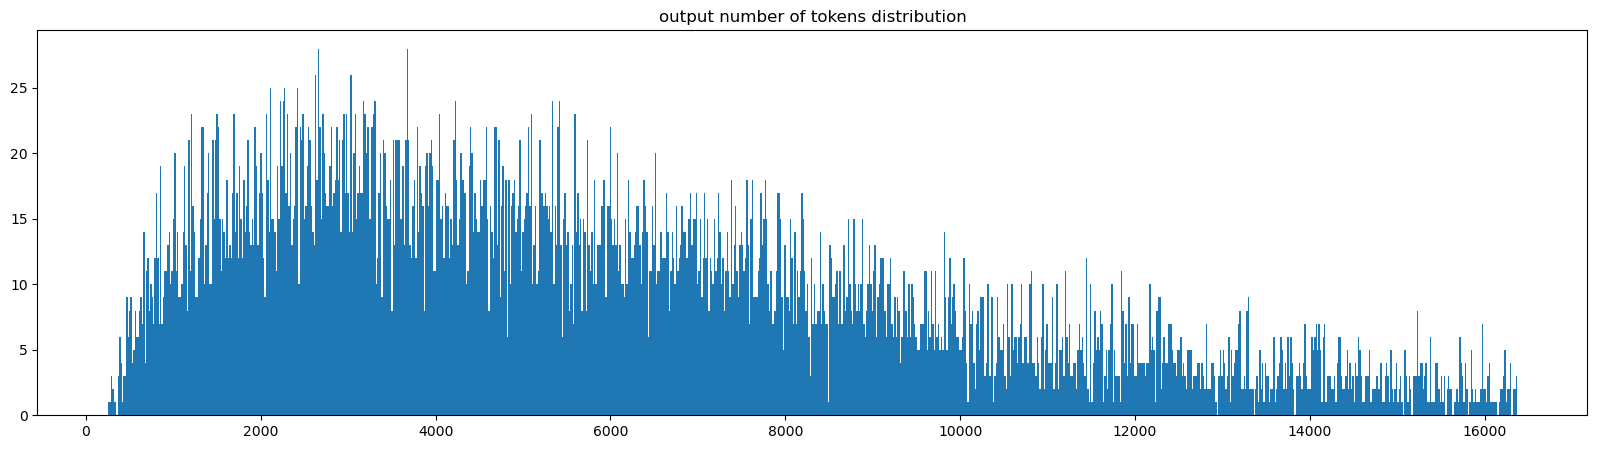

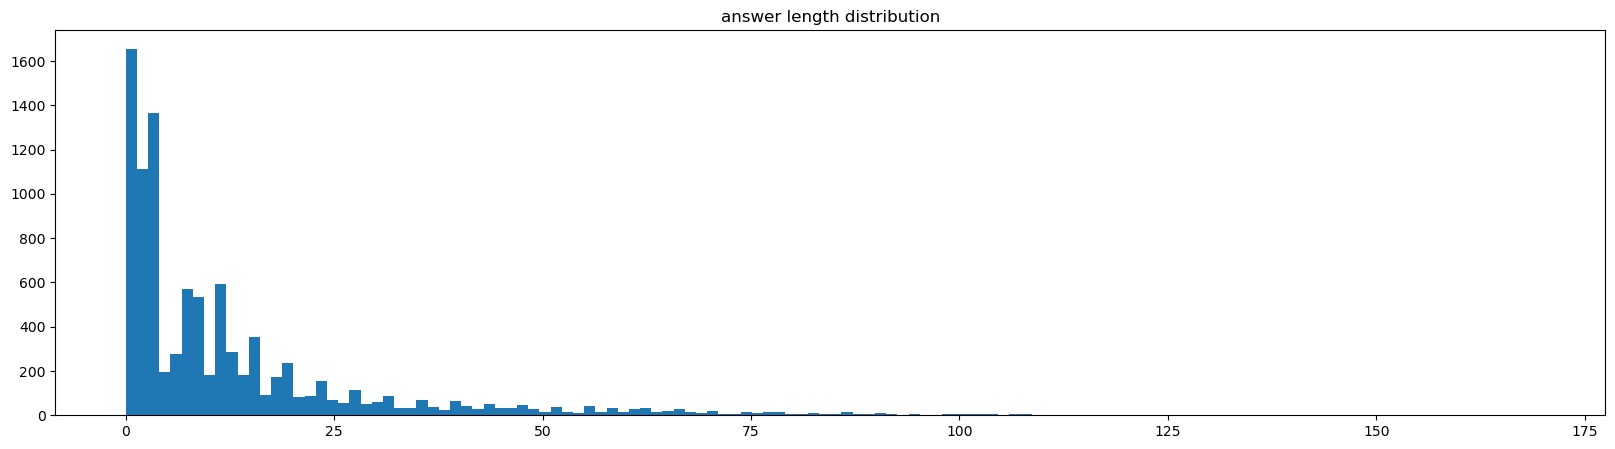

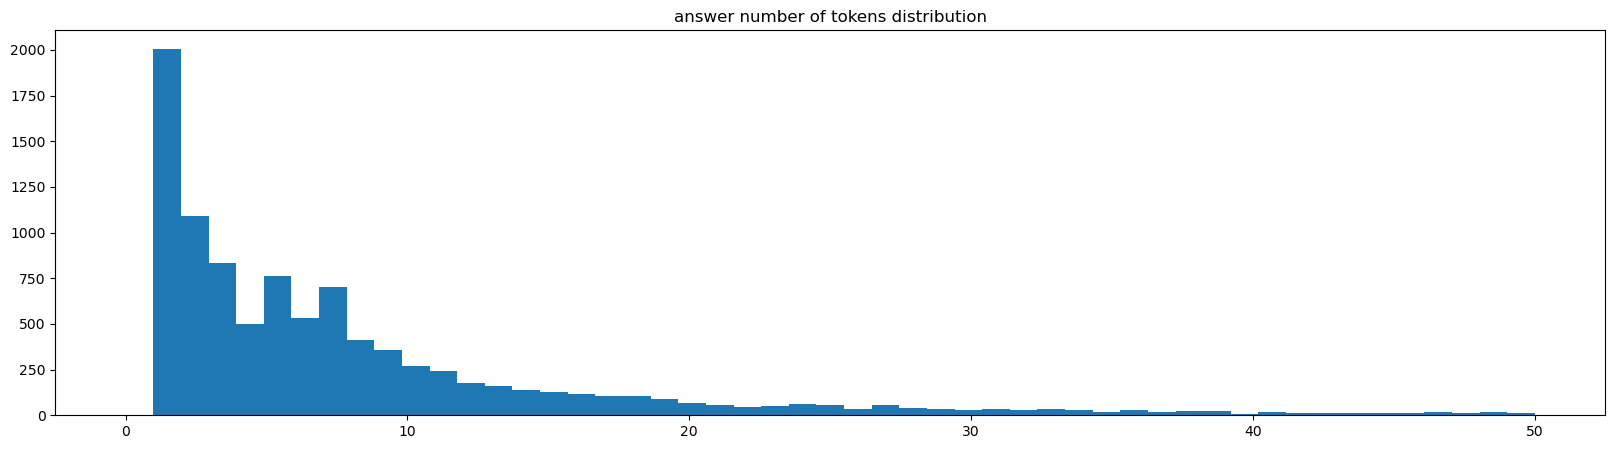

There is 4674 unique answer.


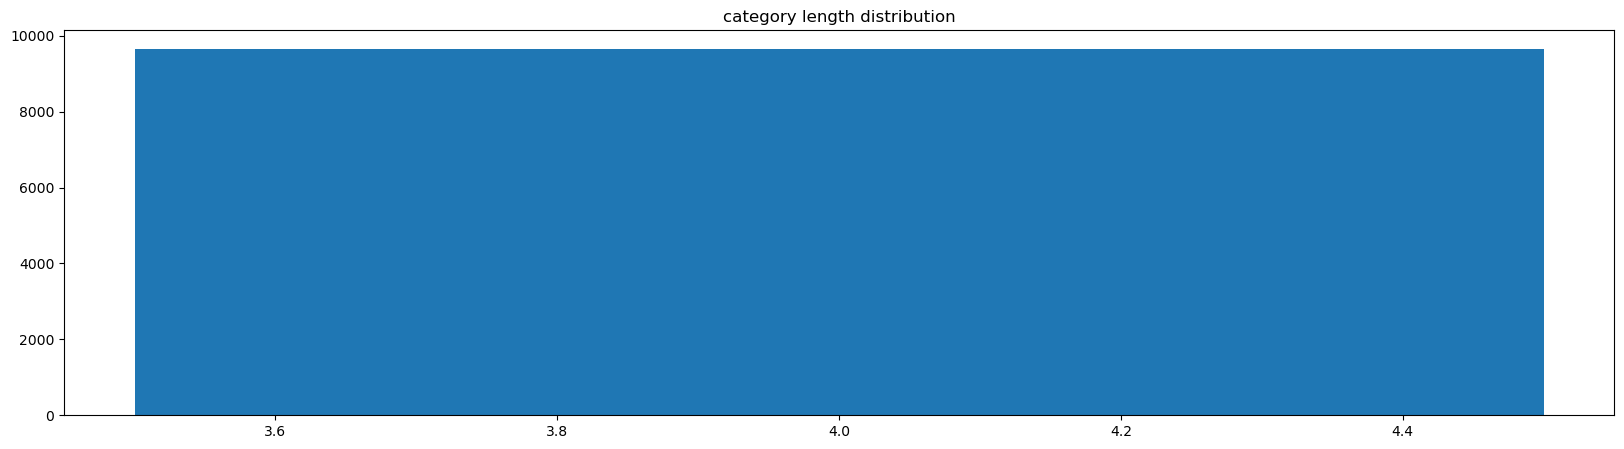

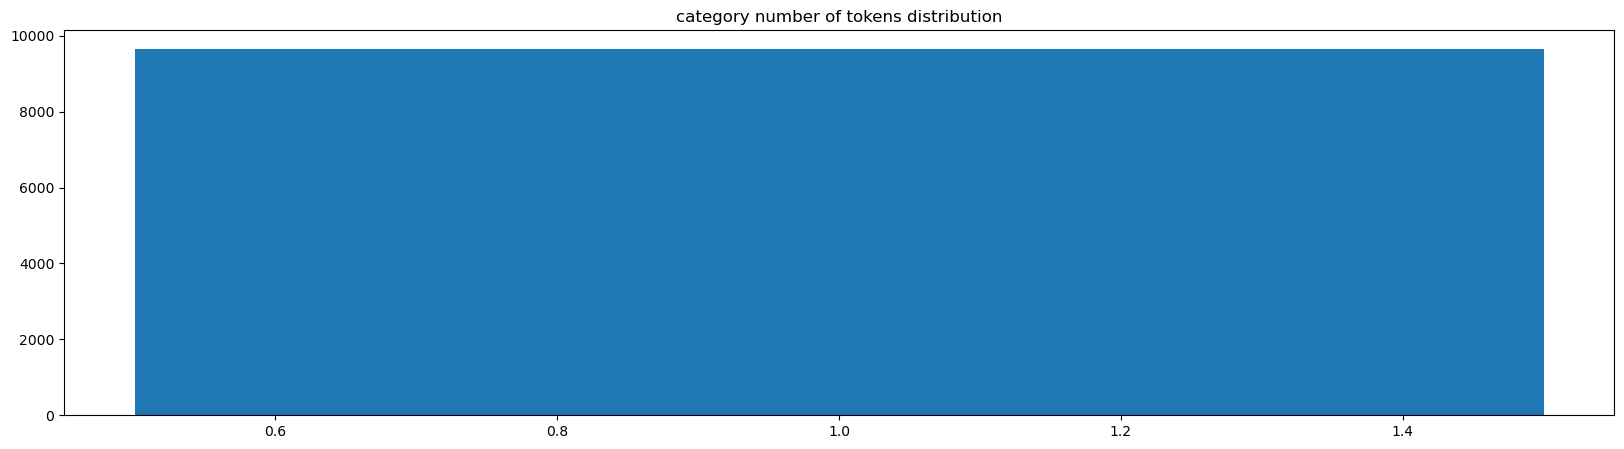

There is 1 unique category.


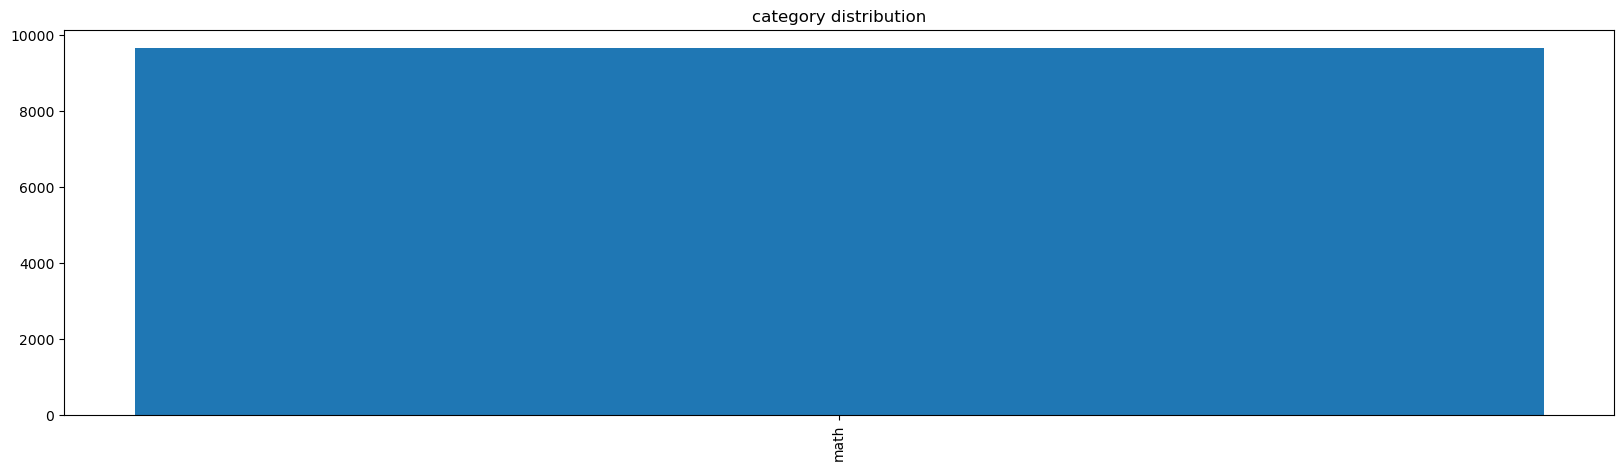

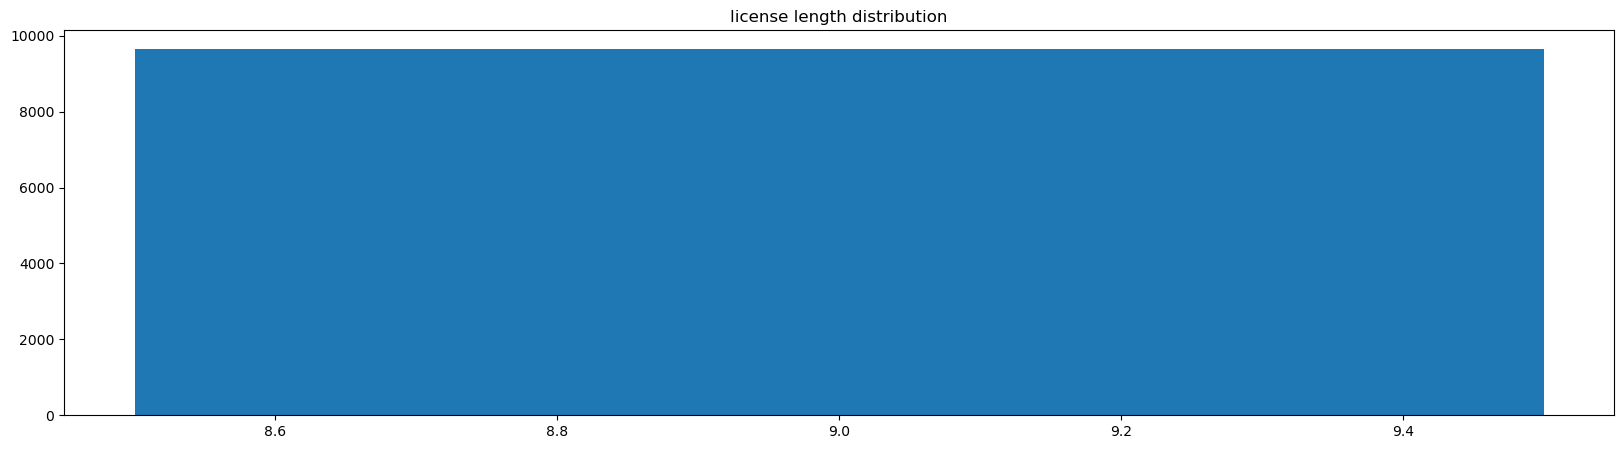

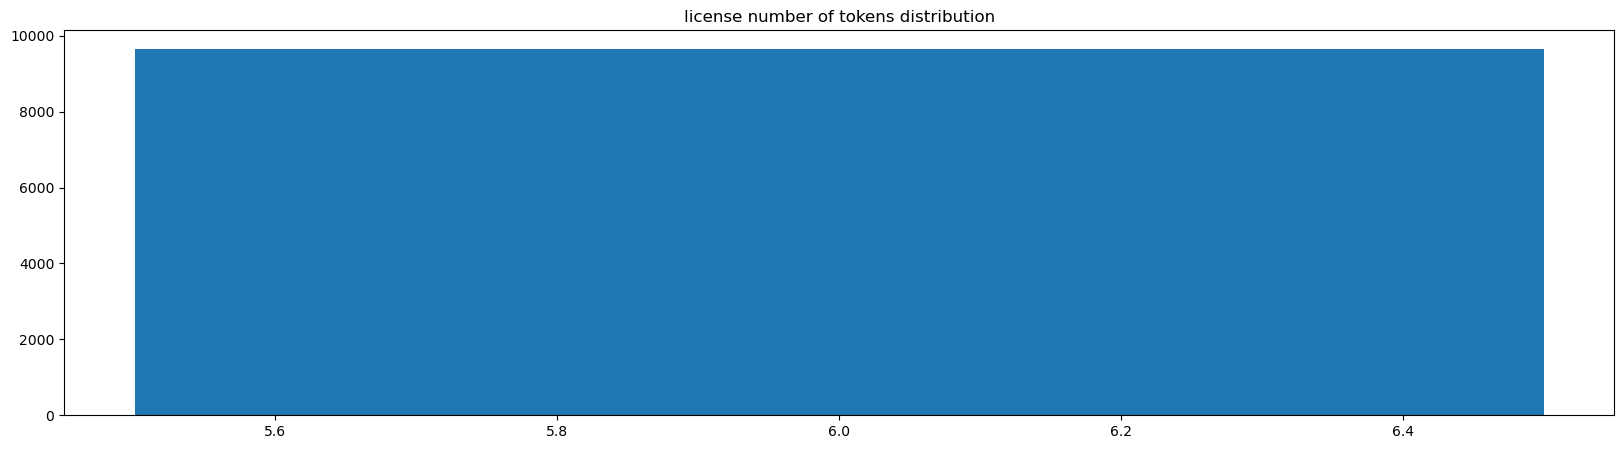

There is 1 unique license.


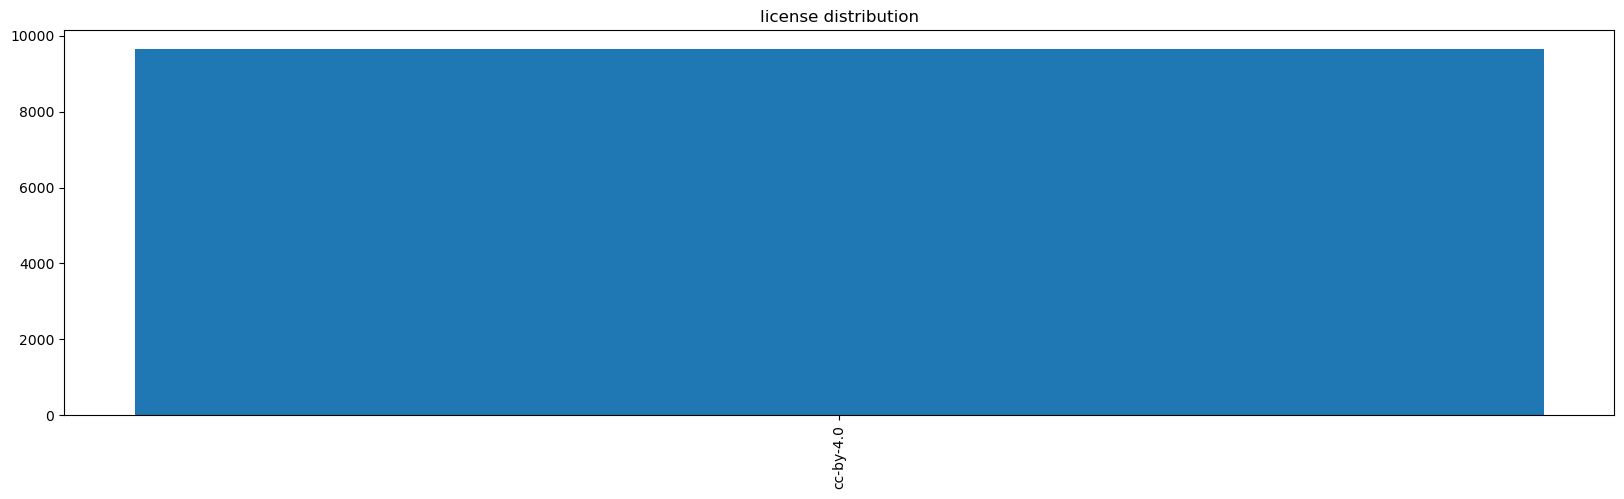

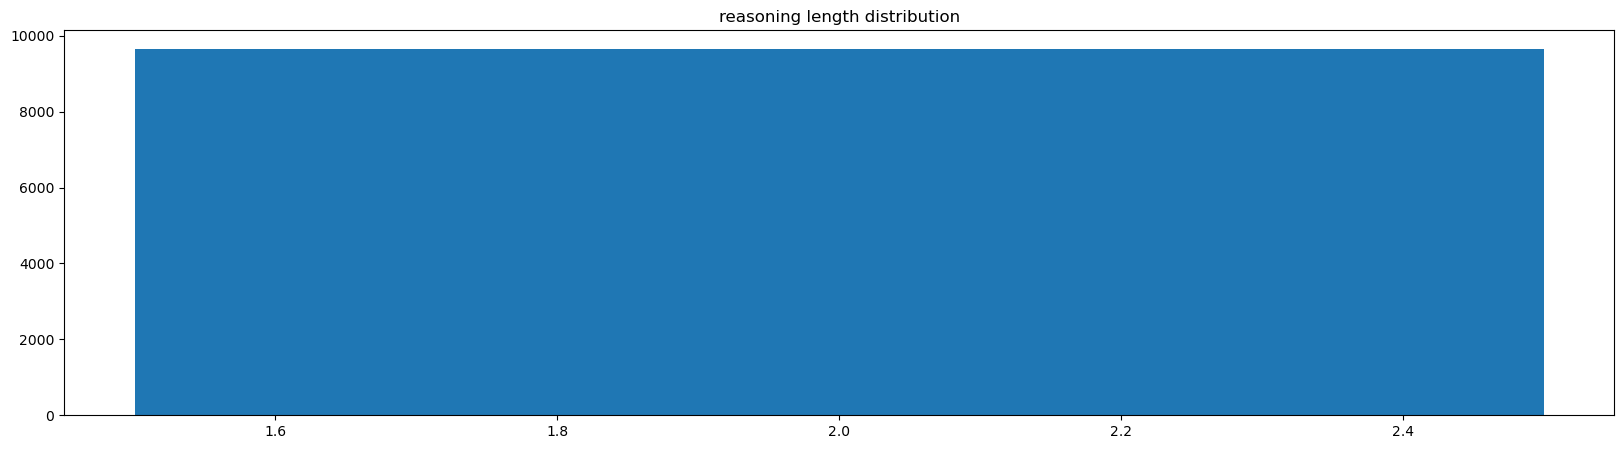

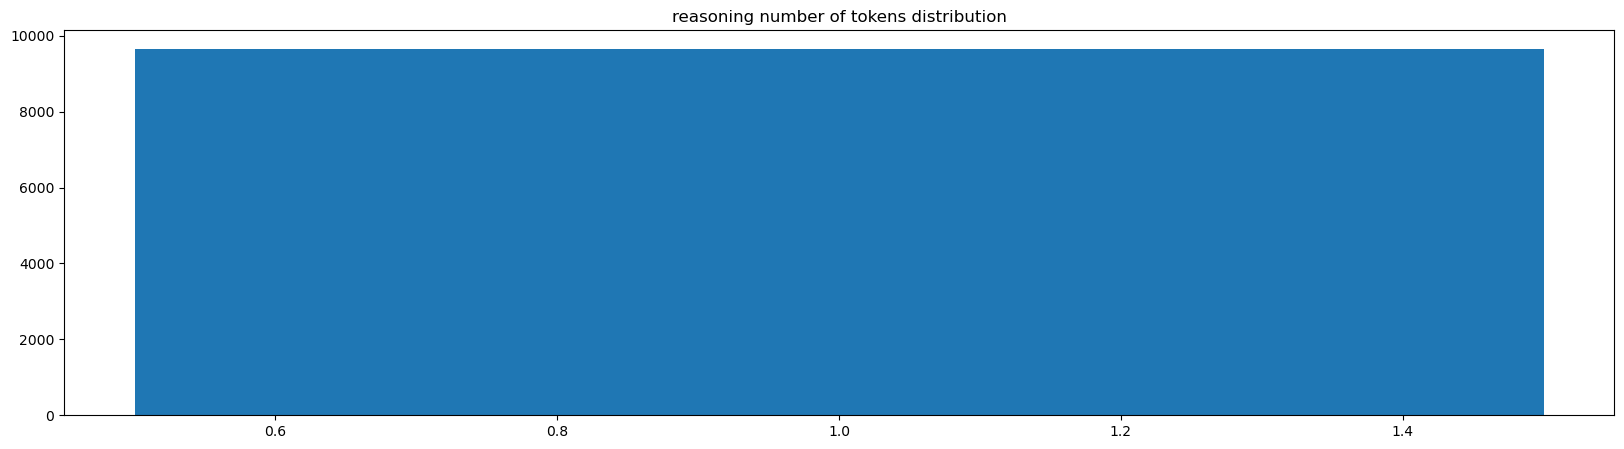

There is 1 unique reasoning.


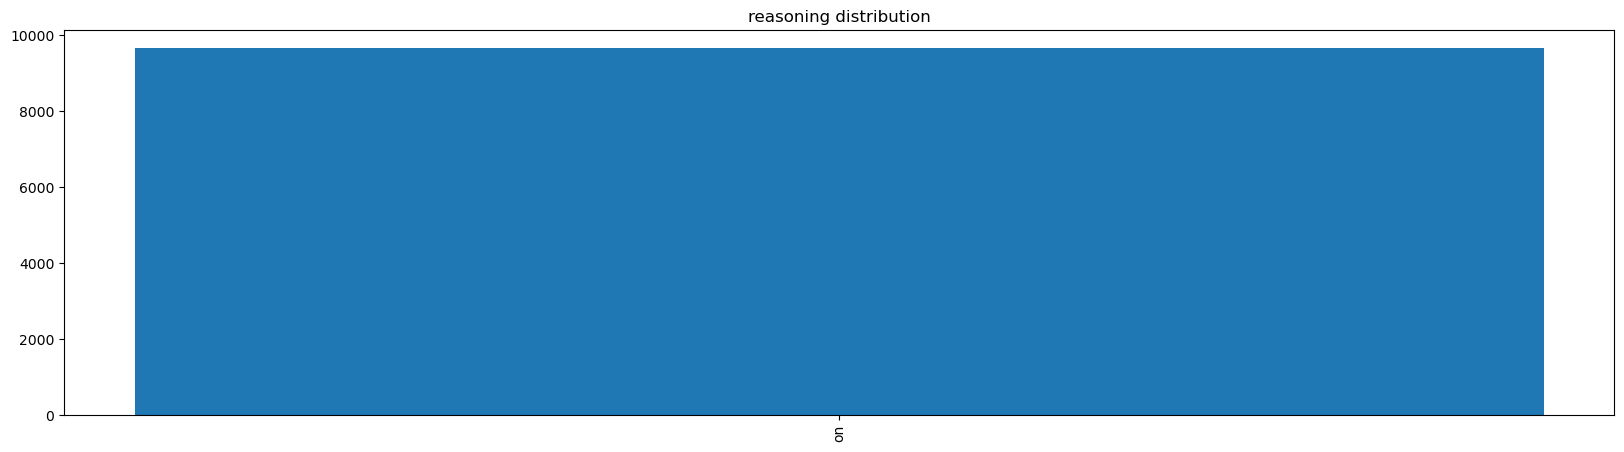

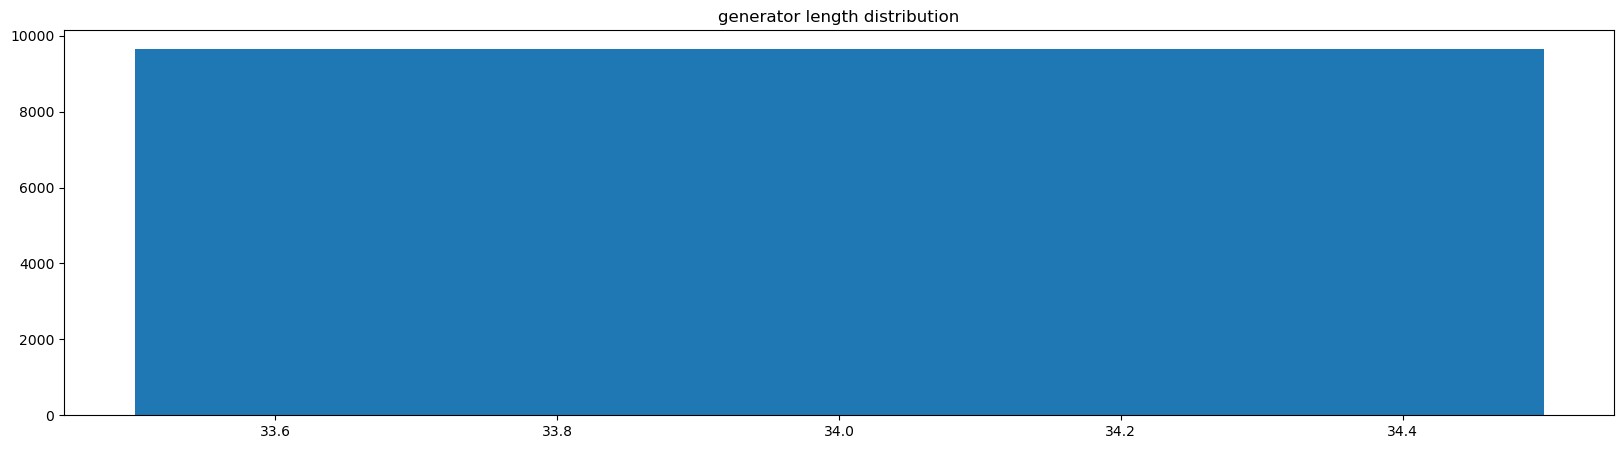

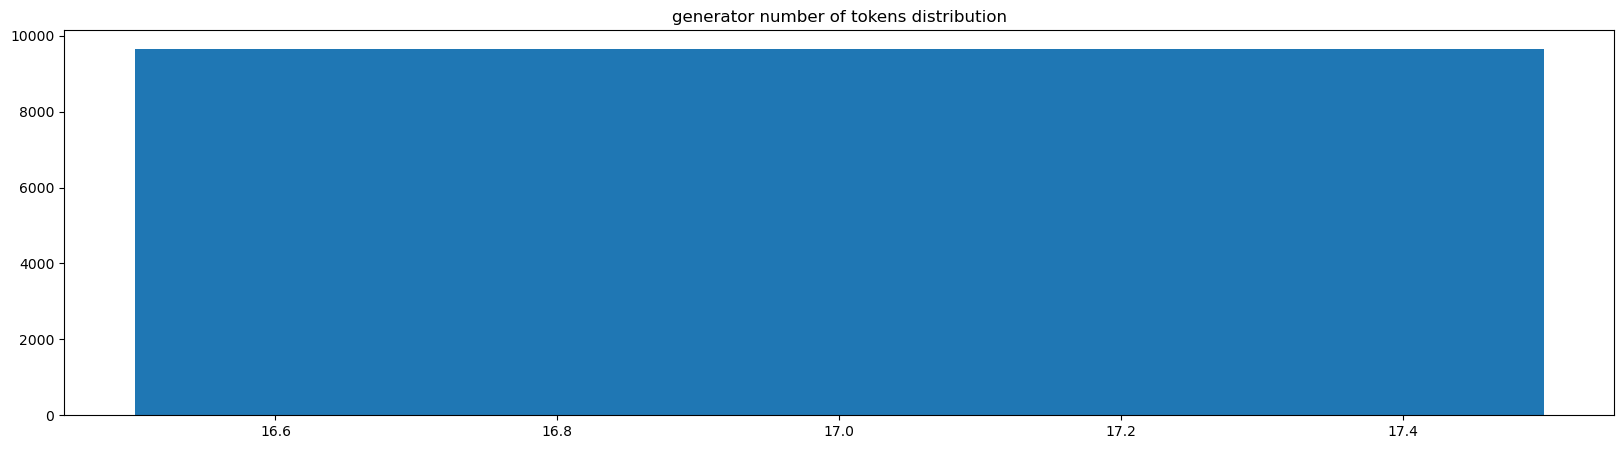

There is 1 unique generator.


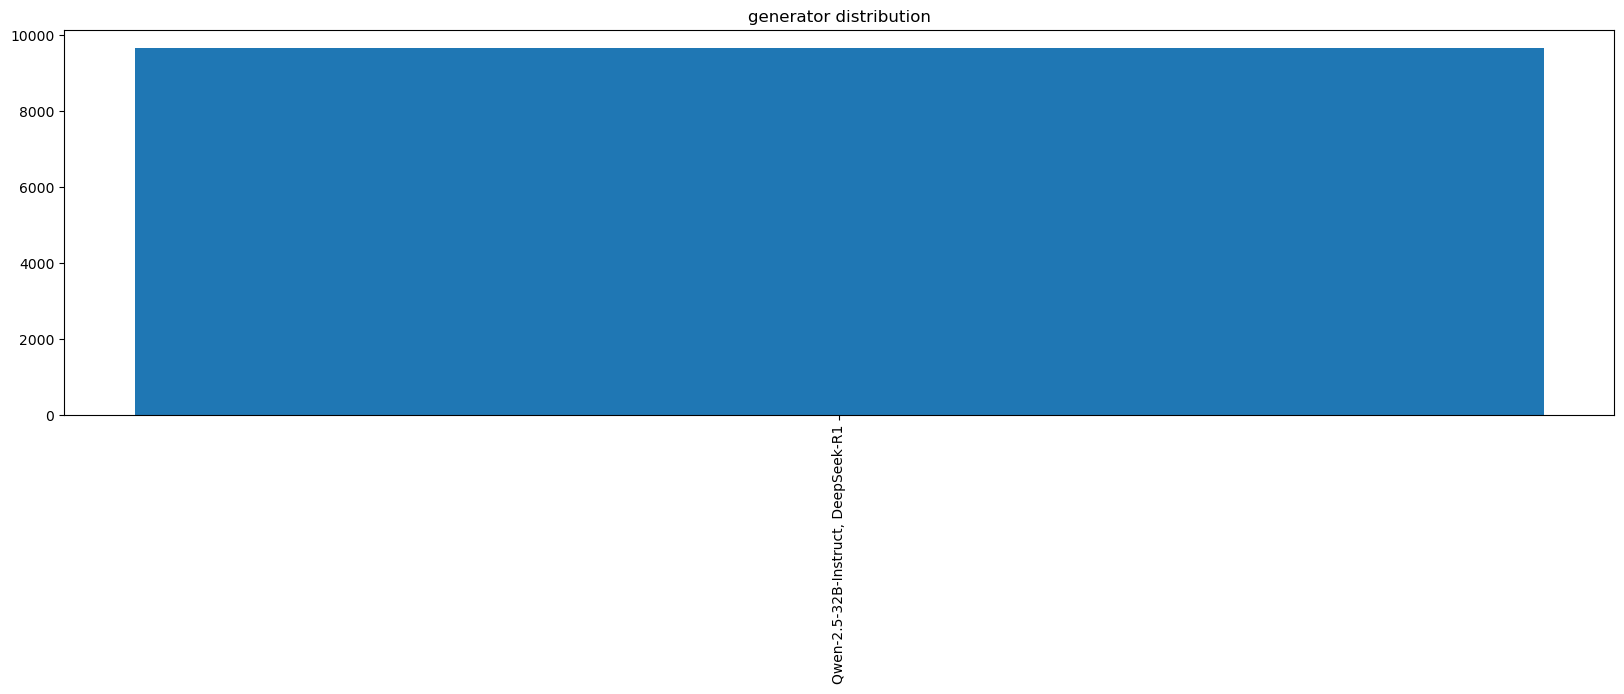

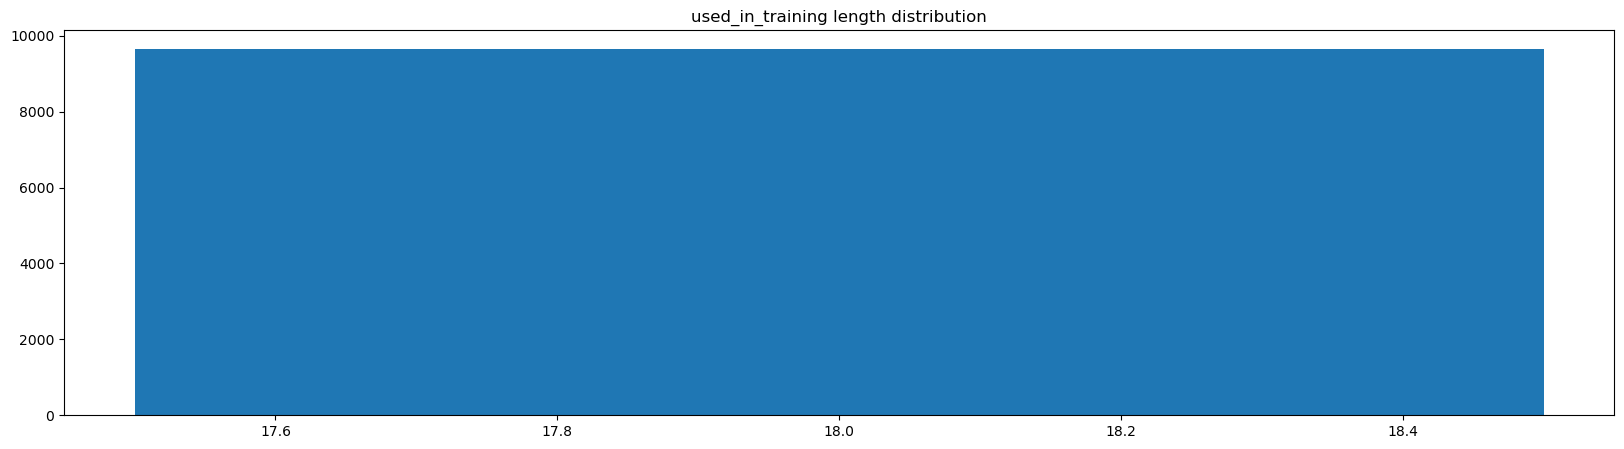

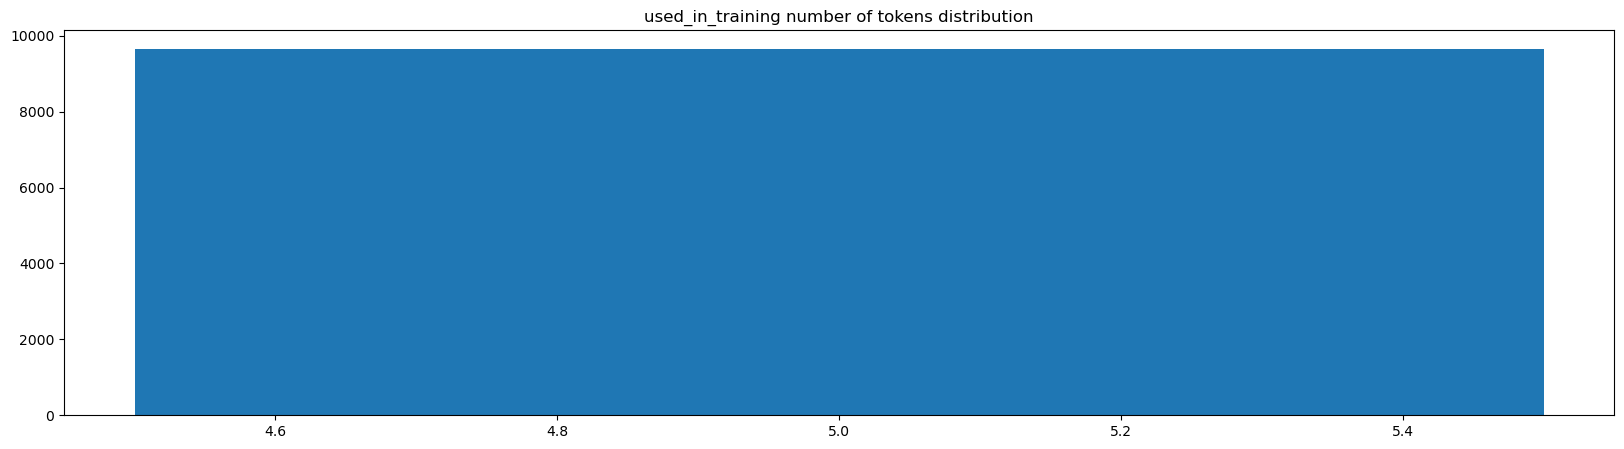

There is 1 unique used_in_training.


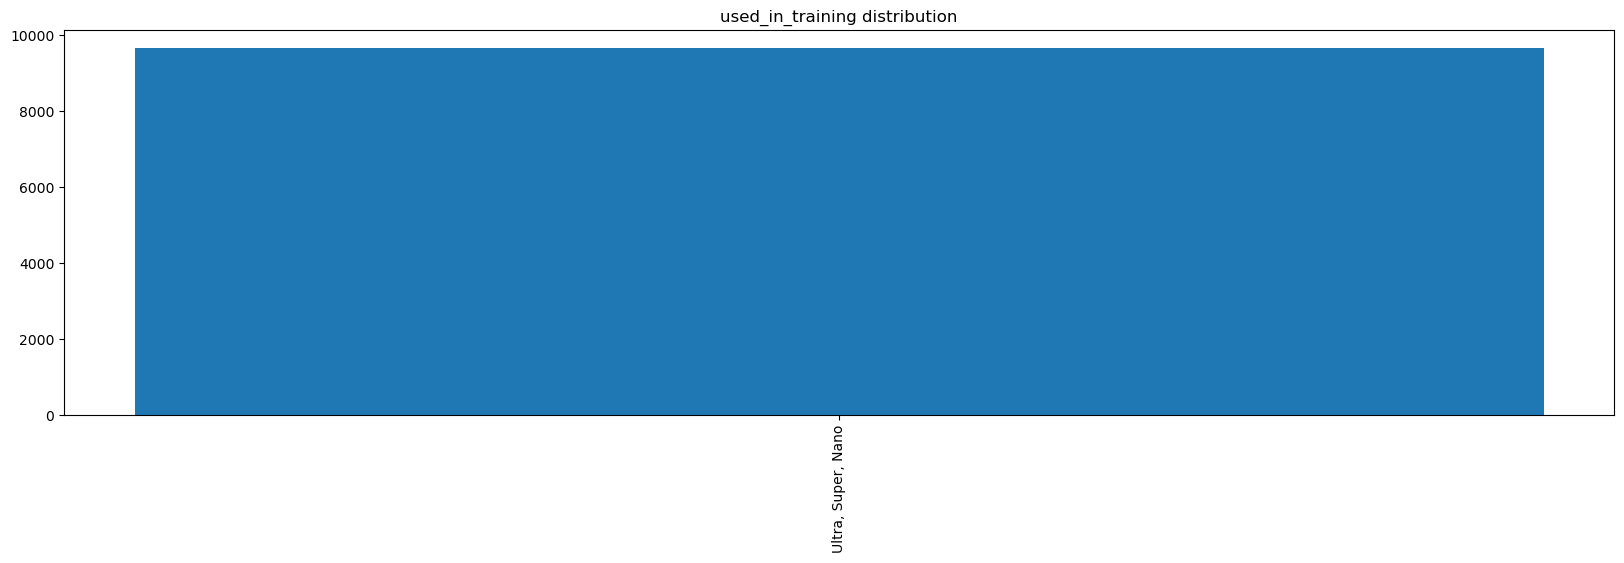

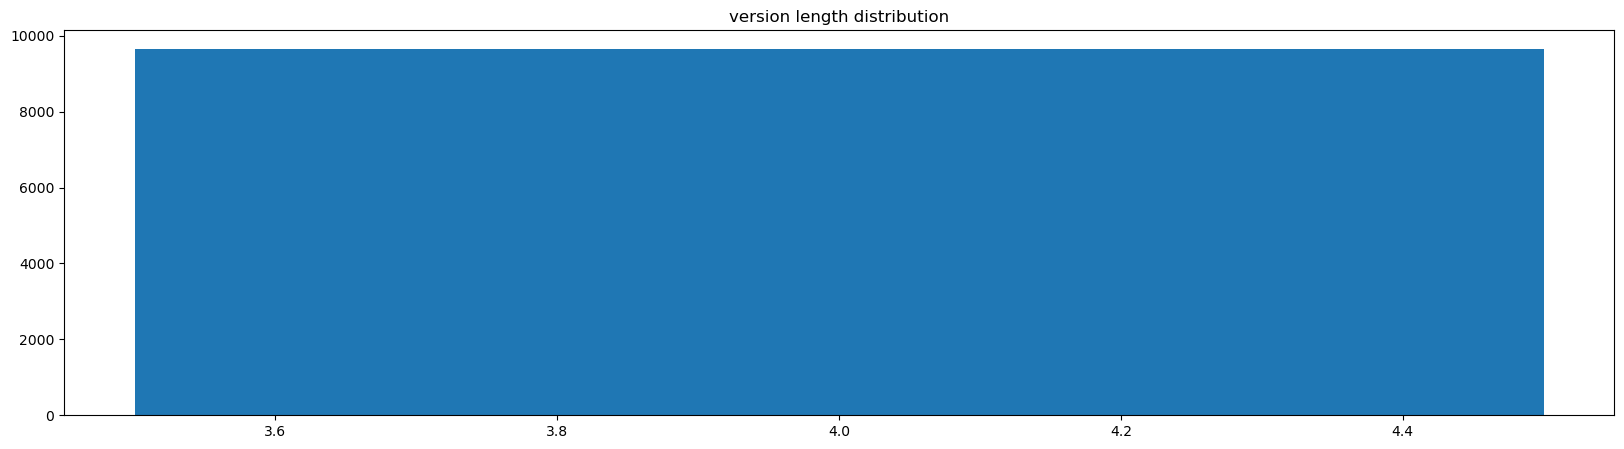

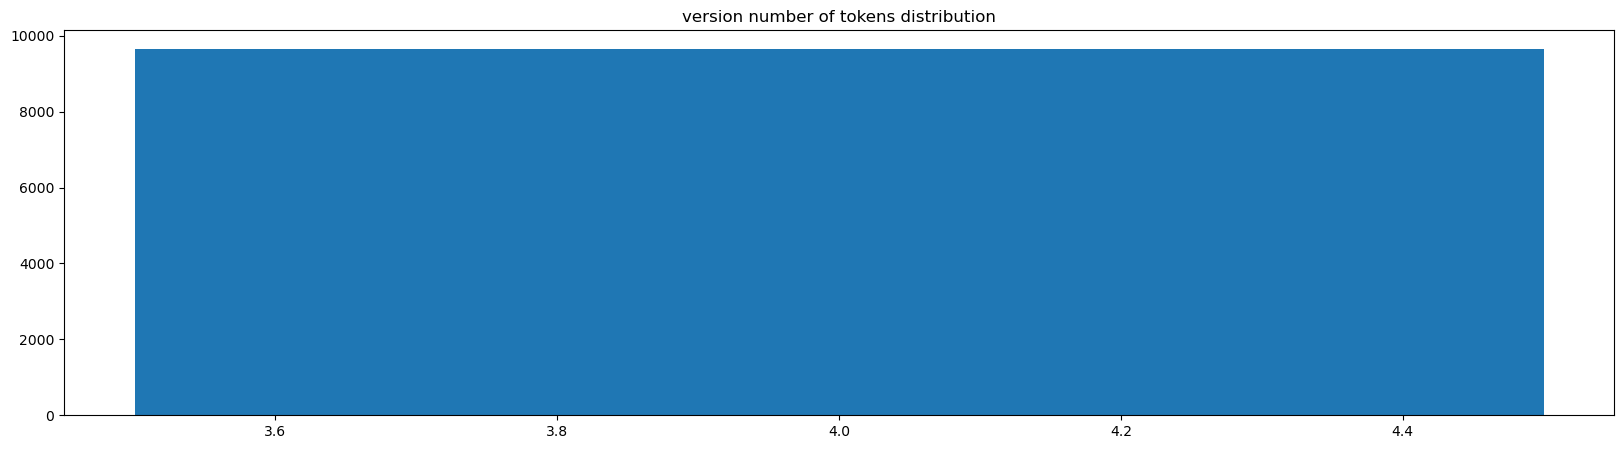

There is 1 unique version.


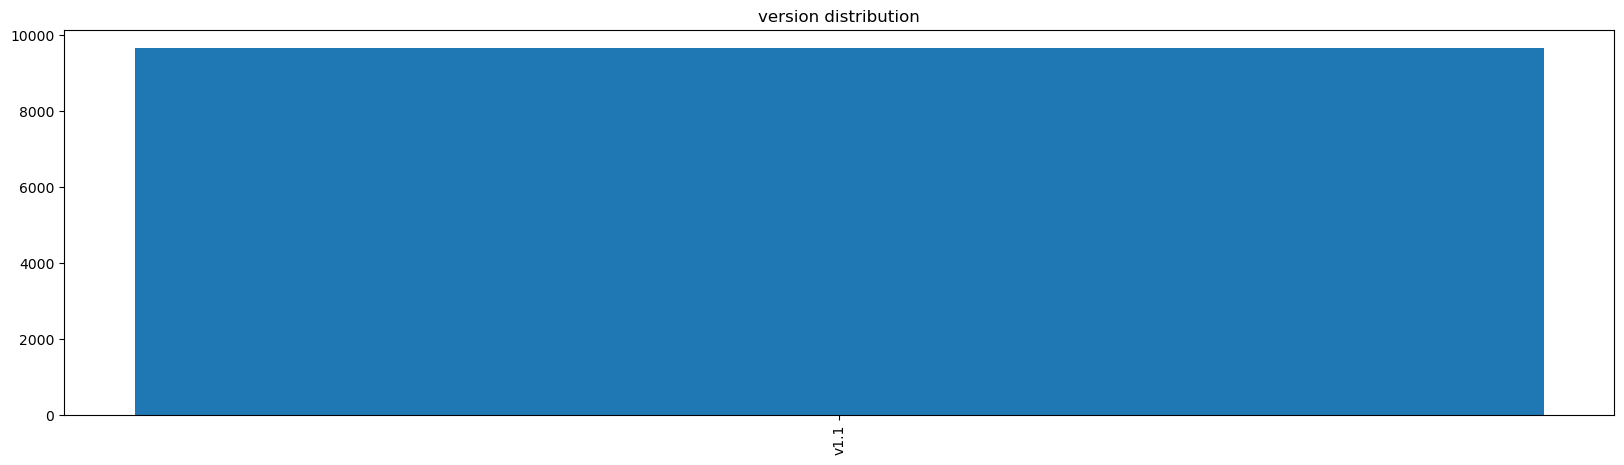

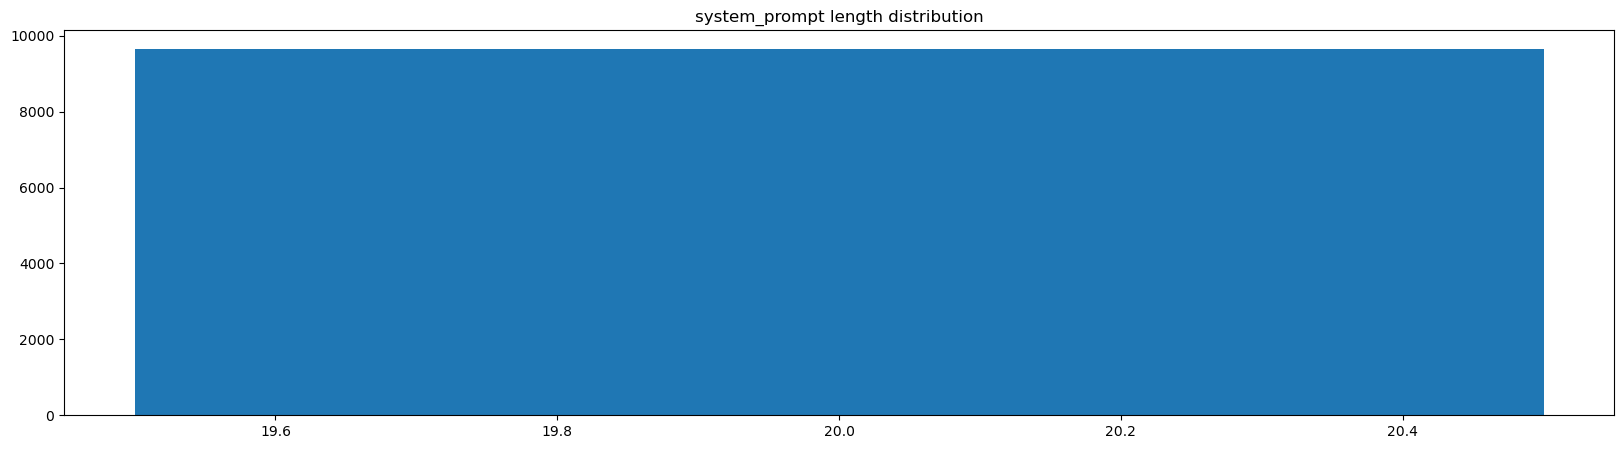

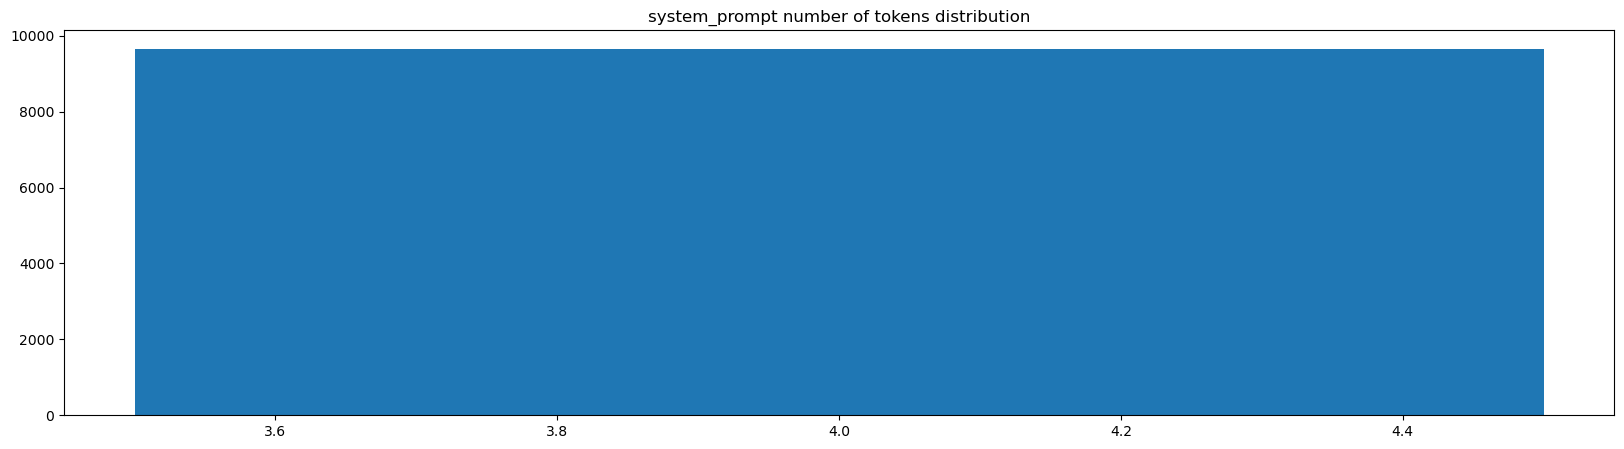

There is 1 unique system_prompt.


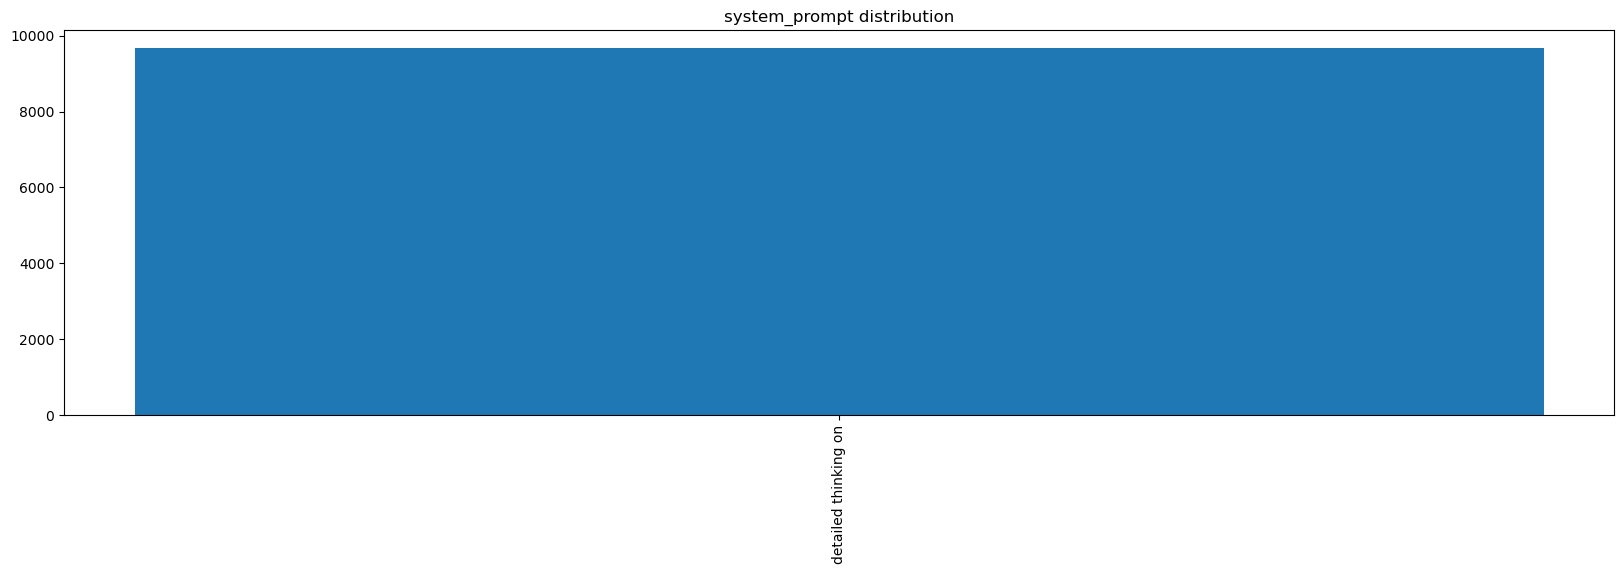

In [ ]:
llama_nemotron = load_data("Llama-Nemotron-Post-Training-Dataset").select(range(10000))
llama_nemotron = llama_nemotron.add_column(
    "answer",
    [extract_boxed_text(x) for x in llama_nemotron["output"]]
)
llama_nemotron = filter_llama_nemotron(llama_nemotron)
print_distributions(llama_nemotron, ['input', 'output', 'answer', 'category', 'license', 'reasoning', 'generator', 'used_in_training', 'version', 'system_prompt'])

### Math lvl 5 FR

Filtered 1.8005540166204985% of the dataset
Features: ['problem', 'type', 'solution', 'answer']
Number of samples: 1418
Sample: {
    "answer": "\\frac{3}{4}",
    "problem": "Soit $\\theta$ le plus petit angle aigu pour lequel $\\sin \\theta,$ $\\sin 2 \\theta,$ $\\sin 3 \\theta$ forment une progression arithm\u00e9tique, dans un certain ordre. Trouvez $\\cos \\theta.$",
    "solution": "Nous examinons les cas, selon lequel de $\\sin \\alpha,$ $\\sin 2 \\alpha,$ $\\sin 3 \\alpha$ est le terme du milieu.\n\nCas 1 : $\\sin \\alpha$ est le terme du milieu.\n\nDans ce cas,\n\\[2 \\sin \\alpha = \\sin 2 \\alpha + \\sin 3 \\alpha.\\]On peut \u00e9crire cela comme $2 \\sin \\alpha = 2 \\sin \\alpha \\cos \\alpha + (3 \\sin \\alpha - 4 \\sin^3 \\alpha),$ donc\n\\[2 \\sin \\alpha \\cos \\alpha + \\sin \\alpha - 4 \\sin^3 \\alpha = 0.\\]Puisque $\\alpha$ est aigu, $\\sin \\alpha > 0,$ on peut diviser par $\\sin \\alpha$ pour obtenir\n\\[2 \\cos \\alpha + 1 - 4 \\sin^2 \\alpha = 0.\\]On peut \u0

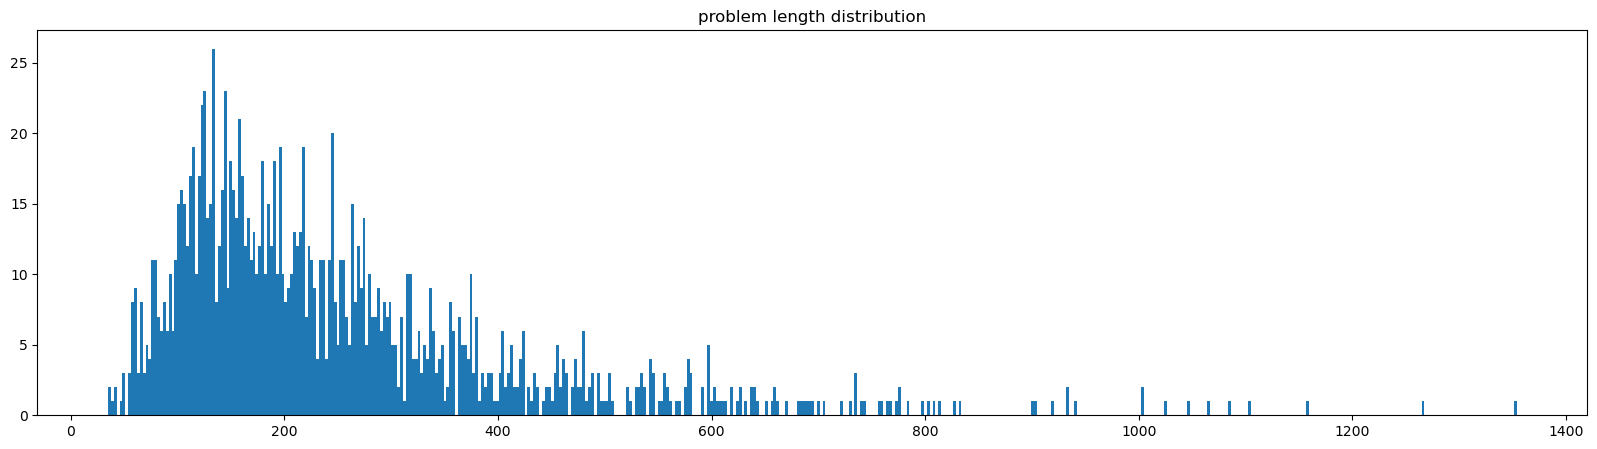

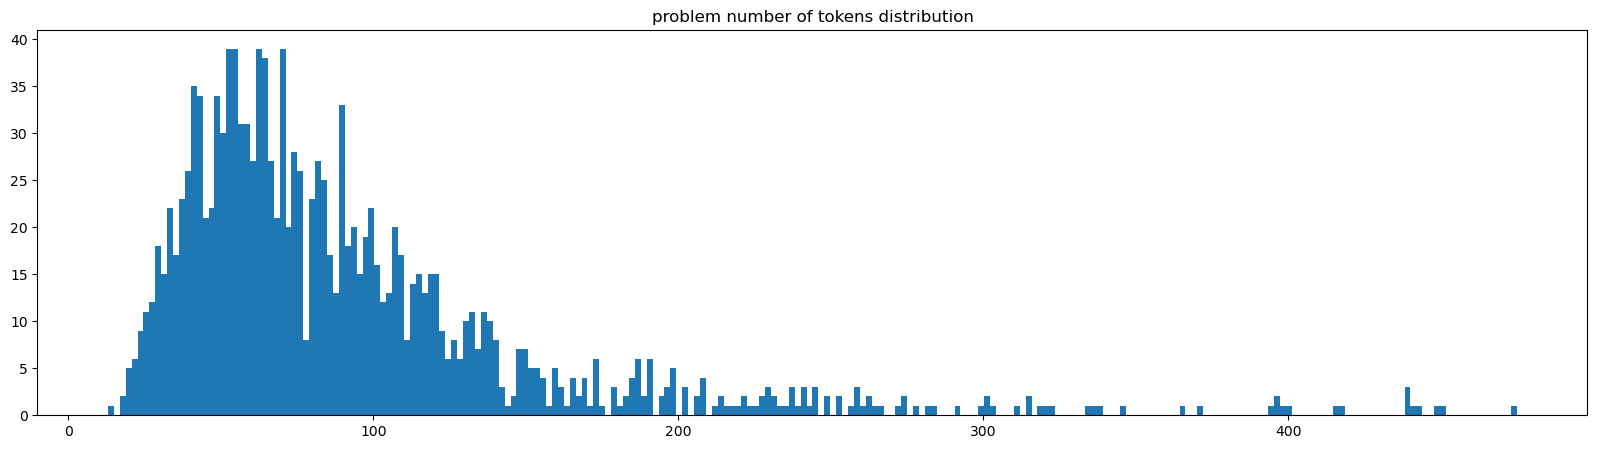

There is 1417 unique problem.


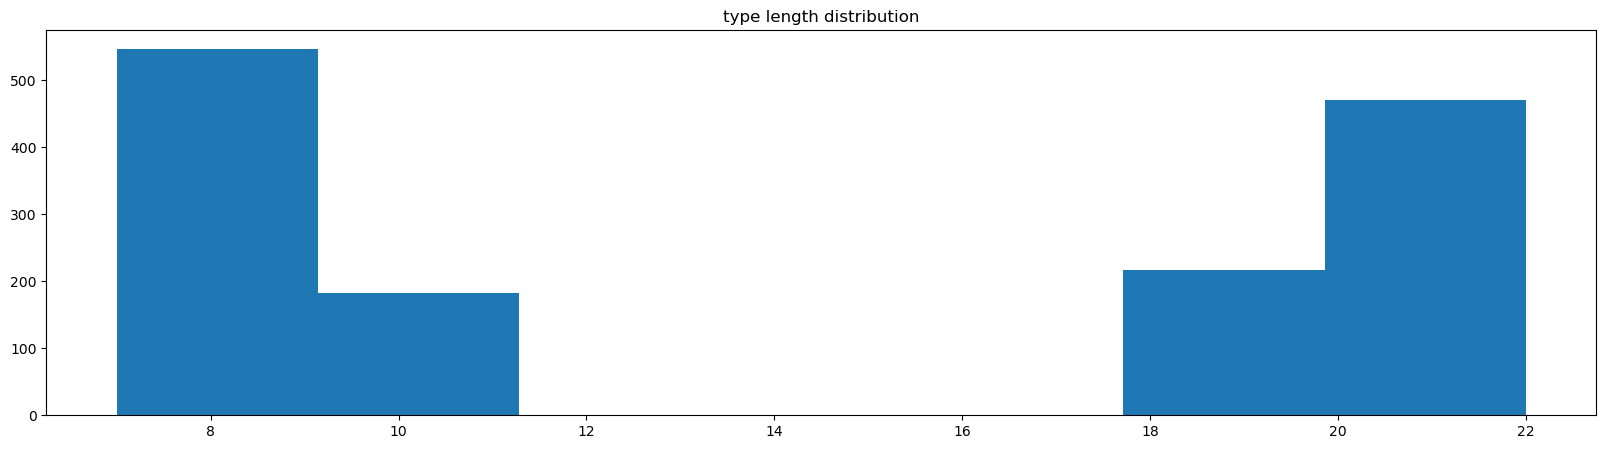

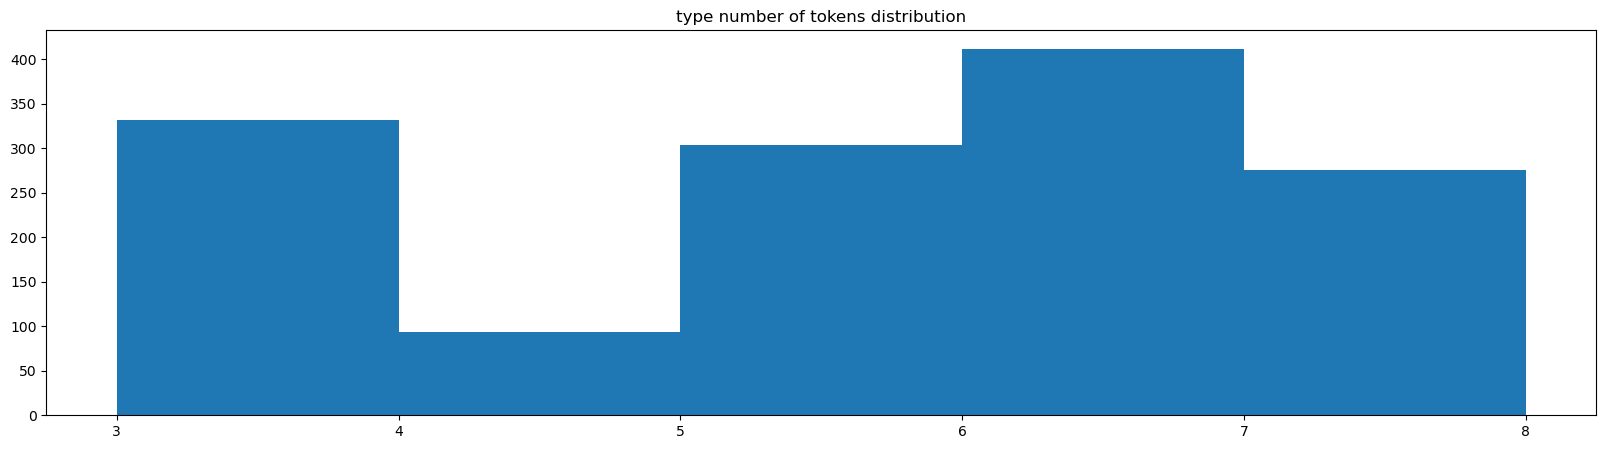

There is 12 unique type.


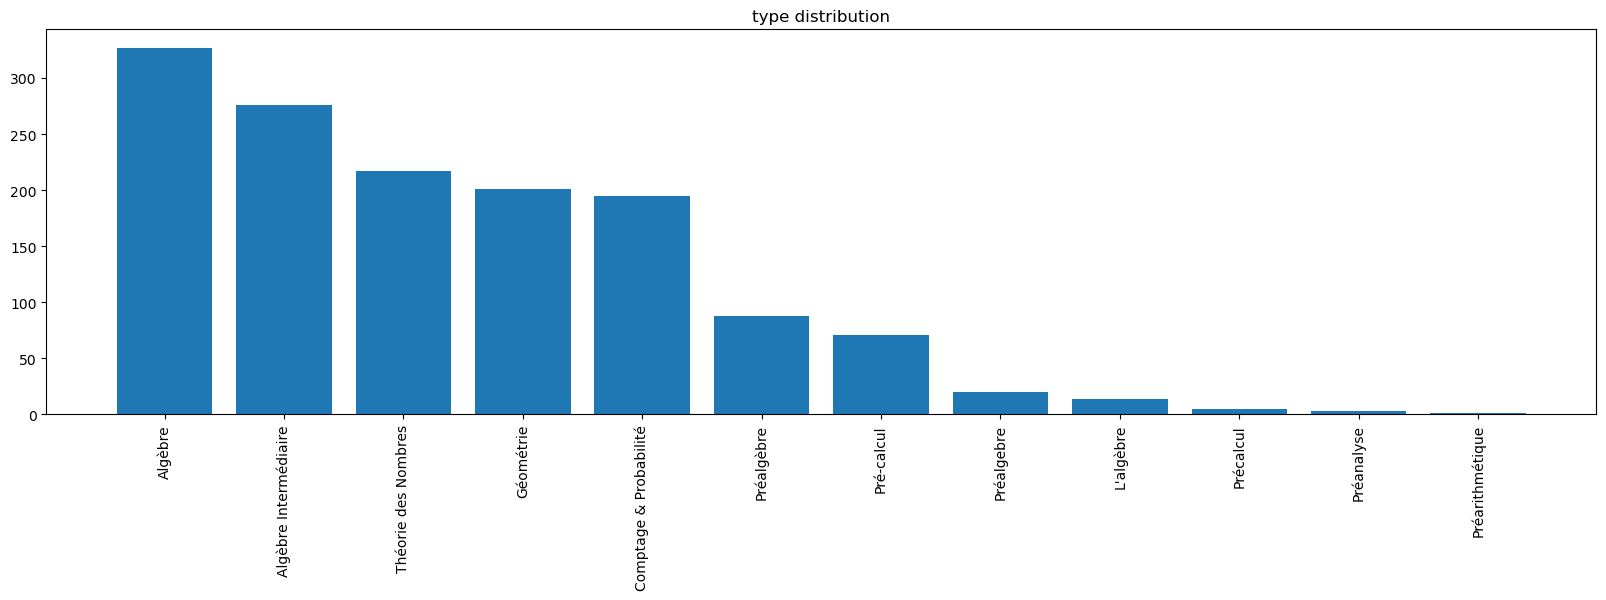

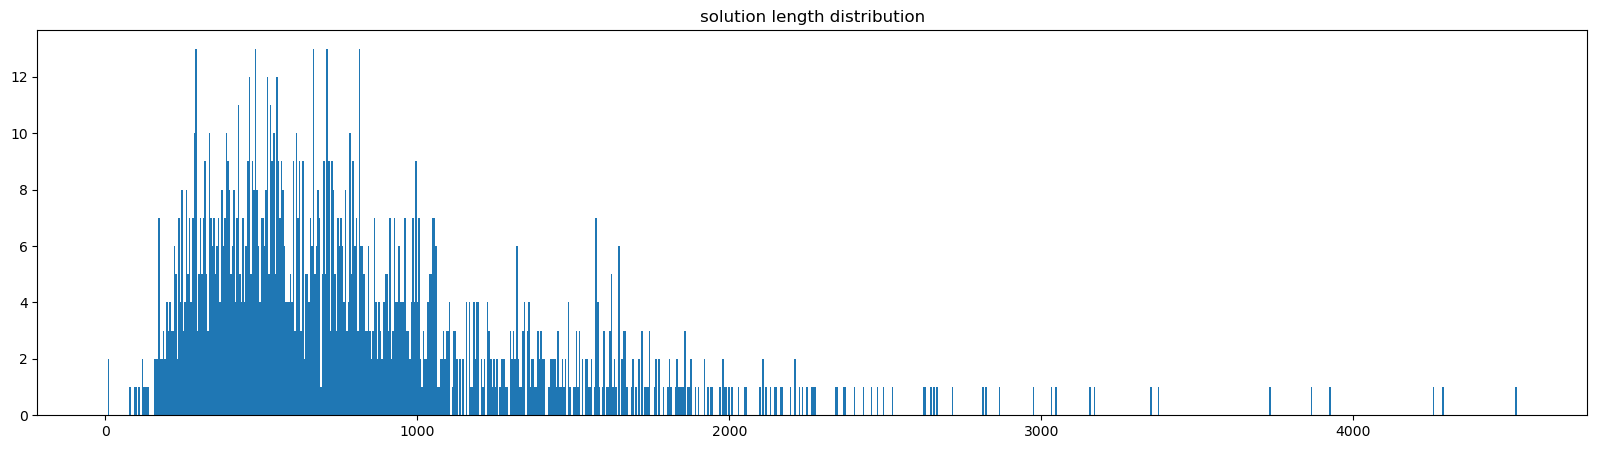

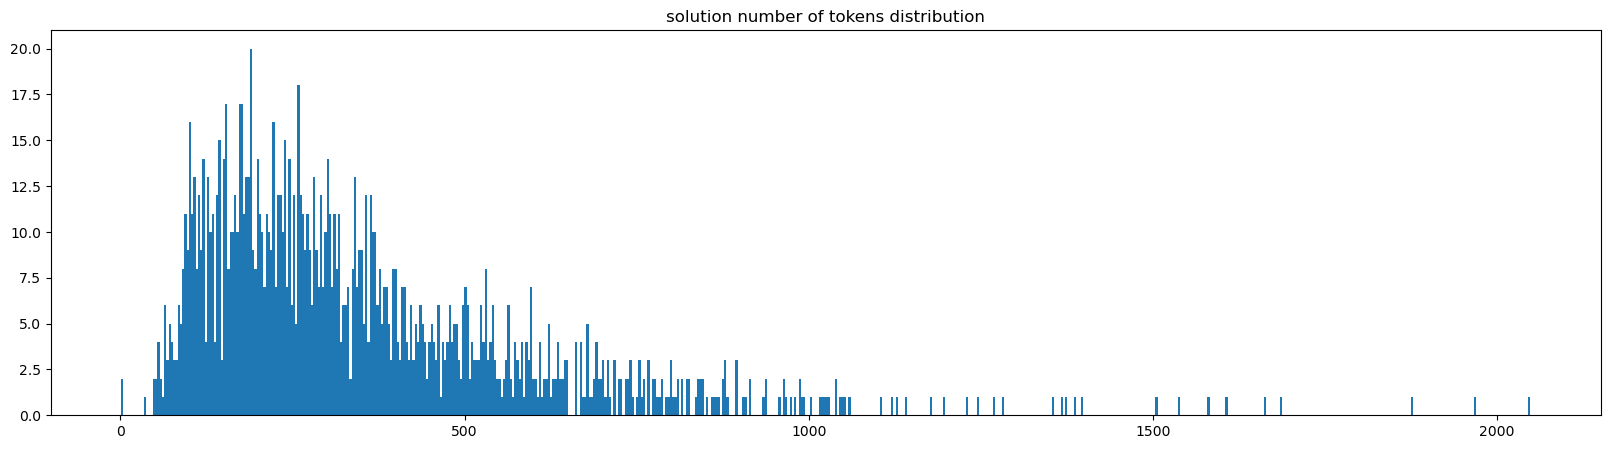

There is 1417 unique solution.


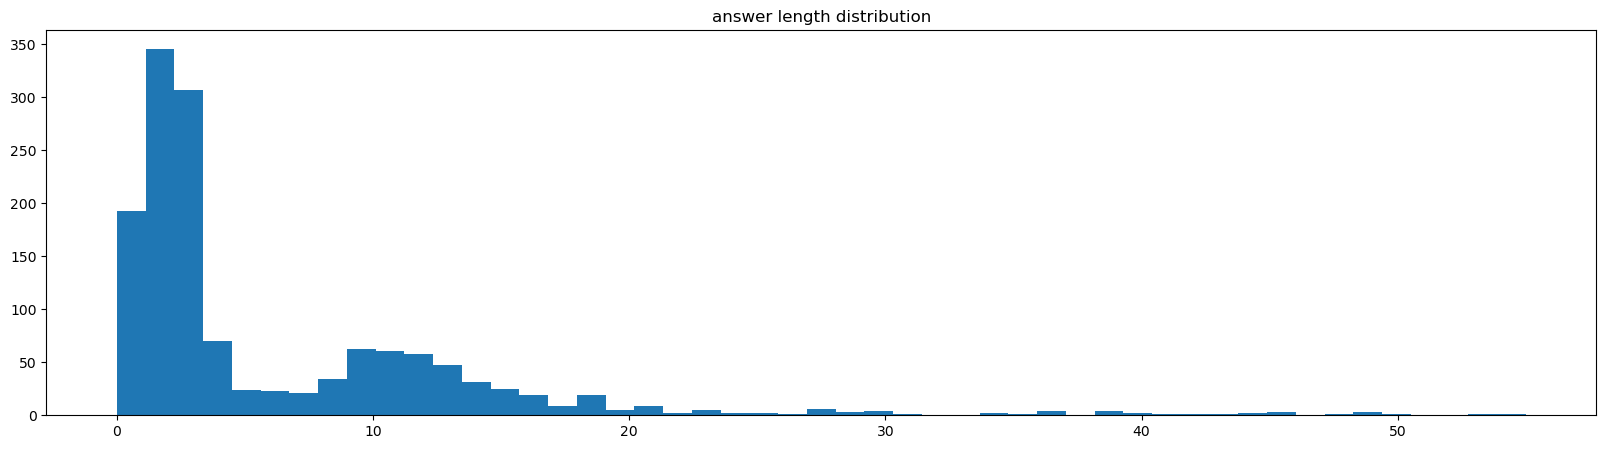

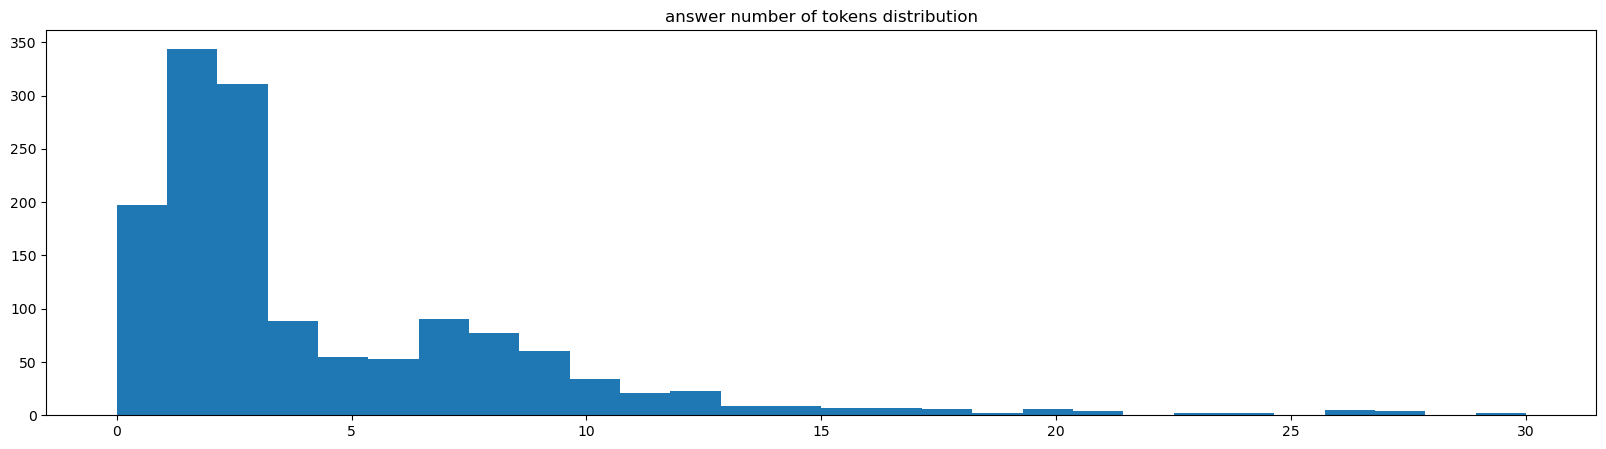

There is 850 unique answer.
Features: ['problem', 'type', 'solution', 'answer']
Number of samples: 856
Sample: {
    "answer": "\\begin{pmatrix} 5/3 \\\\ 5/3 \\\\ 4/3 \\end{pmatrix}",
    "problem": "Soit $\\mathbf{a} = \\begin{pmatrix} 7 \\\\ - 1 \\\\ 4 \\end{pmatrix}$ et $\\mathbf{b} = \\begin{pmatrix} 3 \\\\ 1 \\\\ 2 \\end{pmatrix}.$ Trouver le vecteur $\\mathbf{c}$ tel que $\\mathbf{a},$ $\\mathbf{b},$ et $\\mathbf{c}$ soient collin\u00e9aires, et que $\\mathbf{b}$ bisecte l'angle entre $\\mathbf{a}$ et $\\mathbf{c}.$\n\n[asy]\nunitsize(0.5 cm);\n\npair A, B, C, O;\n\nA = (-2,5);\nB = (1,3);\nO = (0,0);\nC = extension(O, reflect(O,B)*(A), A, B);\n\ndraw(O--A,Arrow(6));\ndraw(O--B,Arrow(6));\ndraw(O--C,Arrow(6));\ndraw(interp(A,C,-0.1)--interp(A,C,1.1),dashed);\n\nlabel($\\mathbf{a}$, A, NE);\nlabel($\\mathbf{b}$, B, NE);\nlabel($\\mathbf{c}$, C, NE);\n[/asy]",
    "solution": "La ligne contenant $\\mathbf{p}$ et $\\mathbf{q}$ peut \u00eatre param\u00e9tr\u00e9e par\n\\[\\mathbf{r} 

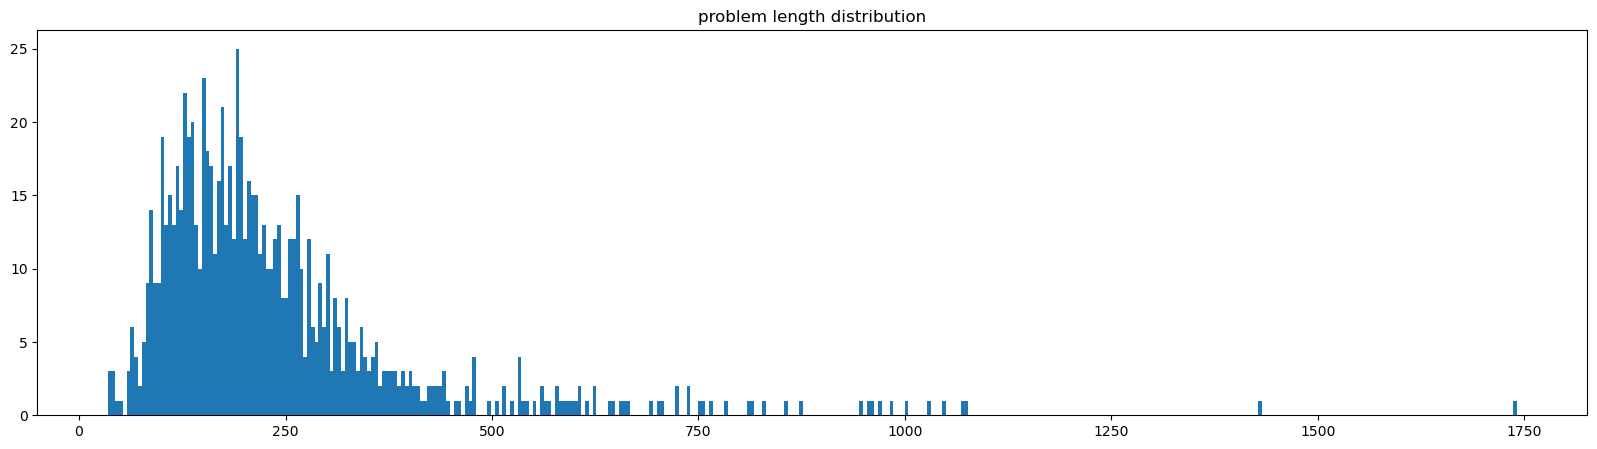

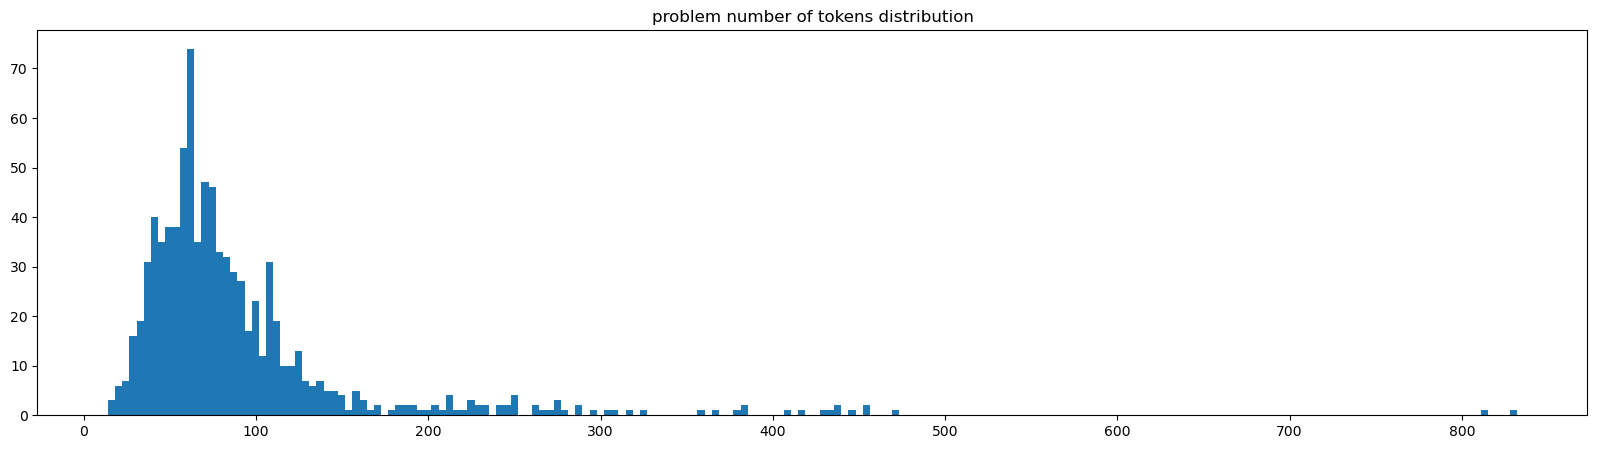

There is 856 unique problem.


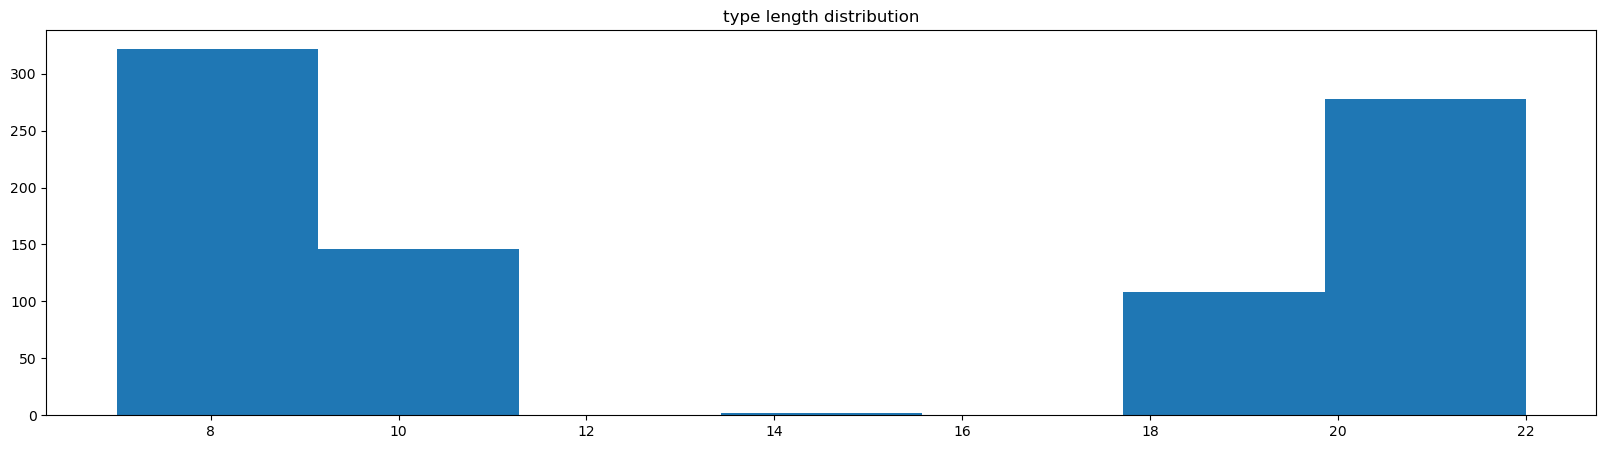

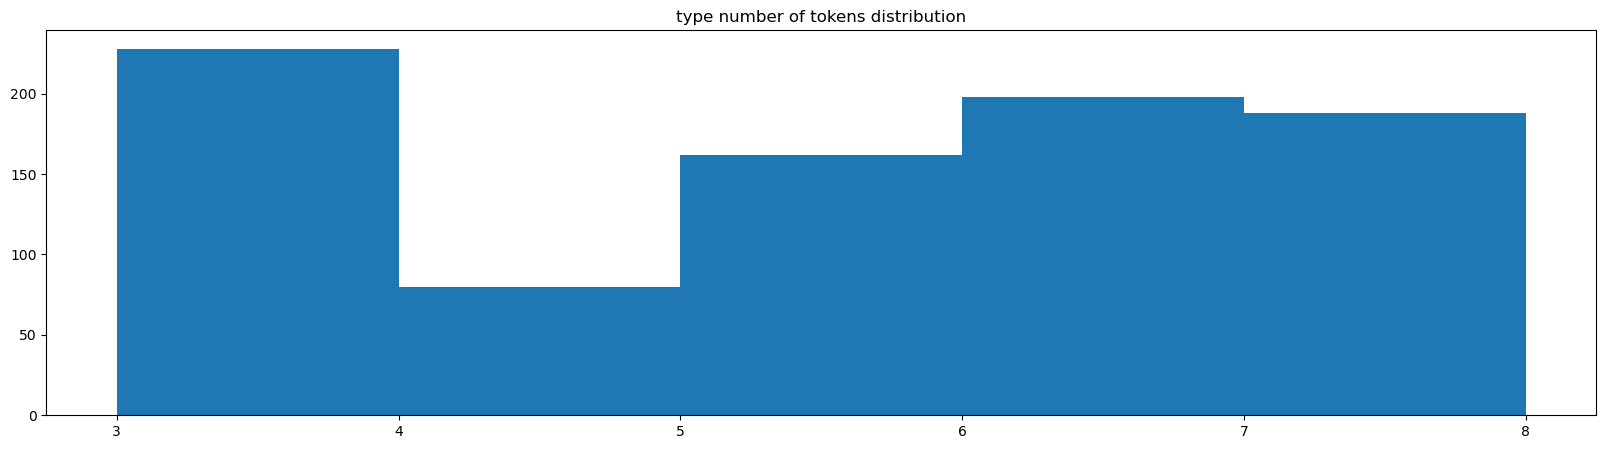

There is 12 unique type.


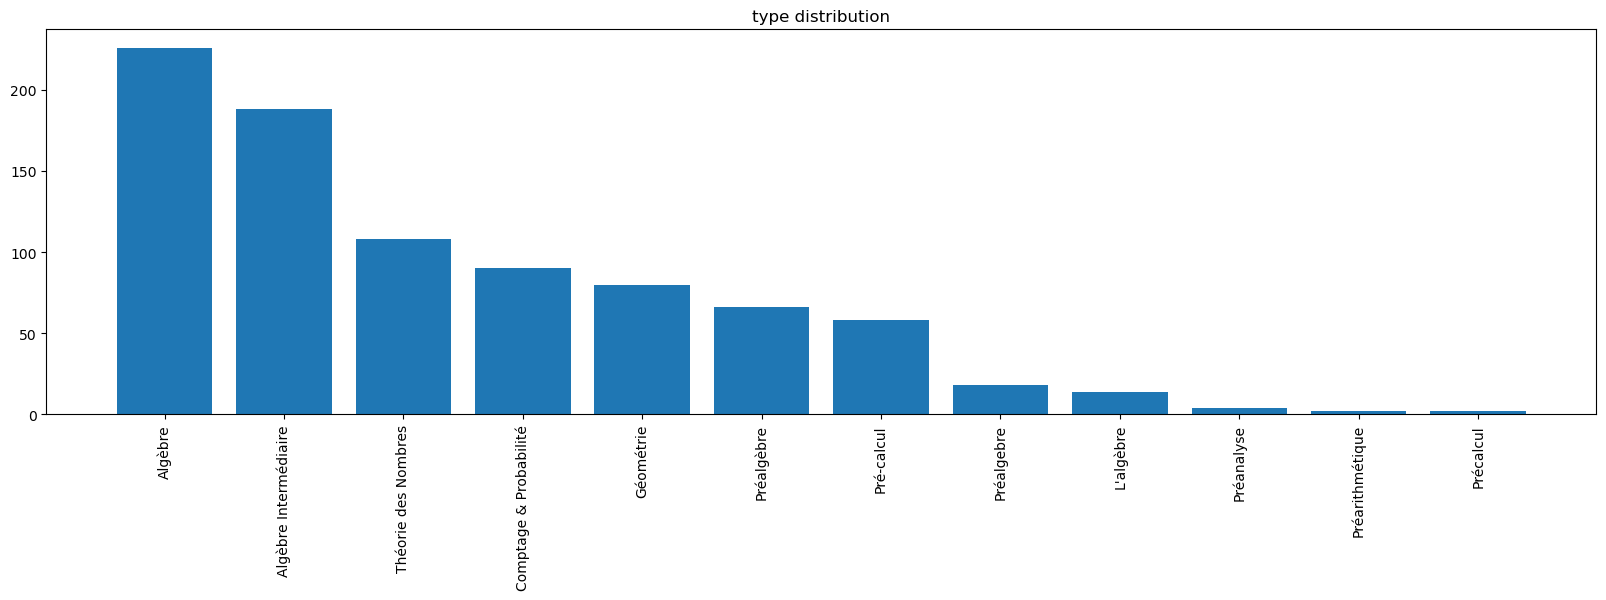

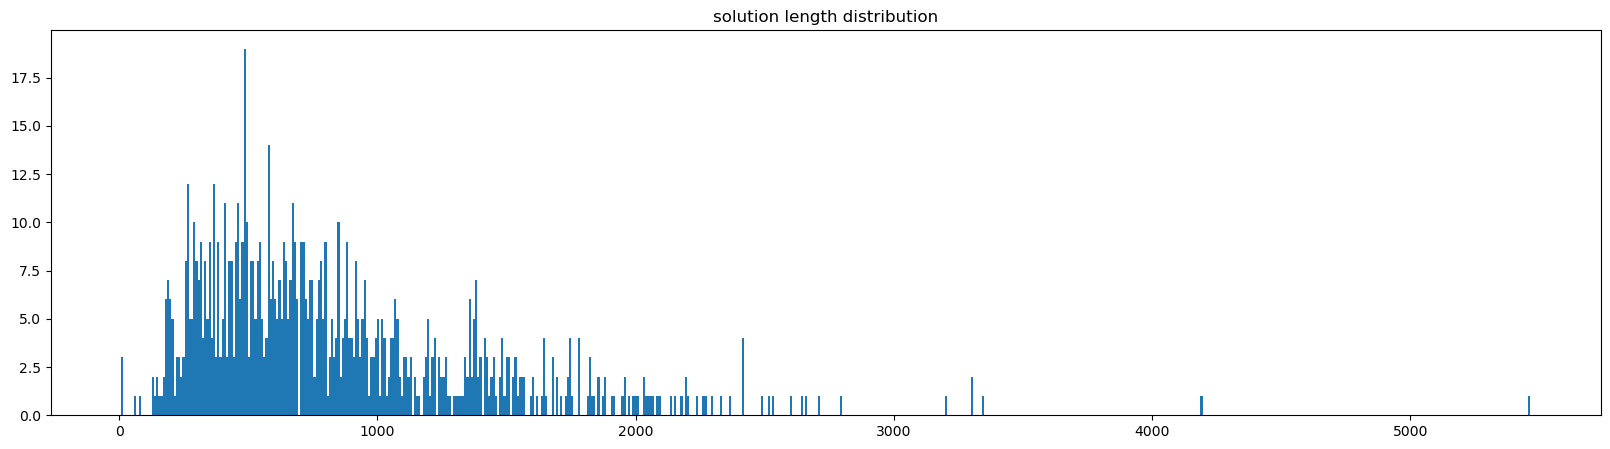

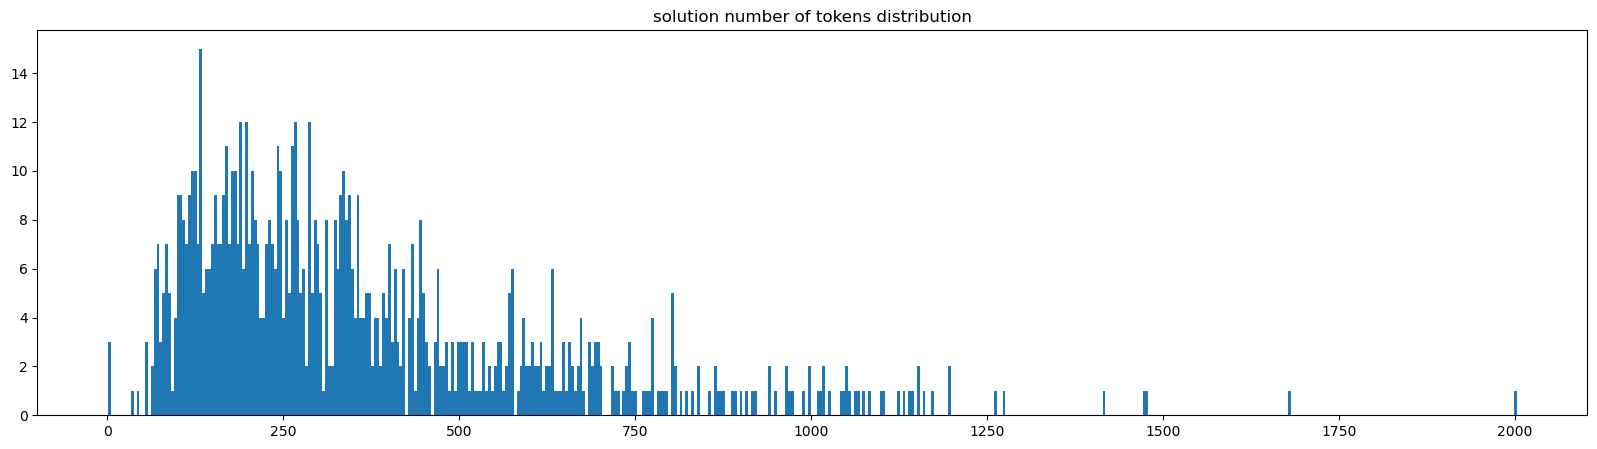

There is 854 unique solution.


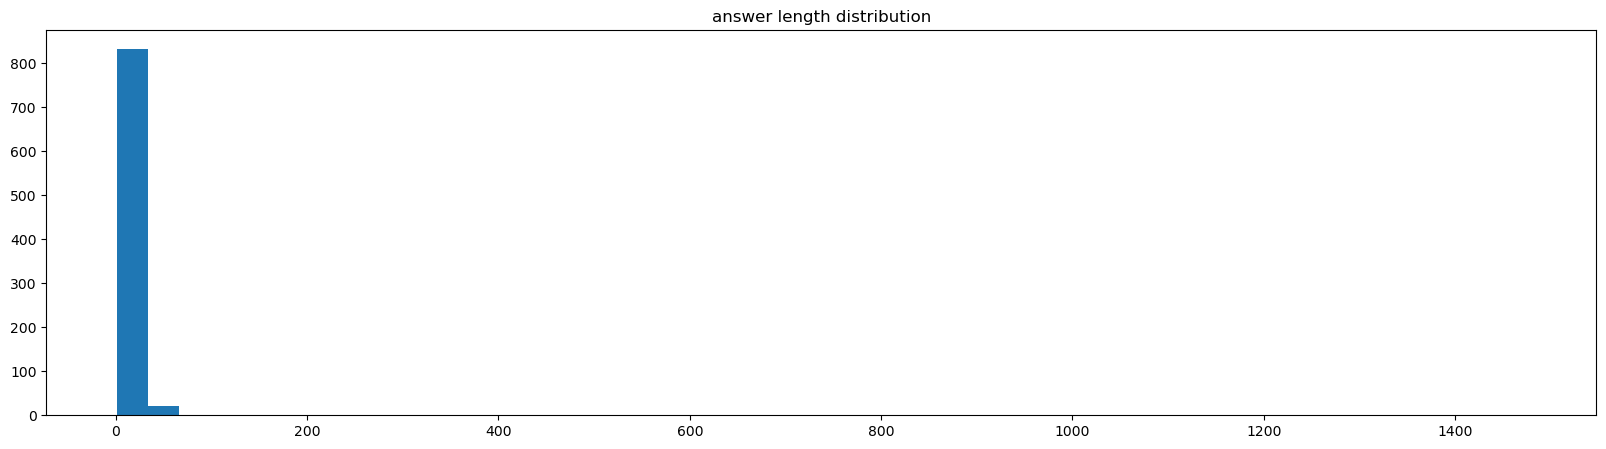

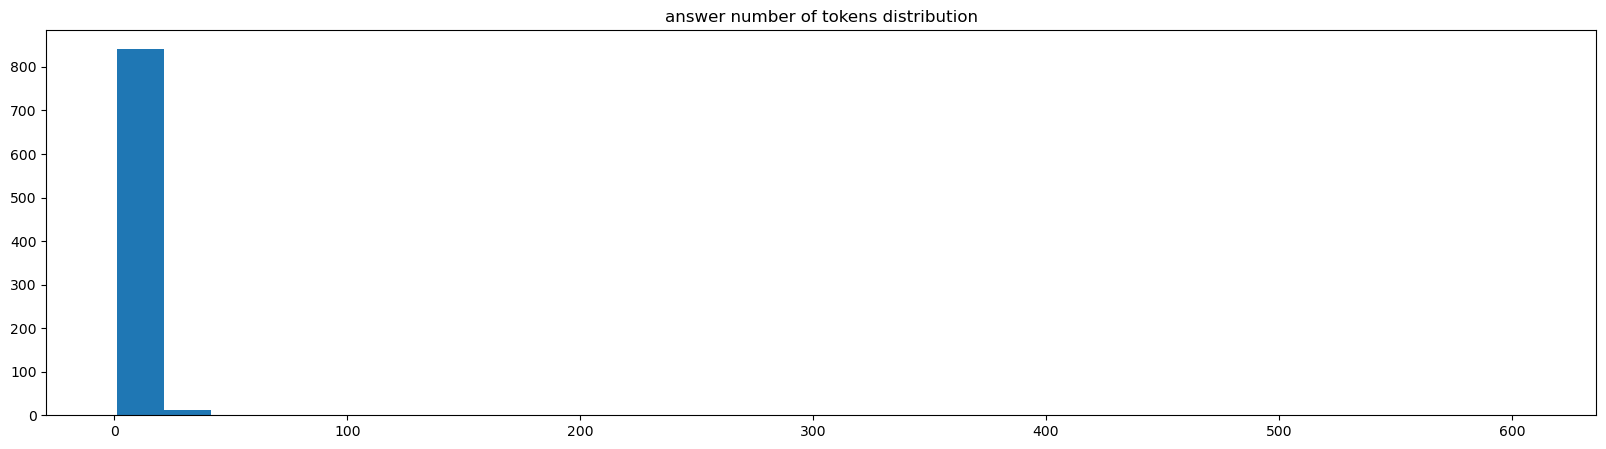

There is 567 unique answer.


In [ ]:
math_lvl5_fr_train = load_data("MATH_LVL5_fr")
math_lvl5_fr_test = load_data("MATH_LVL5_fr", split="test")
math_lvl5_fr_train = math_lvl5_fr_train.add_column(
    "answer",
    [extract_boxed_text(x) for x in math_lvl5_fr_train["output"]]
)
math_lvl5_fr_test = math_lvl5_fr_test.add_column(
    "answer",
    [extract_boxed_text(x) for x in math_lvl5_fr_test["output"]]
)
math_lvl5_fr_train = filter_math_lvl5_fr_train(math_lvl5_fr_train)
print_distributions(math_lvl5_fr_train, ['problem', 'type', 'solution', 'answer'])
print_distributions(math_lvl5_fr_test, ['problem', 'type', 'solution', 'answer'])

### MCLM

Features: ['question', 'answer', 'source']
Number of samples: 156
Sample: {
    "answer": "13",
    "question": "Quelle est la distance la plus courte qui peut \u00eatre parcourue si vous commencez \u00e0 n'importe quel point, $A$, $B$, $C$, ou $D$, et visitez les trois autres points une fois ?\n\n[asy]\npair A,B,C, D;\nA = (-3,3); B = (3,0); C = (0, -4); D = (0,0);\ndraw(D--B--C--cycle); draw(D--A--B--cycle);draw(D--A--C--cycle);\nlabel(\"$A$\", A, NW);label(\"$B$\", B, E); label(\"$C$\", C, S);label(\"$D$\", D, NE);\nlabel(\"3\", D--B, S); label(\"6\", A--B, NE); label(\"6\", A--C, SW); label(\"4\", D--C, NW+N);\nlabel(\"5\", A--D, SE+NE); label(\"5\", C--B, E);\n[/asy]",
    "source": "mt-math100"
}


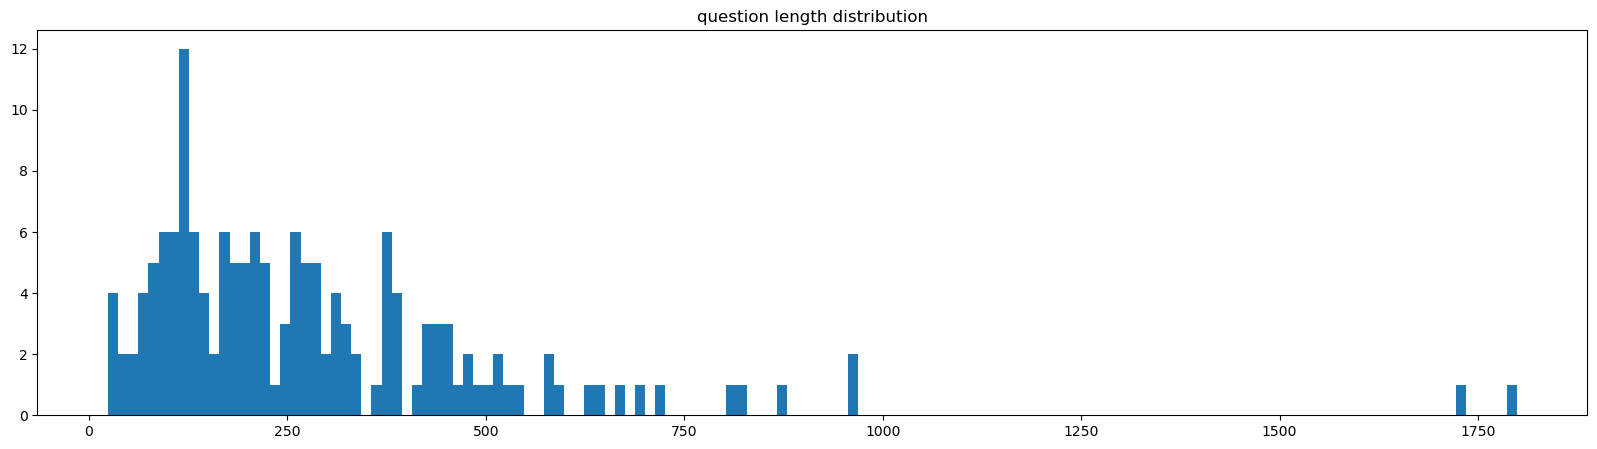

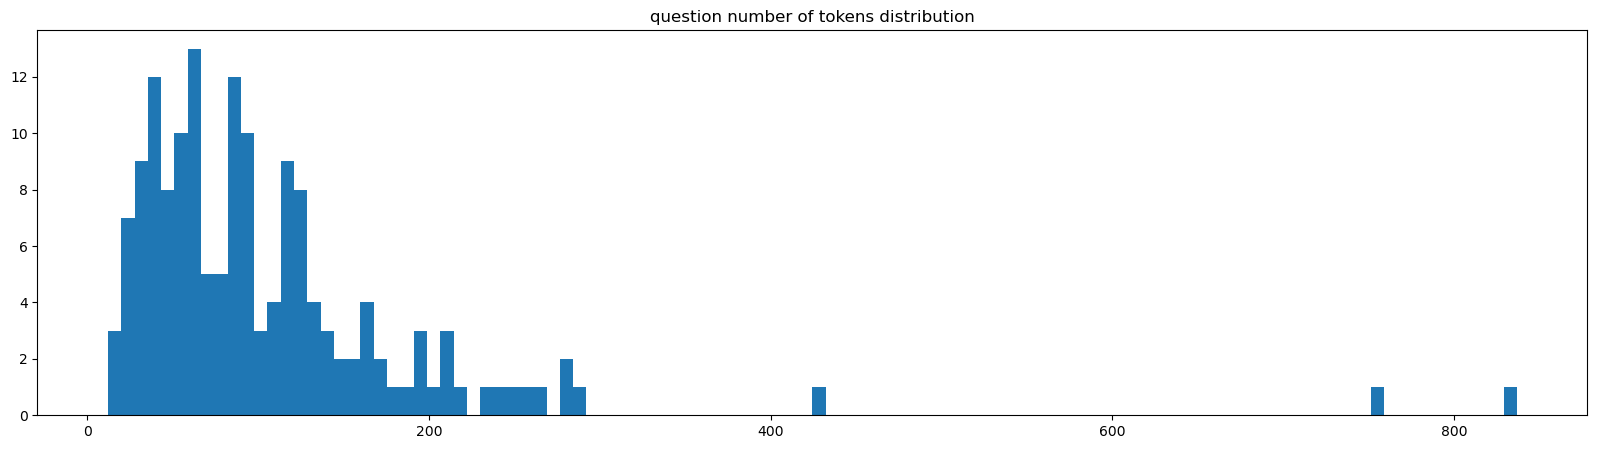

There is 156 unique question.


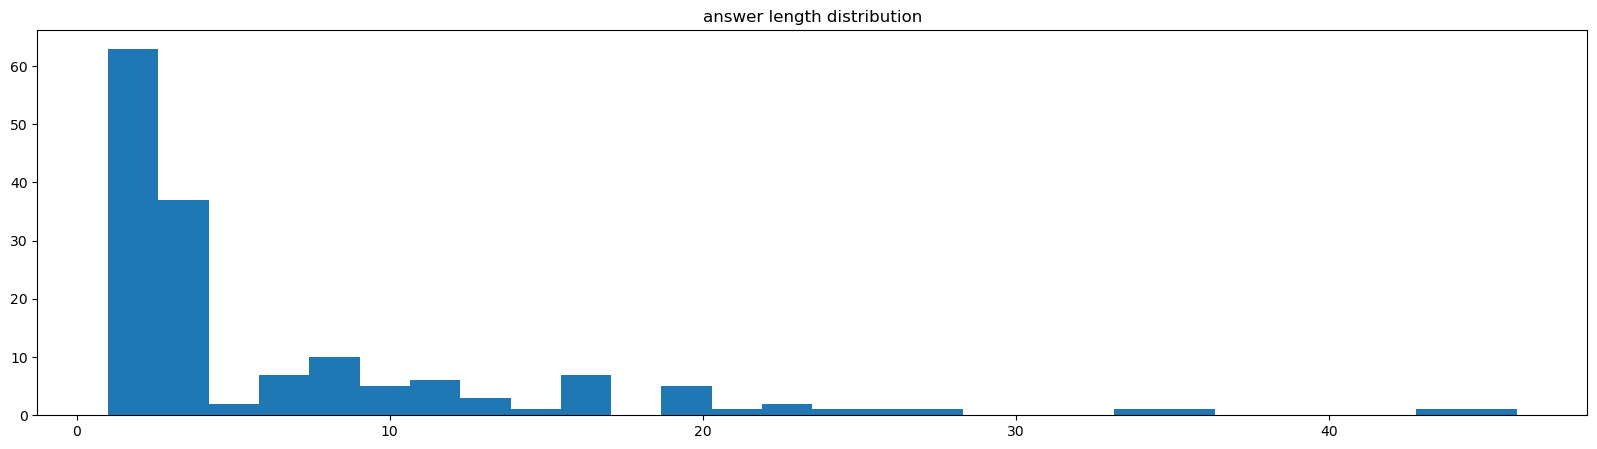

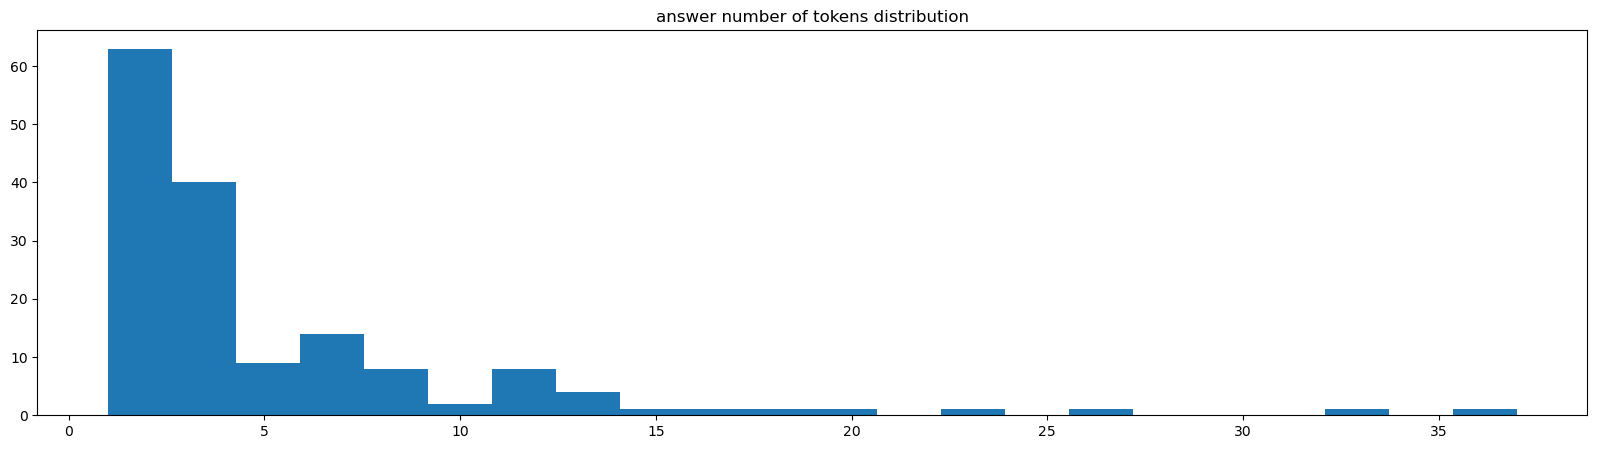

There is 129 unique answer.


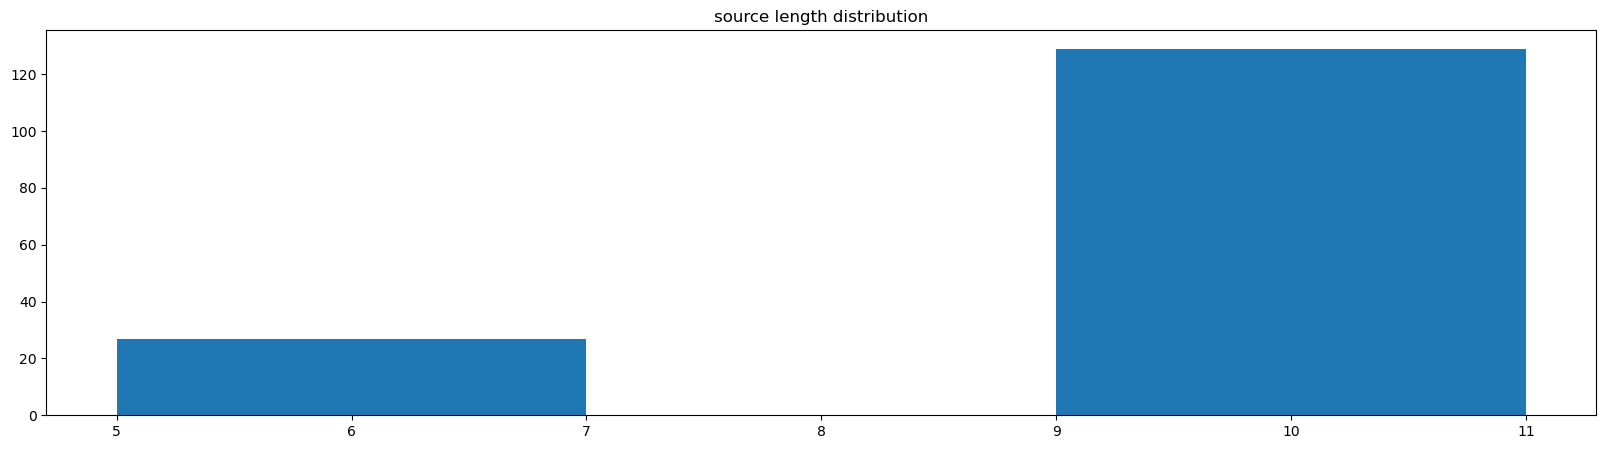

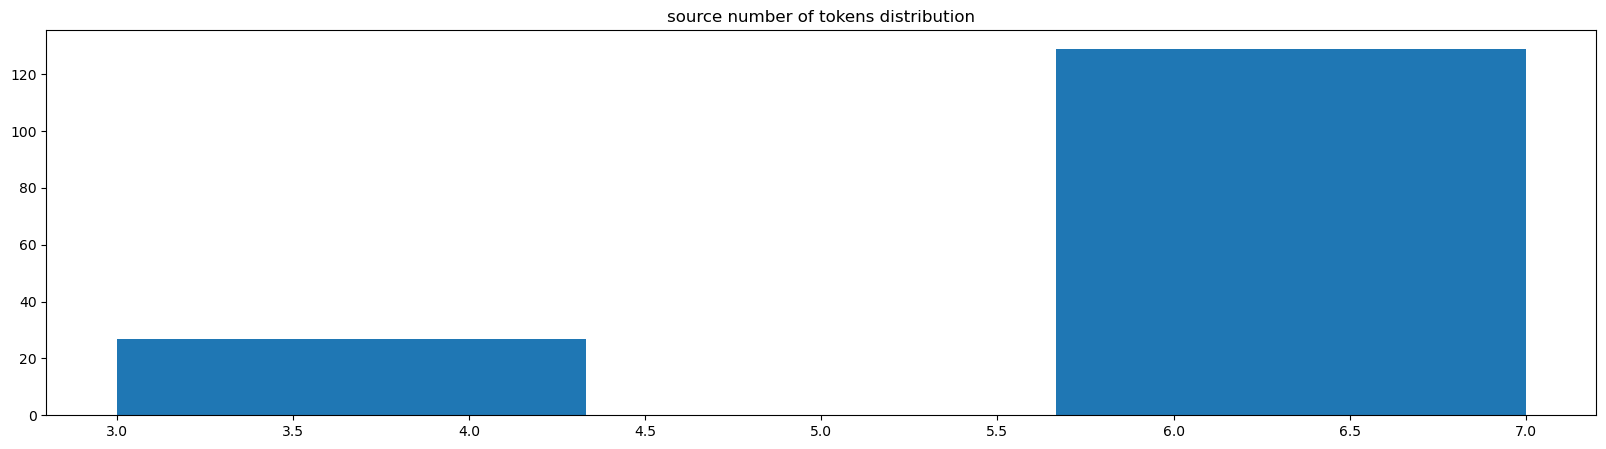

There is 3 unique source.


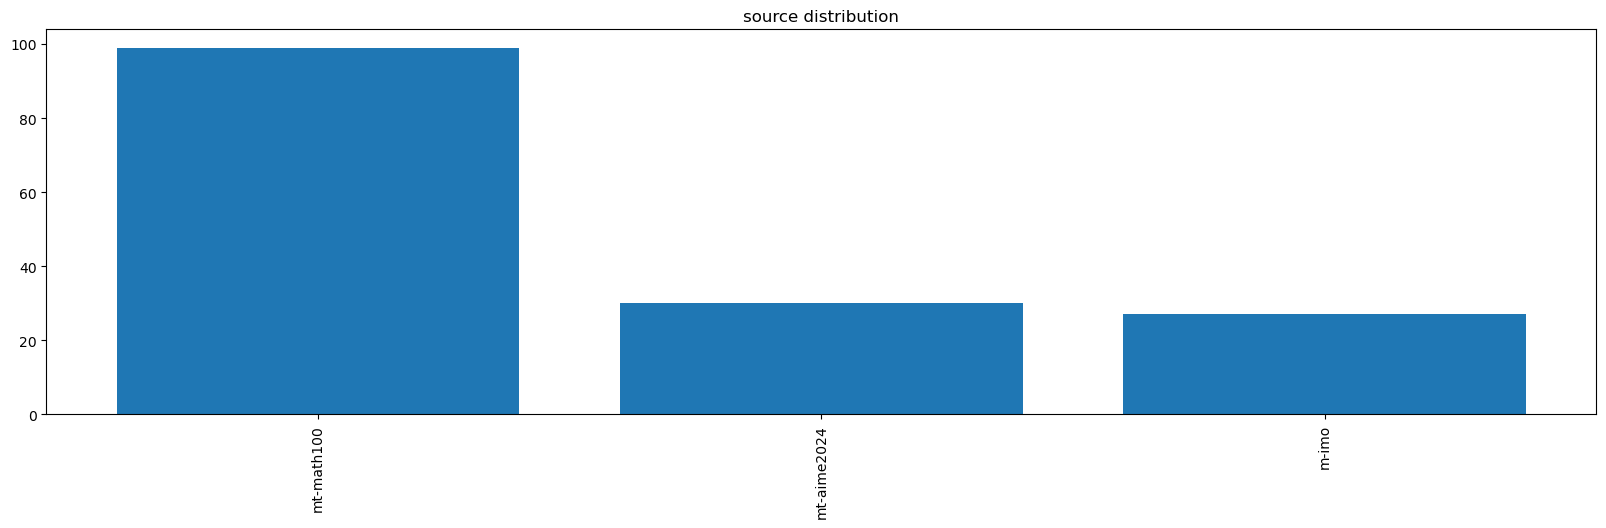

In [3]:
mclm = {
    "question": [],
    "answer": [],
    "source": [],
}

for subset in ["m-imo", "mt-aime2024", "mt-math100"]:
    mclm_subset = load_data("MCLM", data_files=subset+".parquet")
    mclm_subset = mclm_subset.remove_columns(set(mclm_subset.features.keys()) - set(["fr", "answer"]))
    mclm_subset = mclm_subset.cast_column("answer", Value(dtype="string"))
    mclm["question"].extend(mclm_subset["fr"])
    mclm["answer"].extend(mclm_subset["answer"])
    mclm["source"].extend([subset] * len(mclm_subset["fr"]))

mclm = Dataset.from_dict(mclm)
print_distributions(mclm, ['question', 'answer', 'source'])


### MGSM

Features: ['question', 'answer']
Number of samples: 250
Sample: {
    "answer": "5,600",
    "question": "Lundi, Sue a mang\u00e9 4 fois plus de biscuits que sa s\u0153ur. Mardi, elle en a mang\u00e9 deux fois plus que sa s\u0153ur. Sa s\u0153ur a mang\u00e9 5 biscuits lundi et en a mang\u00e9 13 le lendemain. Si 1 biscuit contient 200 calories, combien de calories de plus que sa s\u0153ur Sue a-t-elle consomm\u00e9es ?"
}


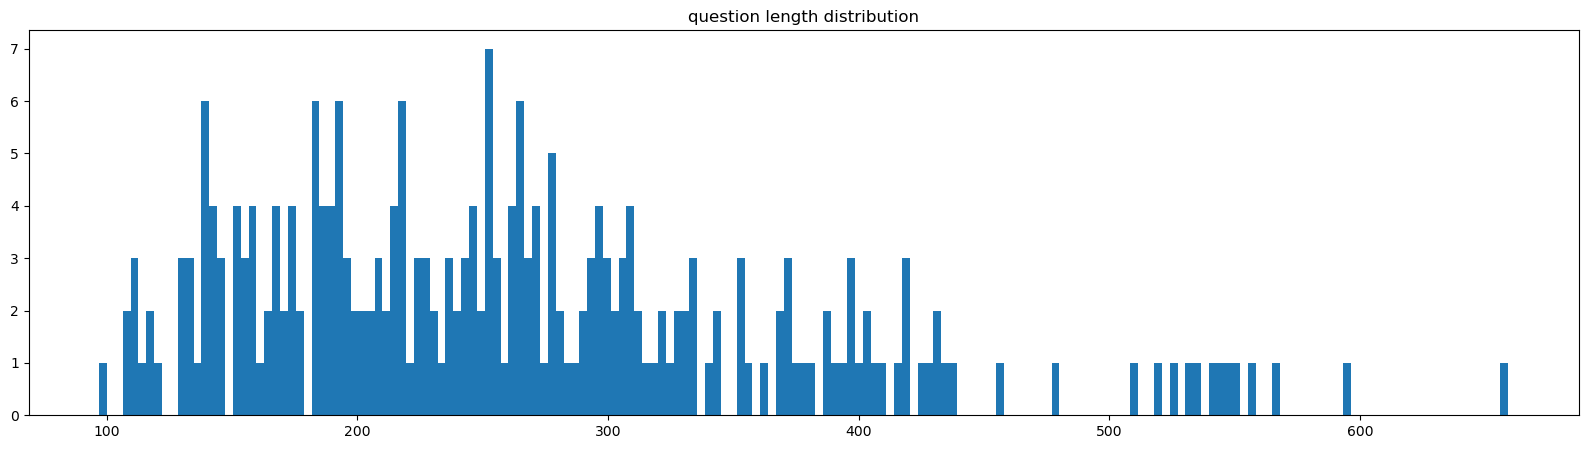

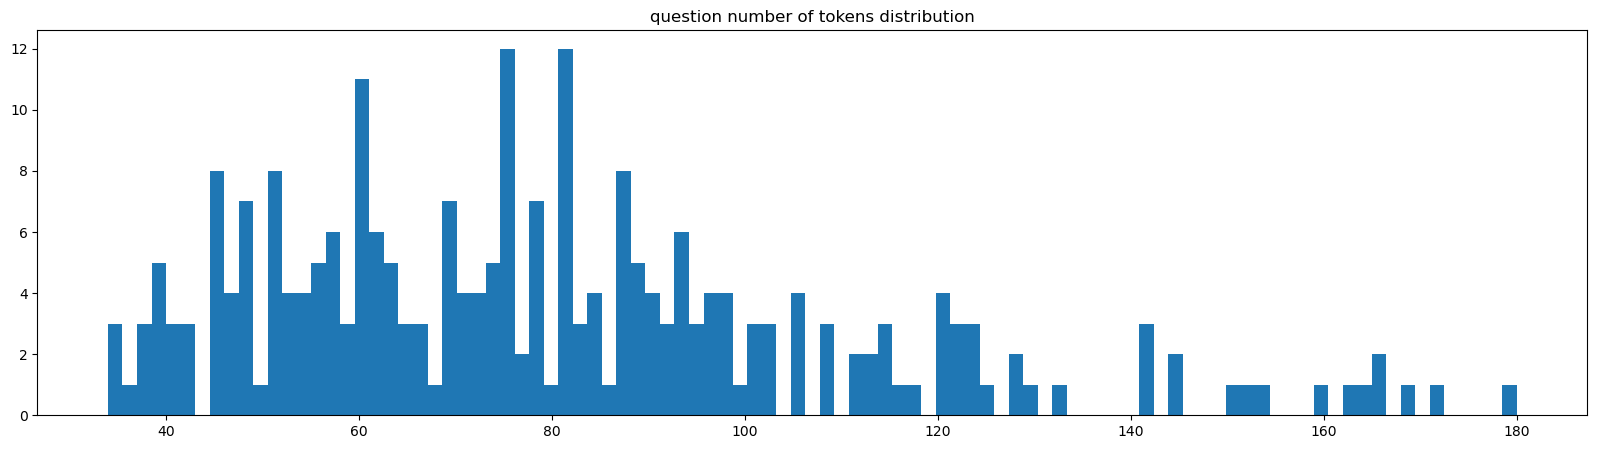

There is 250 unique question.


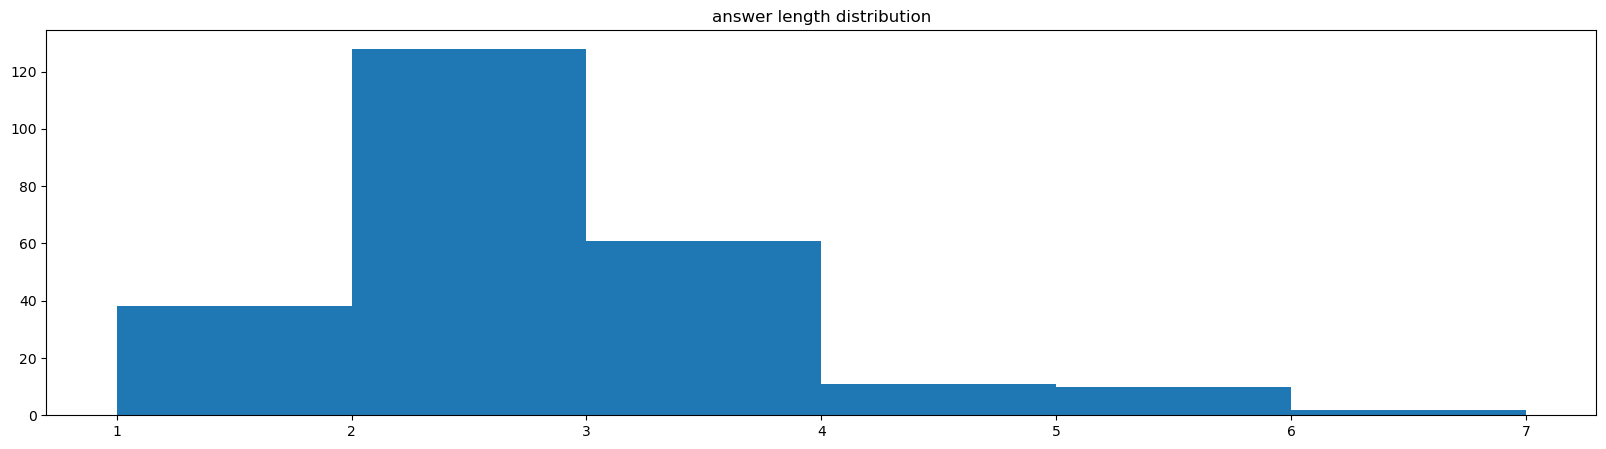

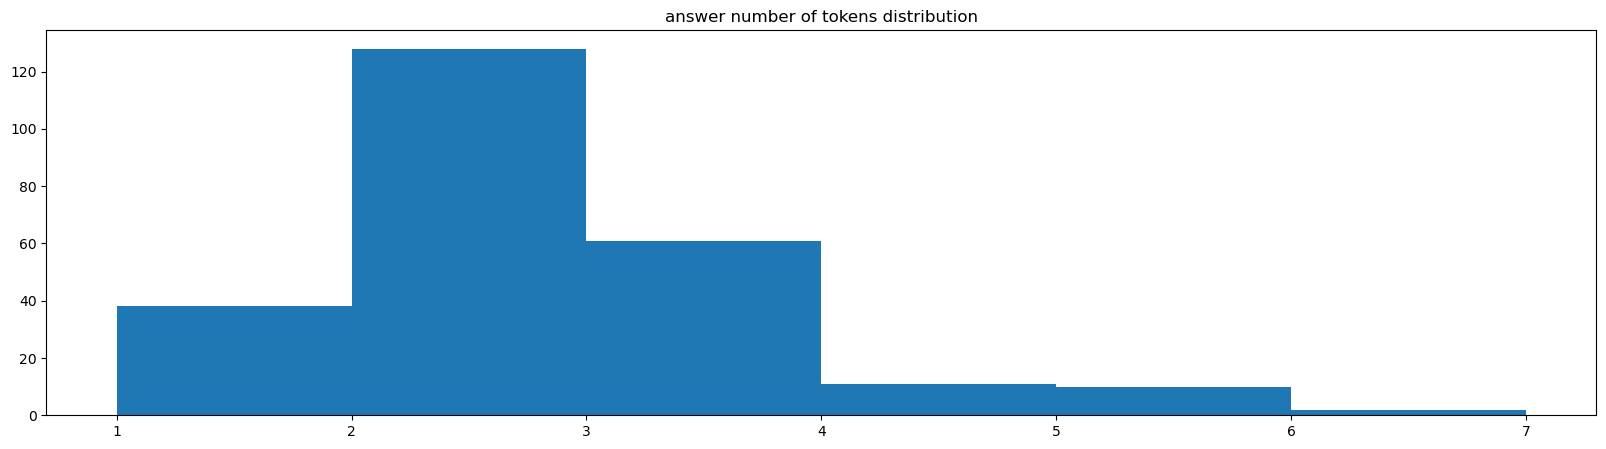

There is 134 unique answer.


In [ ]:
mgsm = Dataset.from_pandas(pd.read_csv(
    config.DATA_PATHS[2]+"MGSM/mgsm_fr.tsv", sep="\t", header=None, names=["question", "answer"]
))
print_distributions(mgsm, ['question', 'answer'])

### MSVAMP

Features: ['query', 'equation', 'response', 'm_query']
Number of samples: 1000
Sample: {
    "equation": "* number0 number1",
    "m_query": "L'\u00e9cole compte 304 classes et chaque classe compte 75 \u00e9l\u00e8ves. Combien d'\u00e9l\u00e8ves y avait-il au total ?",
    "query": "the school has 304 grades and each grade has 75 students how many students were there in total ?",
    "response": "22800.0"
}


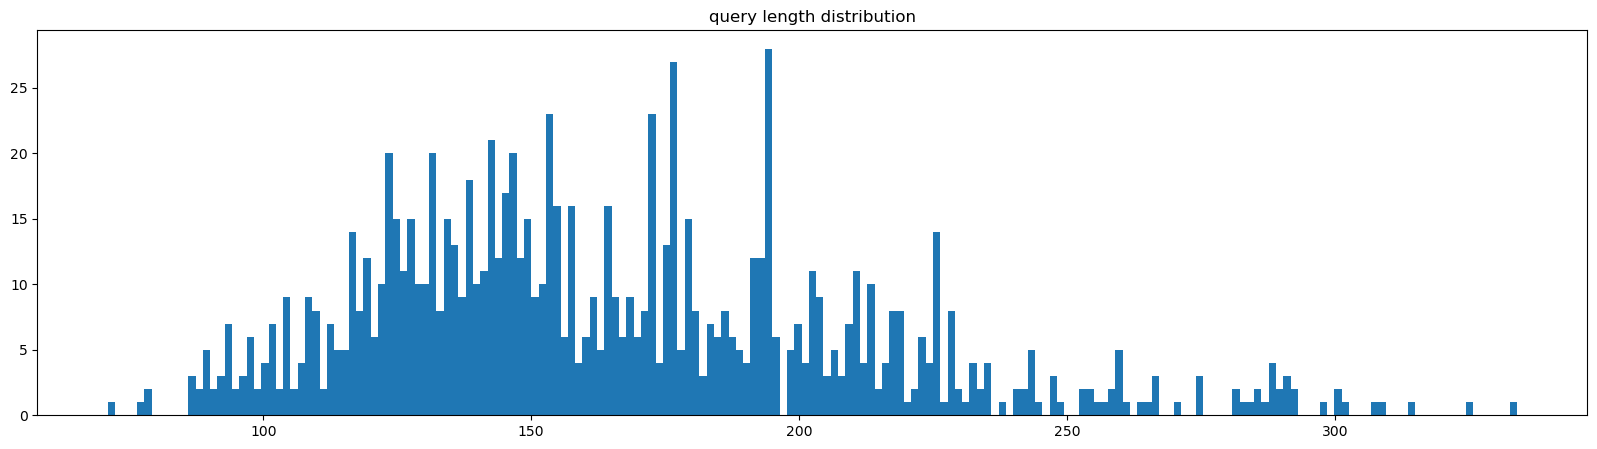

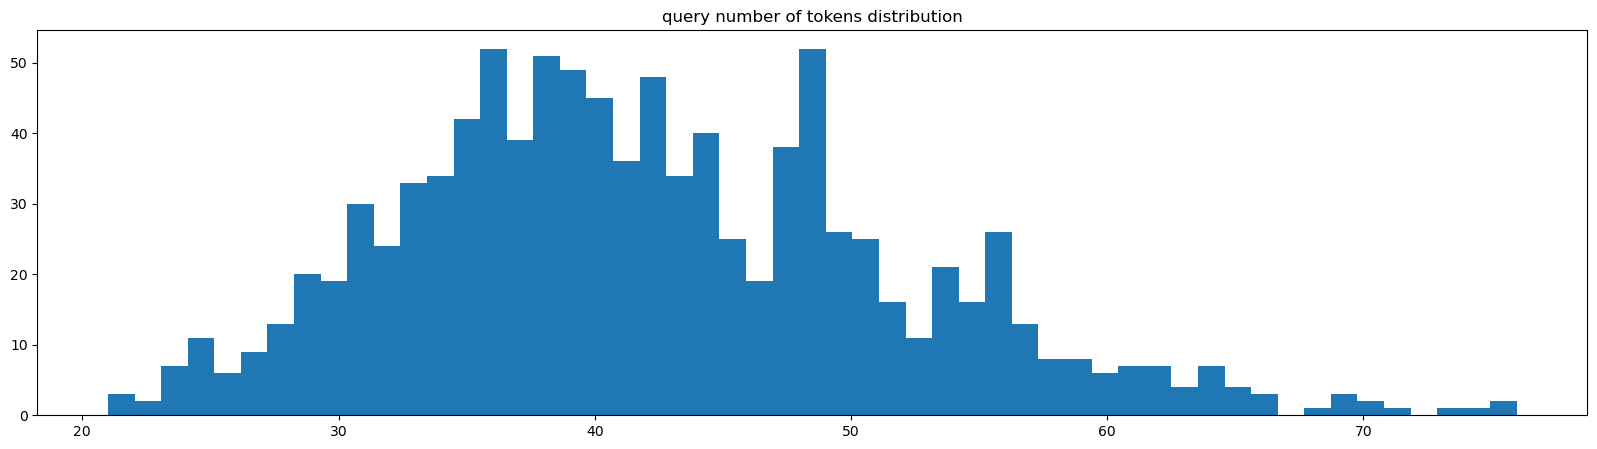

There is 1000 unique query.


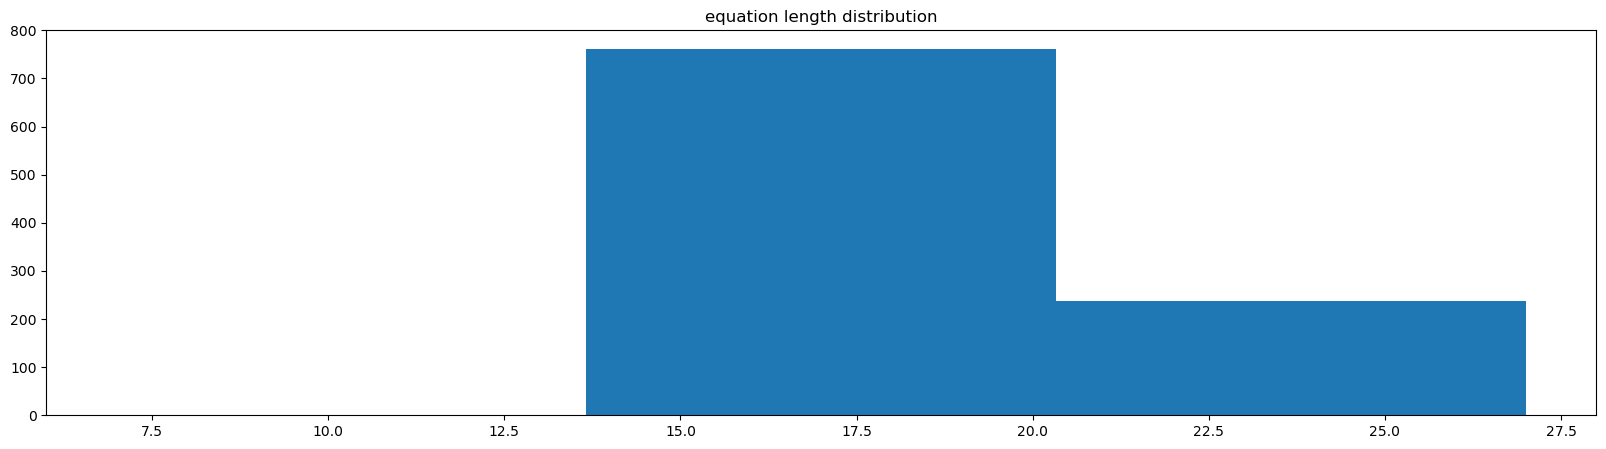

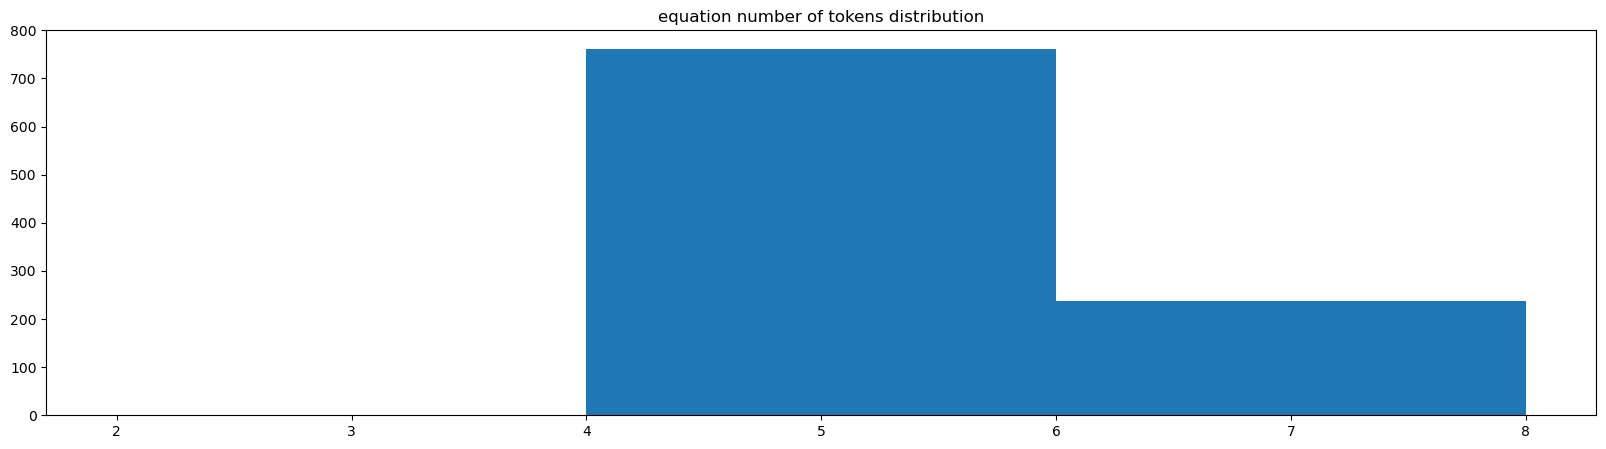

There is 116 unique equation.


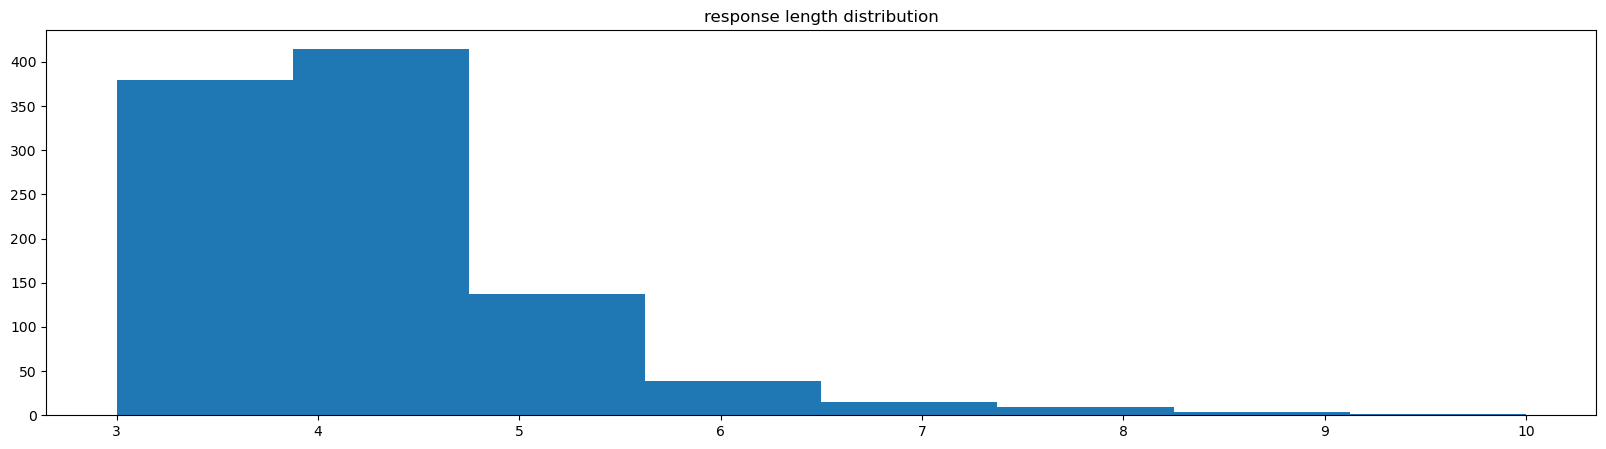

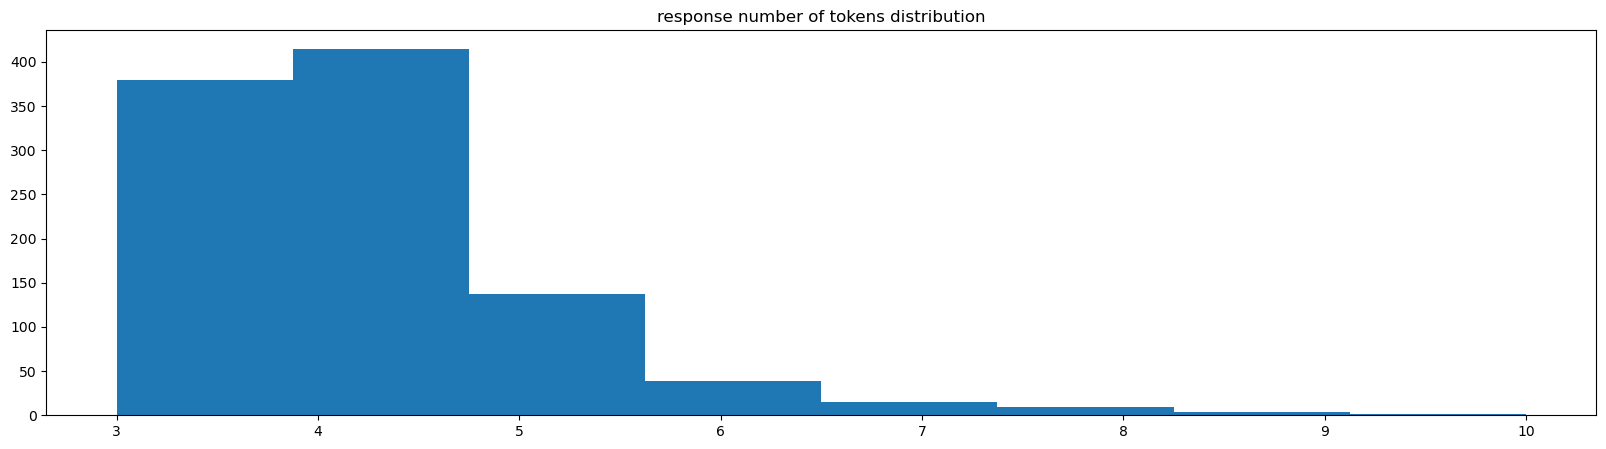

There is 272 unique response.


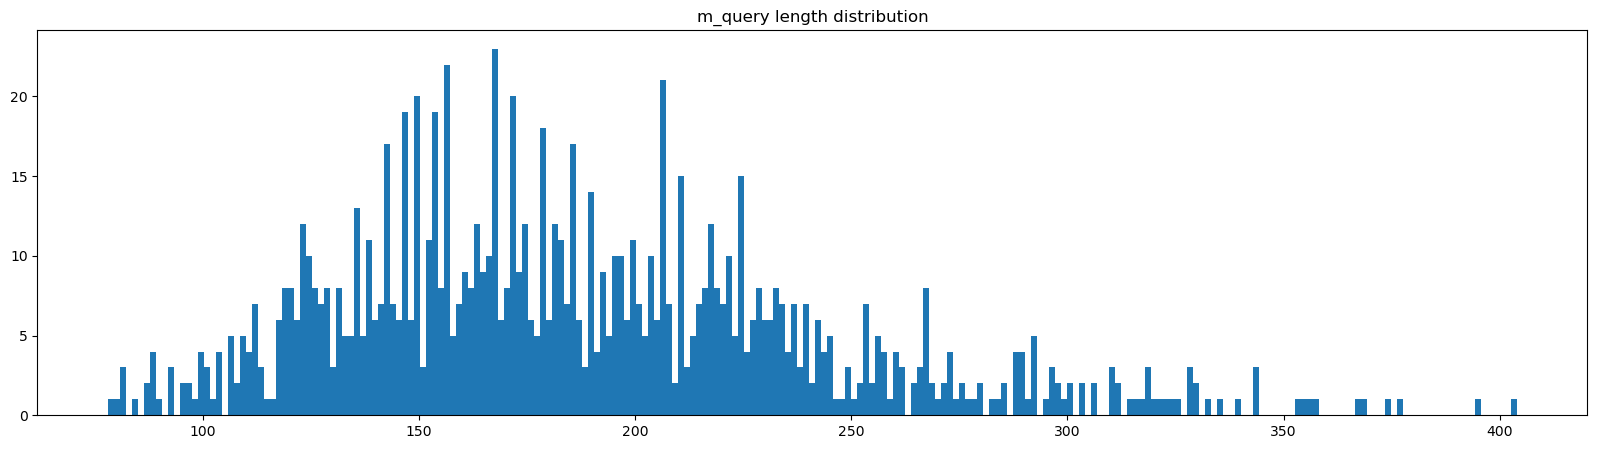

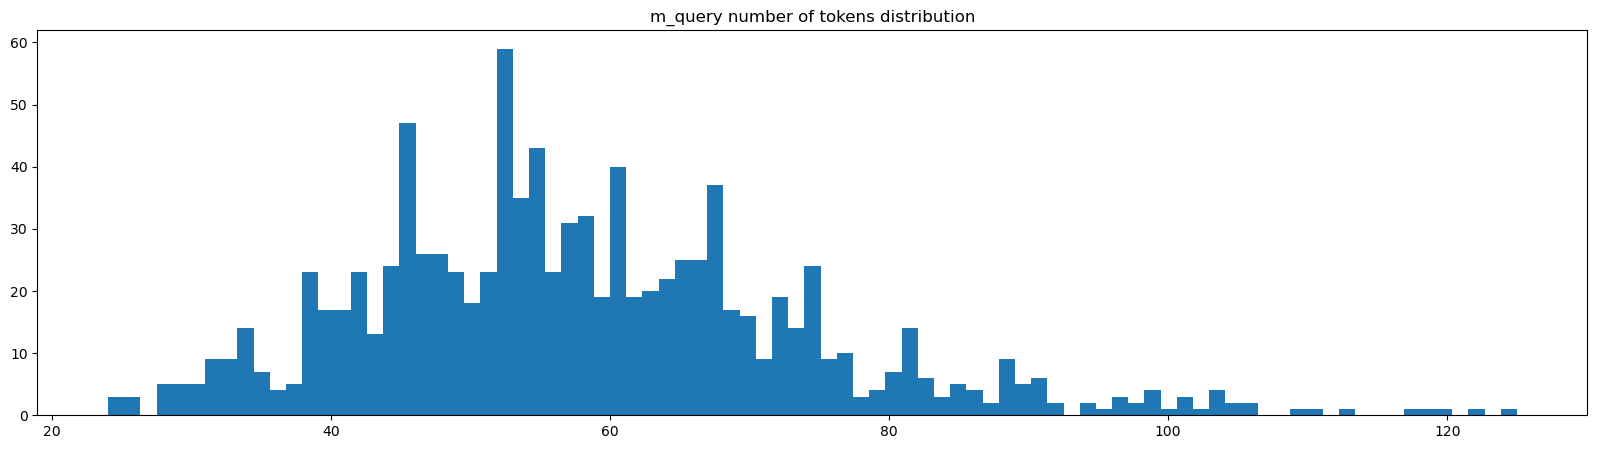

There is 1000 unique m_query.


In [5]:
msvamp = load_data("MSVAMP", split="test")
print_distributions(msvamp, ['query', 'equation', 'response', 'm_query'])

### MegaMath-Web-Pro

Features: ['text', 'cc-path', 'domain', 'lang', 'lang_score', 'timestamp', 'url', 'math_score', 'timestamp_unformatted']
Number of samples: 10000
Sample: {
    "cc-path": "CC-MAIN-2023-14/segments/1679296945183.40/warc/CC-MAIN-20230323194025-20230323224025-00430.warc.gz",
    "domain": "statisticsfromatoz.com",
    "lang": "en",
    "lang_score": 0.9279012084007263,
    "math_score": 0.9802665710449219,
    "text": "## Statistics Tip of the Week: Establishing Correlation is a Prerequisite for Linear Regression\n\nEstablishing correlation is a prerequisite for linear regression. Linear regression cannot be used unless there is a linear correlation between variables. The key differences between correlation analysis and linear regression are outlined below.\n\nCorrelation analysis is used to determine the degree to which two variables vary in sync, without attempting to identify a cause-effect relationship. It primarily uses the correlation coefficient (r) and is limited to two variables,

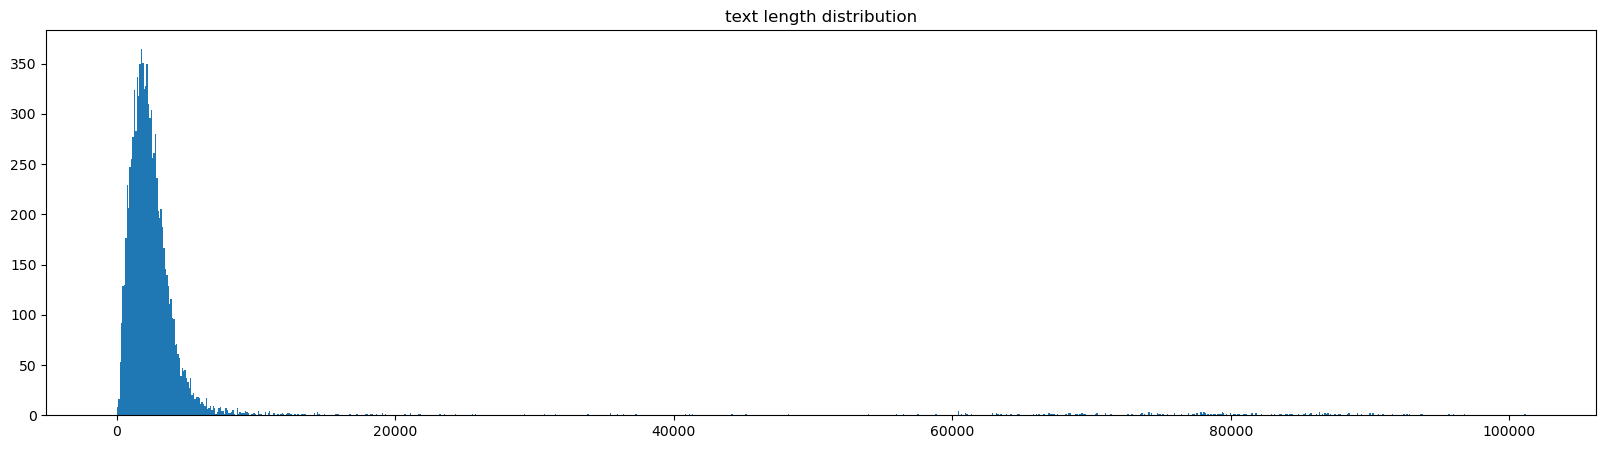

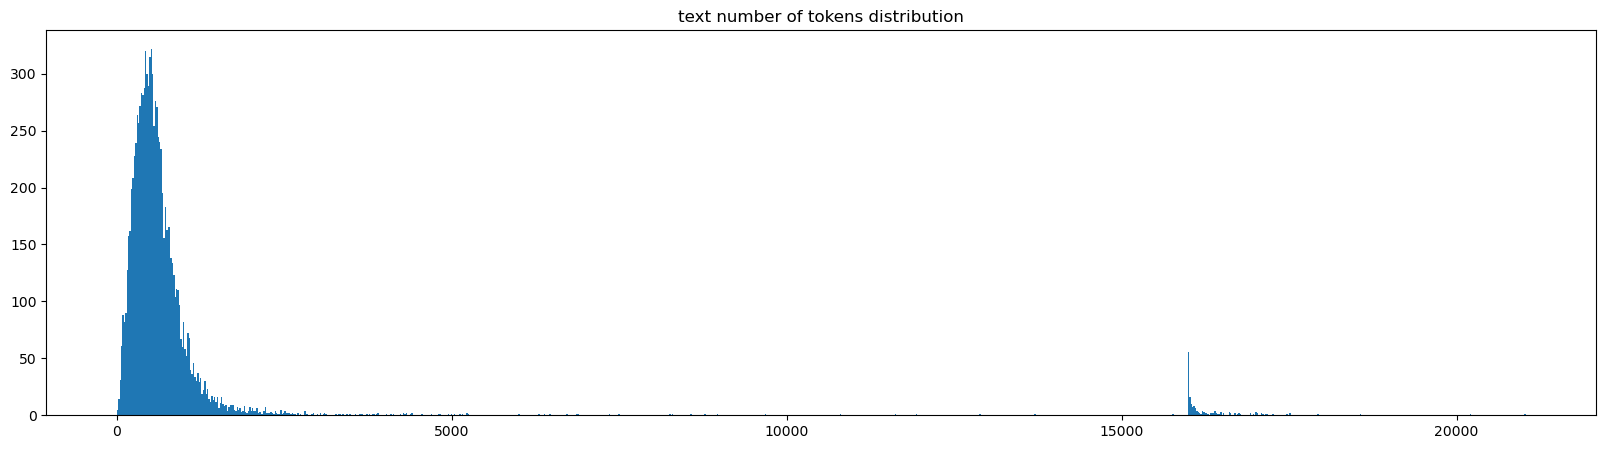

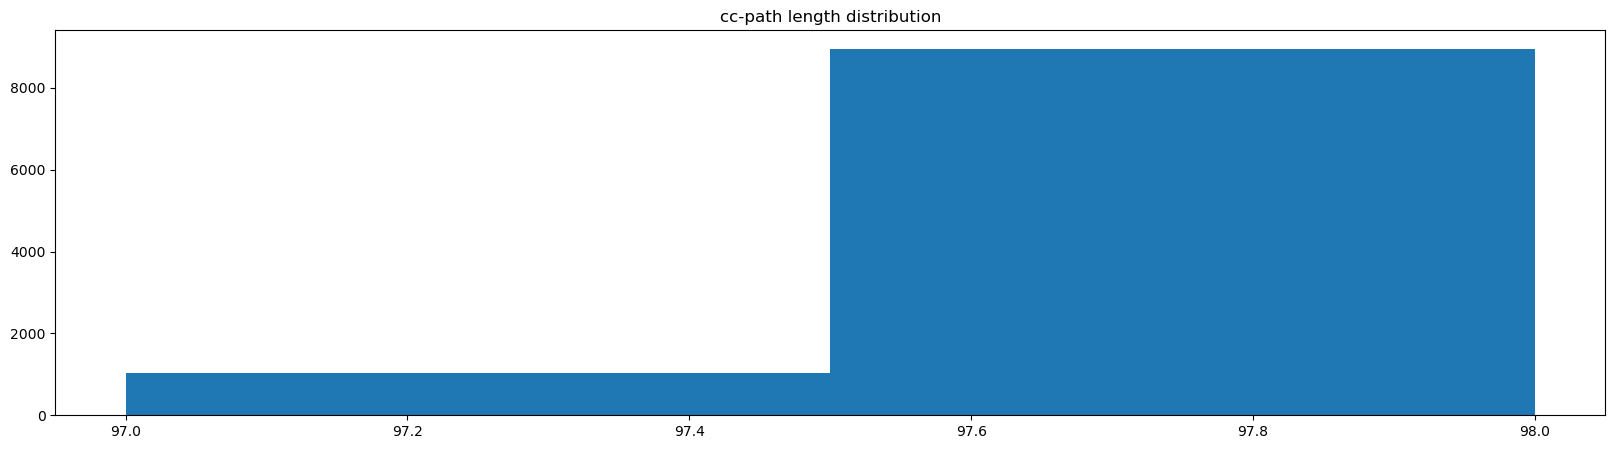

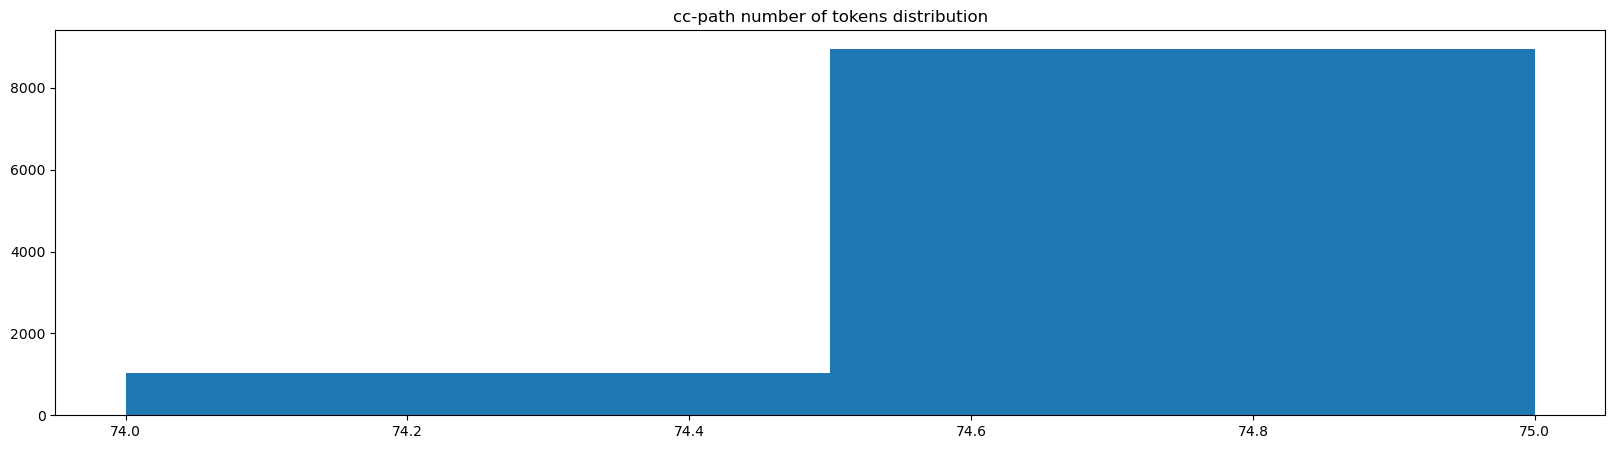

There is 5197 unique cc-path.


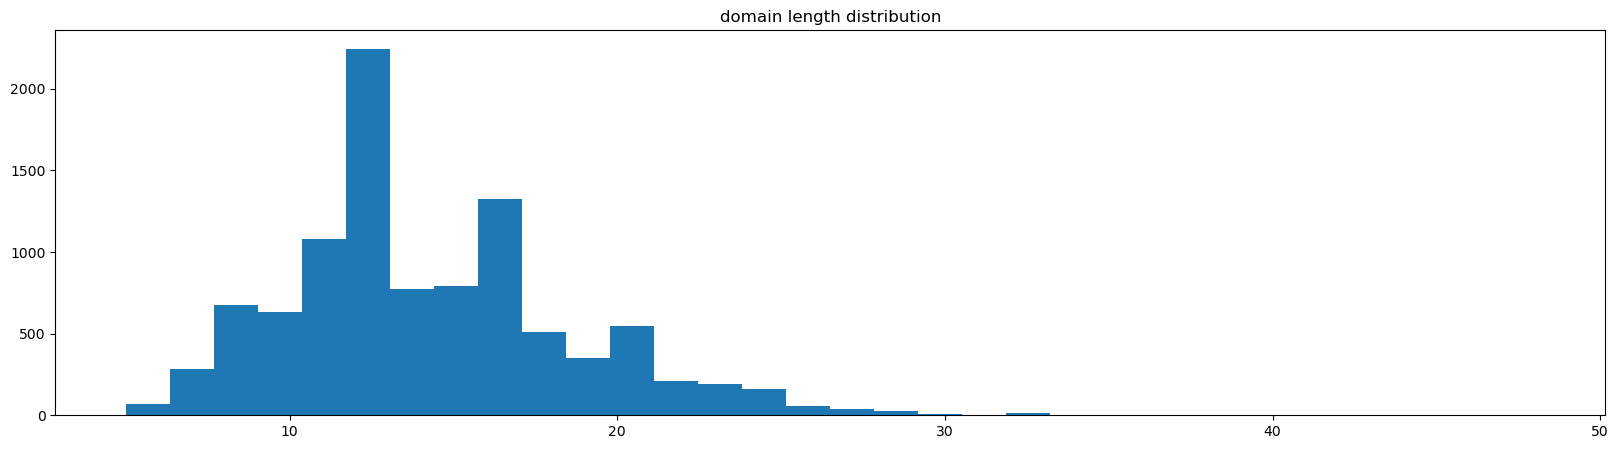

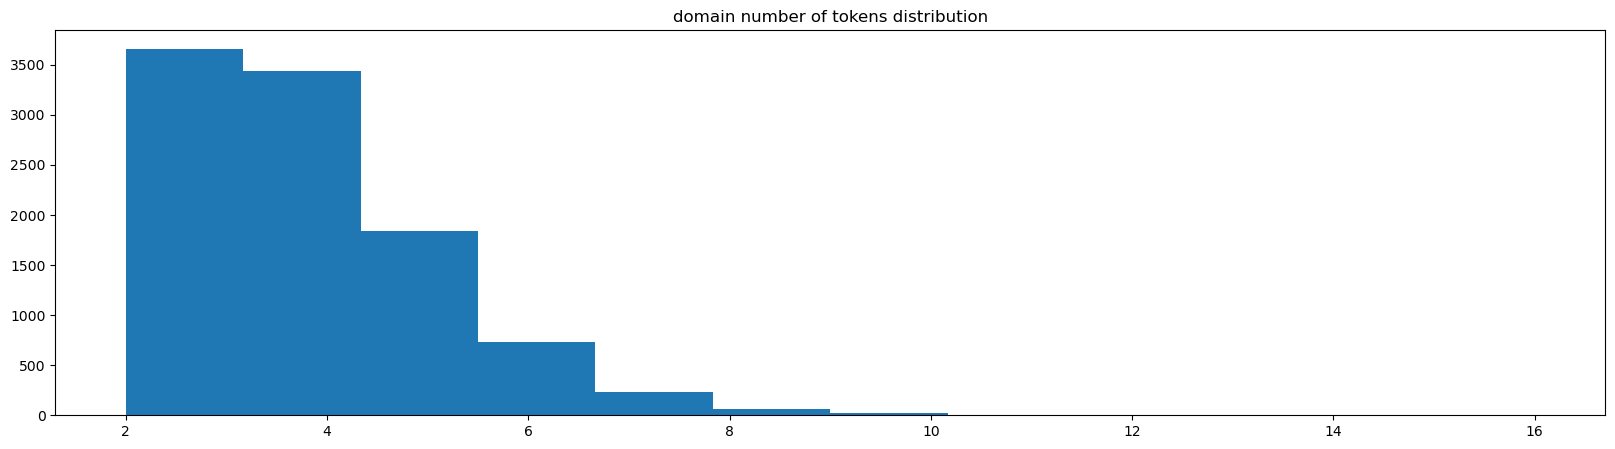

There is 5078 unique domain.


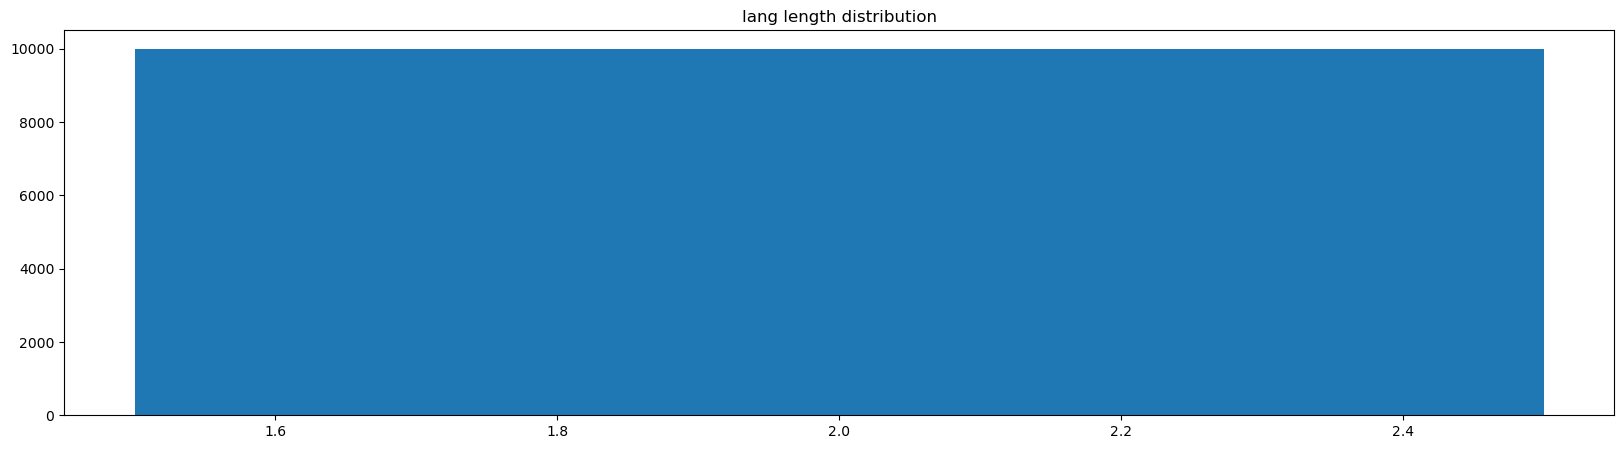

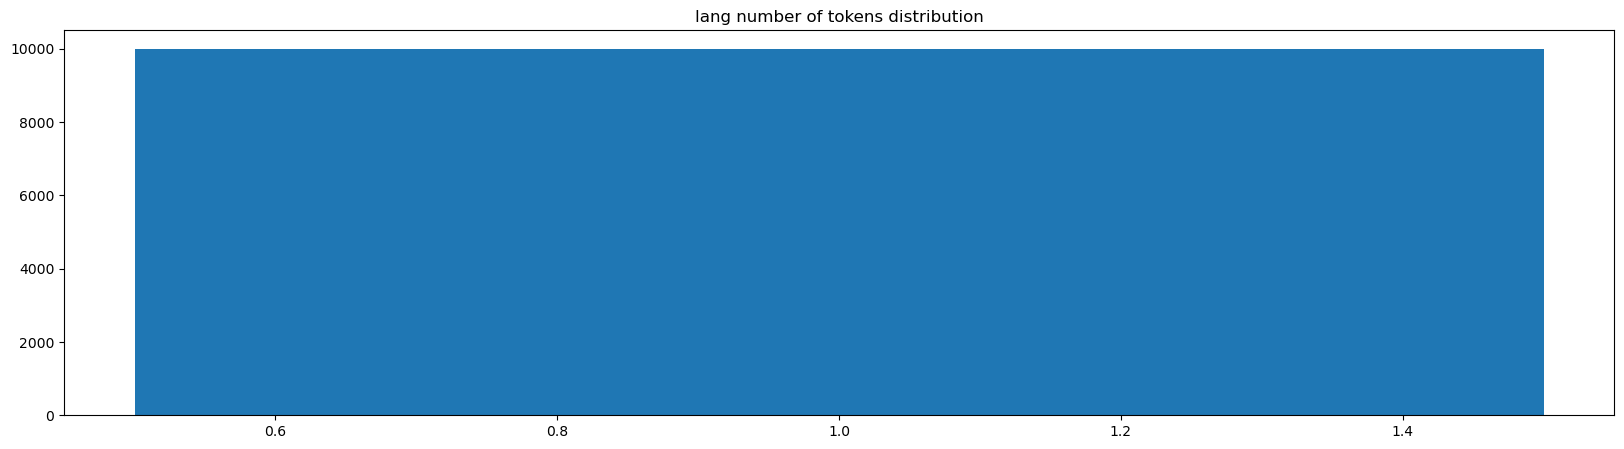

There is 1 unique lang.


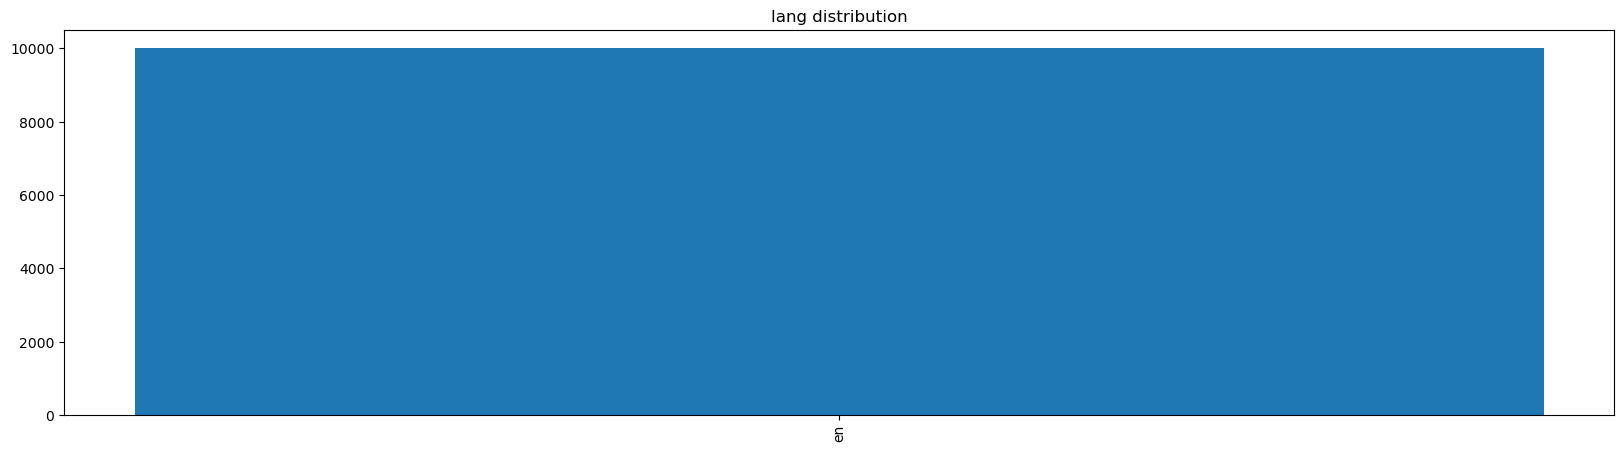

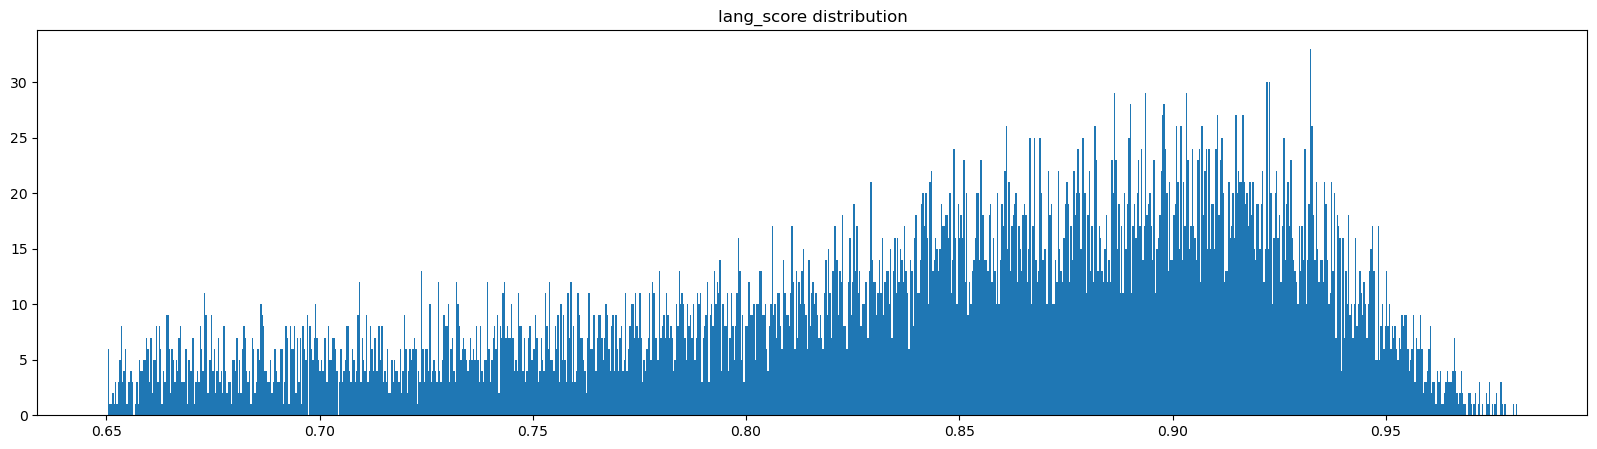

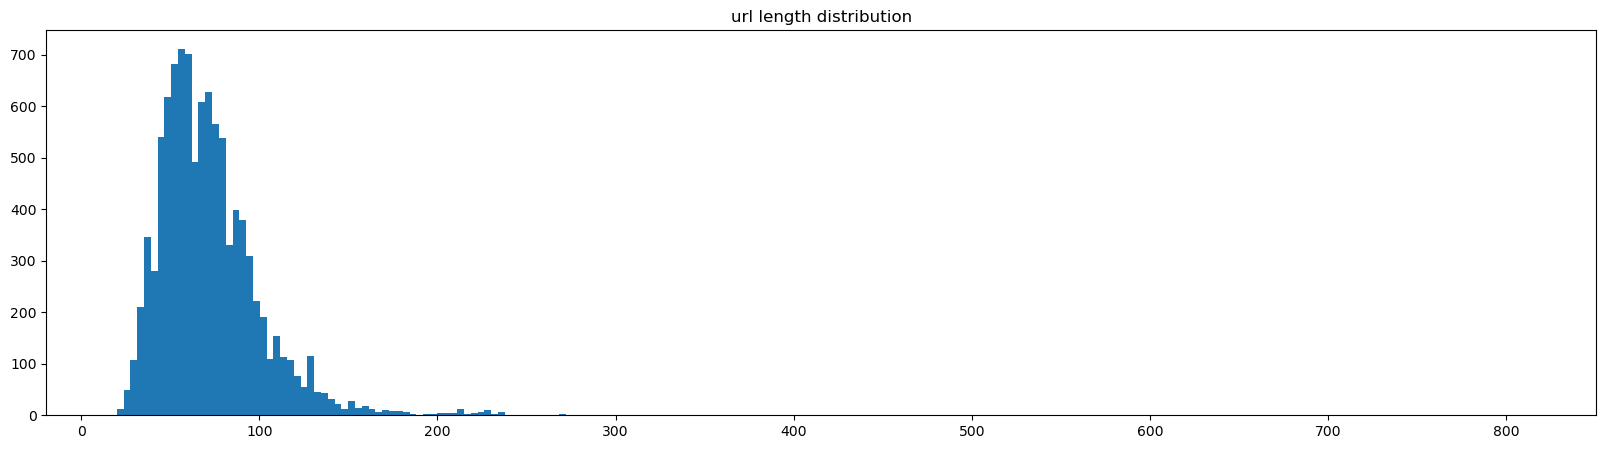

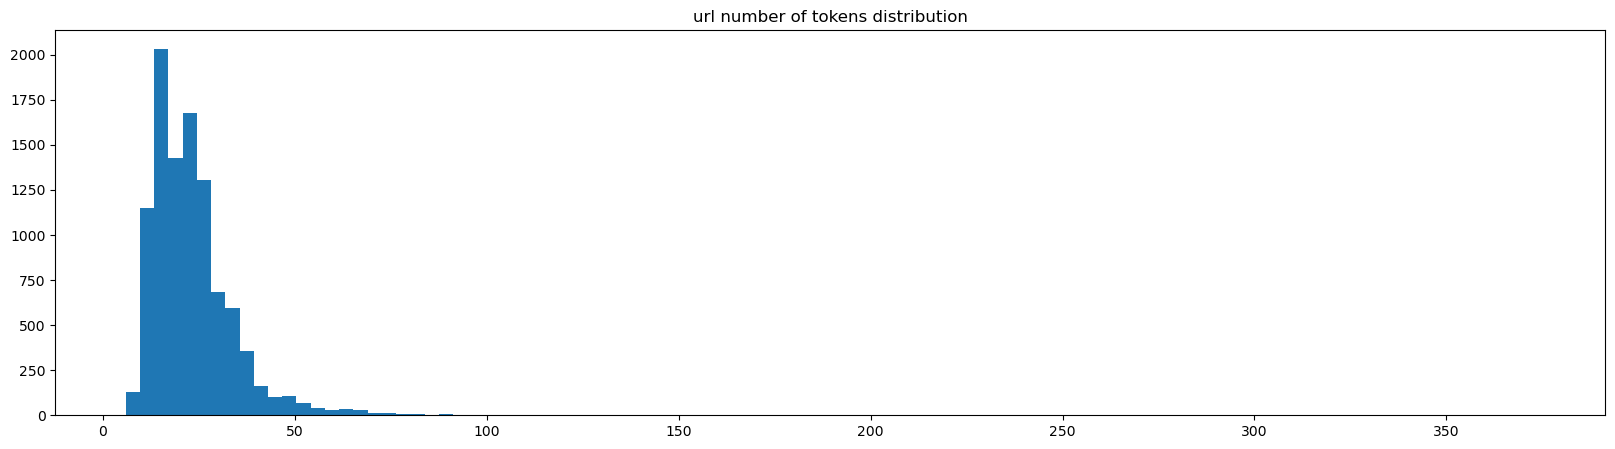

There is 10000 unique url.


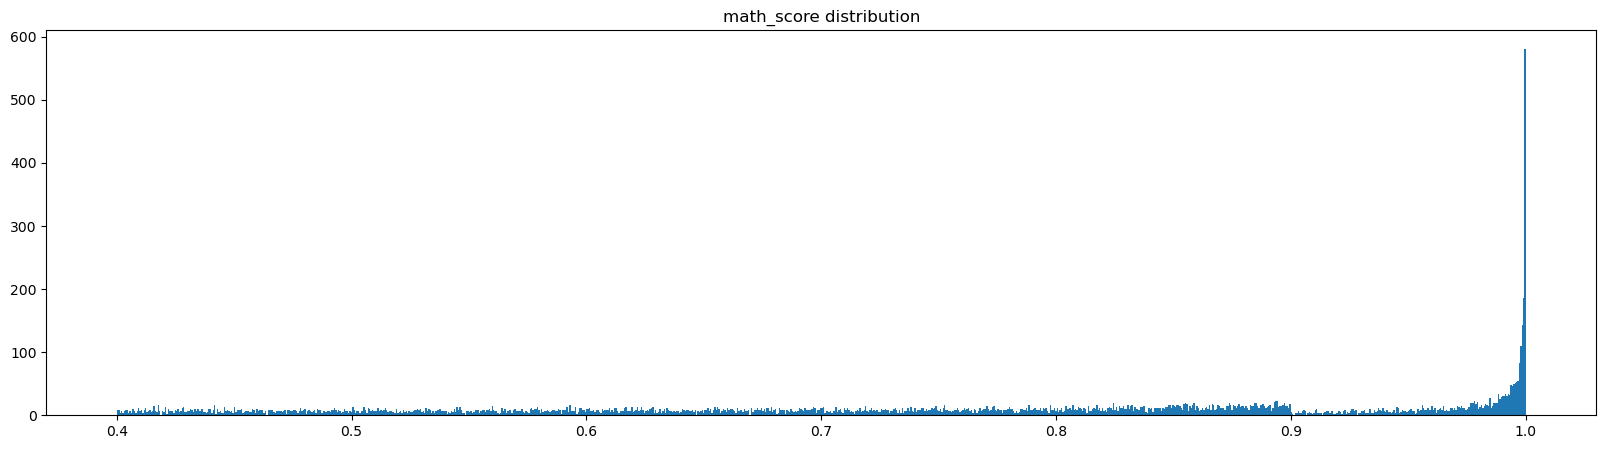

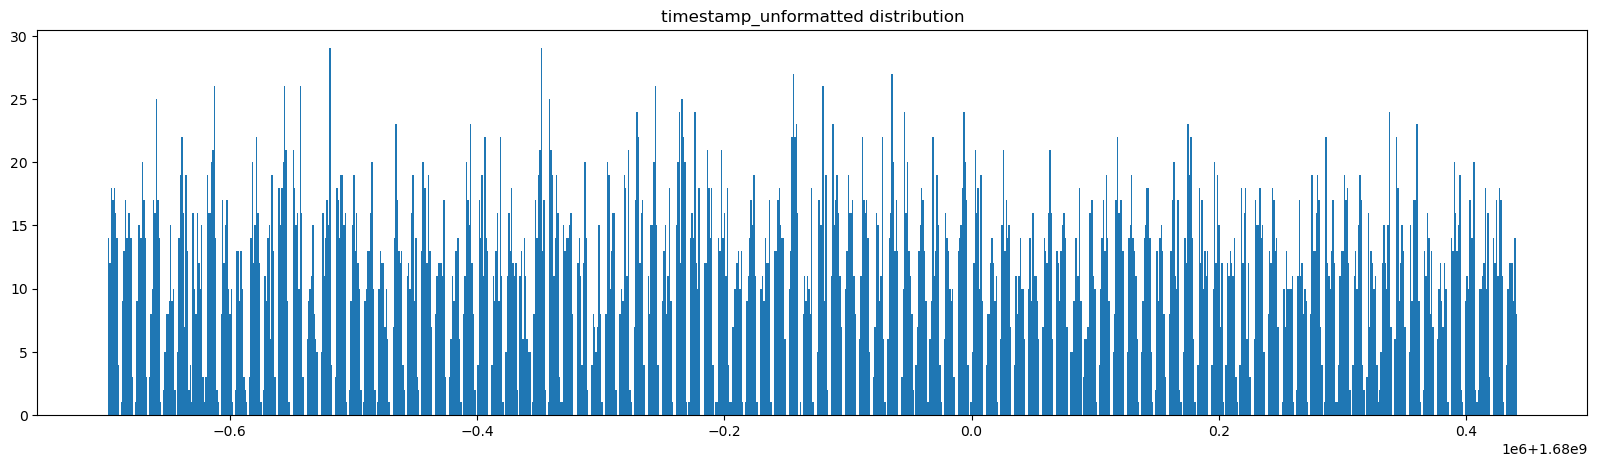

In [6]:
megamath_web_pro = load_data("MegaMath").select(range(10000))
megamath_web_pro = megamath_web_pro.add_column(
    "timestamp_unformatted",
    [(datetime.strptime(ts, '%Y-%m-%dT%H:%M:%SZ') - datetime(1970, 1, 1)).total_seconds() for ts in megamath_web_pro["timestamp"]]
)
print_distributions(megamath_web_pro, ['text', 'cc-path', 'domain', 'lang', 'lang_score', 'url', 'math_score', 'timestamp_unformatted'])

### MetaMath QA

Filter: 100%|██████████| 9960/9960 [00:00<00:00, 22049.09 examples/s]


Filtered 0.4% of the dataset
Features: ['query', 'response', 'type', 'original_question', 'answer']
Number of samples: 9960
Sample: {
    "answer": "4",
    "original_question": "Aaron, Henry's brother, is 15 years old. Henry's sister is three times as old as Aaron. Henry is four times as old as his sister. What's the combined age of the siblings?",
    "query": "Aaron, Henry's brother, is 15 years old. Henry's sister is three times as old as Aaron. Henry is x times as old as his sister. The combined age of the siblings is 240. What is the value of unknown variable x?",
    "response": "To solve this problem, we need to determine the value of x, which represents the age ratio between Henry and his sister.\nLet's break down the information given:\nAaron's age: 15 years\nHenry's sister's age: 3 * 15 = 45 years\nCombined age of the siblings: 240 years\nWe can set up the equation as follows:\nAaron's age + Henry's sister's age + Henry's age = Combined age of the siblings\n15 + 45 + x * 45 

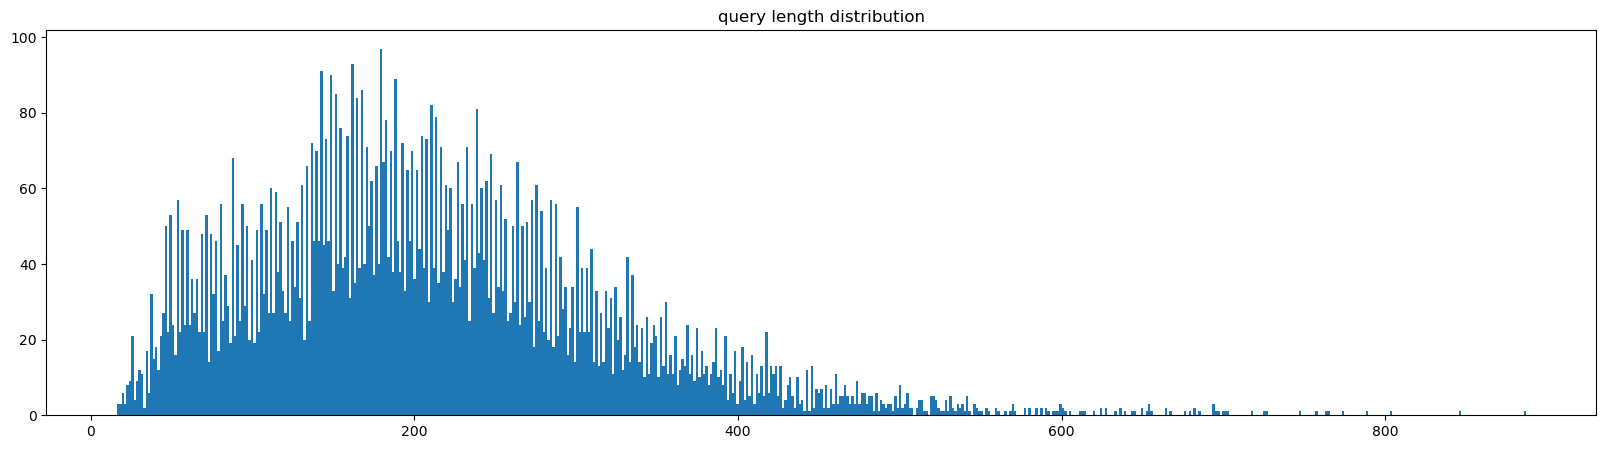

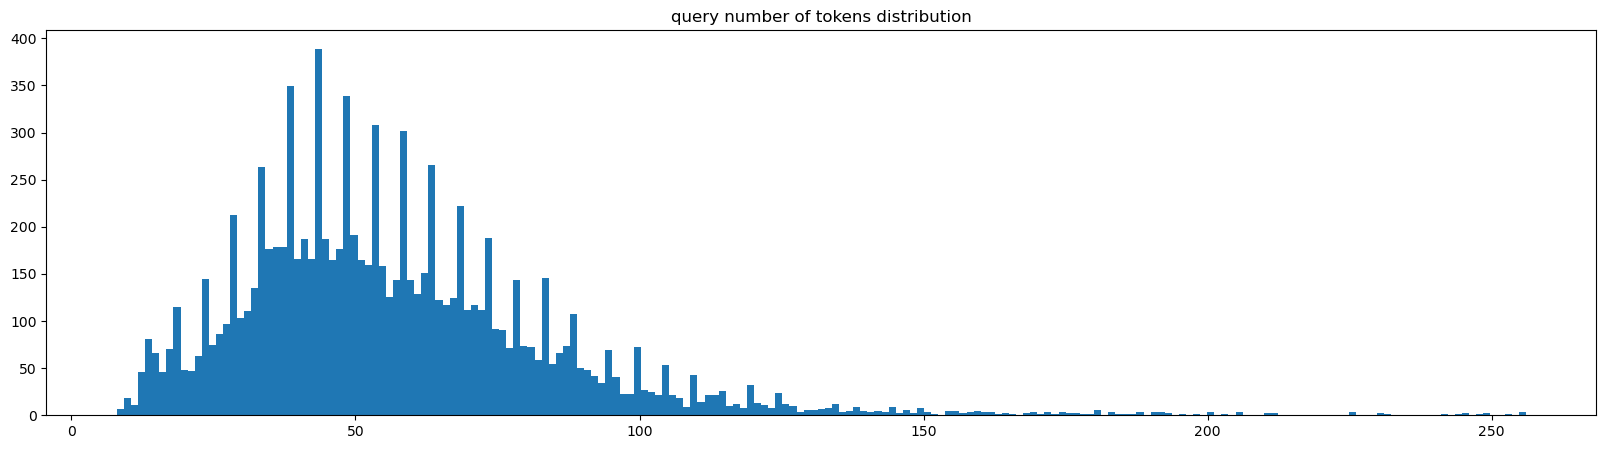

There is 9173 unique query.


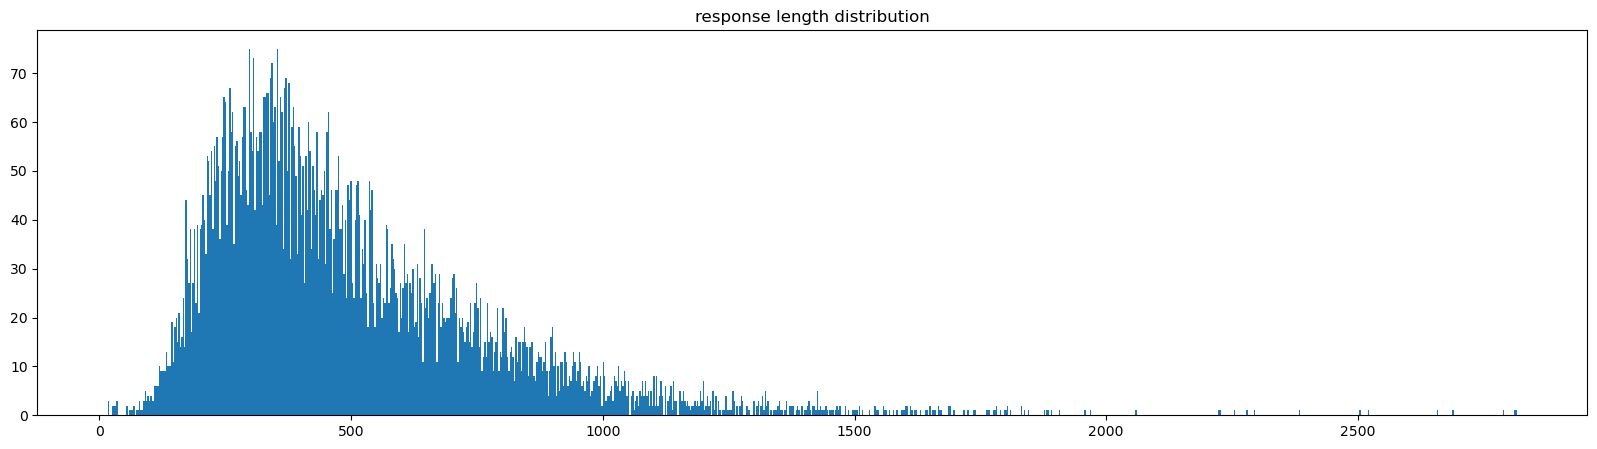

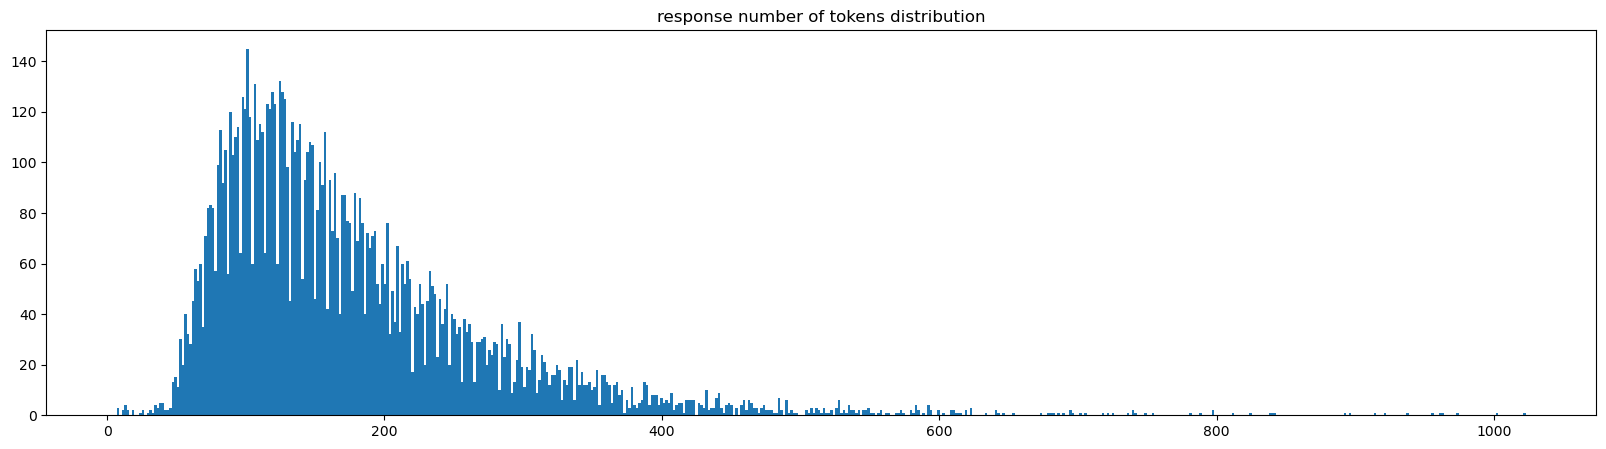

There is 9946 unique response.


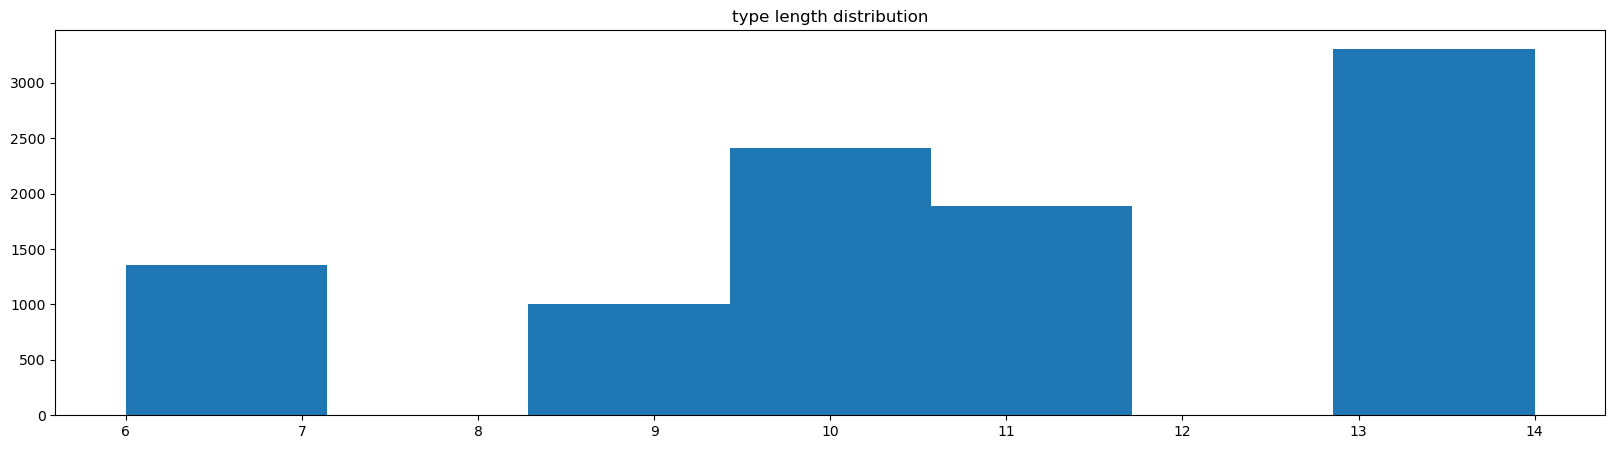

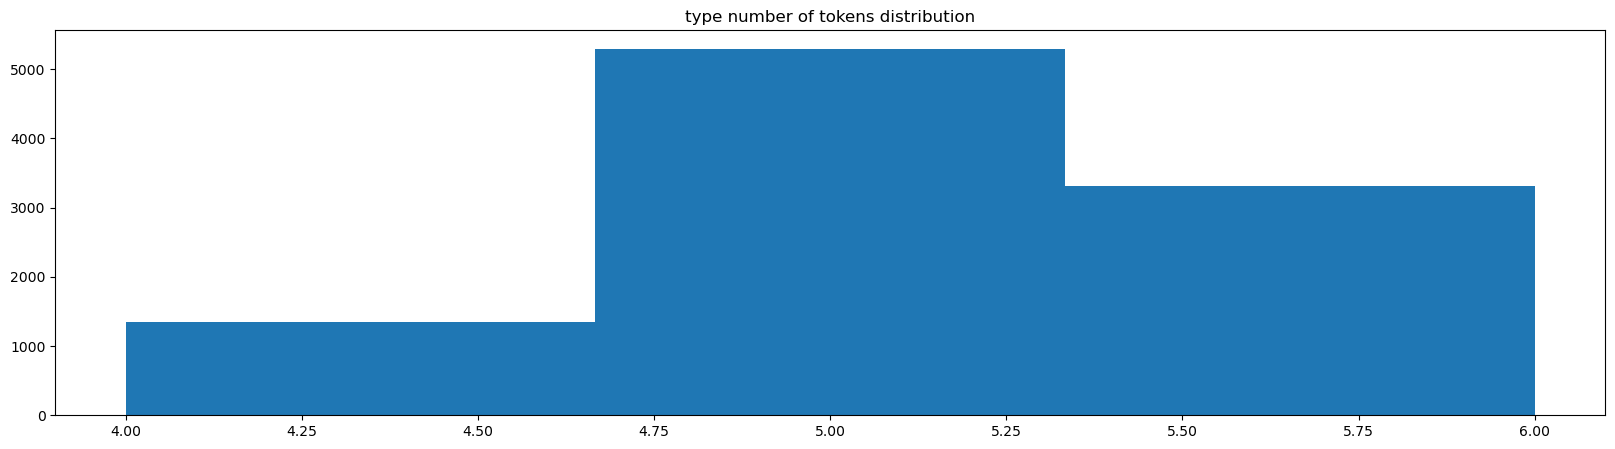

There is 8 unique type.


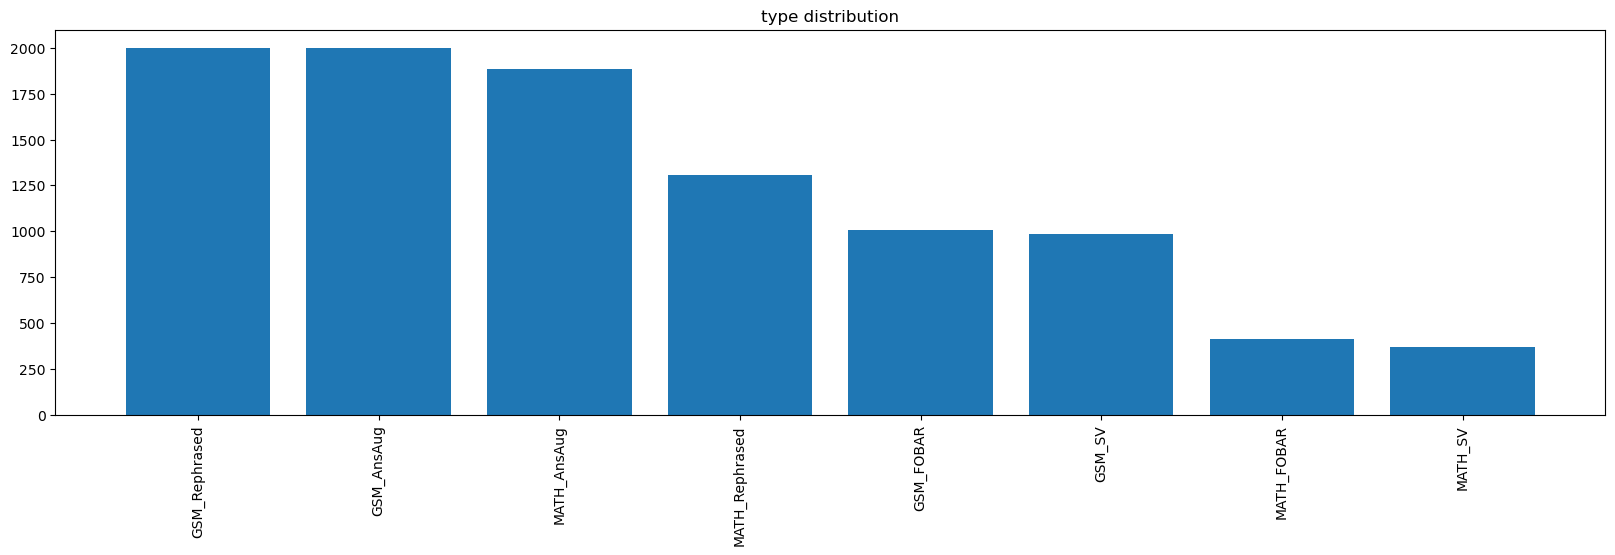

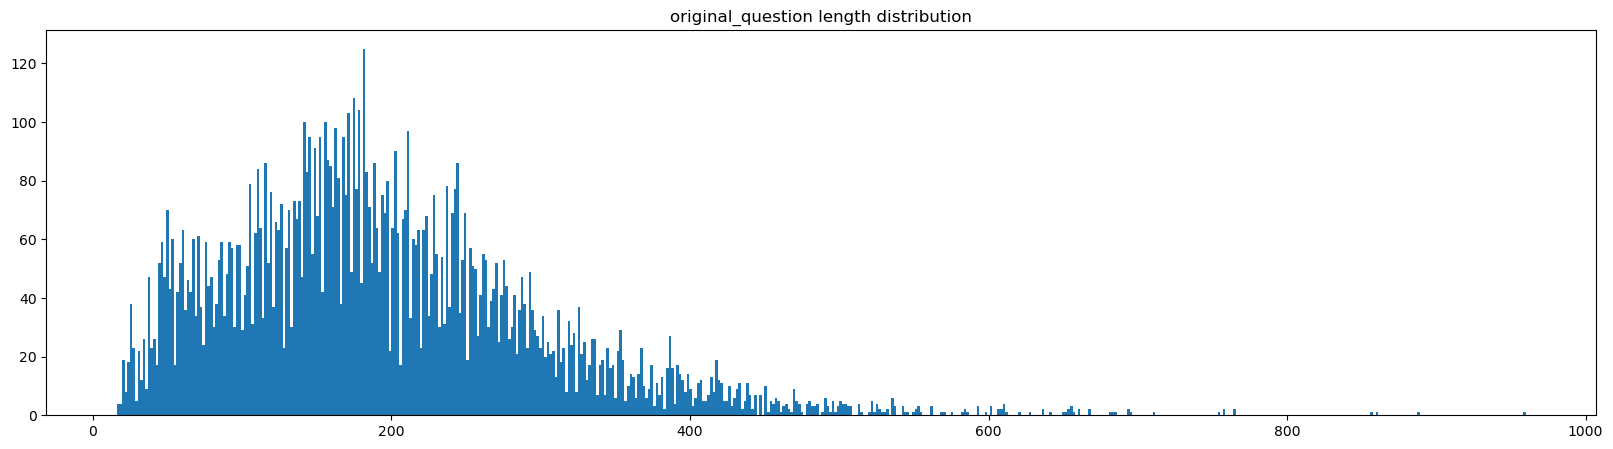

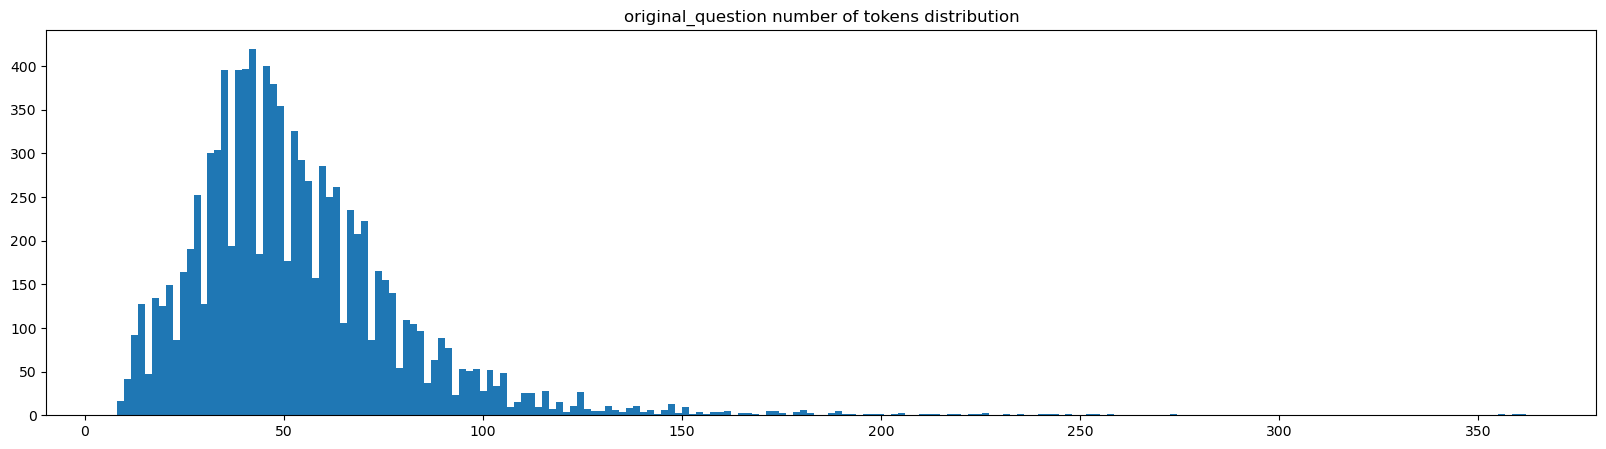

There is 6552 unique original_question.


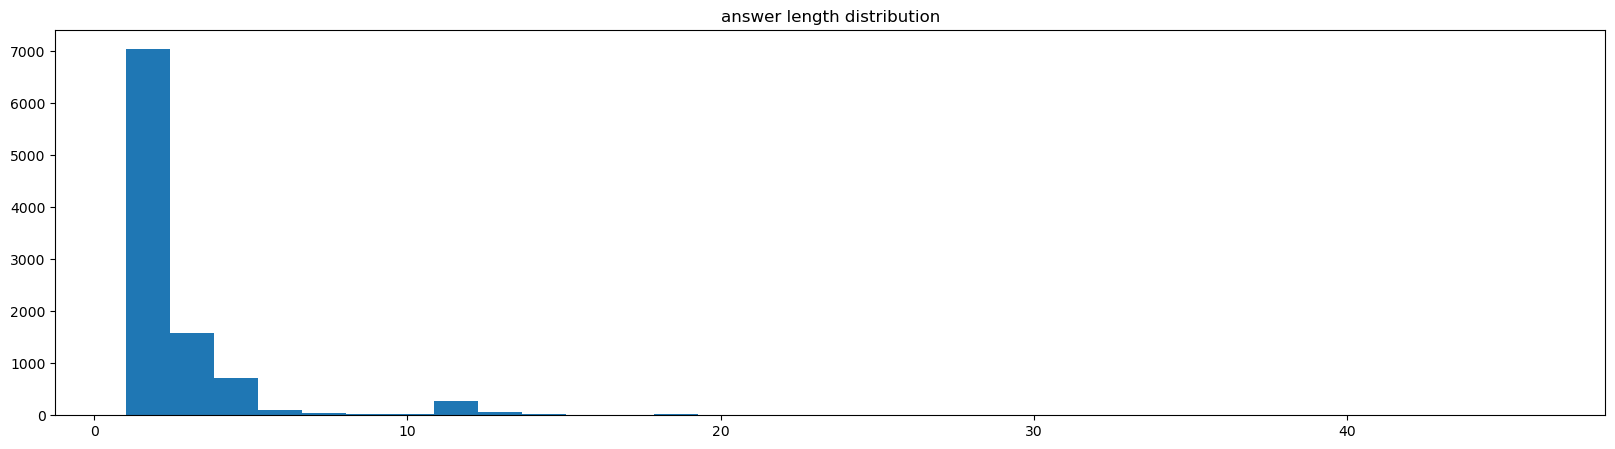

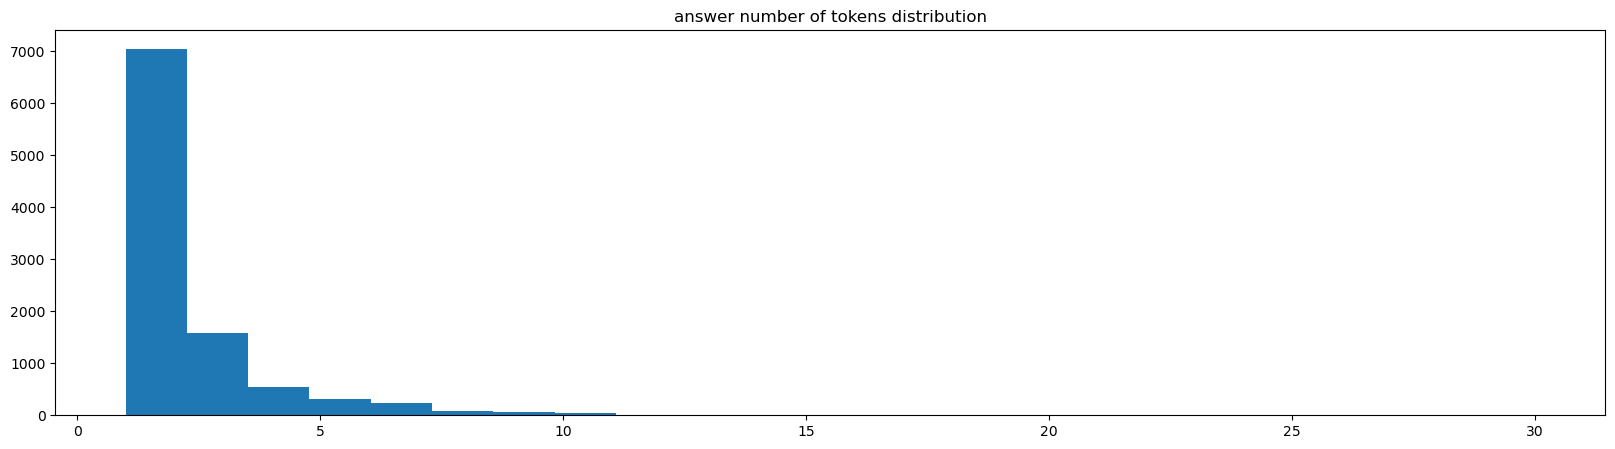

There is 1150 unique answer.


In [2]:
metamath_qa = load_data("MetaMathQA").select(range(10000))
metamath_qa = metamath_qa.add_column(
    "answer",
    [x.split("The answer is: ")[-1] for x in metamath_qa["response"]],
)
metamath_qa = filter_metamath_qa(metamath_qa)
print_distributions(metamath_qa, ['query', 'response', 'type', 'original_question', 'answer'])

### NuminaMath 1.5

Filtered 23.15% of the dataset
Features: ['problem', 'solution', 'answer', 'problem_type', 'question_type', 'problem_is_valid', 'solution_is_valid', 'source', 'synthetic']
Number of samples: 7685
Sample: {
    "answer": "\\frac{3}{4}",
    "problem": "4. On the sides $AB$ and $AC$ of triangle $ABC$, points $D$ and $E$ are chosen such that the area of triangle $ADE$ is 0.5. The inscribed circle of quadrilateral $BDEC$ touches side $AB$ at point $K$, and $AK=3$. Find the tangent of angle $BAC$, if a circumcircle can be circumscribed around quadrilateral $BDEC$, and $BC=15$.\n\n(20 points)",
    "problem_is_valid": "Yes",
    "problem_type": "Geometry",
    "question_type": "math-word-problem",
    "solution": "Solution: Let $O_{1}$ be the center of the inscribed circle in triangle $ABC$, $R$ its radius, $O_{2}$ the center of the inscribed circle in triangle $ADE$, $r$ its radius. Let $p_{1}$ be the semiperimeter of triangle $ABC$, and $p_{2}$ the semiperimeter of triangle $ADE$. Then $A 

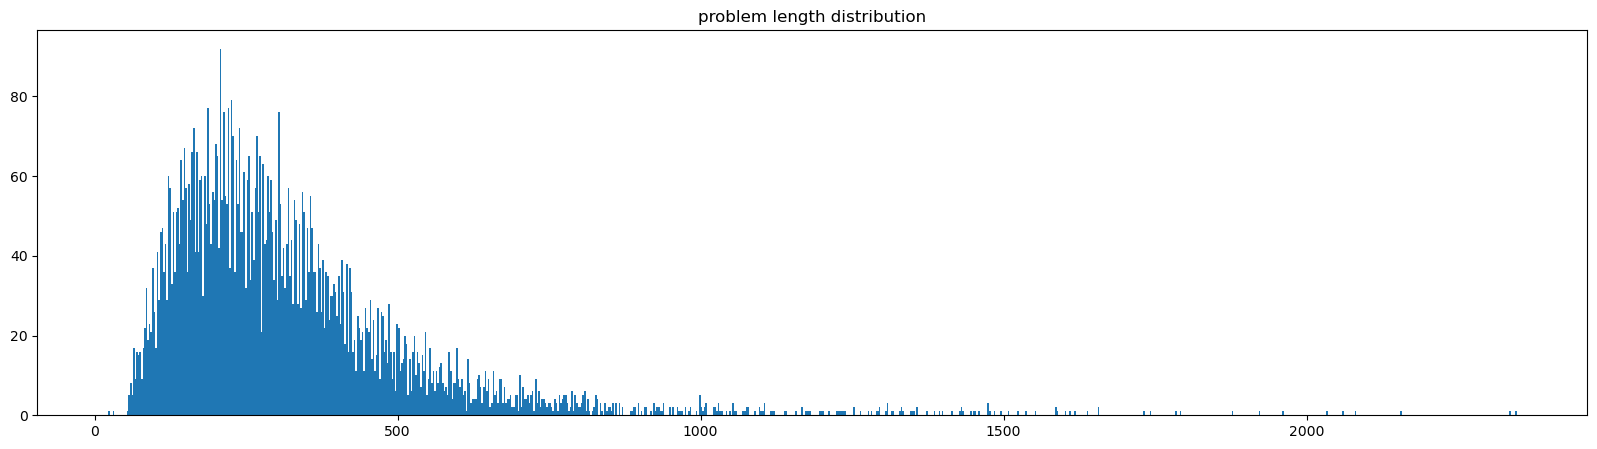

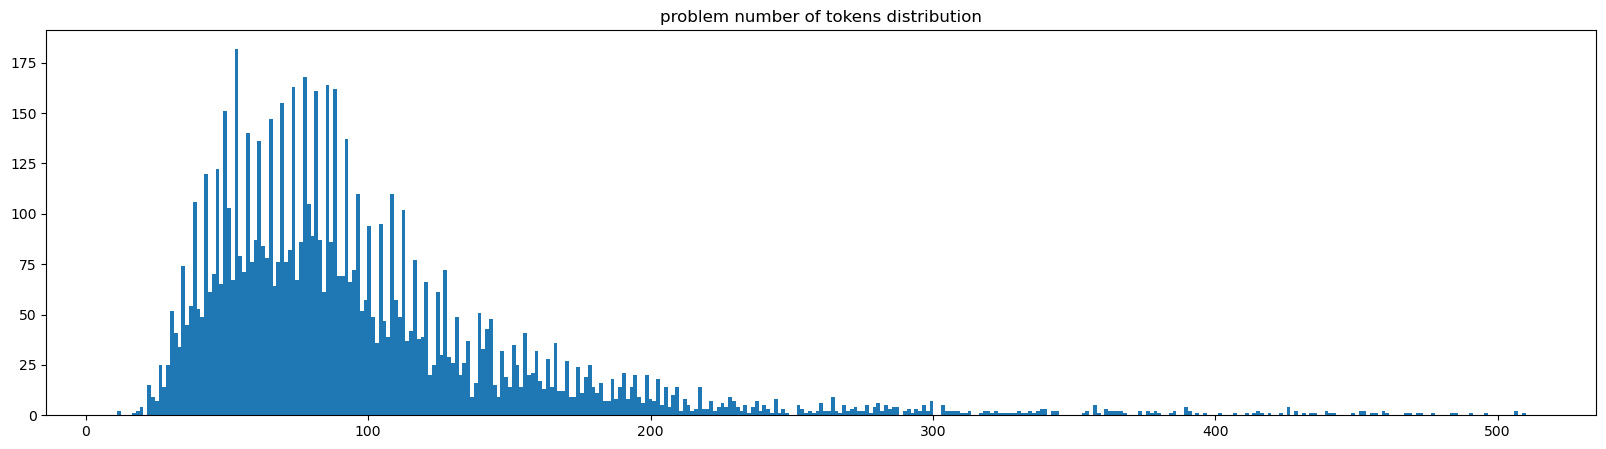

There is 7685 unique problem.


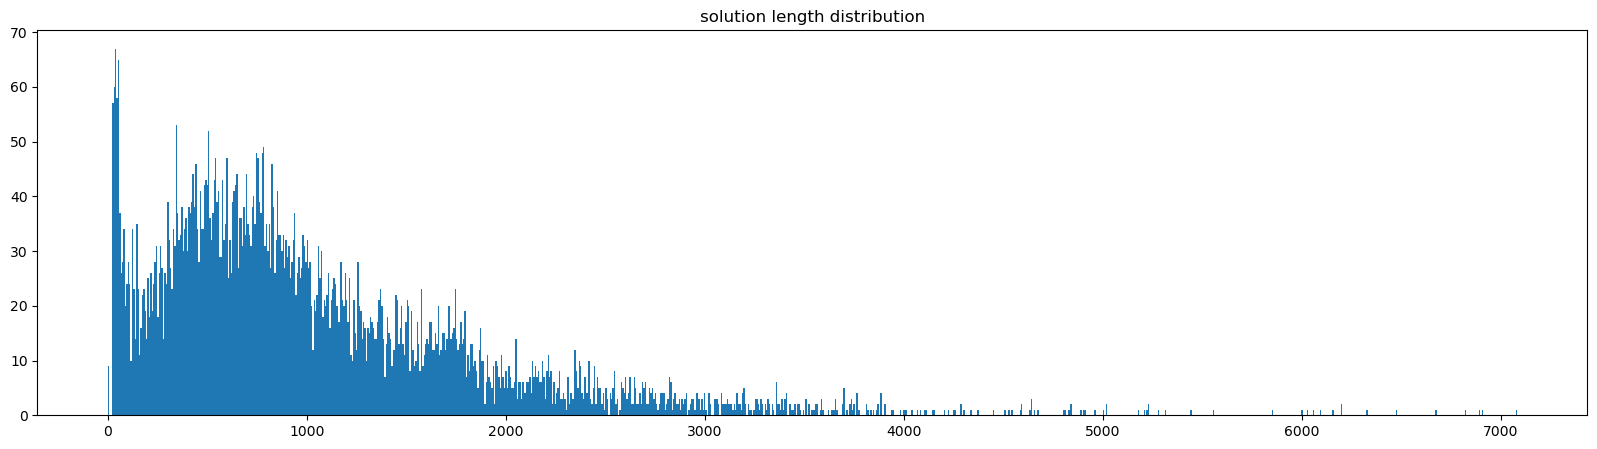

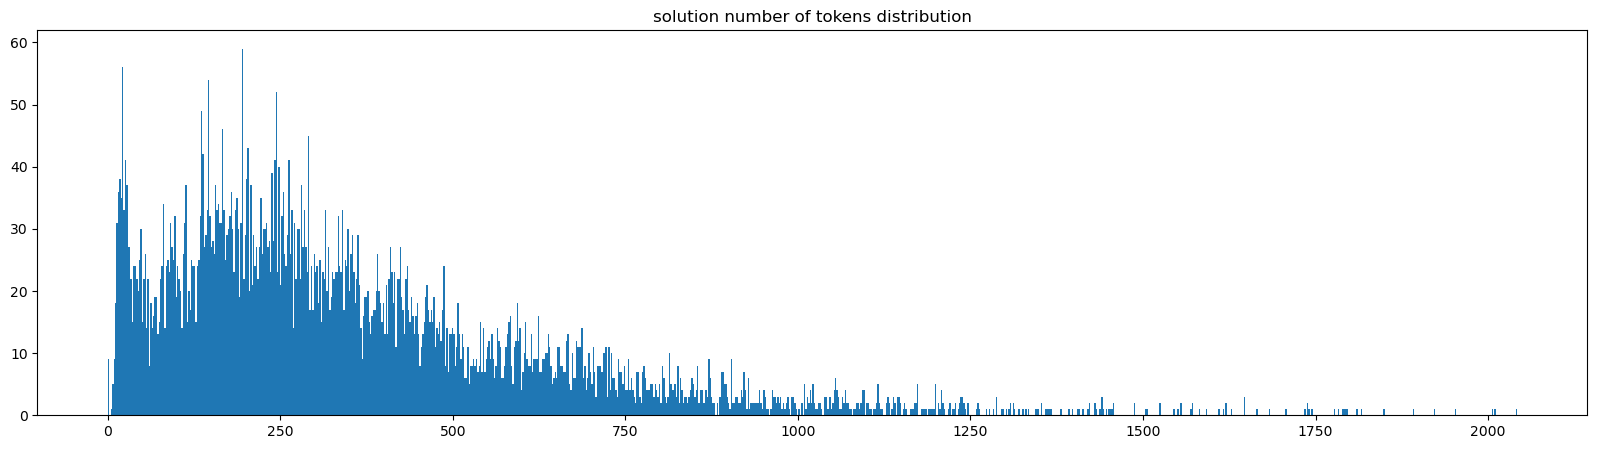

There is 7442 unique solution.


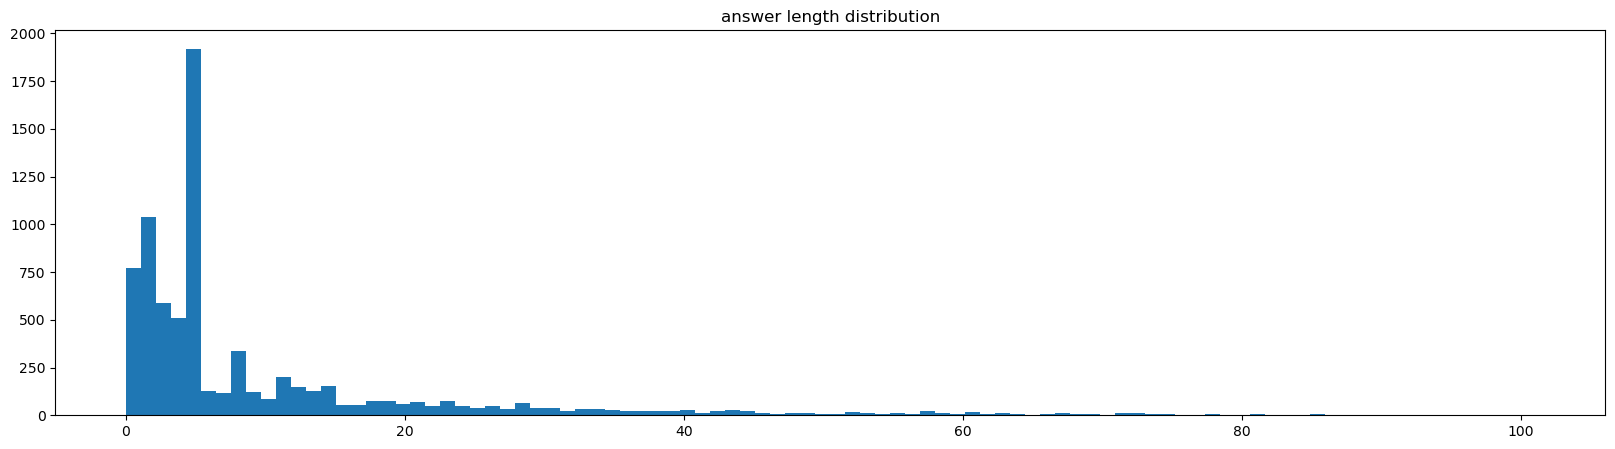

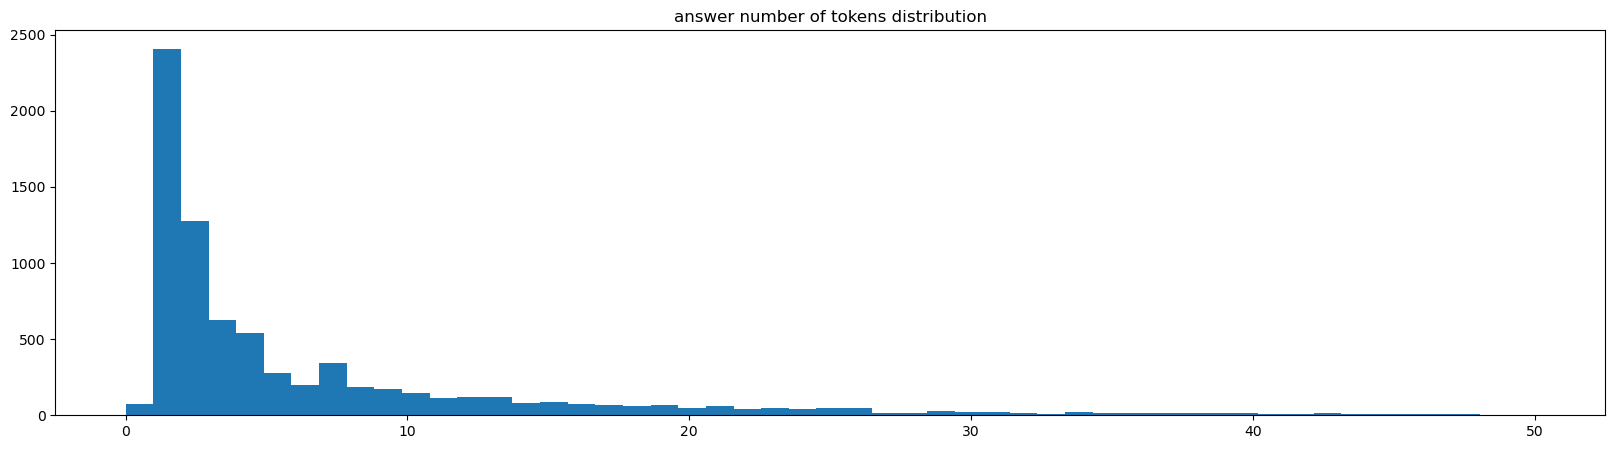

There is 3325 unique answer.


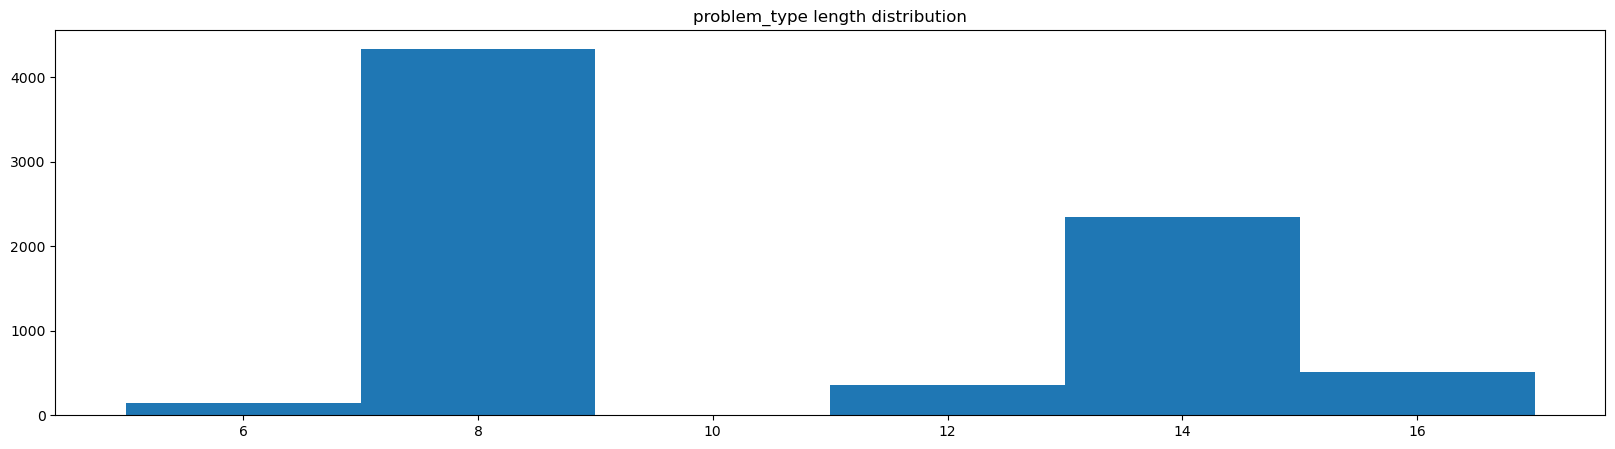

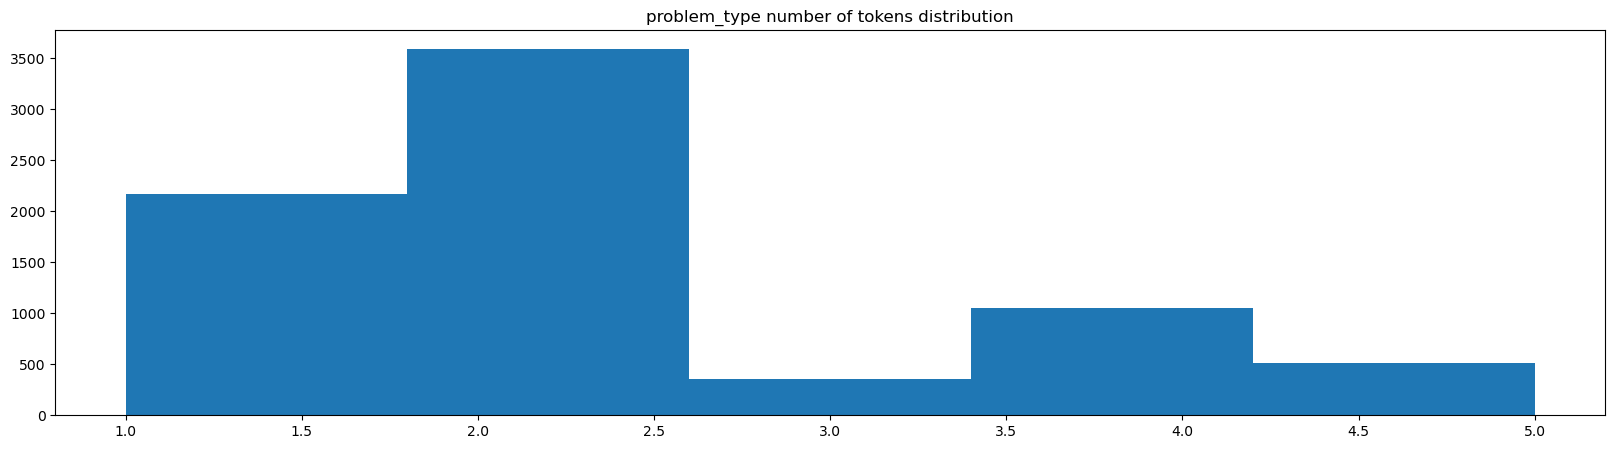

There is 8 unique problem_type.


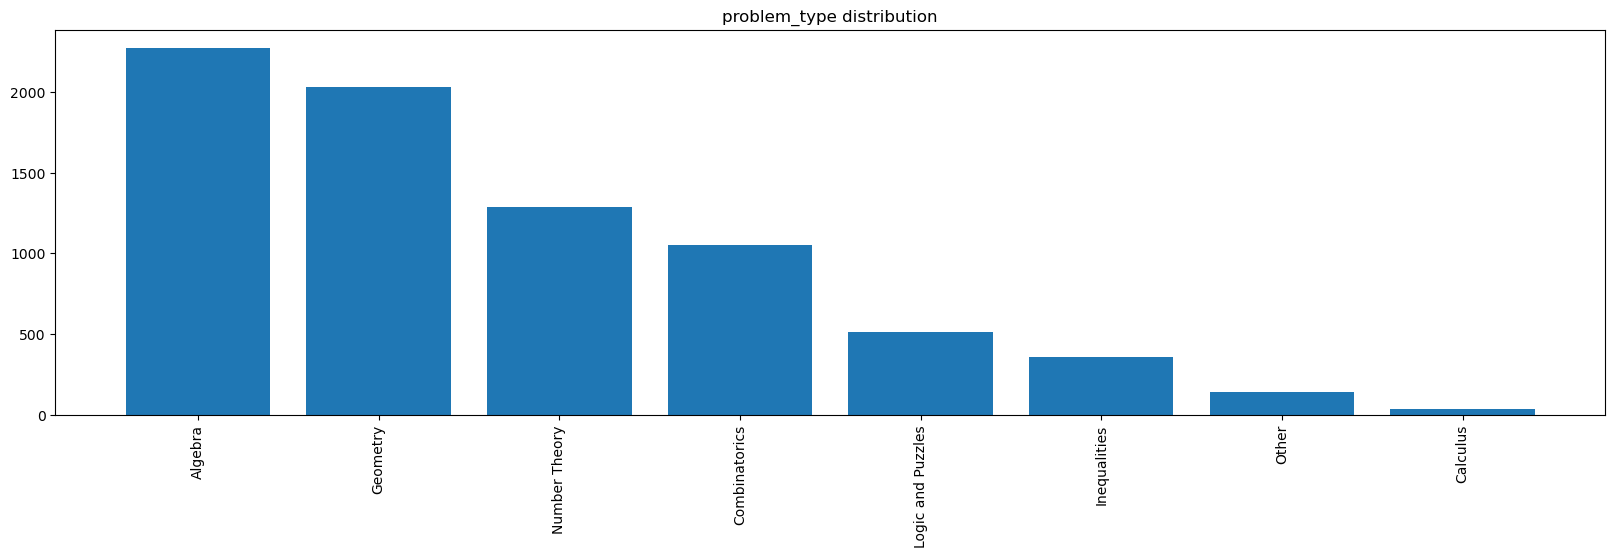

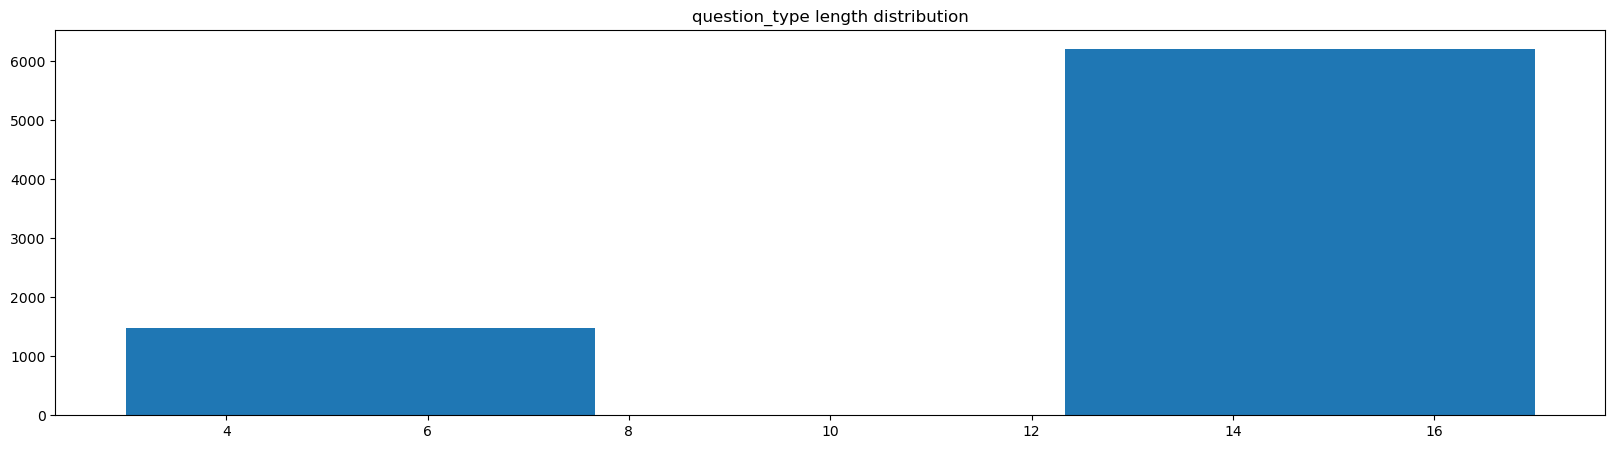

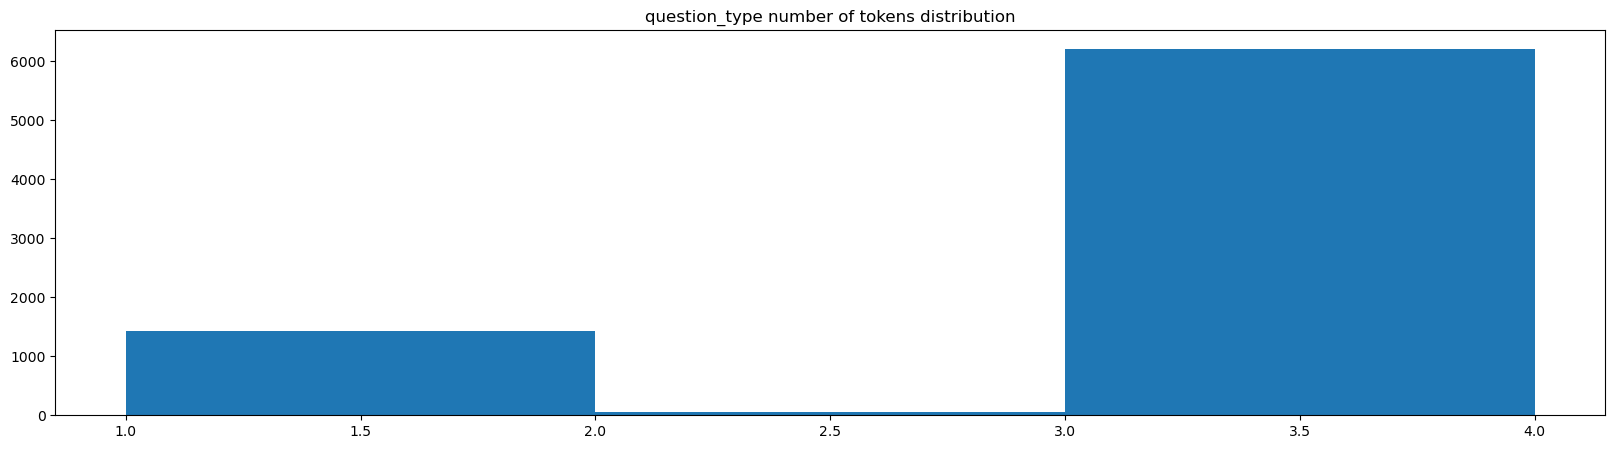

There is 4 unique question_type.


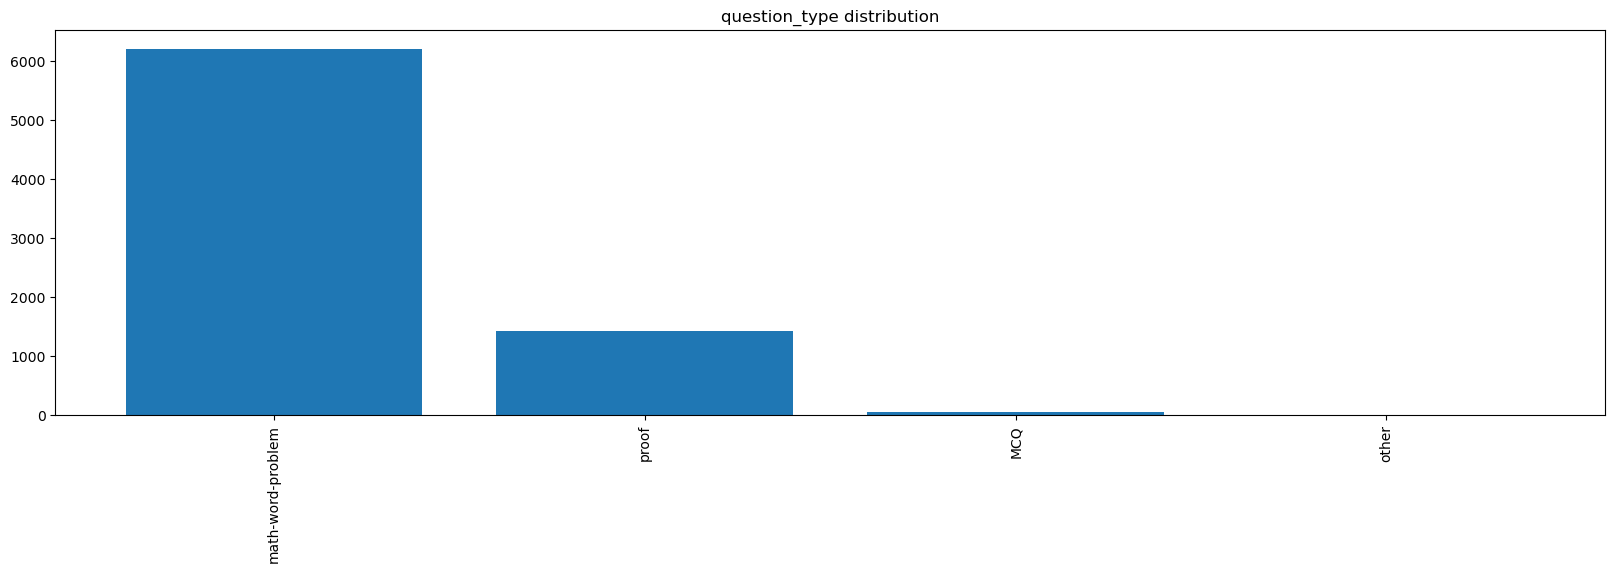

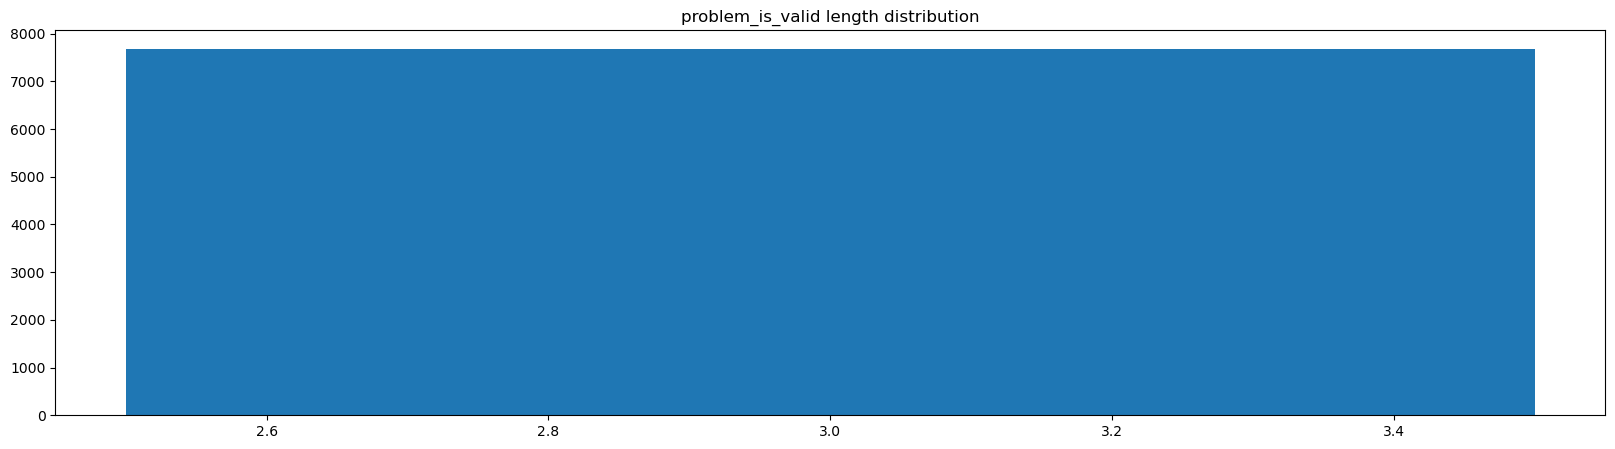

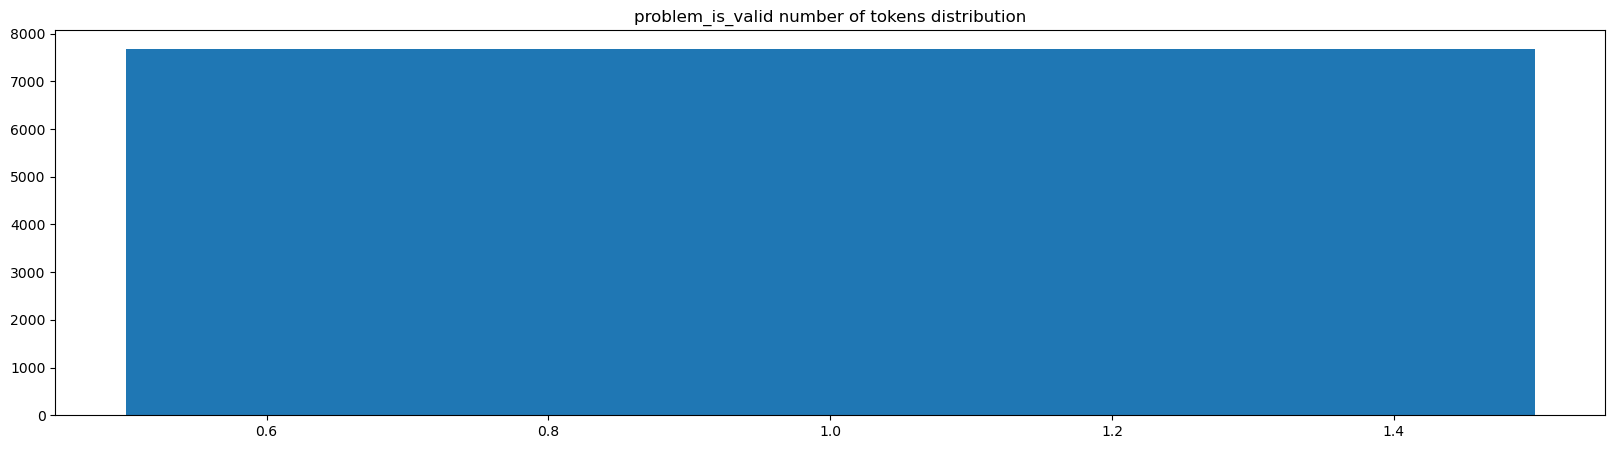

There is 1 unique problem_is_valid.


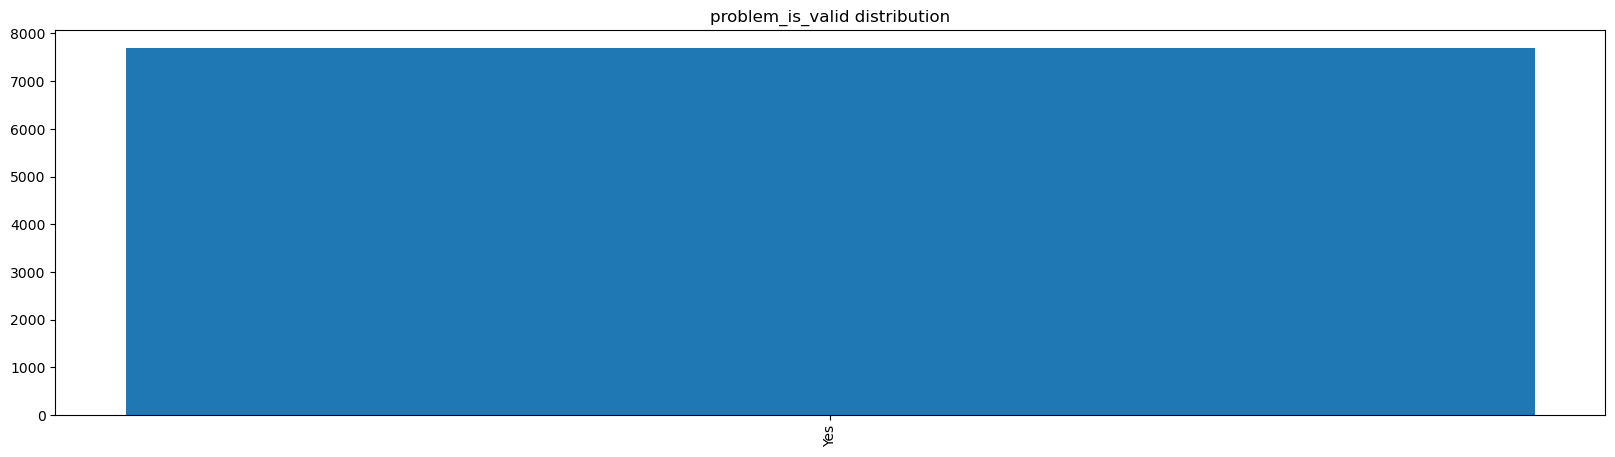

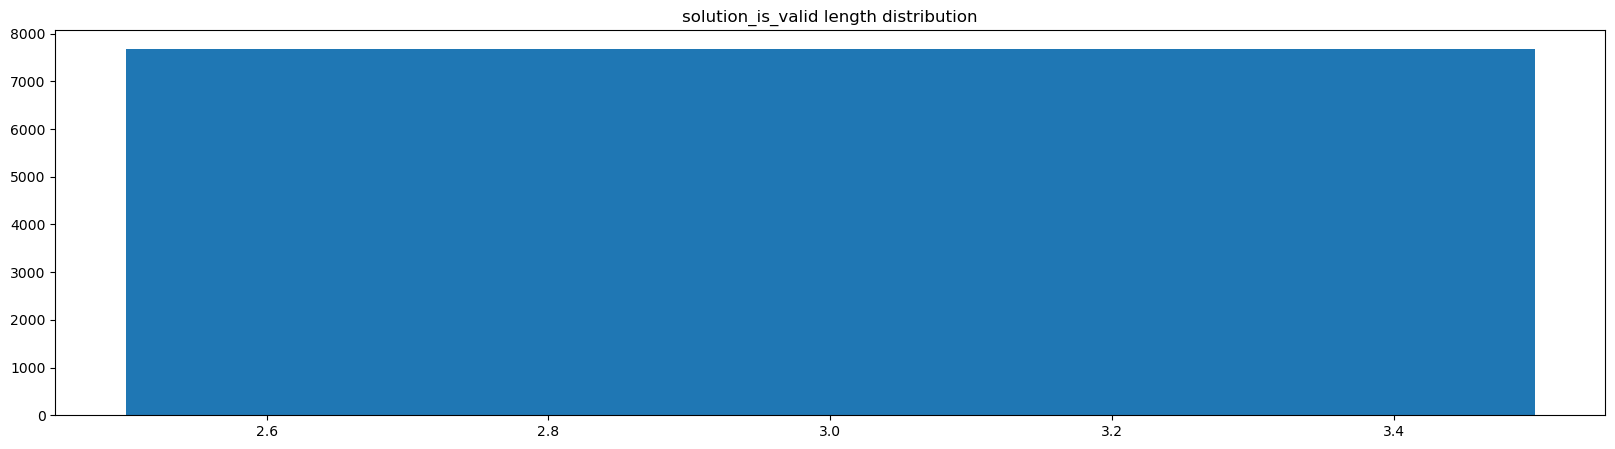

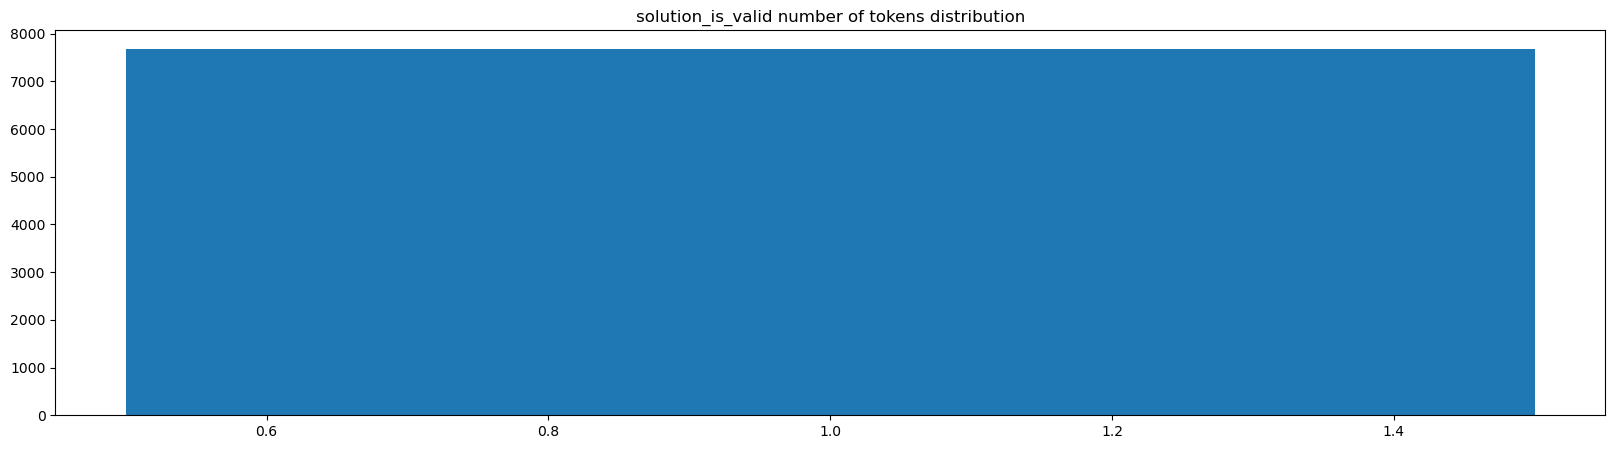

There is 1 unique solution_is_valid.


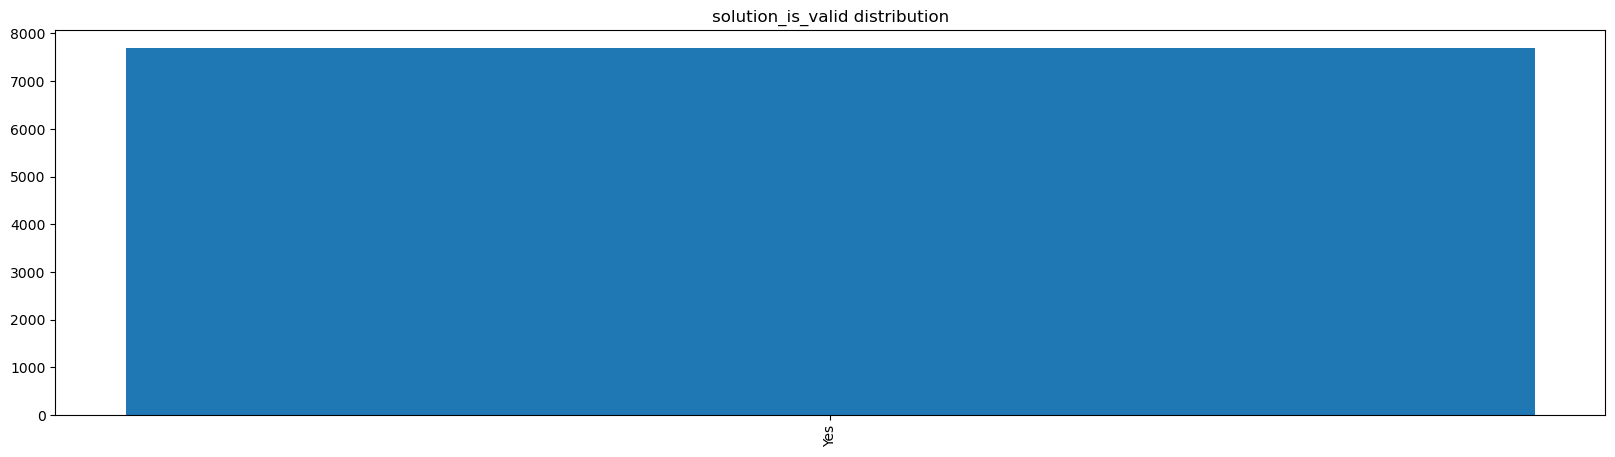

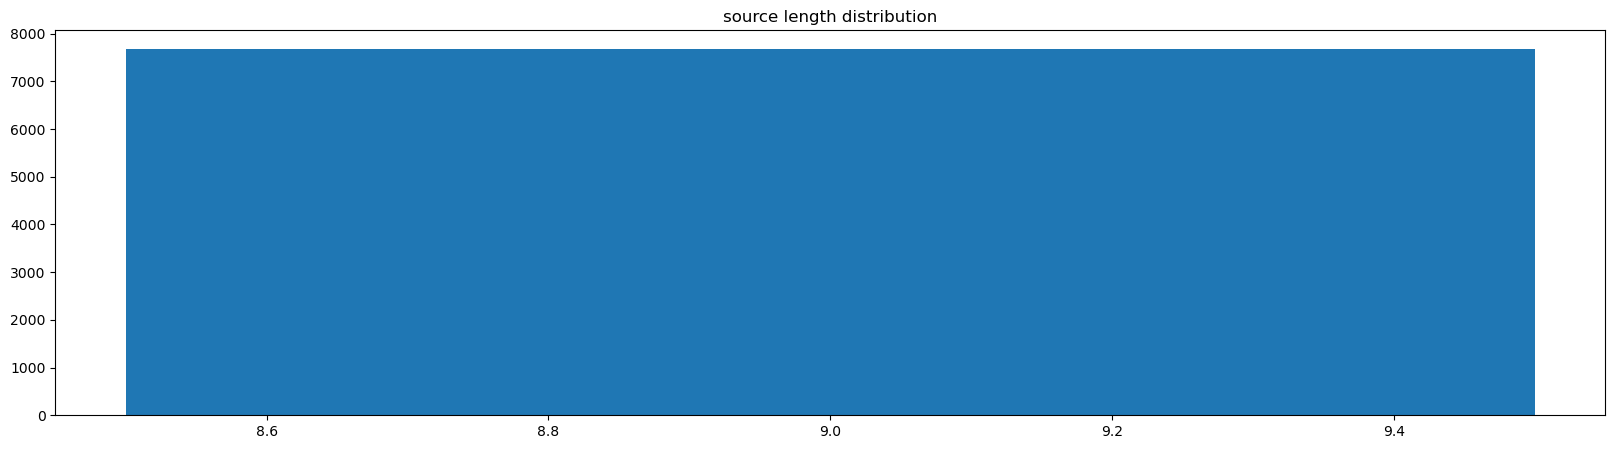

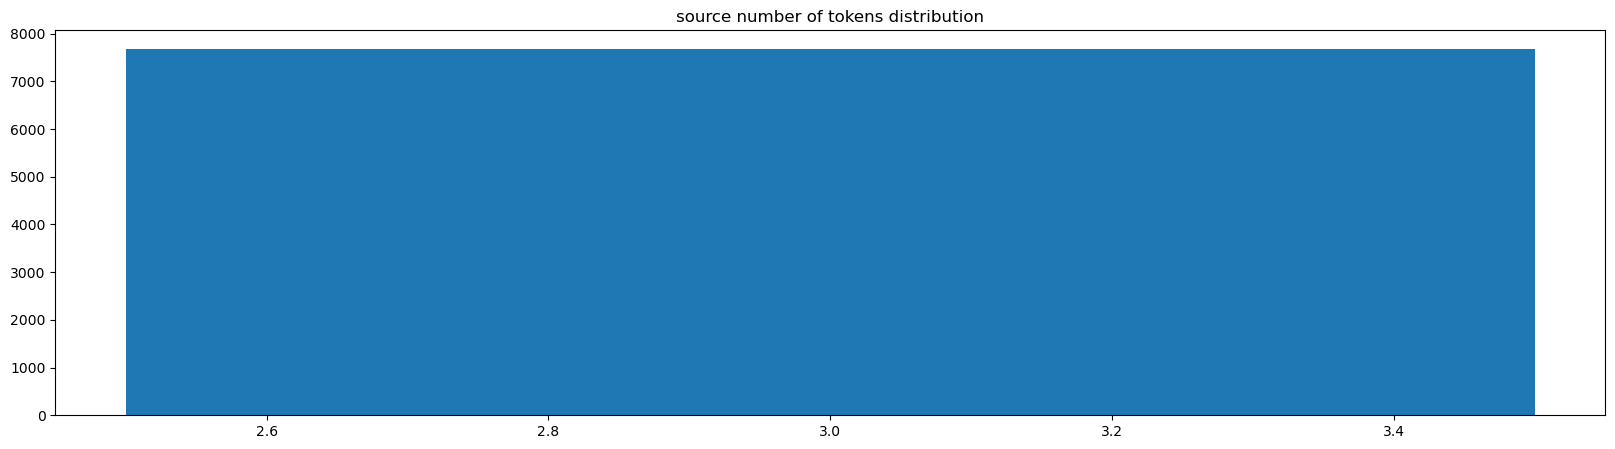

There is 1 unique source.


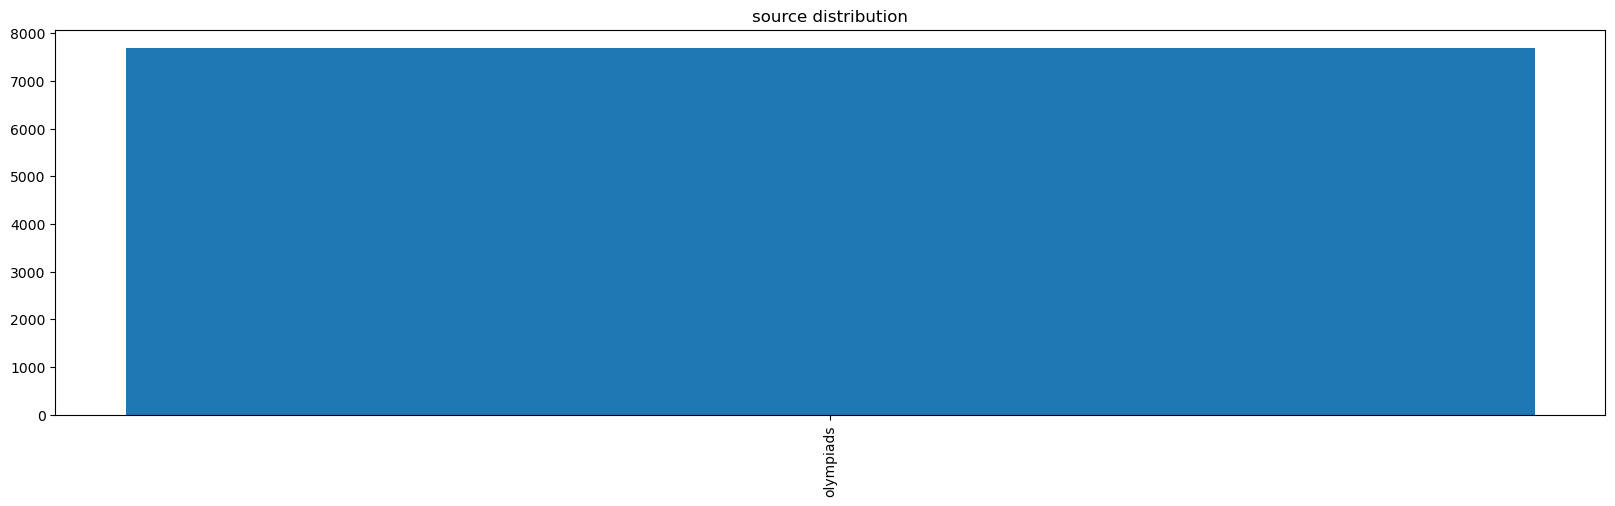

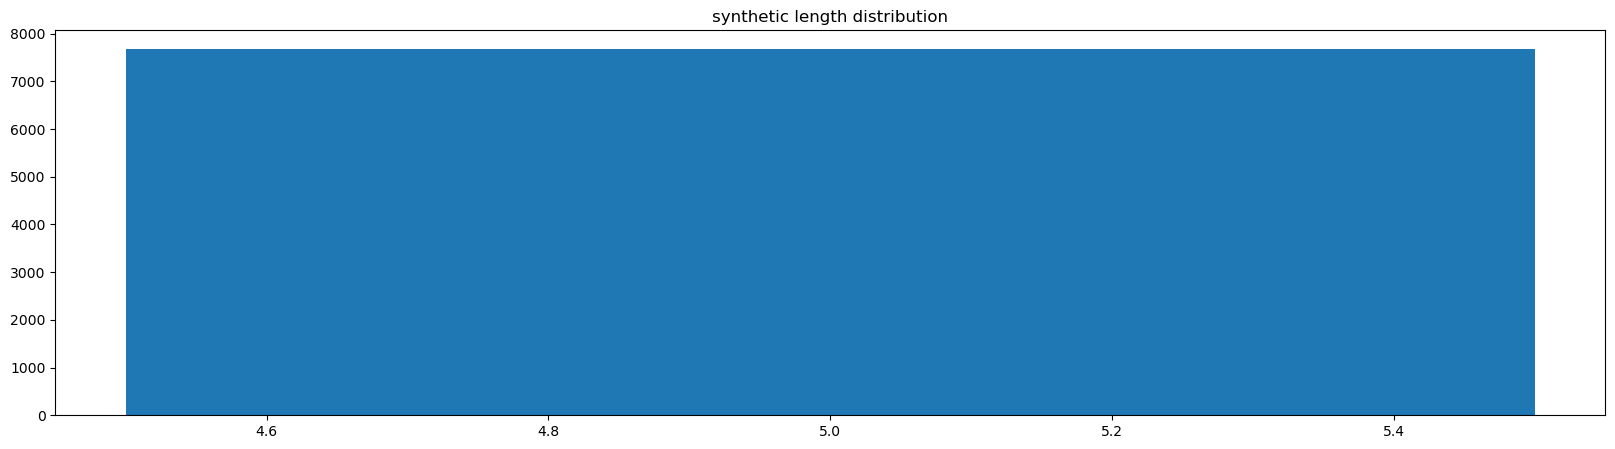

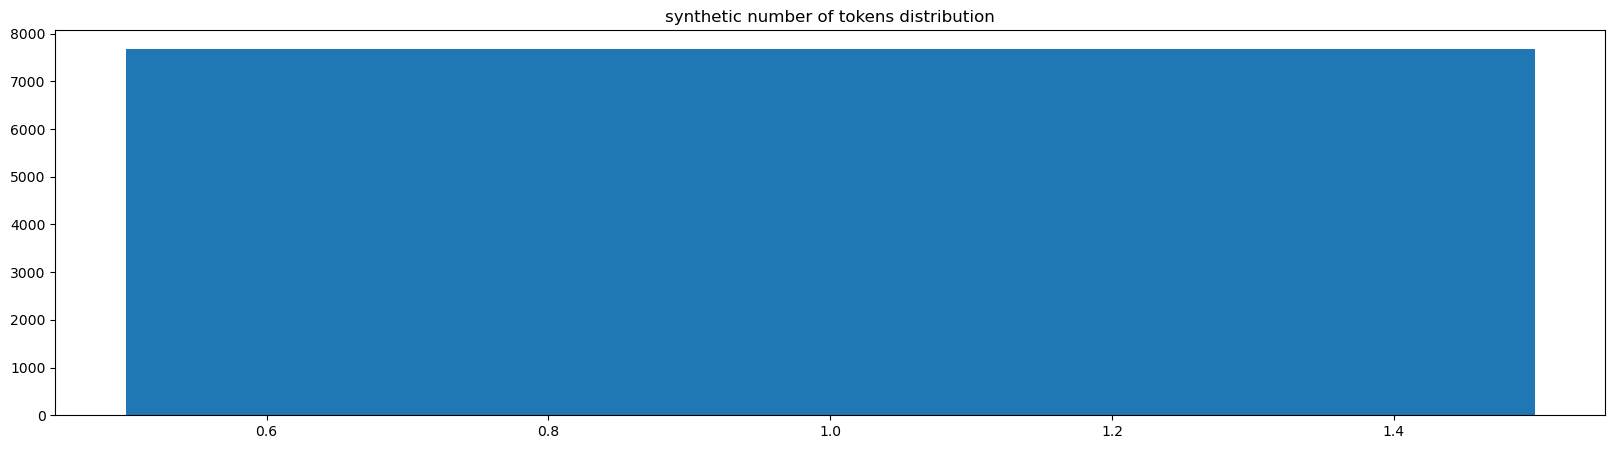

There is 1 unique synthetic.


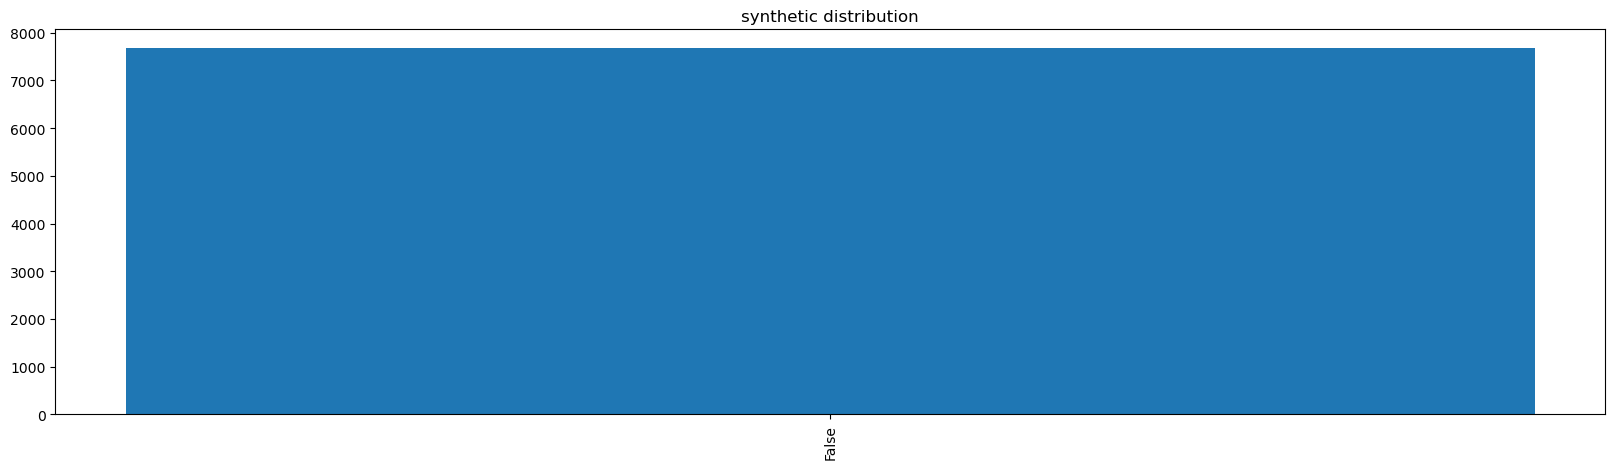

In [7]:
numinamath_1_5 = load_data("NuminaMath-1.5").select(range(10000))
numinamath_1_5 = filter_numinamath_1_5(numinamath_1_5)
print_distributions(numinamath_1_5, ['problem', 'solution', 'answer', 'problem_type', 'question_type', 'problem_is_valid', 'solution_is_valid', 'source', 'synthetic'])

### Open-R1 Math

Filter: 100%|██████████| 1261/1261 [00:00<00:00, 12986.19 examples/s]


Filtered 38.75667799902865% of the dataset
Features: ['problem', 'solution', 'answer', 'problem_type', 'question_type', 'source', 'uuid', 'is_reasoning_complete', 'generations', 'correctness_math_verify', 'correctness_llama', 'finish_reasons', 'correctness_count', 'messages']
Number of samples: 1261
Sample: {
    "answer": " k = 1 ",
    "correctness_count": 2,
    "correctness_llama": null,
    "correctness_math_verify": true,
    "finish_reasons": null,
    "generations": "<think>\nOkay, let's see. I need to find all positive integers k such that 3^k + 5^k is a perfect power, meaning it's equal to m^n where m and n are integers and n > 1. Hmm. So, first, let me understand what the problem is asking. For each k, compute 3^k + 5^k and check if the result is a perfect power. If it is, then k is one of the solutions we need to find.\n\nAlright, let's start by testing small values of k. Maybe there's a pattern or only a few solutions.\n\nFirst, k = 1: 3 + 5 = 8. 8 is 2^3, which is a perfe

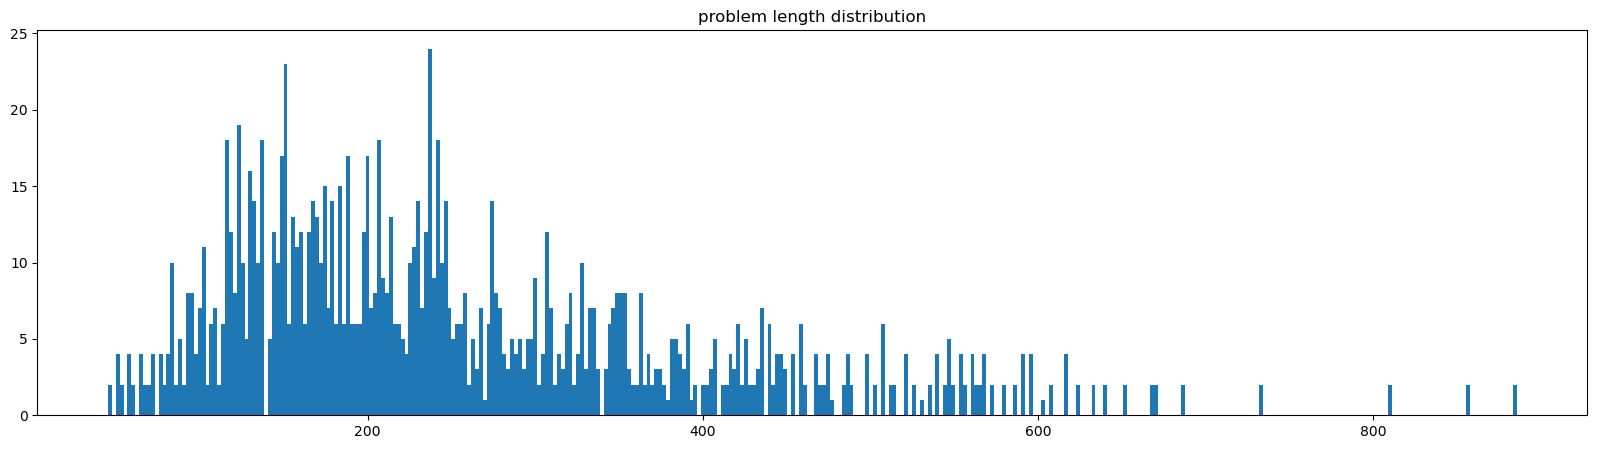

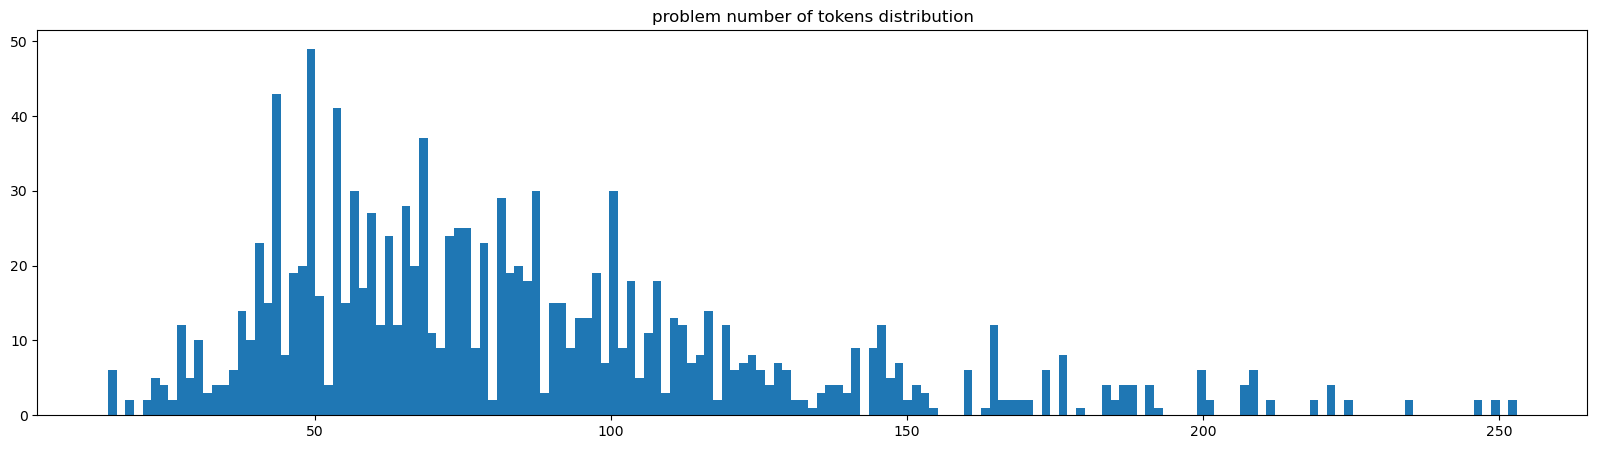

There is 669 unique problem.


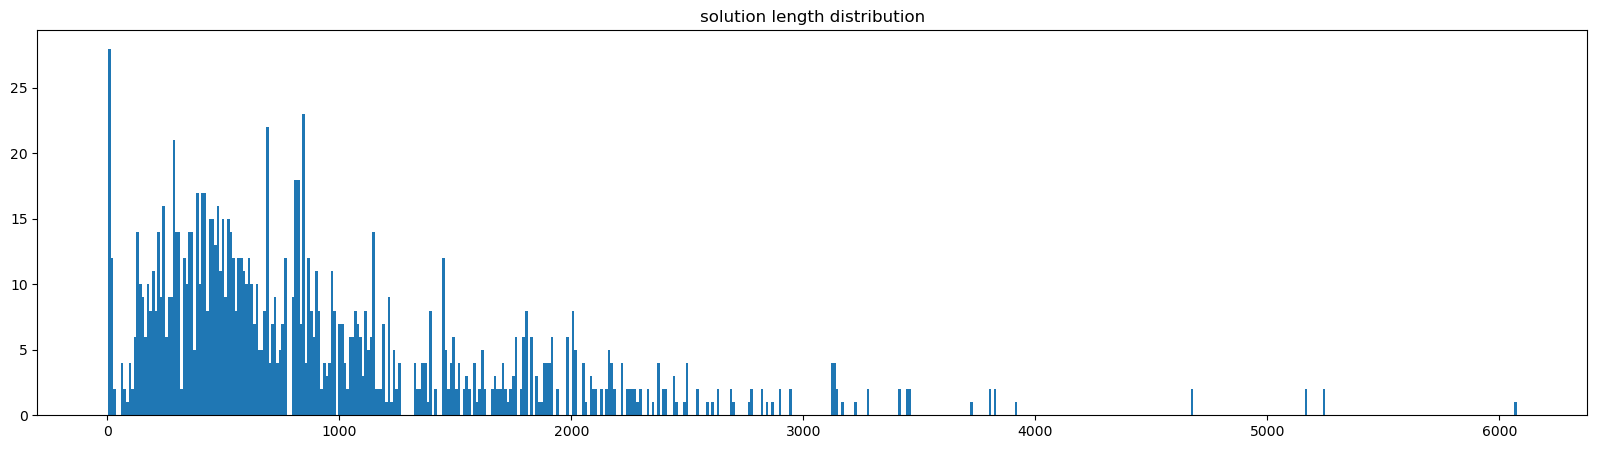

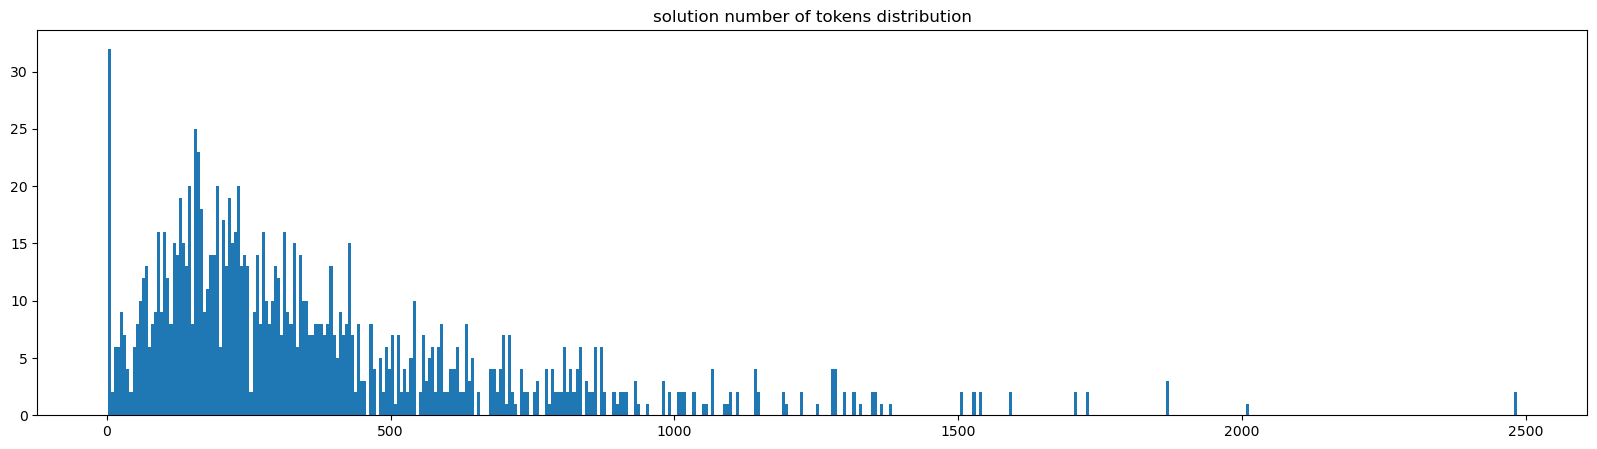

There is 669 unique solution.


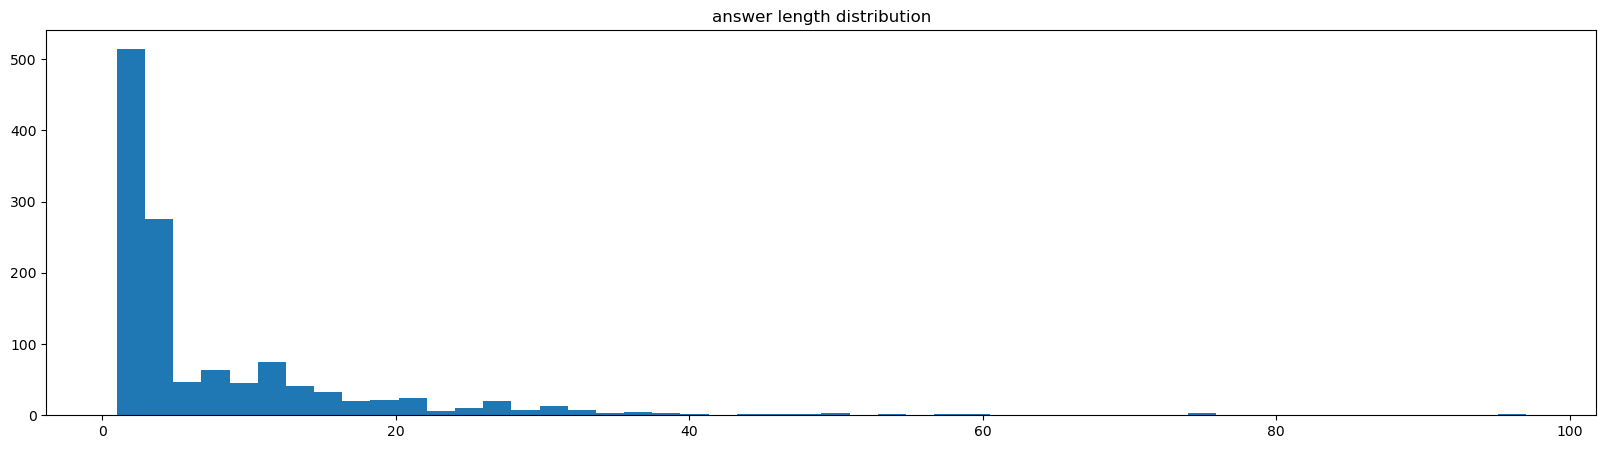

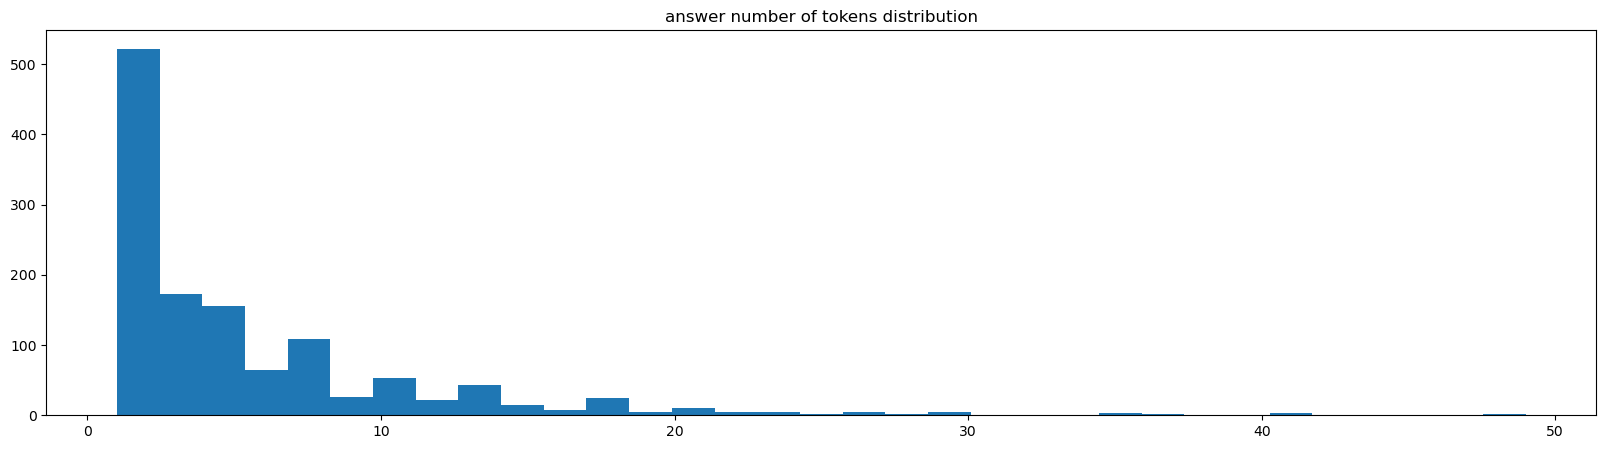

There is 444 unique answer.


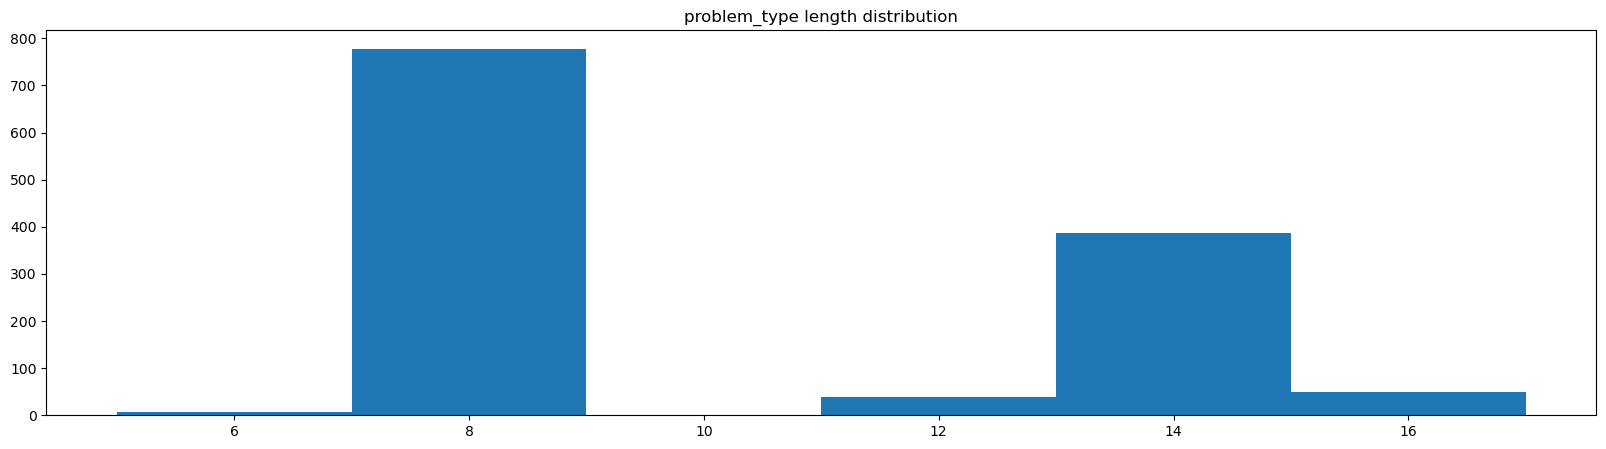

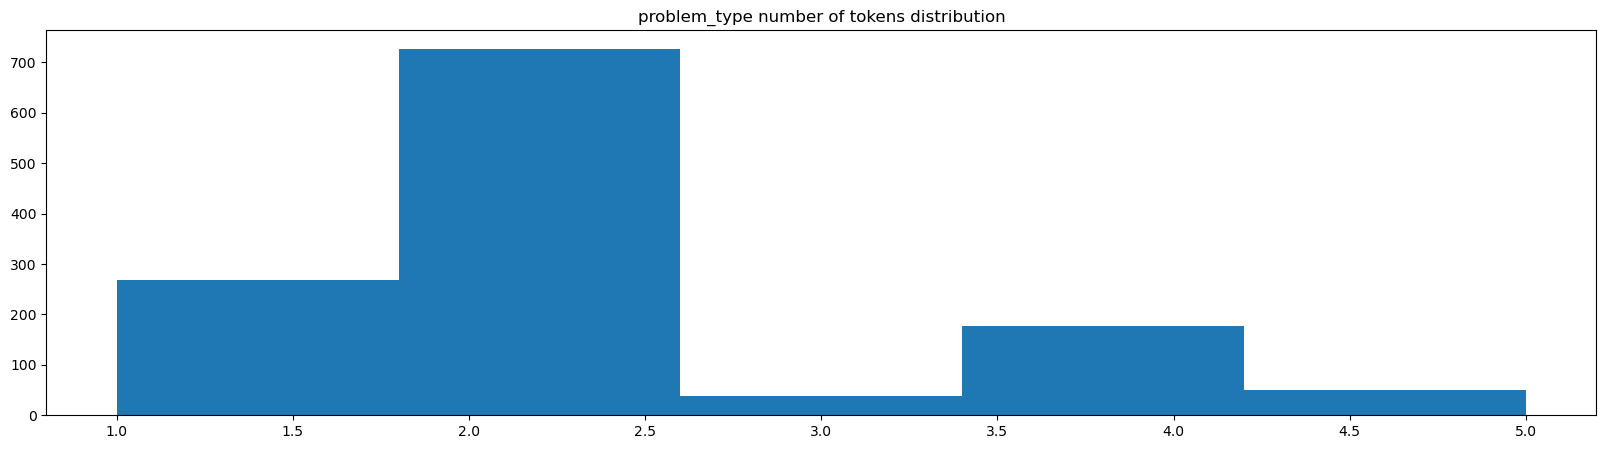

There is 8 unique problem_type.


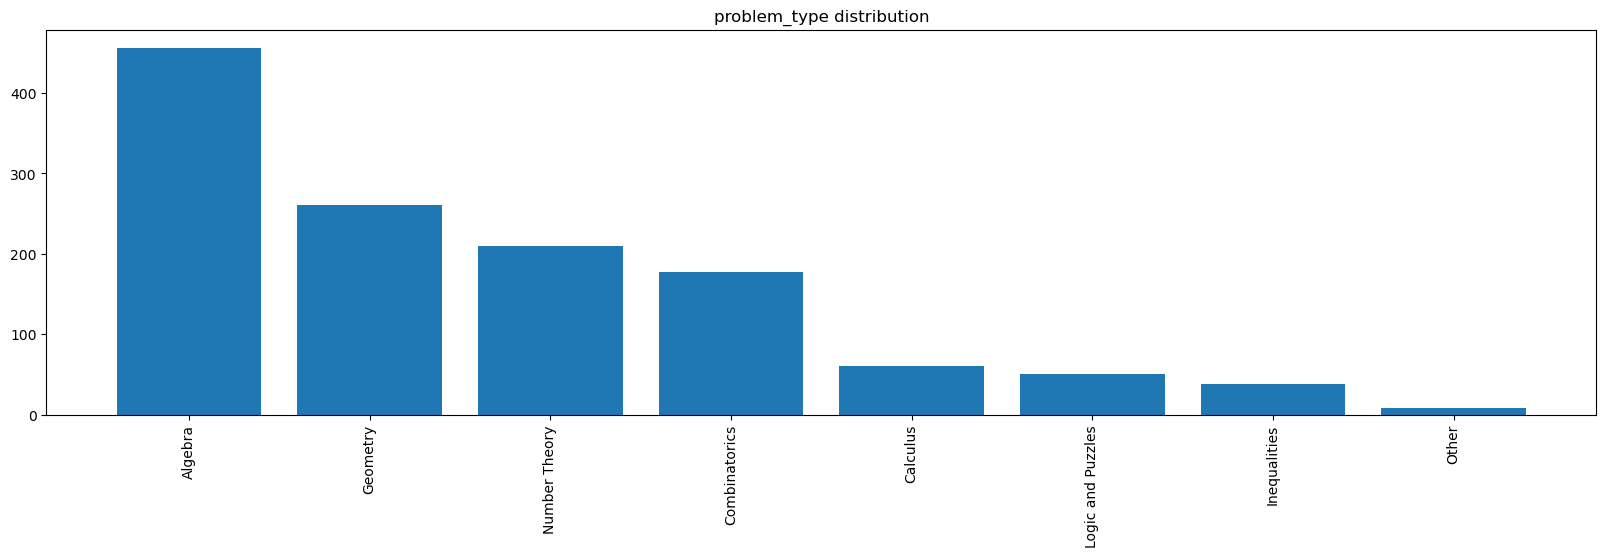

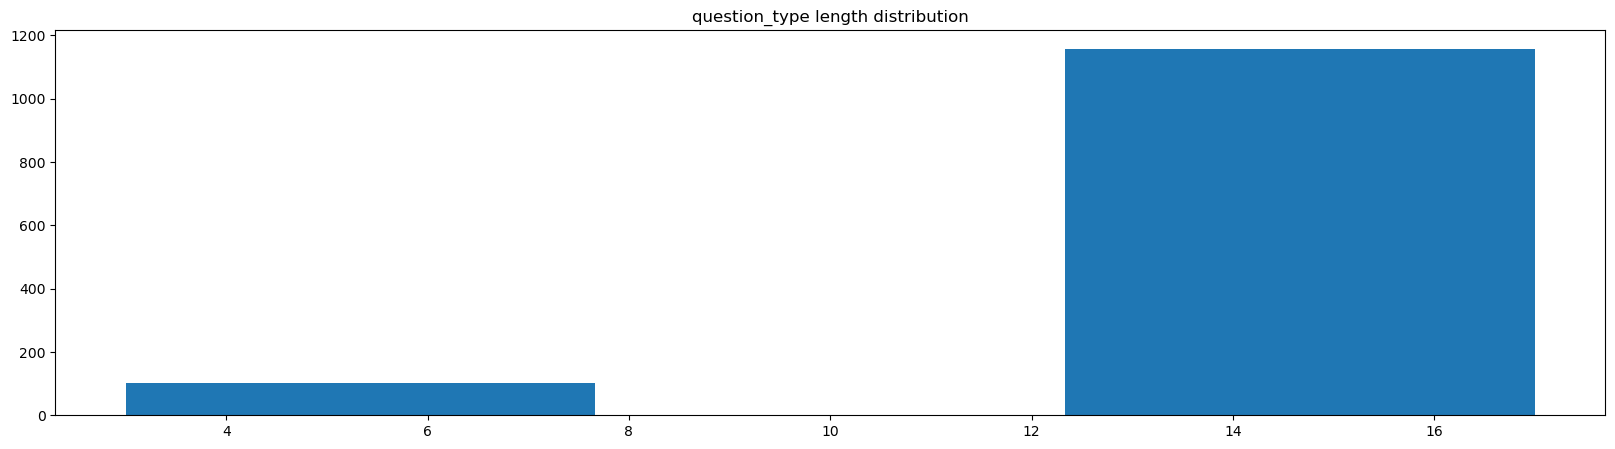

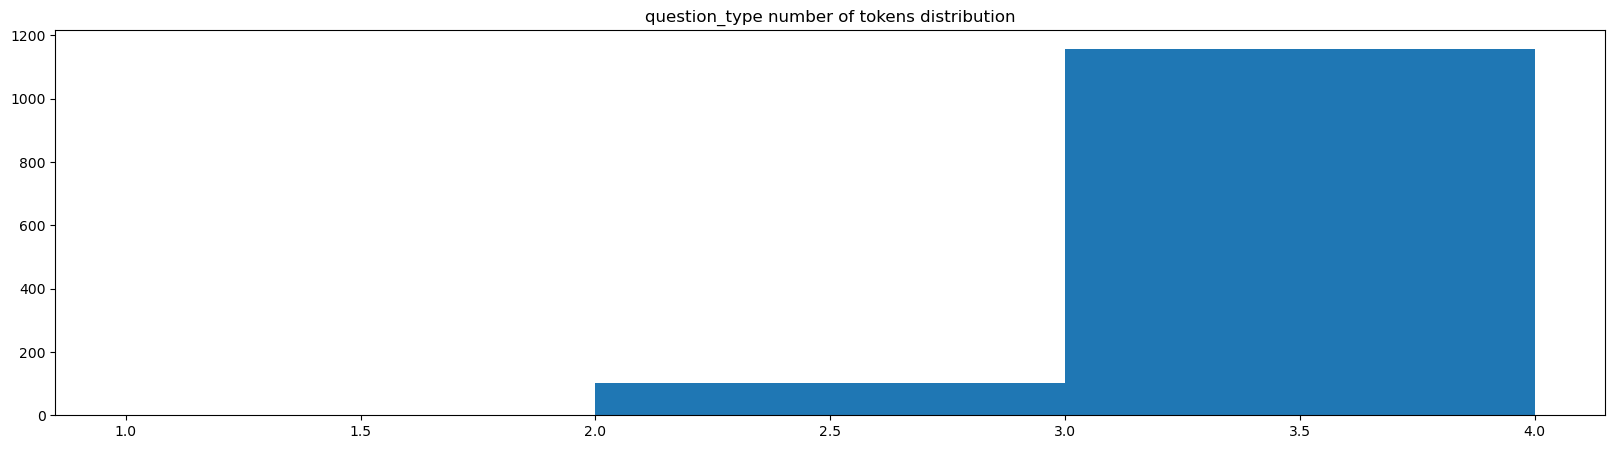

There is 3 unique question_type.


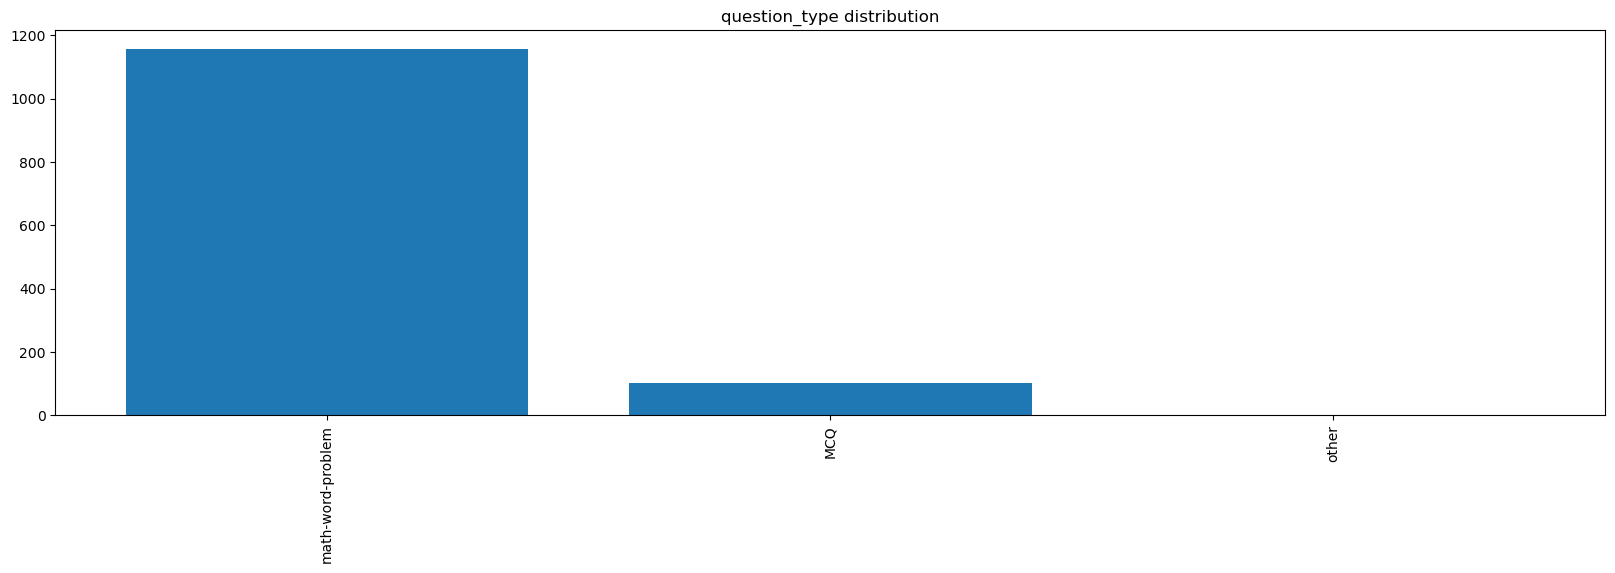

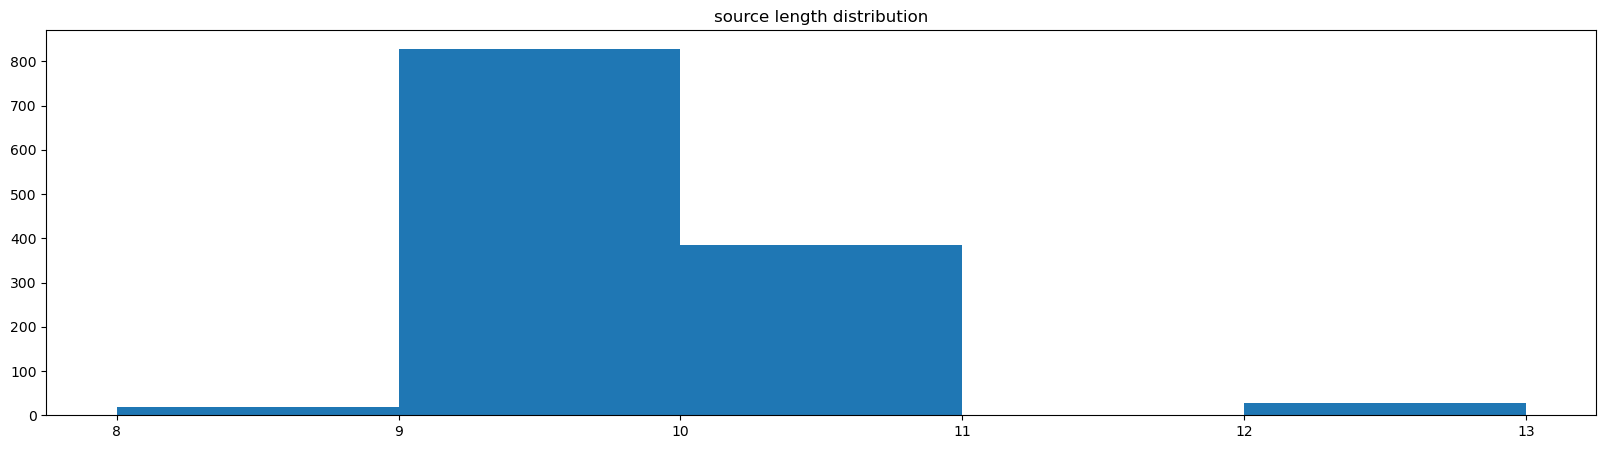

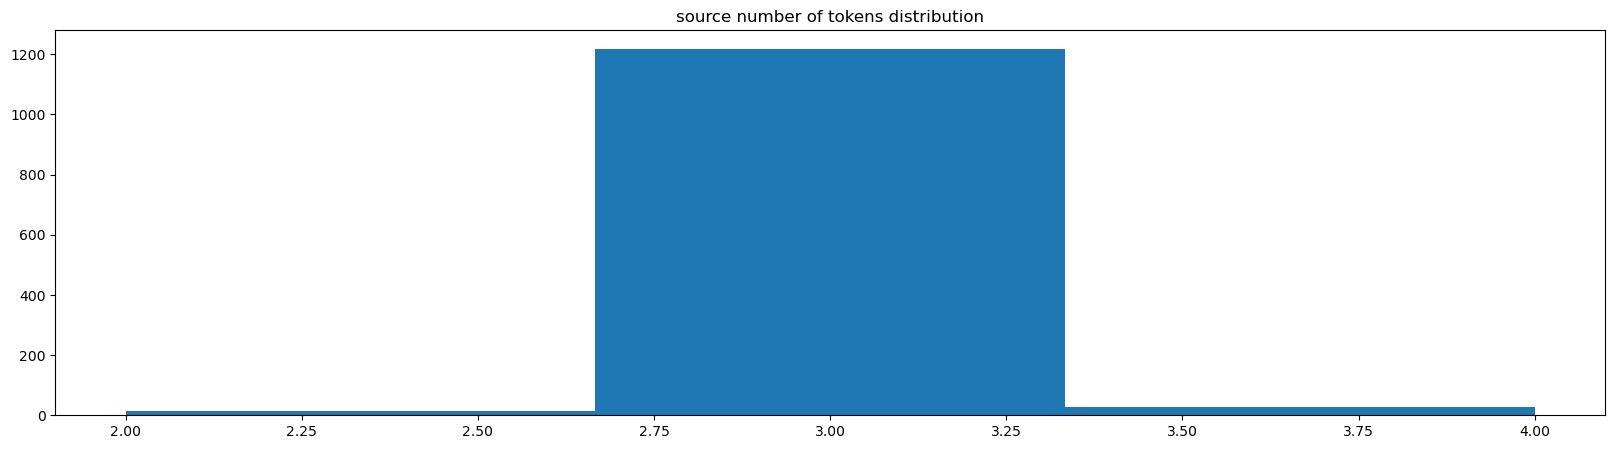

There is 7 unique source.


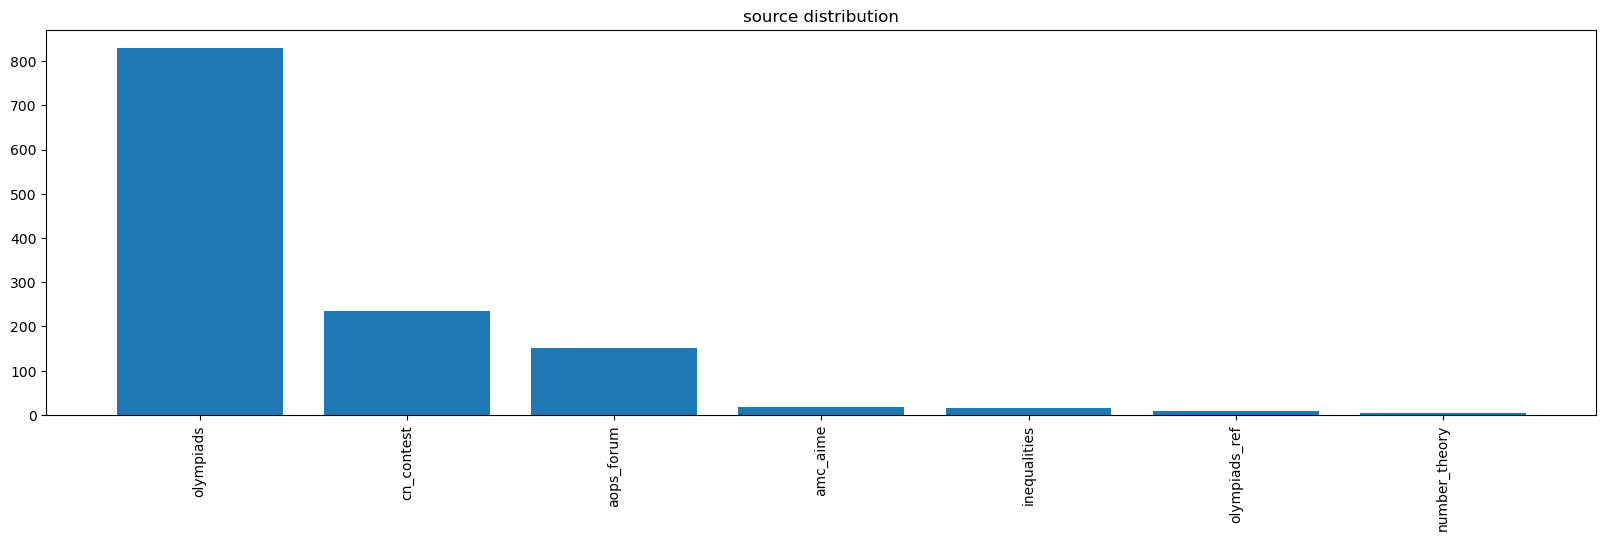

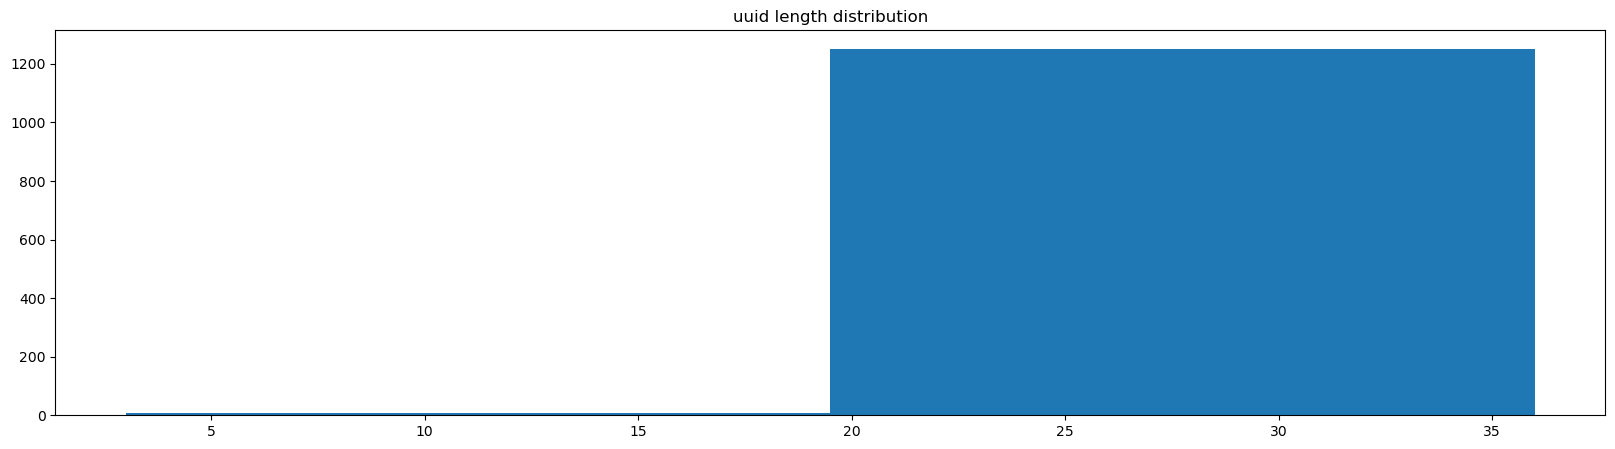

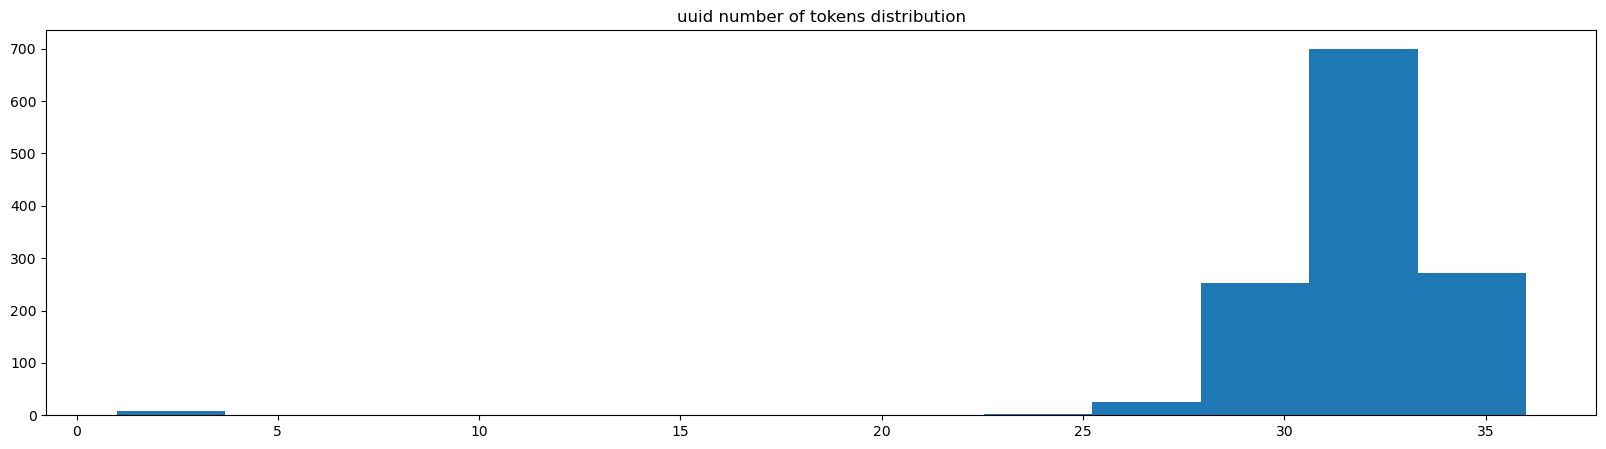

There is 665 unique uuid.


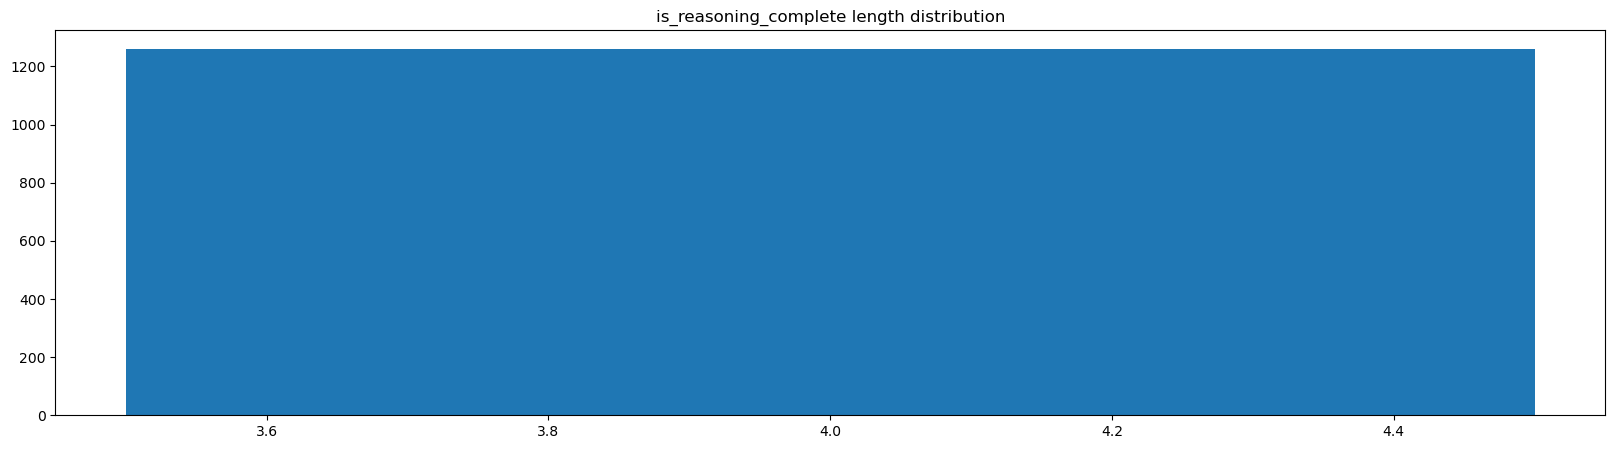

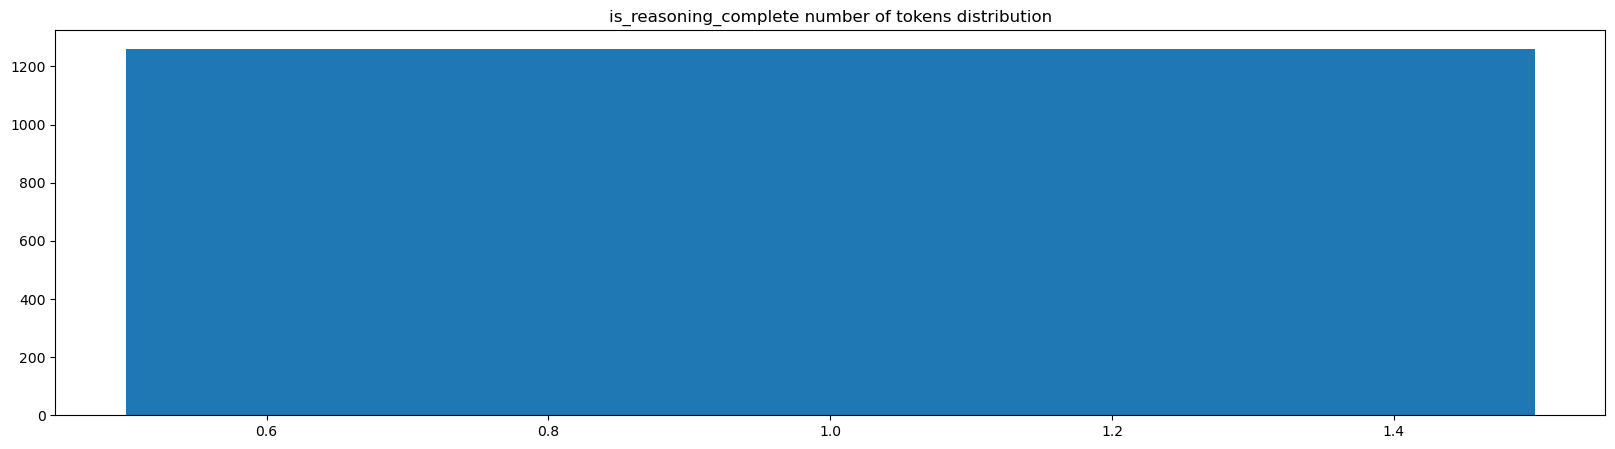

There is 1 unique is_reasoning_complete.


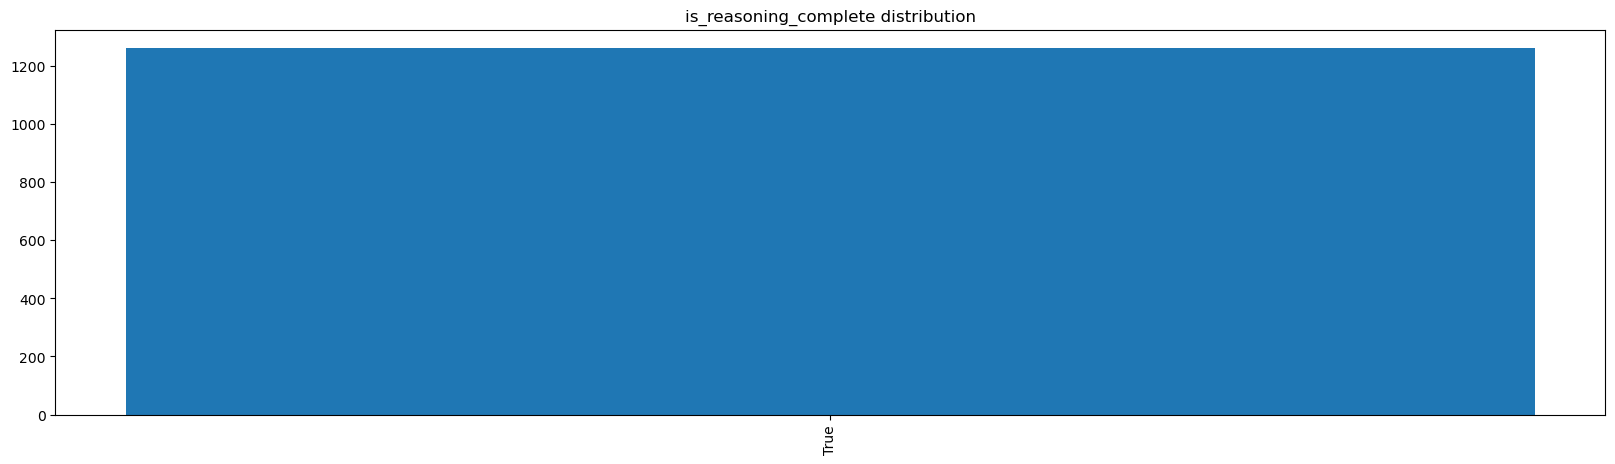

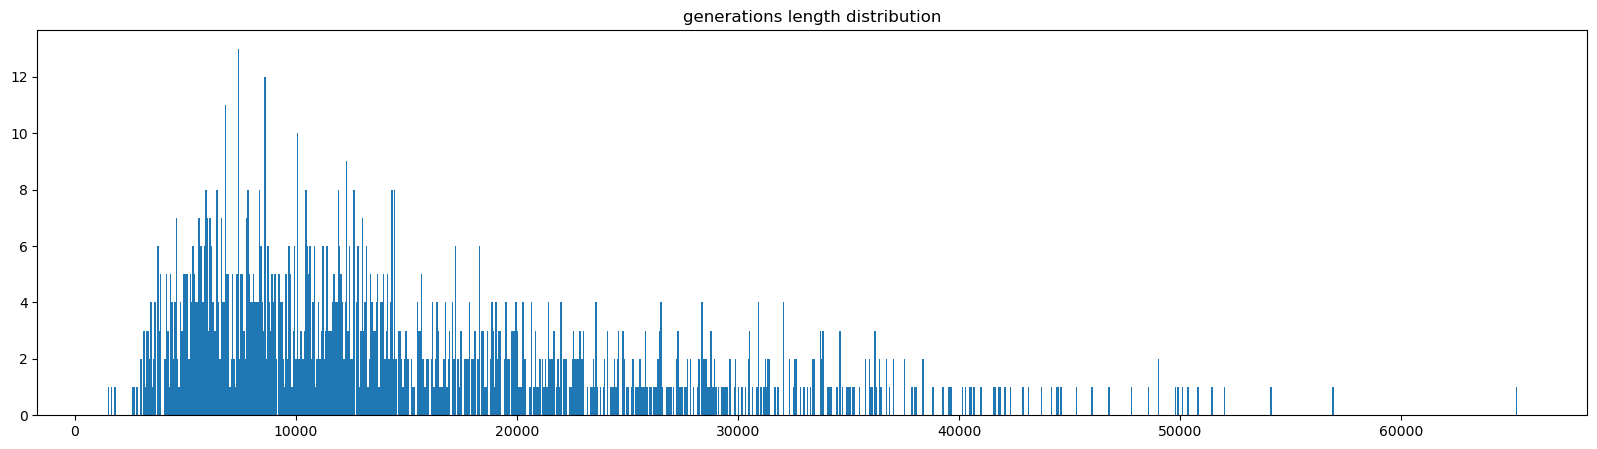

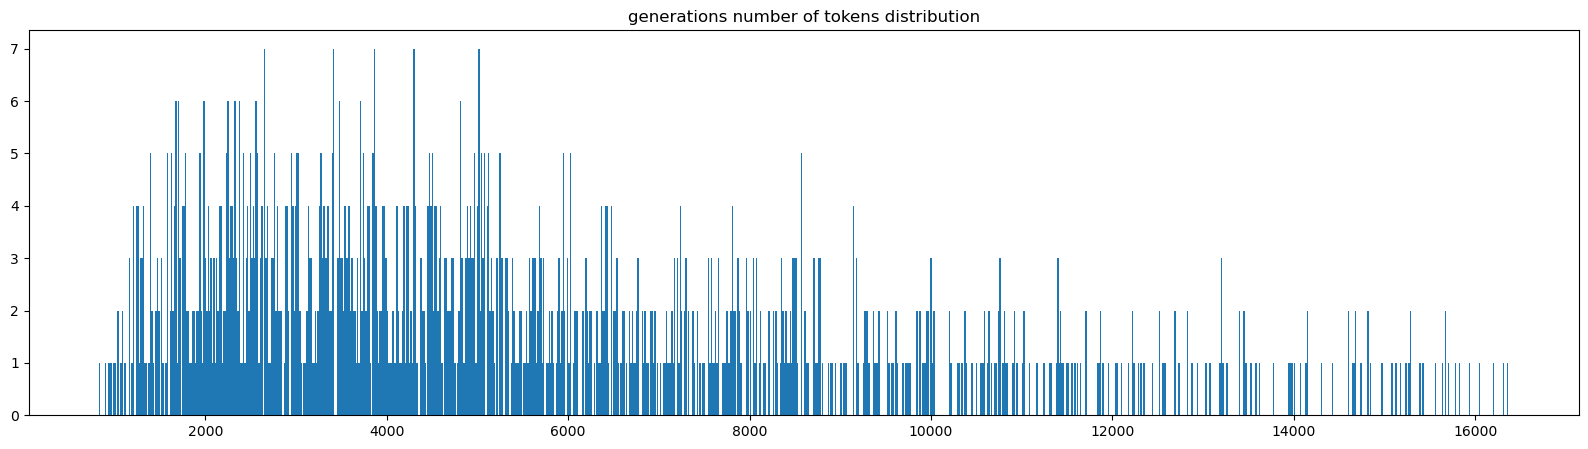

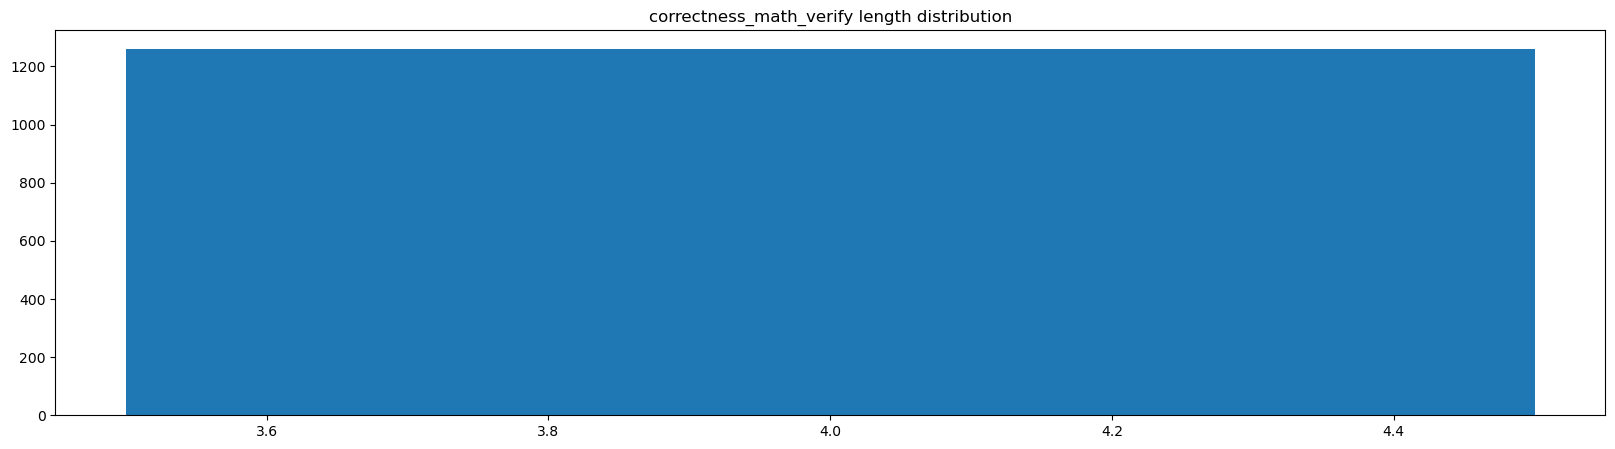

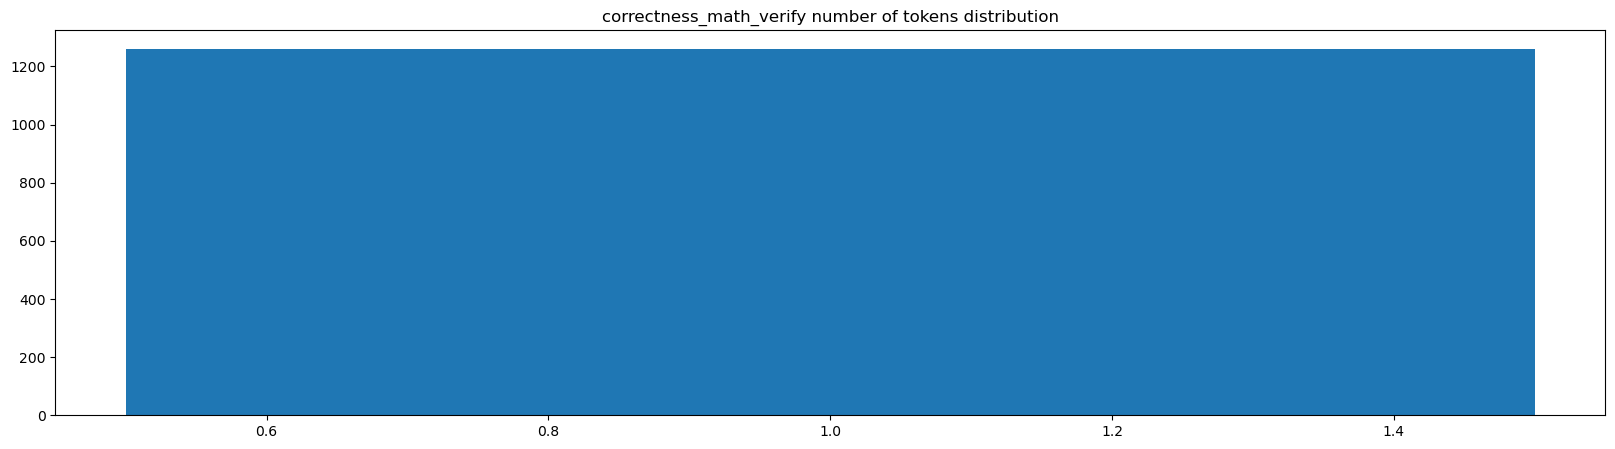

There is 1 unique correctness_math_verify.


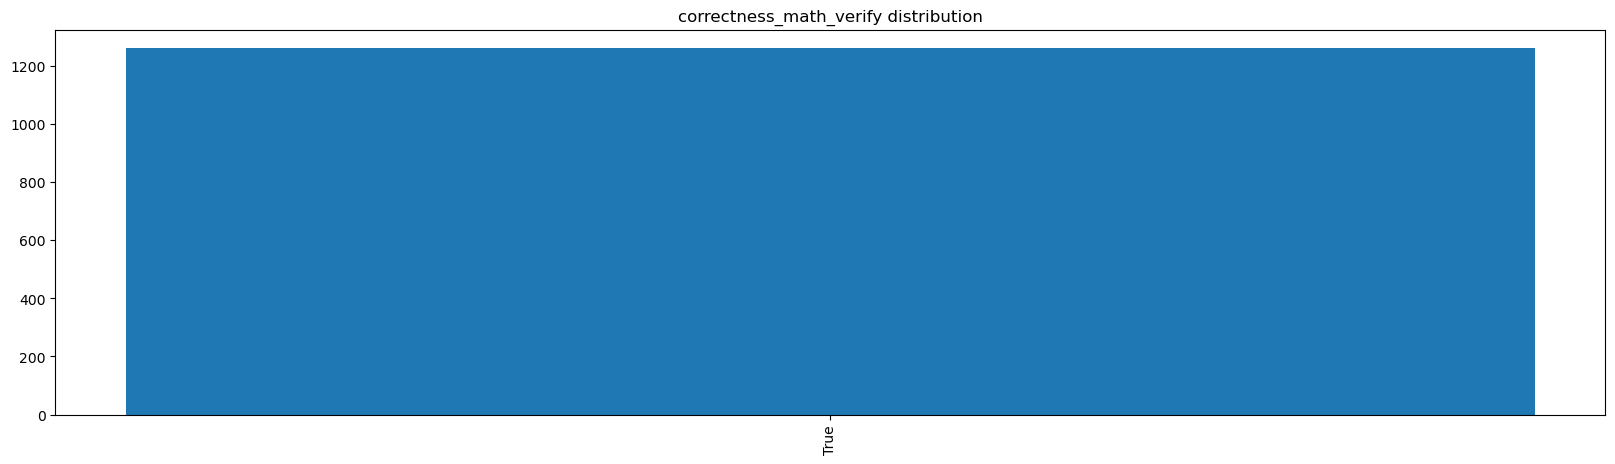

Number of 'None' correctness_llama: 1261
Number of 'None' finish_reasons: 976


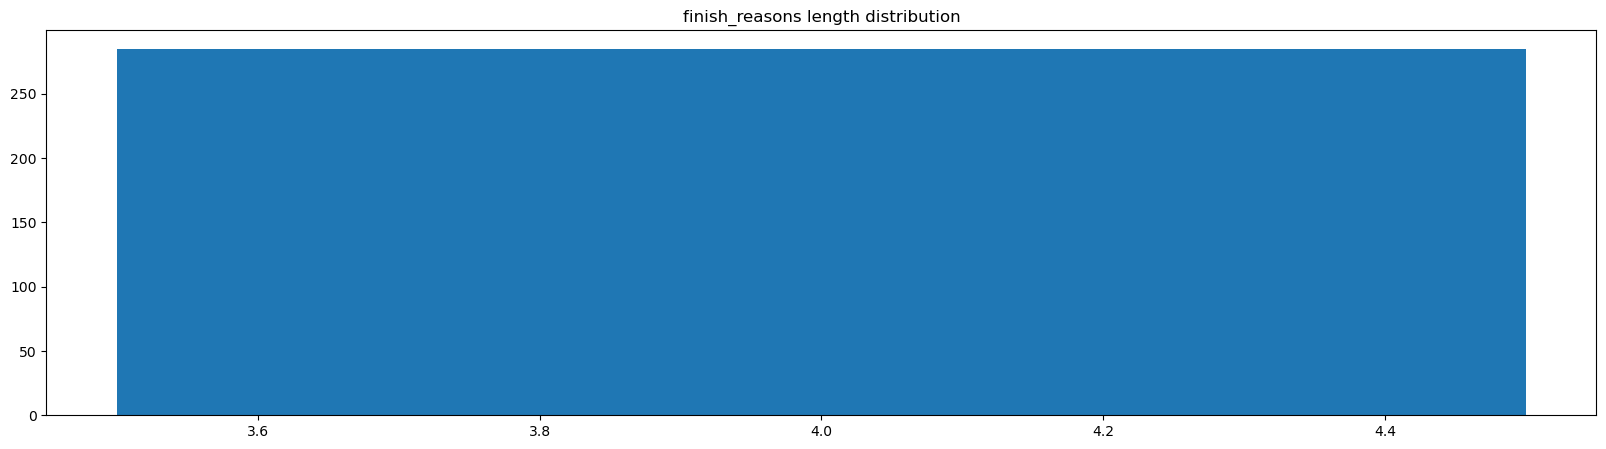

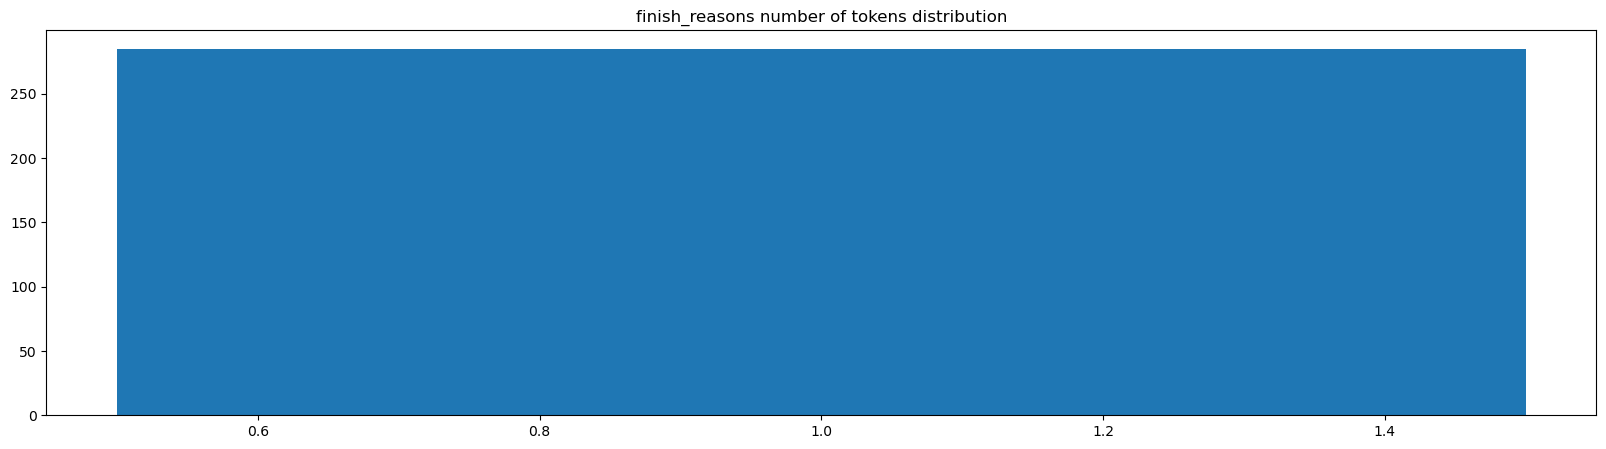

There is 1 unique finish_reasons.


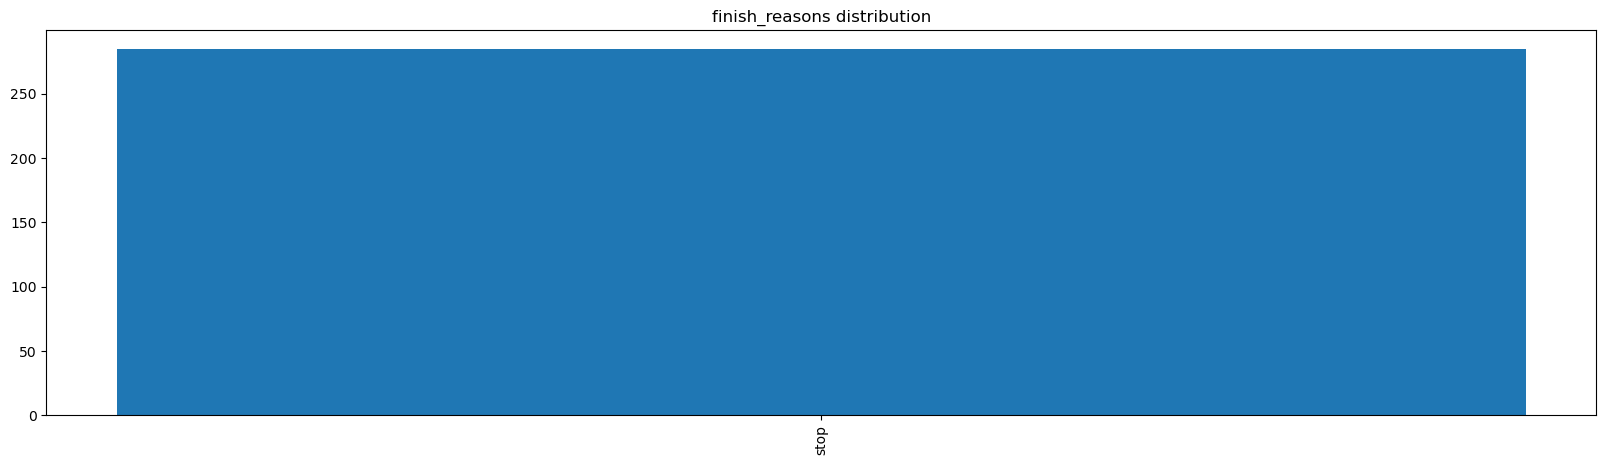

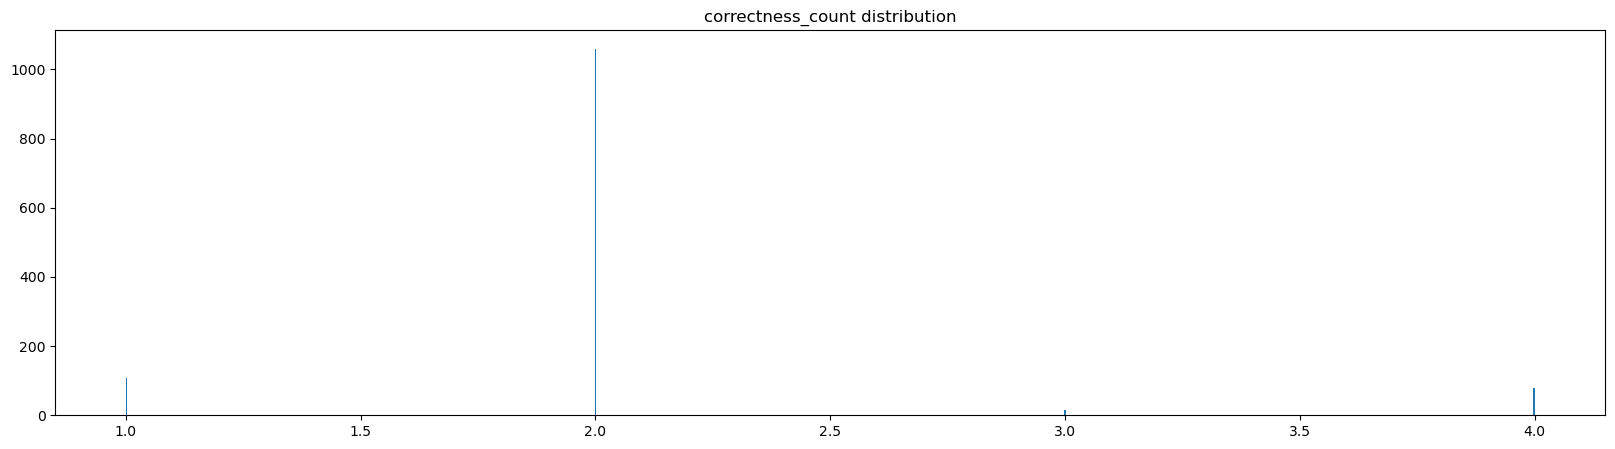

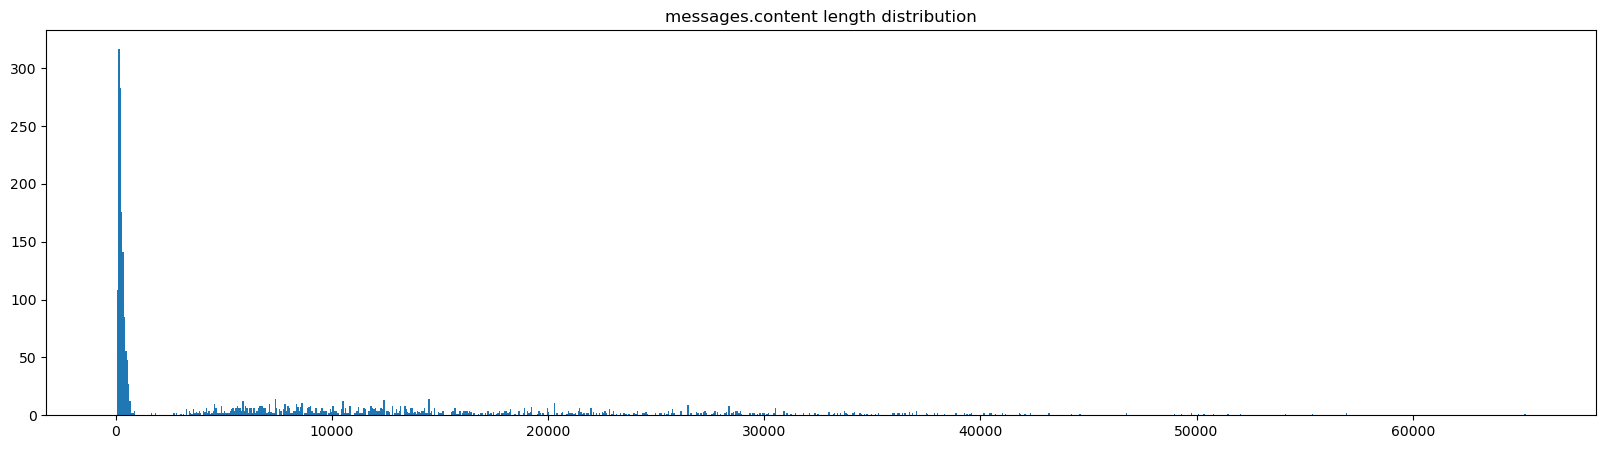

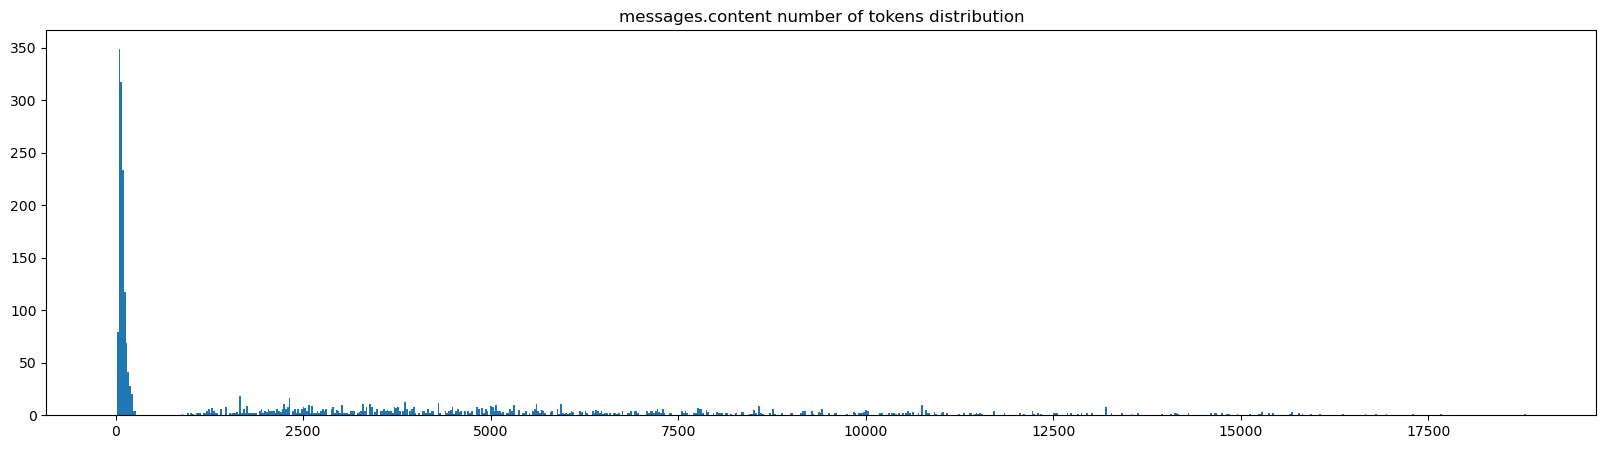

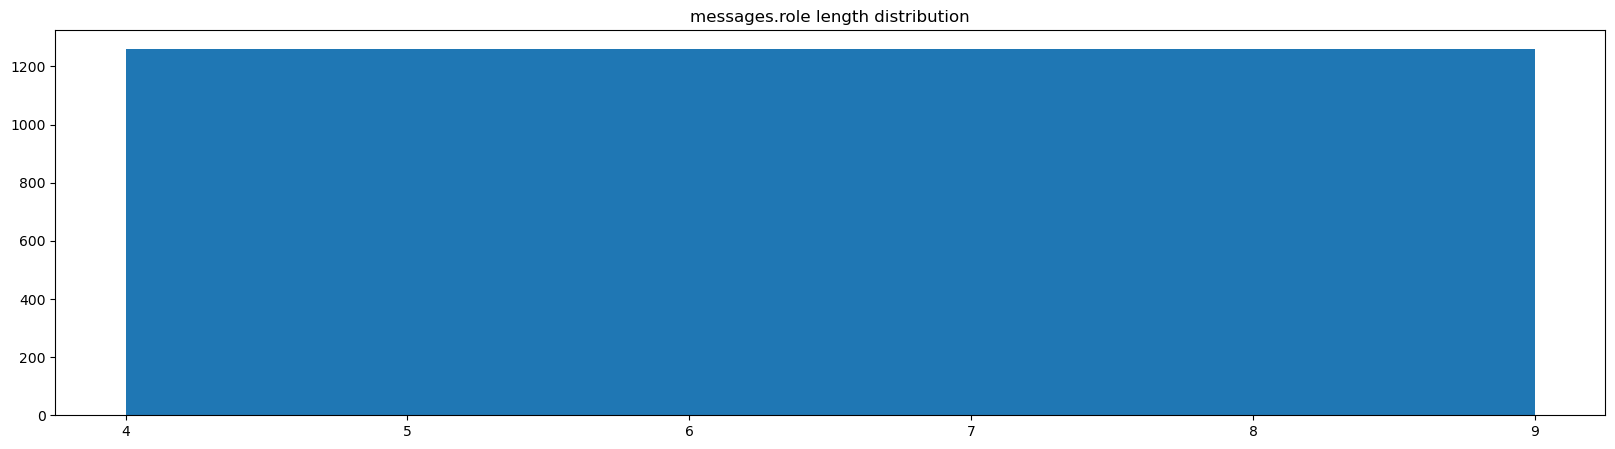

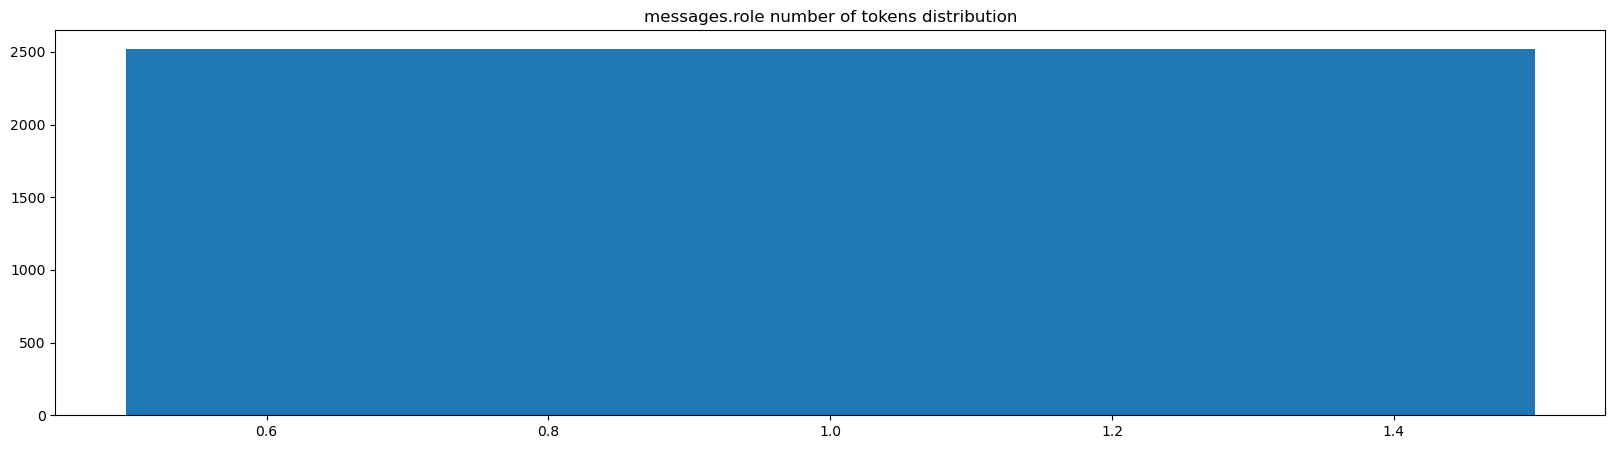

There is 2 unique messages.role.


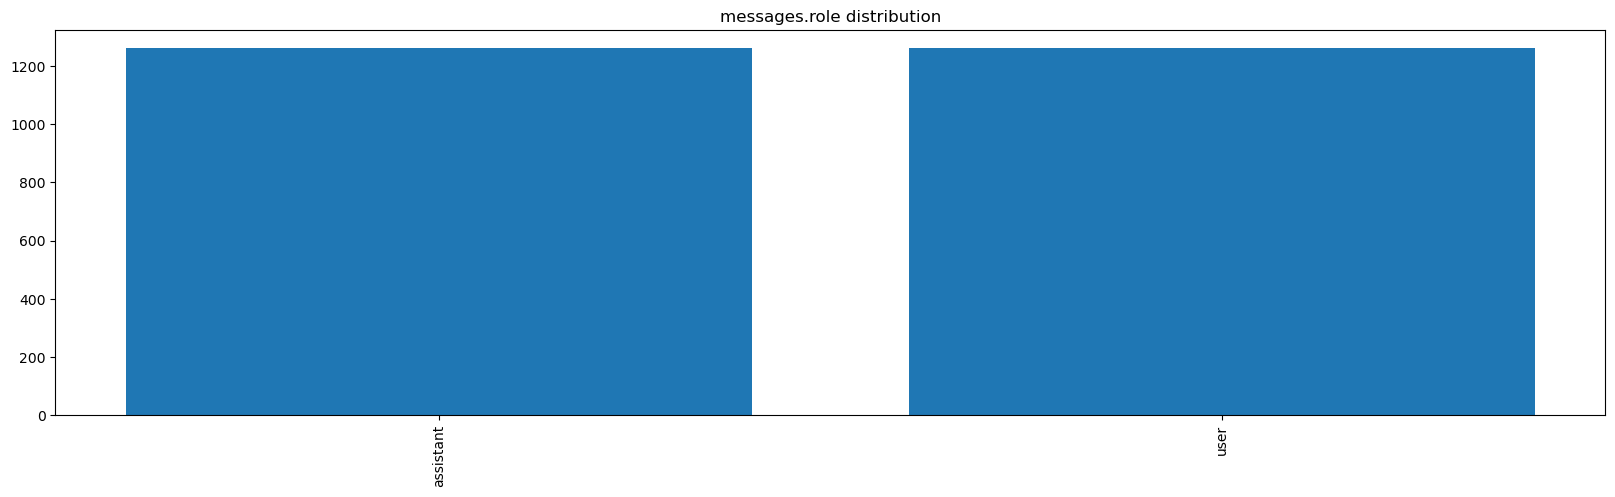

In [8]:
open_r1_math = load_data("OpenR1-Math-220k").select(range(1000))
open_r1_math = flatten_features(open_r1_math, ['generations', 'is_reasoning_complete', 'correctness_math_verify', 'correctness_llama', 'finish_reasons'])
open_r1_math = filter_open_r1_math(open_r1_math)
print_distributions(open_r1_math, ['problem', 'solution', 'answer', 'problem_type', 'question_type', 'source', 'uuid', 'is_reasoning_complete', 'generations', 'correctness_math_verify', 'correctness_llama', 'finish_reasons', 'correctness_count', 'messages'])

### OpenThoughts 2

Filtered 5.27% of the dataset
Features: ['conversations', 'question', 'source', 'id']
Number of samples: 9473
Sample: {
    "conversations": [
        {
            "from": "user",
            "value": "If the function $f(x)=\\frac{x+1}{|x|+1}$, where $x\\in \\mathbb{R}$, then the solution set of the inequality $f(x^2-2x) < f(3x-4)$ is ______."
        },
        {
            "from": "assistant",
            "value": "<think>\nAlright, let me try to tackle this inequality problem step by step. The function given is f(x) = (x + 1)/(|x| + 1), and we need to find where f(x\u00b2 - 2x) is less than f(3x - 4). Hmm, okay. First, maybe I should understand how the function f behaves. Let me recall that absolute value functions can sometimes be tricky because of the piecewise nature, so I need to be careful with that.\n\nLet me start by analyzing the function f(x) = (x + 1)/(|x| + 1). Since the denominator is |x| + 1, which is always positive (because absolute value is non-negative and we add 

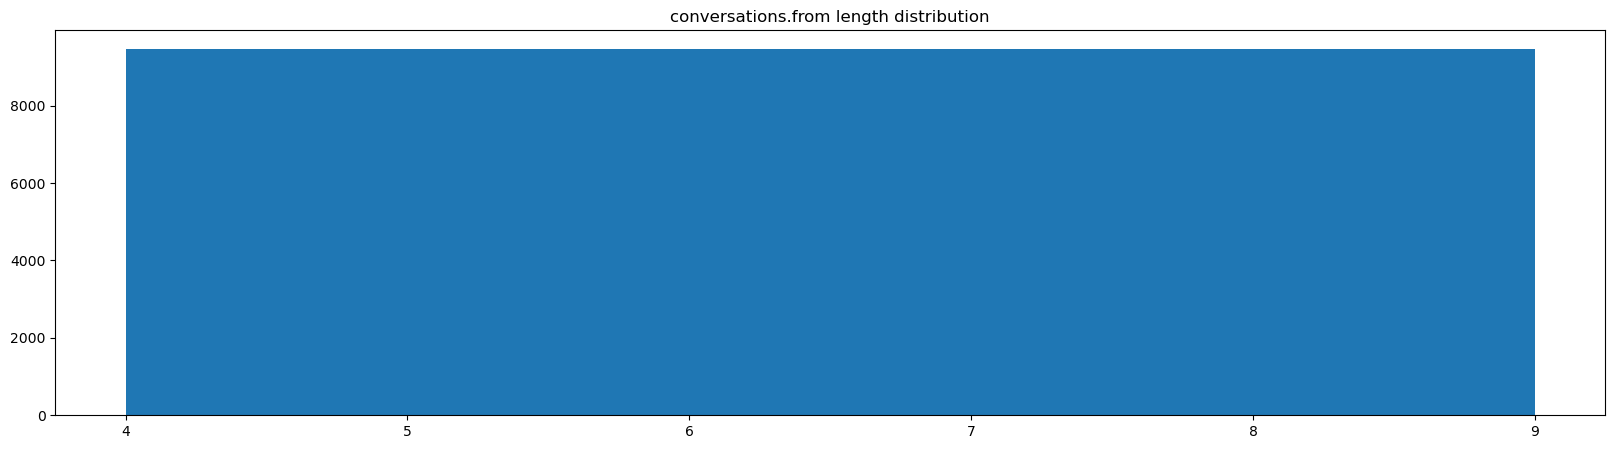

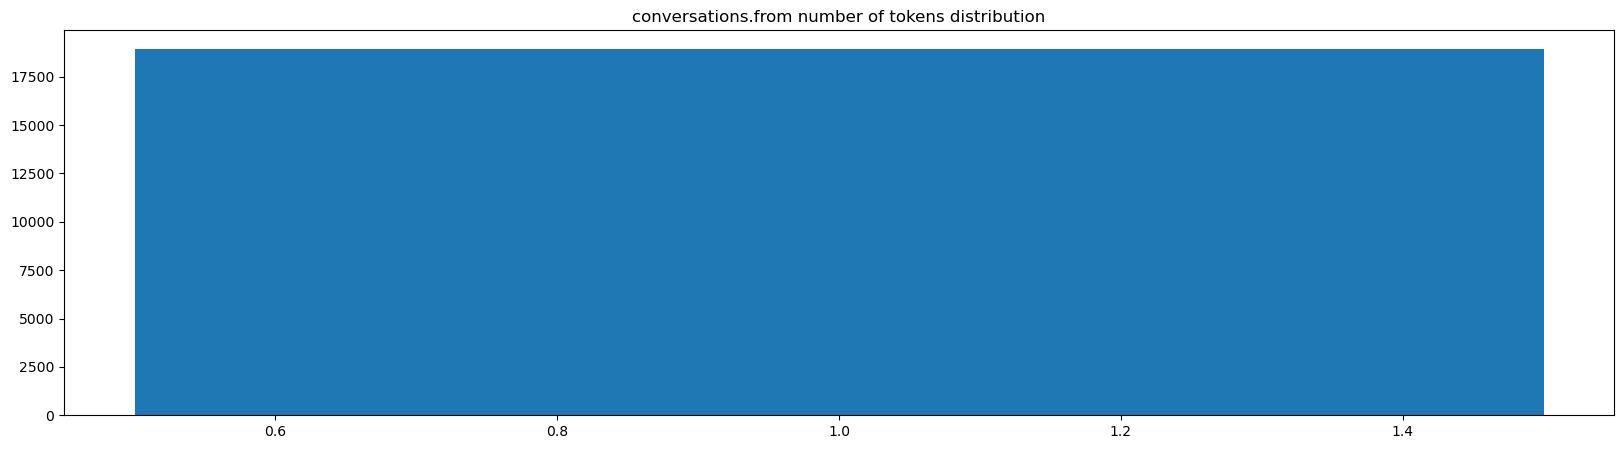

There is 2 unique conversations.from.


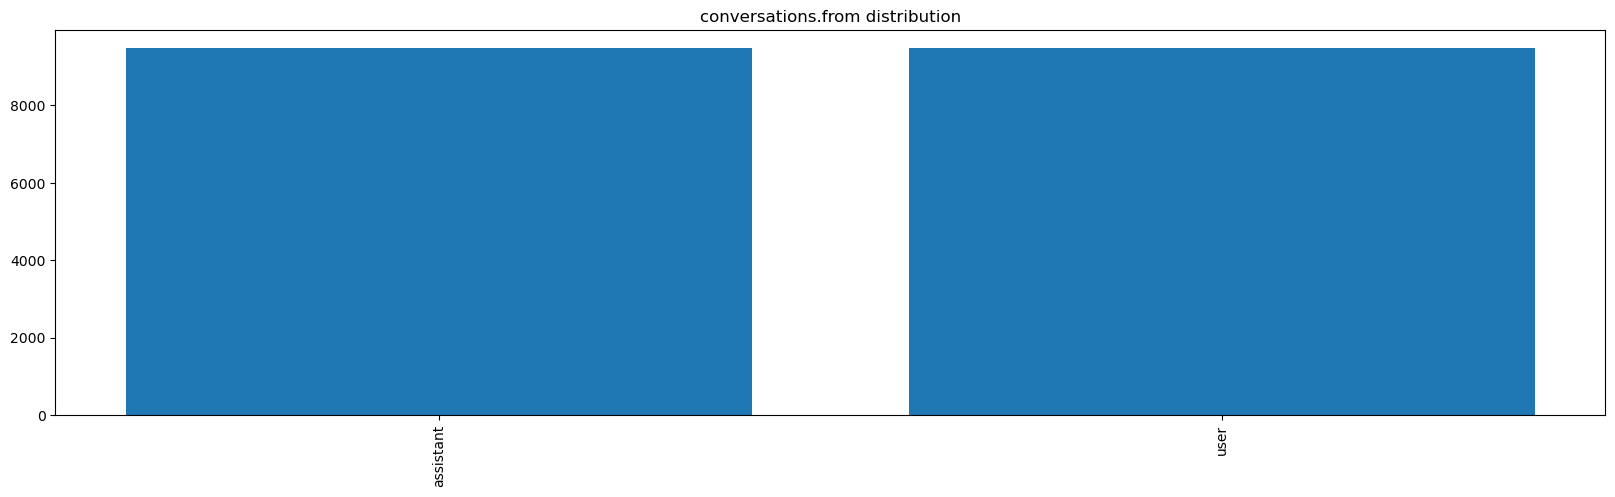

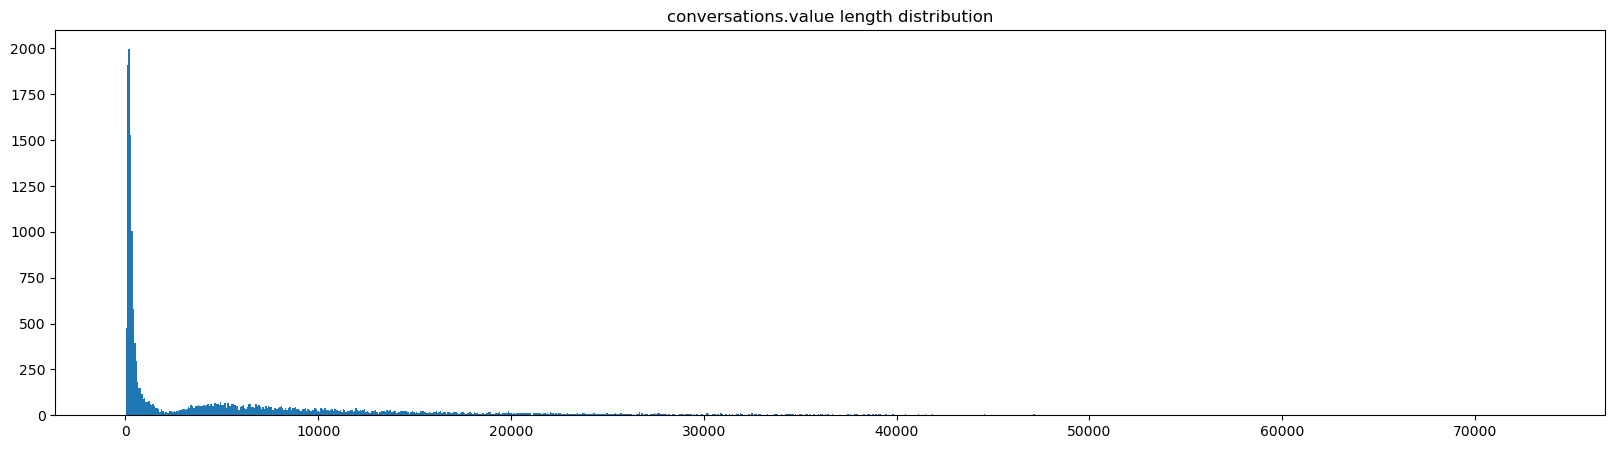

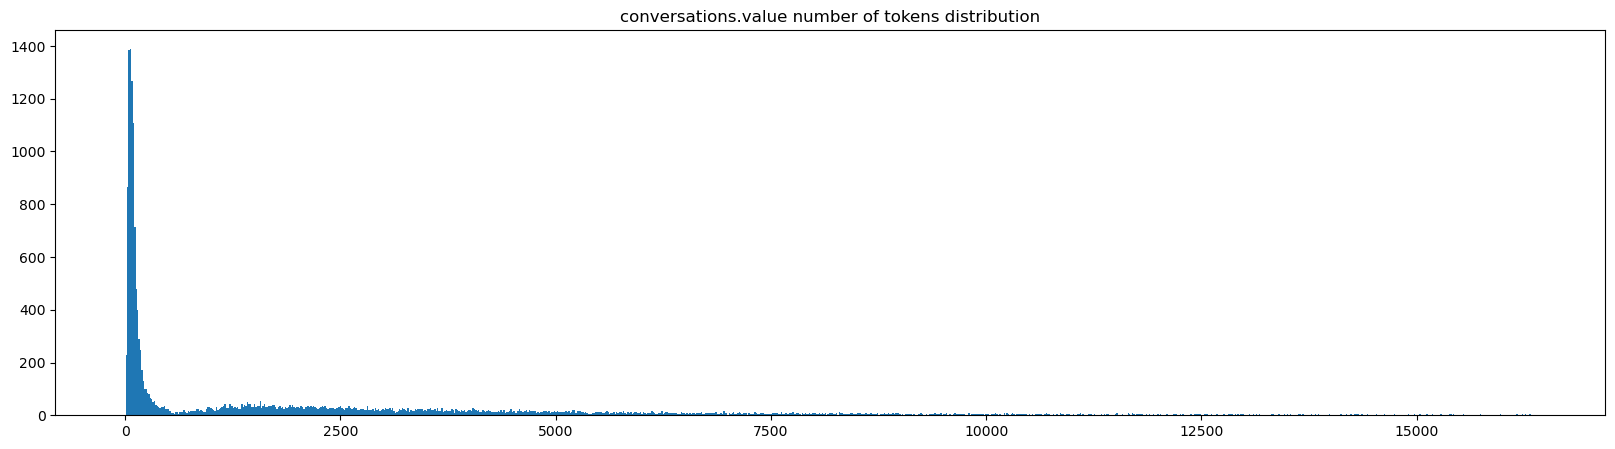

Number of 'None' question: 2334


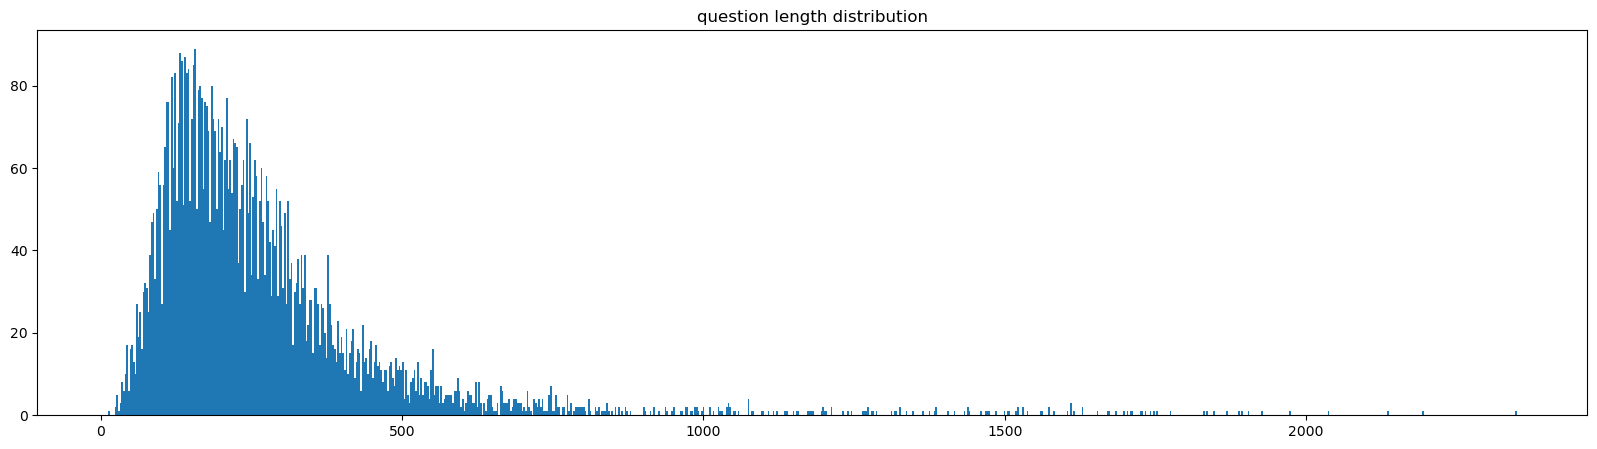

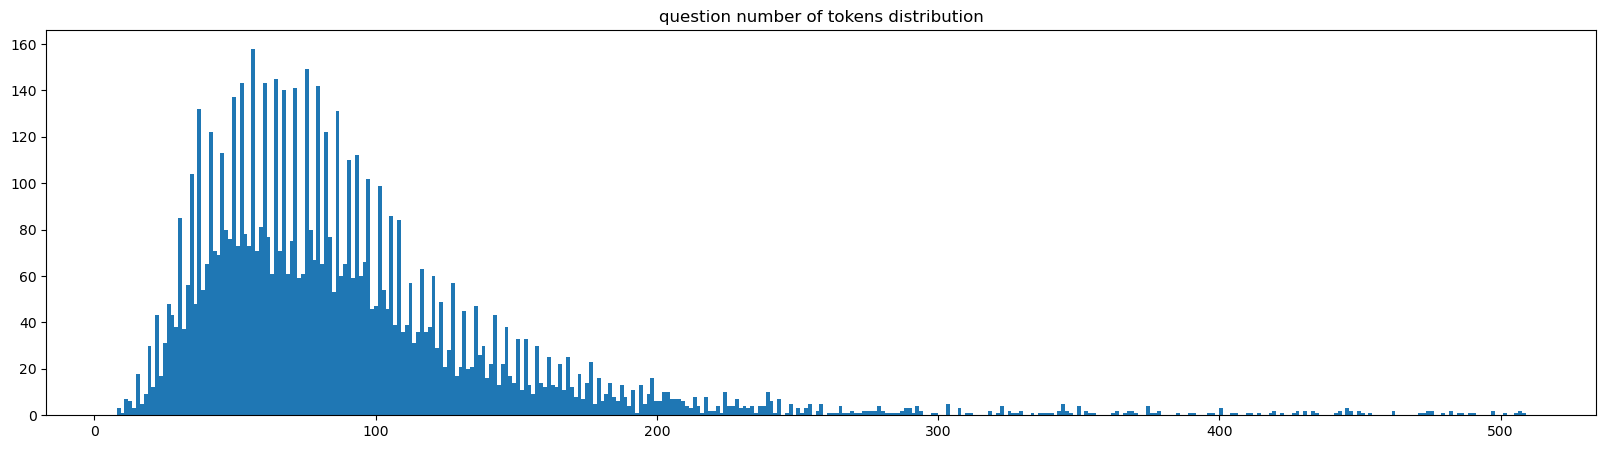

There is 7093 unique question.
Number of 'None' source: 7967


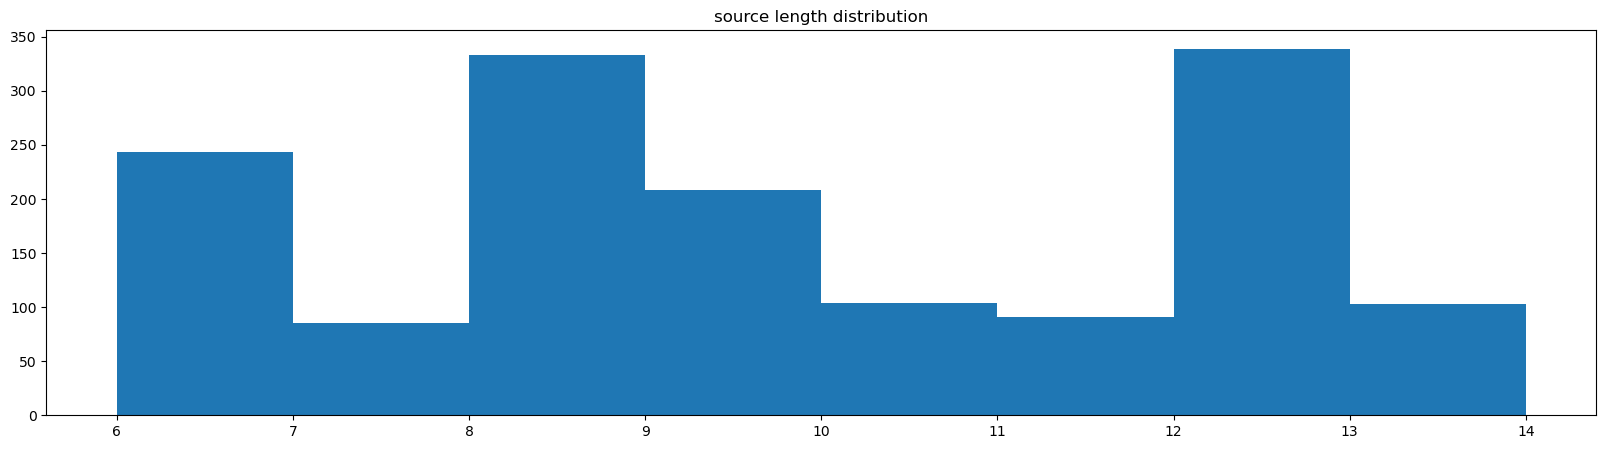

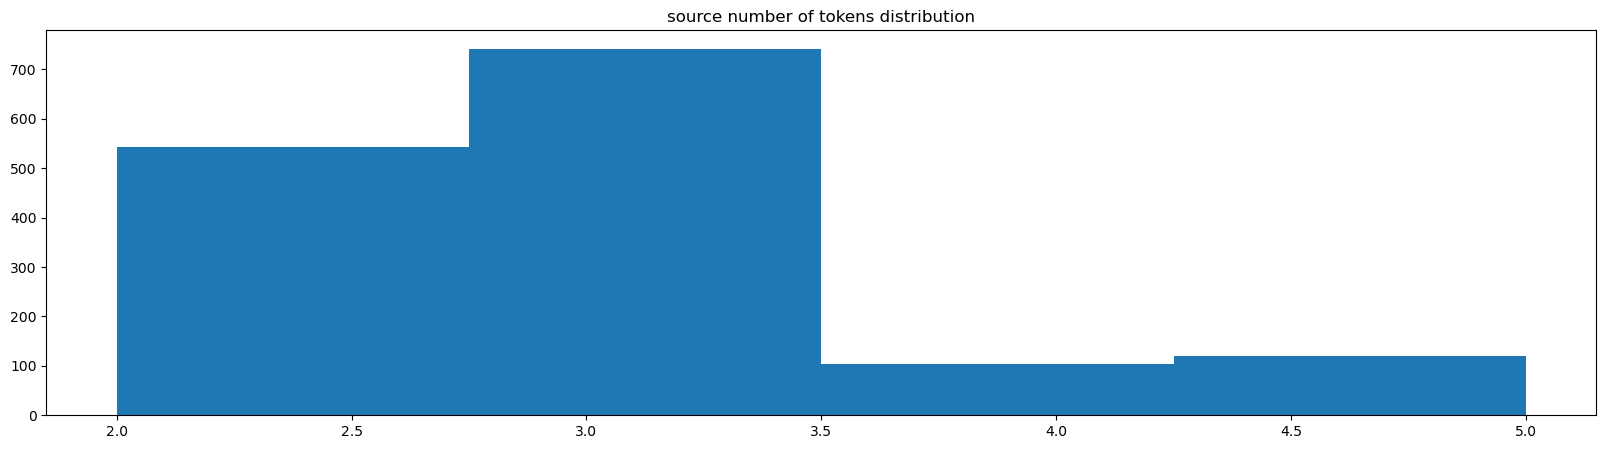

There is 10 unique source.


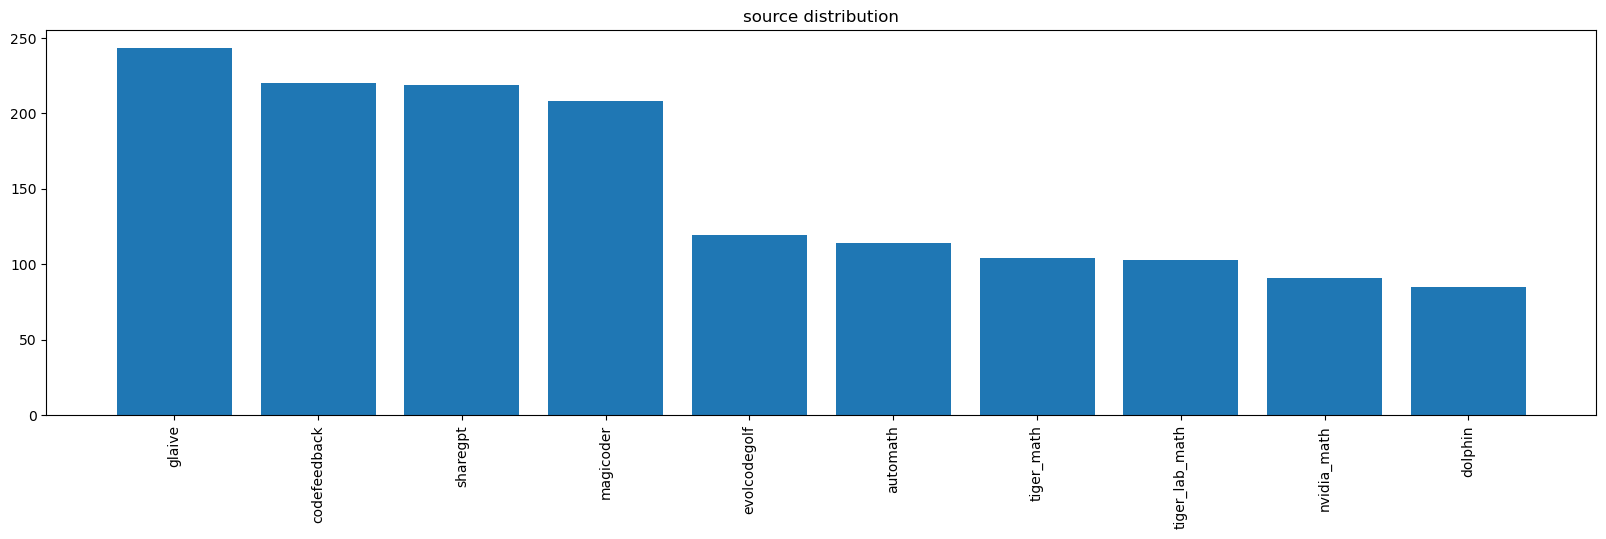

Number of 'None' id: 9061


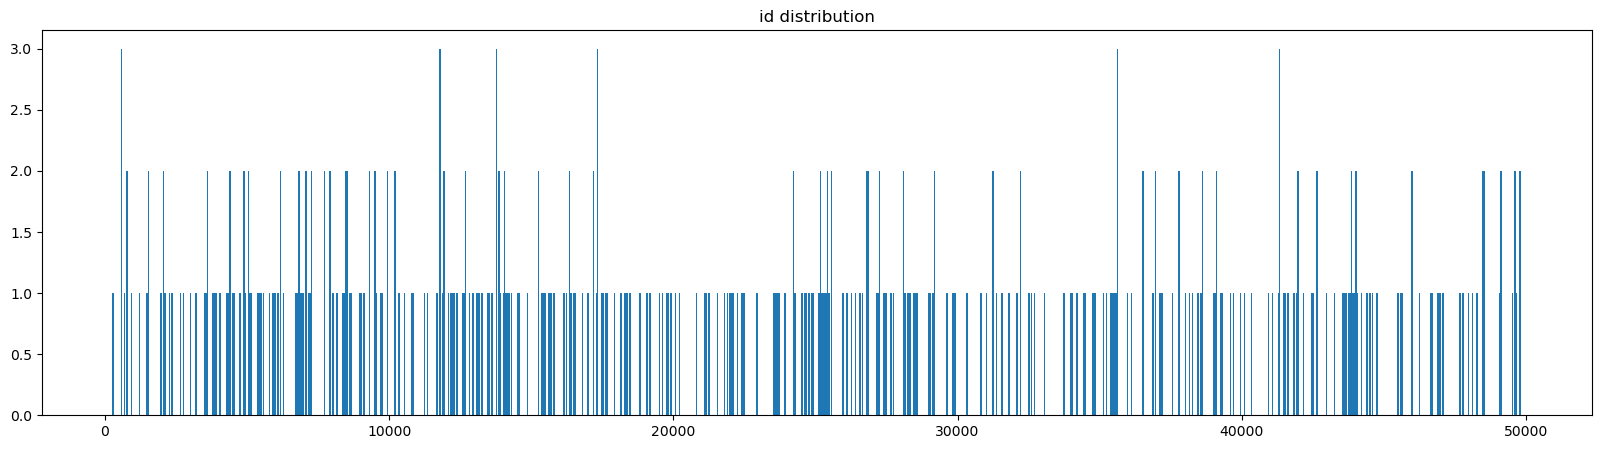

In [9]:
open_thoughts_2 = load_data("OpenThoughts2-1M").select(range(10000))
open_thoughts_2 = filter_open_thoughts_2(open_thoughts_2)
print_distributions(open_thoughts_2, ['conversations', 'question', 'source', 'id'])

### Pensez 0.1

In [10]:
# TODO: manually load every subset
# pensez_0_1 = load_data("Pensez-v0.1/*")
# print_distributions(pensez_0_1, ['question', 'answer', 'source', 'domain', 'llama8b_solve_rate'])

### Polymath

Features: ['id', 'question', 'answer']
Number of samples: 500
Sample: {
    "answer": "-0.127",
    "id": "top-fr-124",
    "question": "Vous \u00eates charg\u00e9 de concevoir une aile d'avion qui optimise l'efficacit\u00e9 a\u00e9rodynamique et la consommation de carburant. La surface de l'aile est mod\u00e9lis\u00e9e par la surface lisse et compacte $ S $ dans $ \\mathbb{R}^3 $, d\u00e9finie par les \u00e9quations param\u00e9triques $ x(u, v) = (u \\cos v, u \\sin v, \\ln(u+1)) $ pour $ u $ dans l'intervalle $ [1, 3] $ et $ v $ dans $ [0, 2\\pi) $. Votre objectif est d'analyser les propri\u00e9t\u00e9s de courbure de la surface de l'aile en un point sp\u00e9cifique $ (u, v) = (2, \\frac{\\pi}{4}) $ afin de d\u00e9terminer des ajustements qui pourraient am\u00e9liorer sa performance a\u00e9rodynamique.\nEnsuite, calculez la courbure moyenne $H$ de la surface de l'aile au point $(2, \\frac{\\pi}{4})$. Arrondissez votre r\u00e9sultat final \u00e0 trois d\u00e9cimales."
}


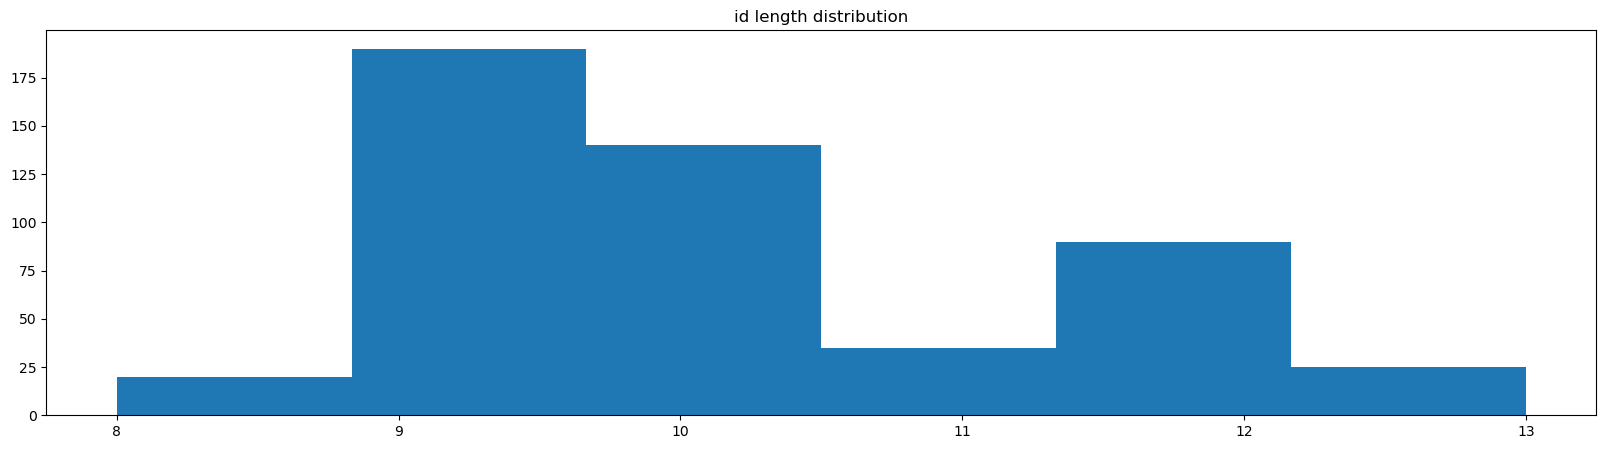

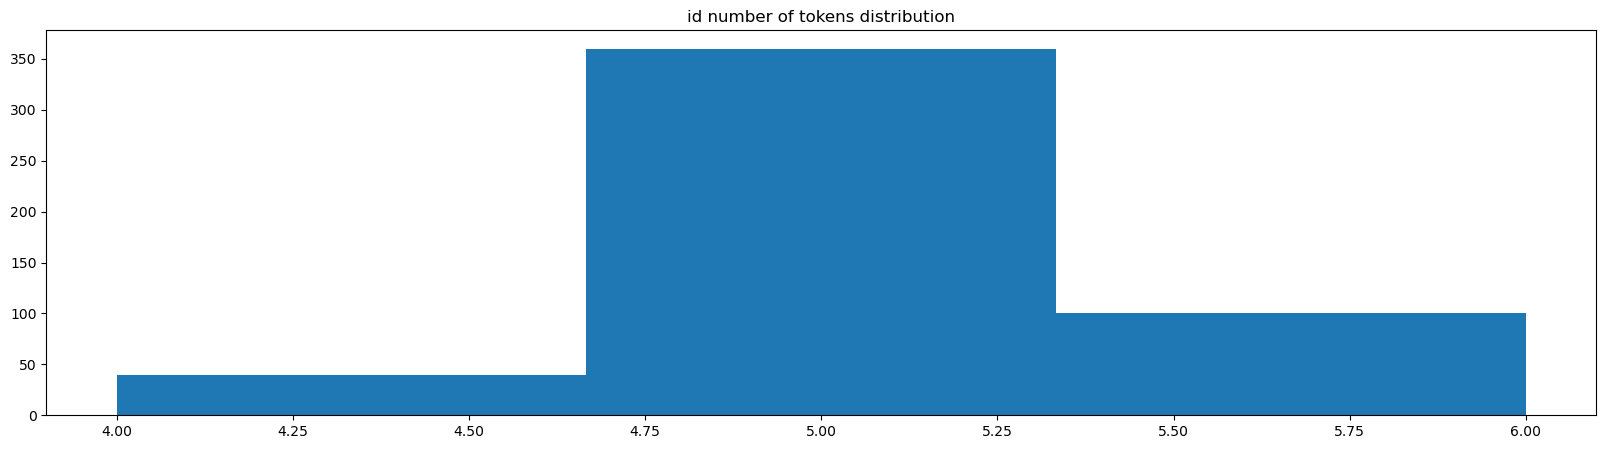

There is 500 unique id.


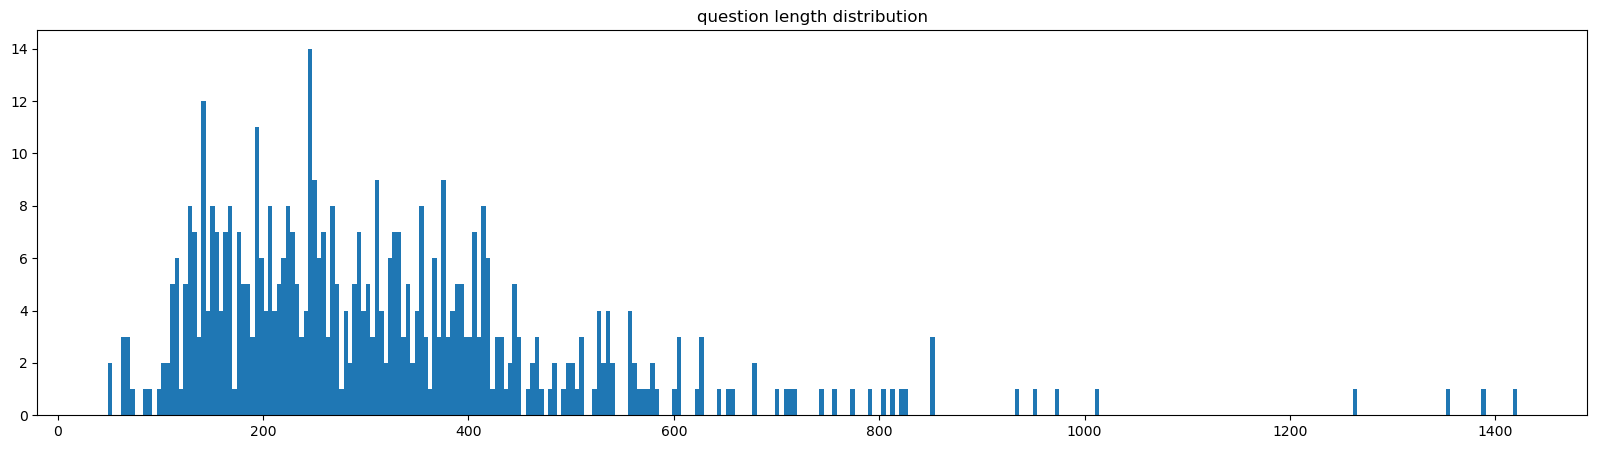

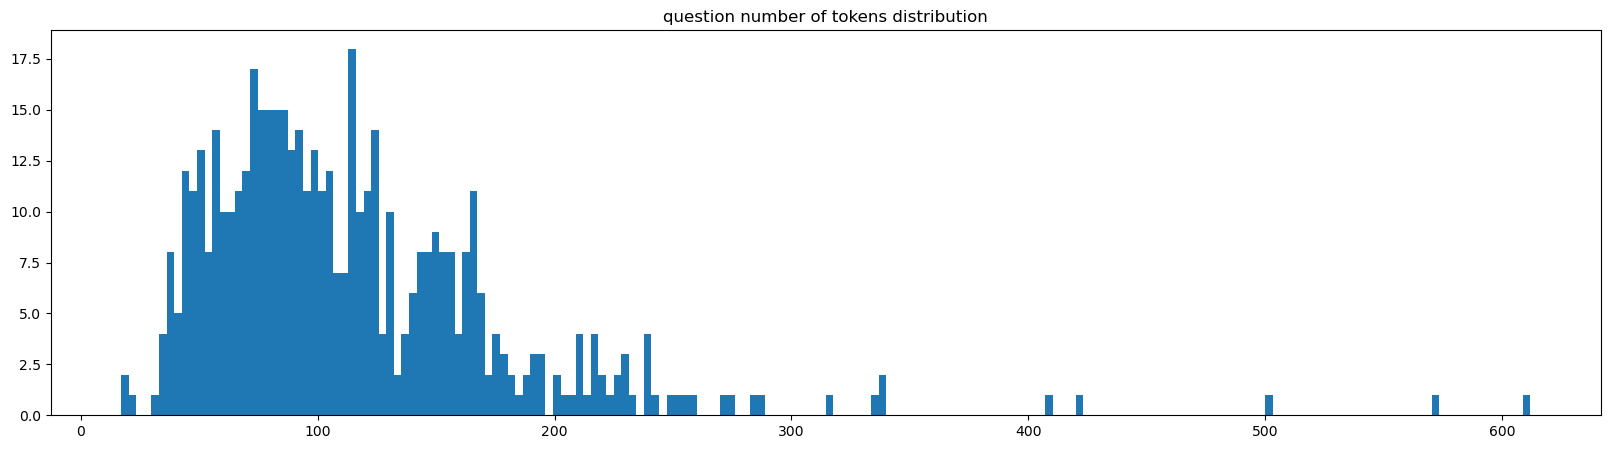

There is 500 unique question.


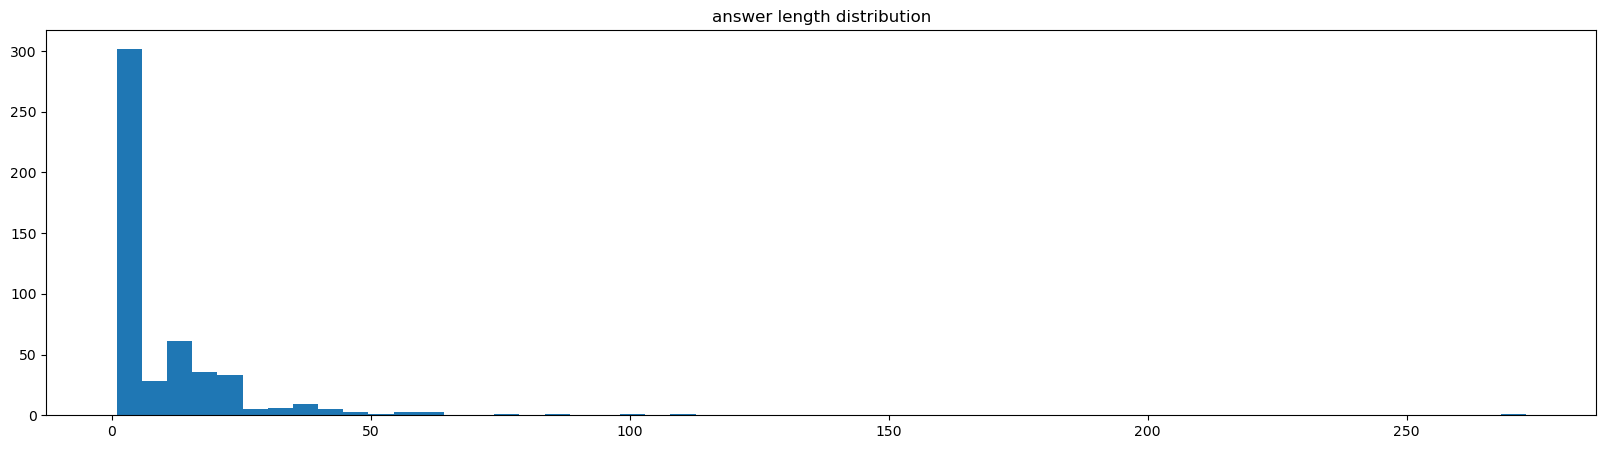

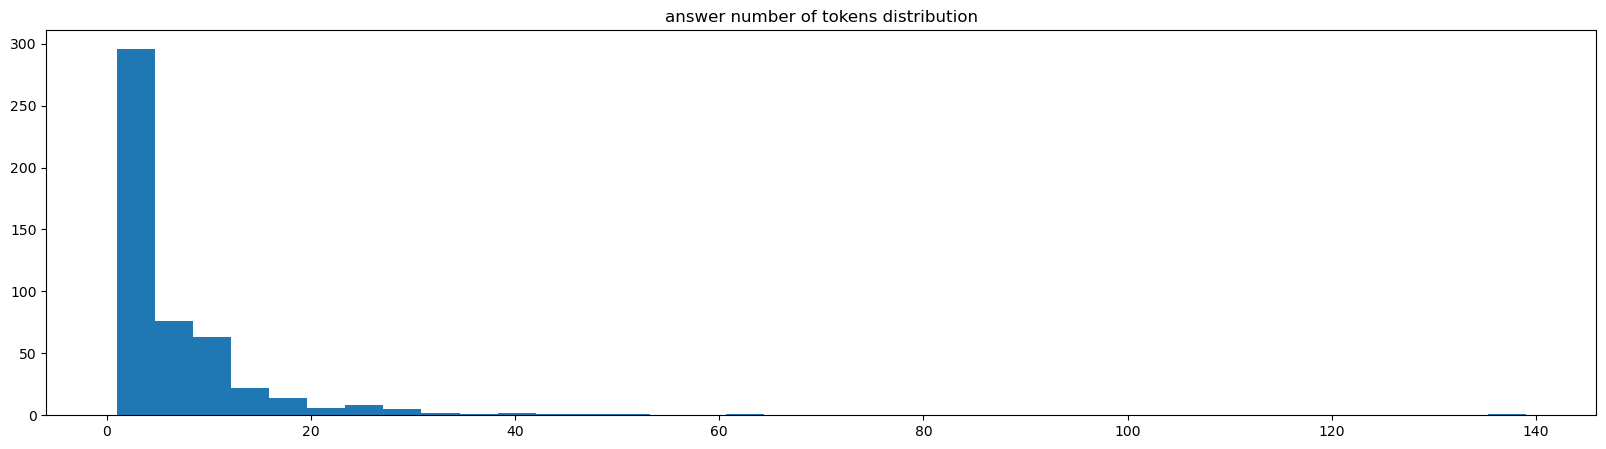

There is 371 unique answer.


In [6]:
polymath = load_data("PolyMath")
print_distributions(polymath, ['id', 'question', 'answer'])

### S1K 1.1

Filtered 37.7% of the dataset
Features: ['solution', 'question', 'cot_type', 'source_type', 'metadata', 'gemini_thinking_trajectory', 'gemini_attempt', 'deepseek_thinking_trajectory', 'deepseek_attempt', 'gemini_grade', 'gemini_grade_reason', 'deepseek_grade', 'deepseek_grade_reason']
Number of samples: 623
Sample: {
    "cot_type": "math",
    "deepseek_attempt": "Given a right triangle \\(ABC\\) with a right angle at \\(C\\), hypotenuse \\(AB\\) of length 60, and medians through \\(A\\) and \\(B\\) lying along the lines \\(y = x + 3\\) and \\(y = 2x + 4\\) respectively, we need to find the area of triangle \\(ABC\\).\n\n1. **Coordinates and Midpoints**:\n   - The median through \\(A\\) (on \\(y = x + 3\\)) implies \\(A\\) and the midpoint of \\(BC\\) lie on this line.\n   - The median through \\(B\\) (on \\(y = 2x + 4\\)) implies \\(B\\) and the midpoint of \\(AC\\) lie on this line.\n   - The centroid \\(G\\) of the triangle is the intersection of these medians, found to be \\((-1, 

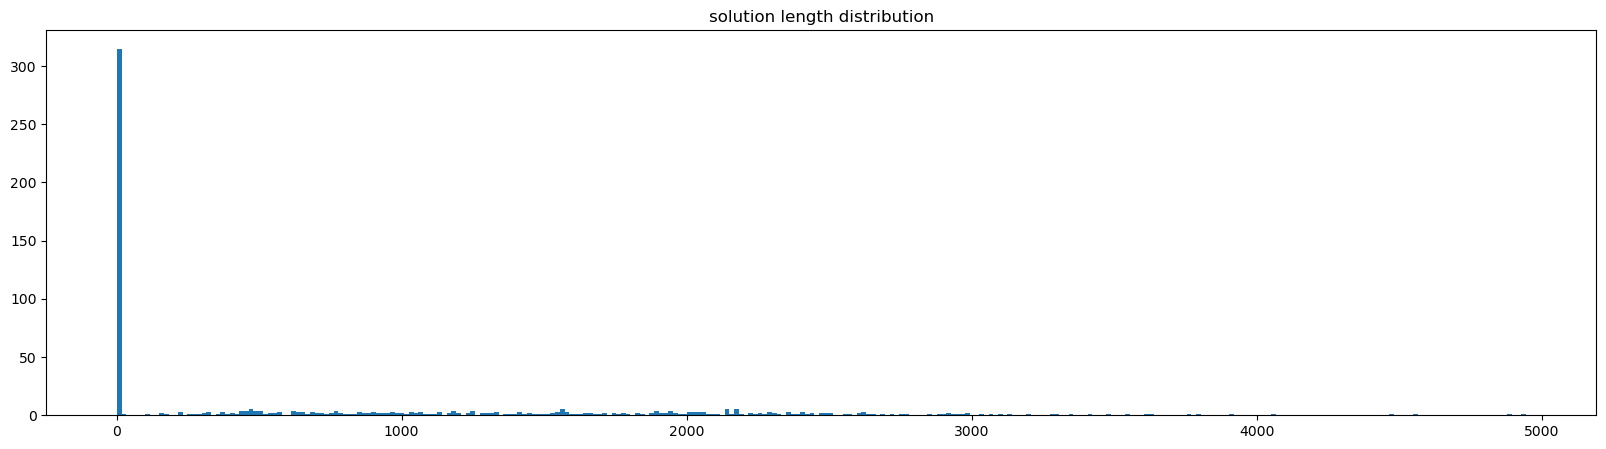

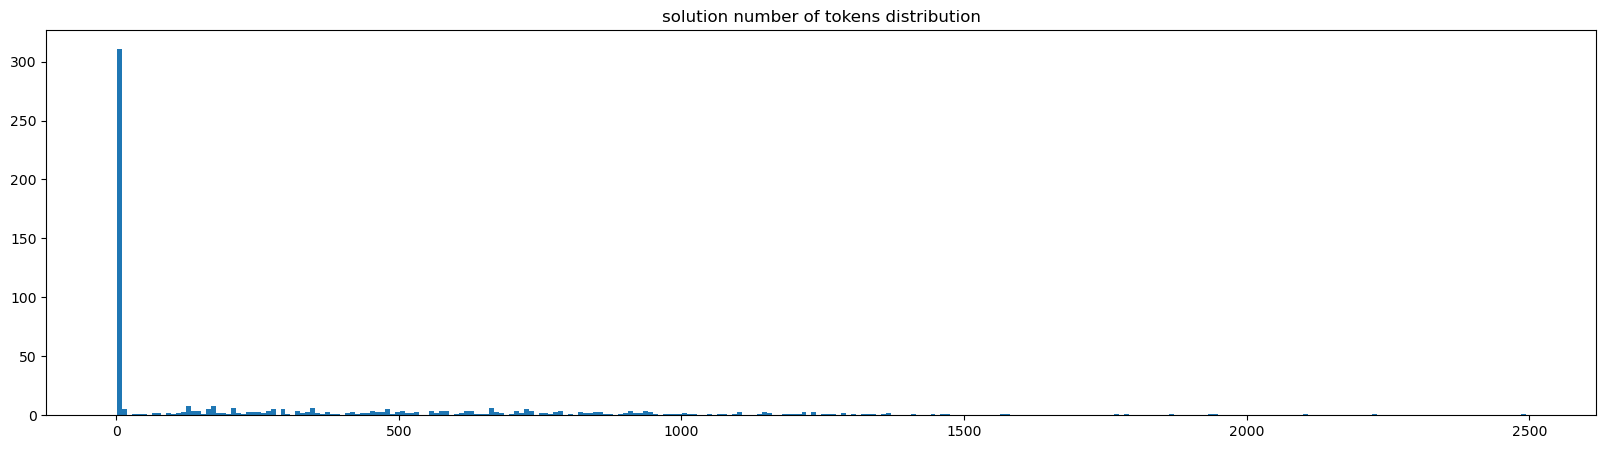

There is 542 unique solution.


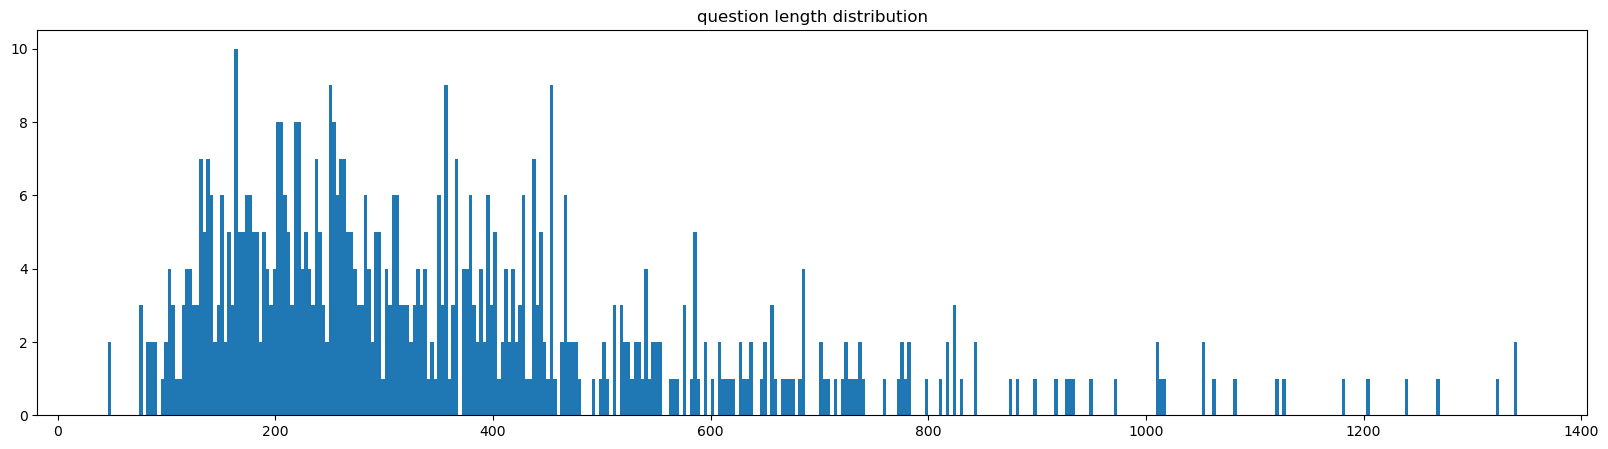

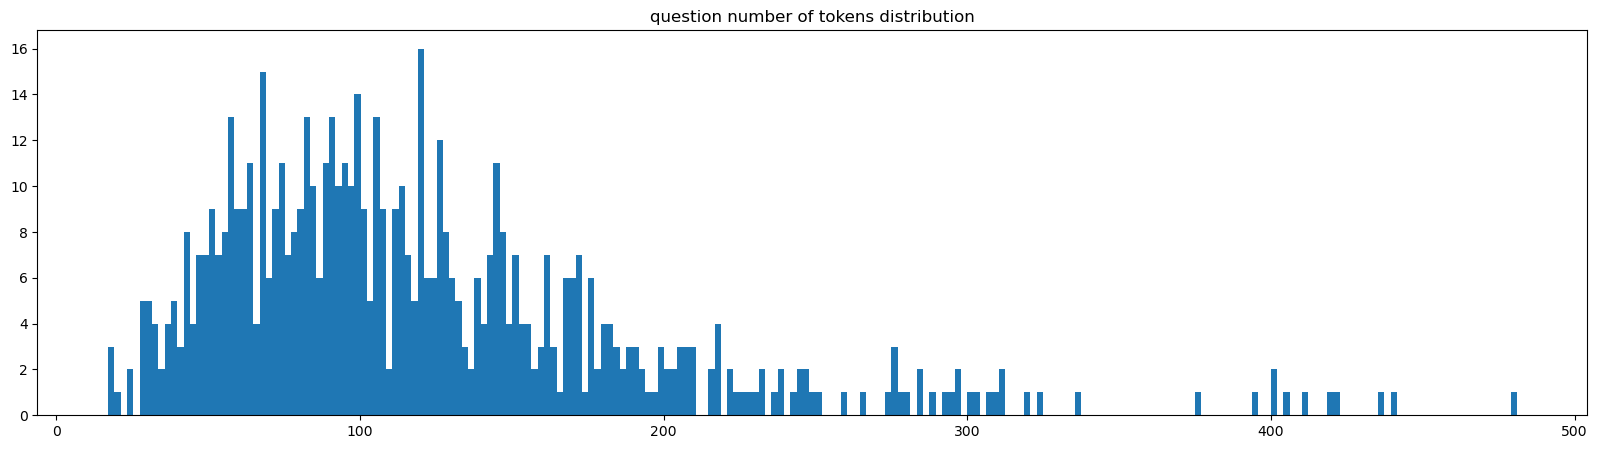

There is 623 unique question.


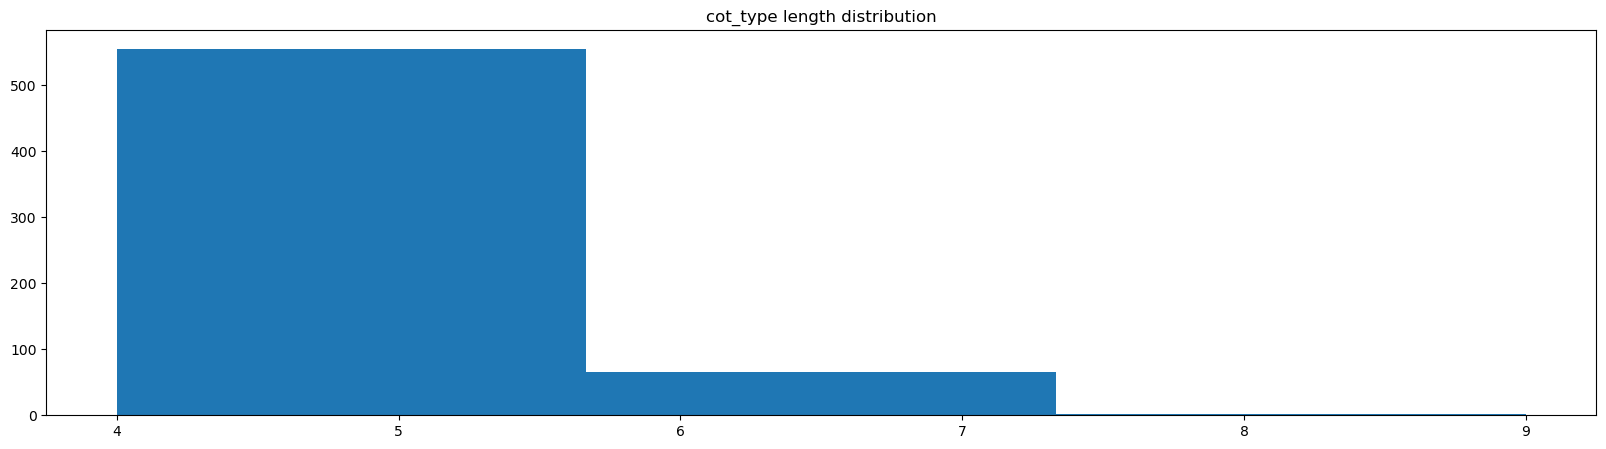

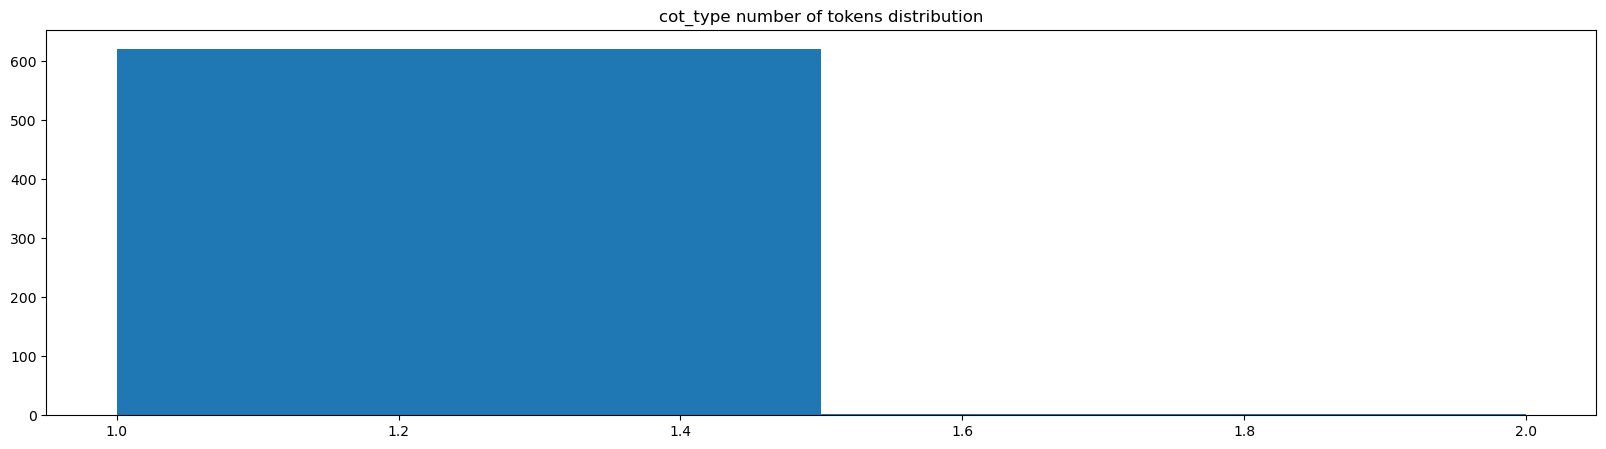

There is 3 unique cot_type.


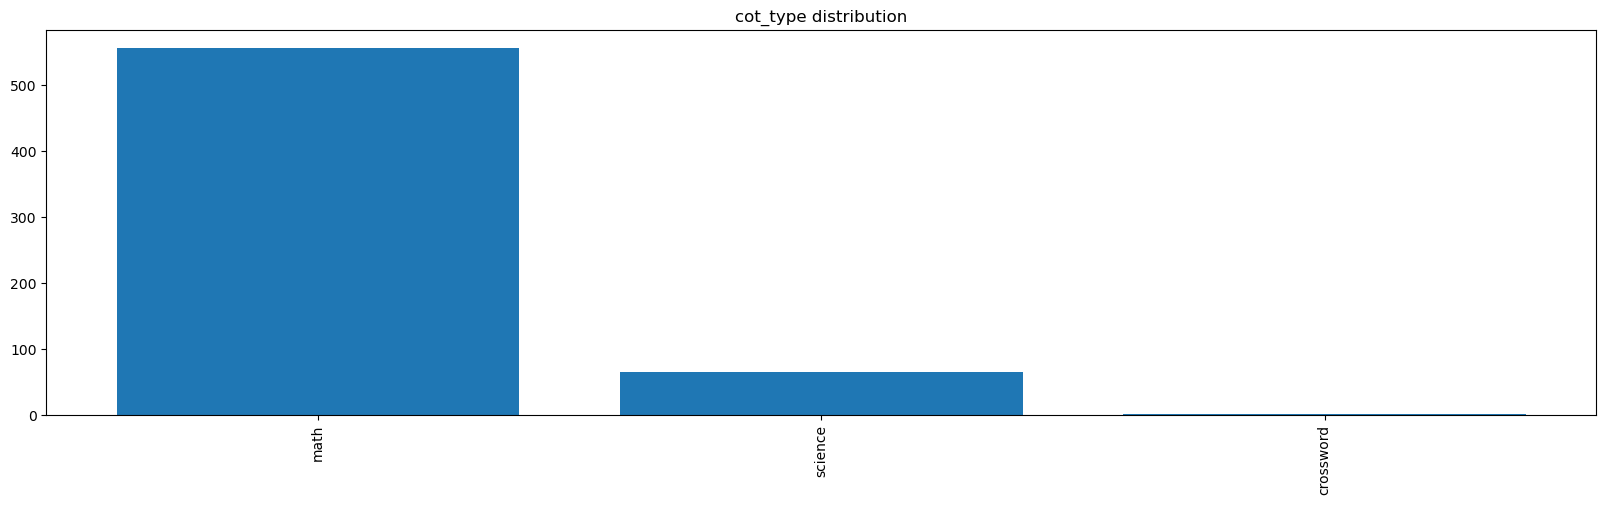

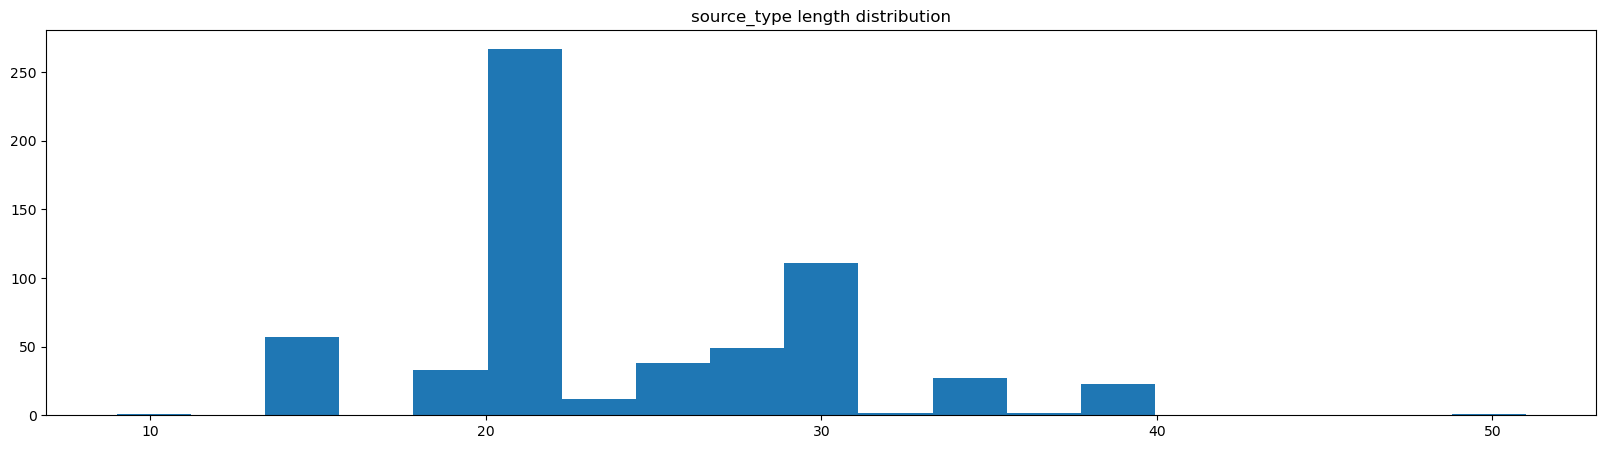

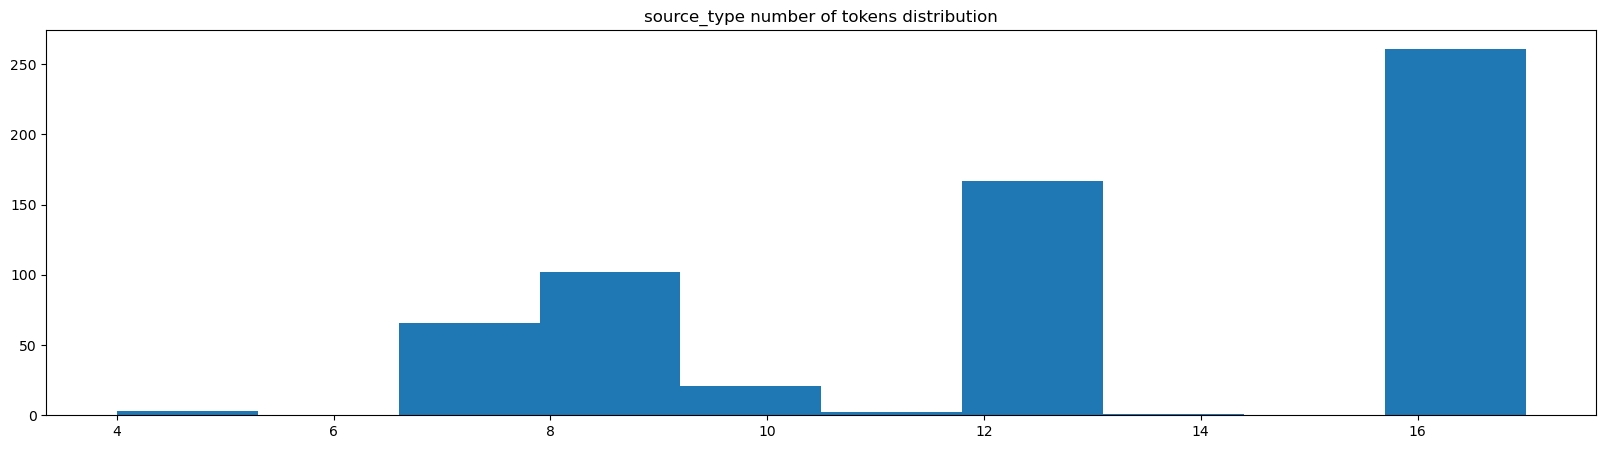

There is 31 unique source_type.


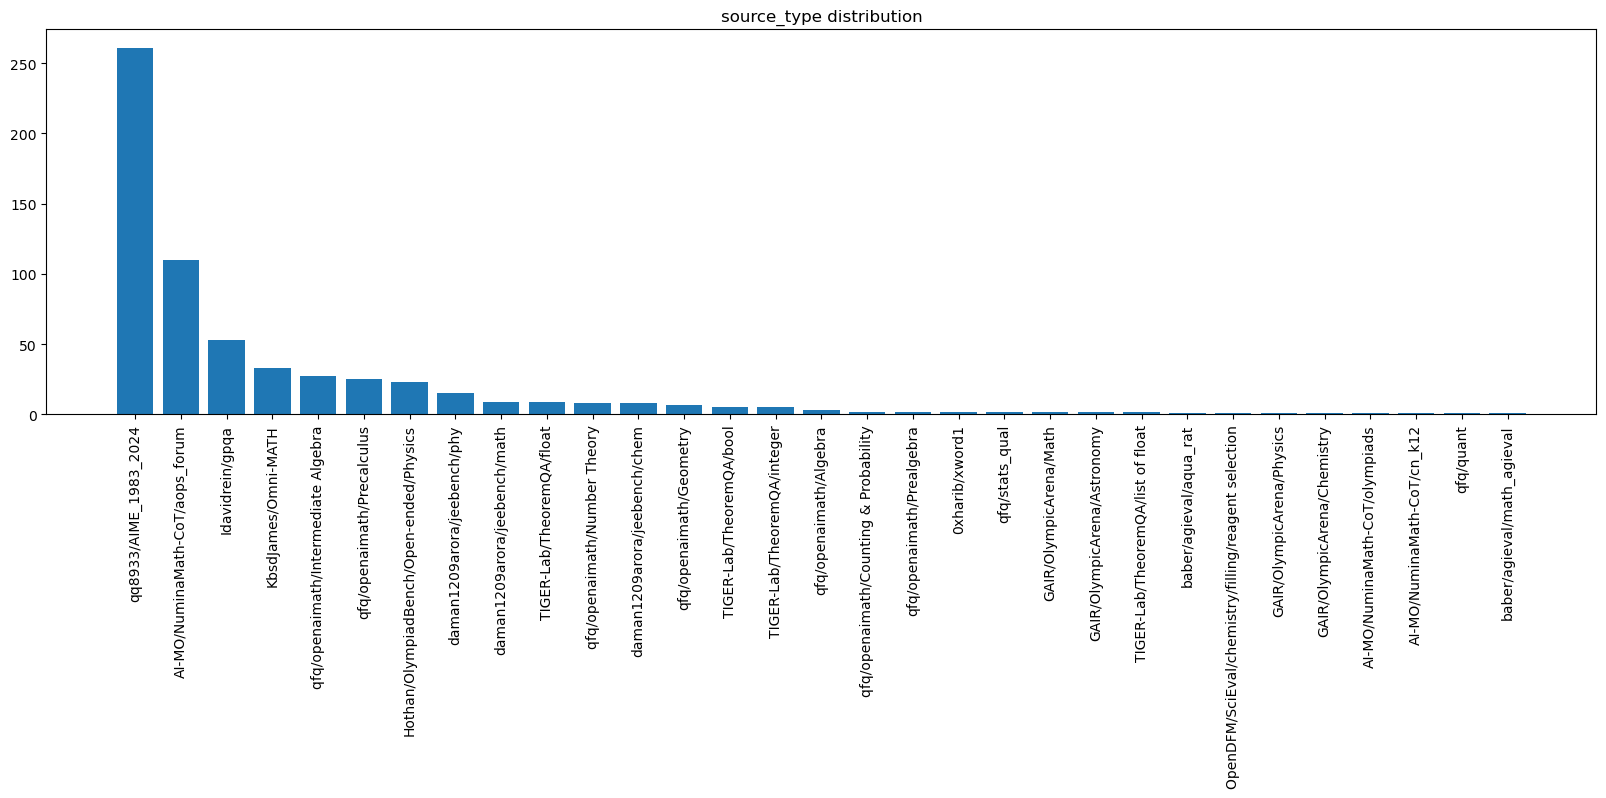

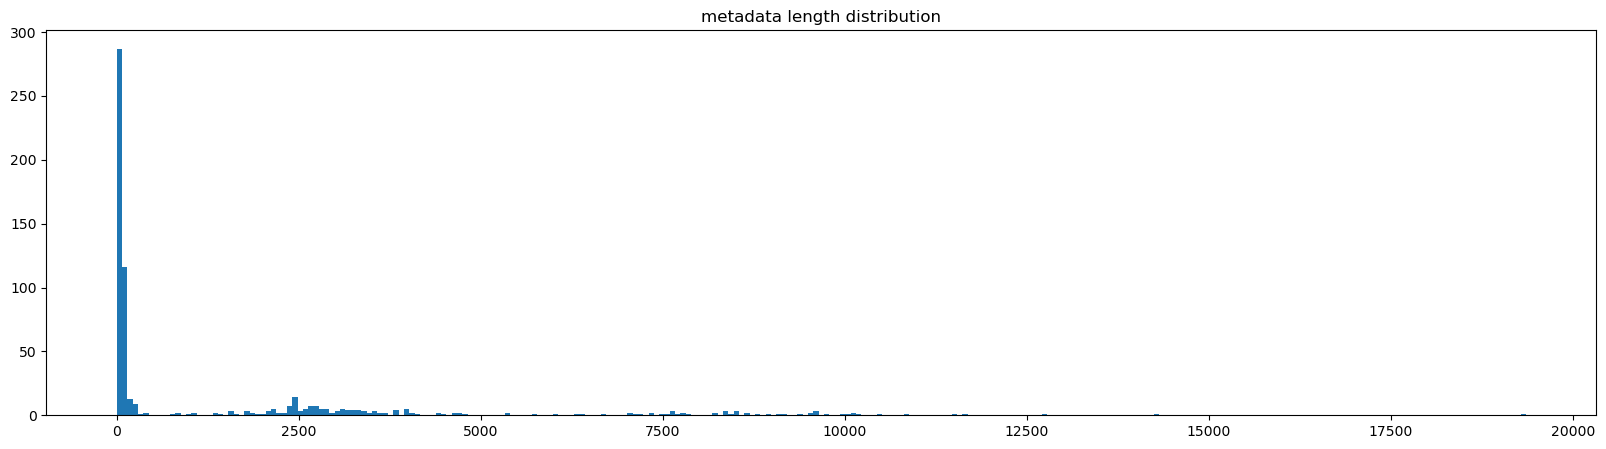

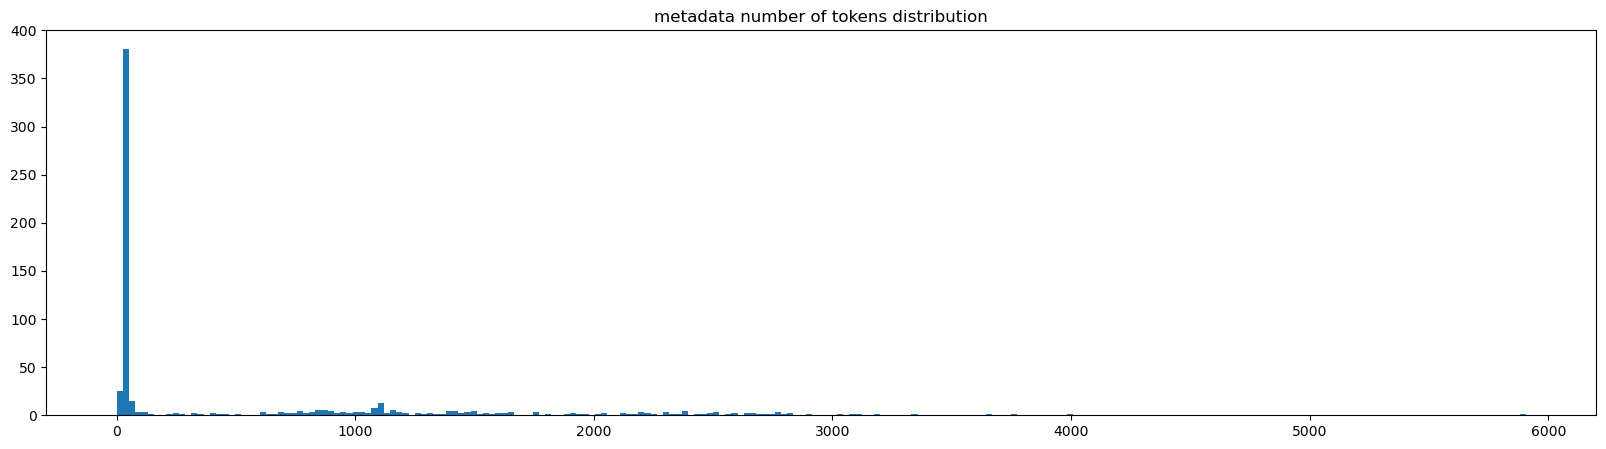

There is 605 unique metadata.


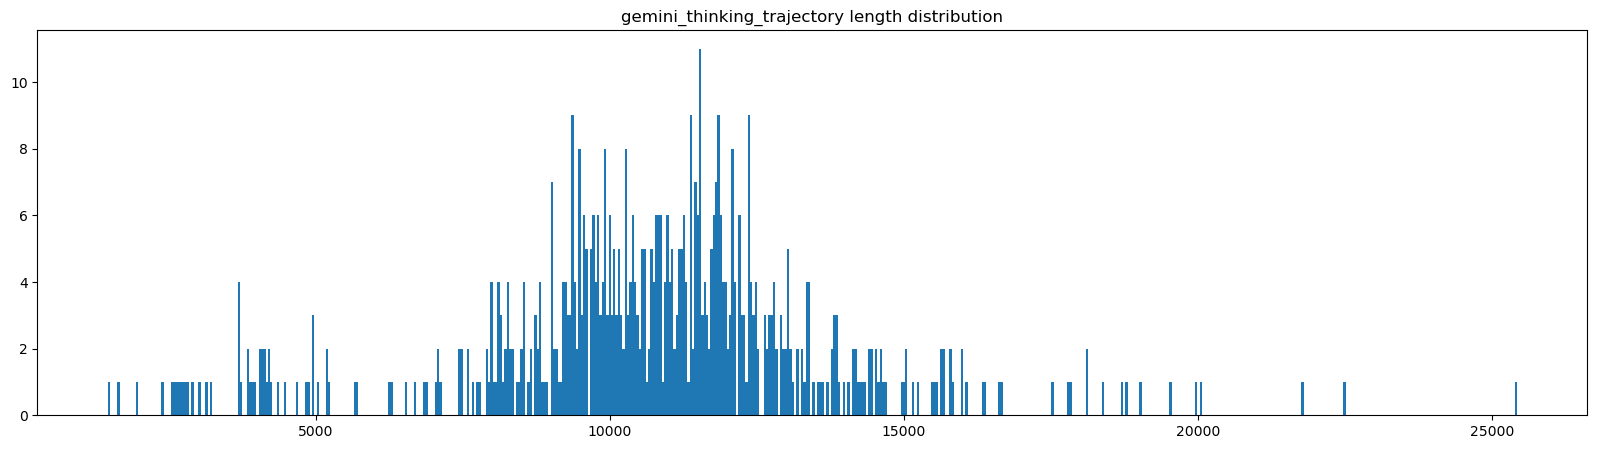

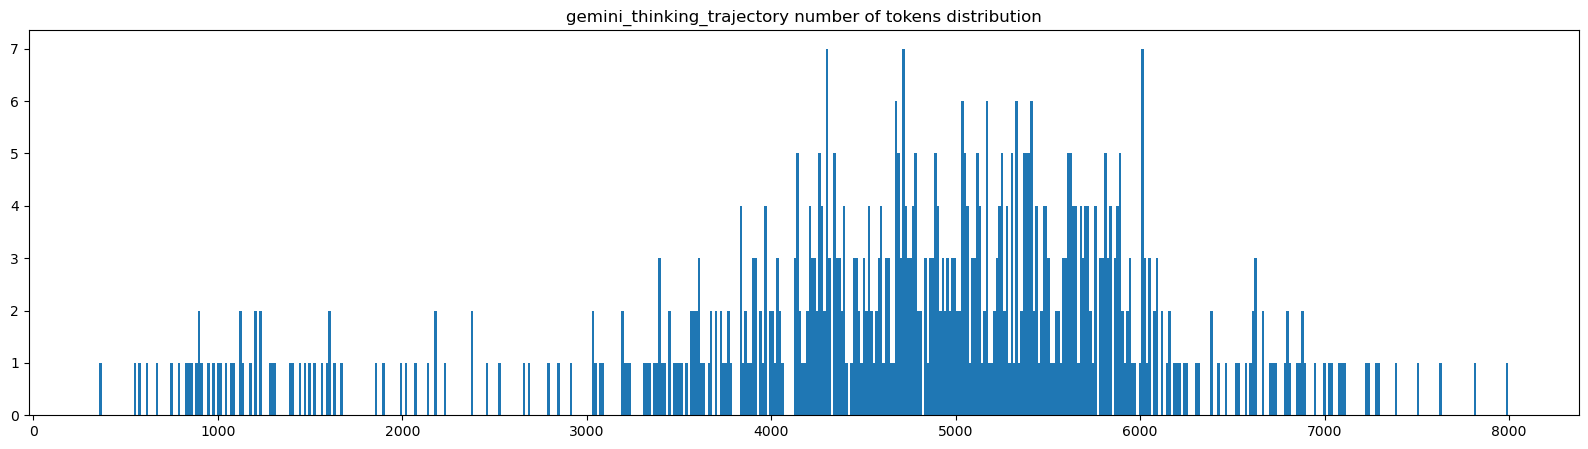

There is 623 unique gemini_thinking_trajectory.


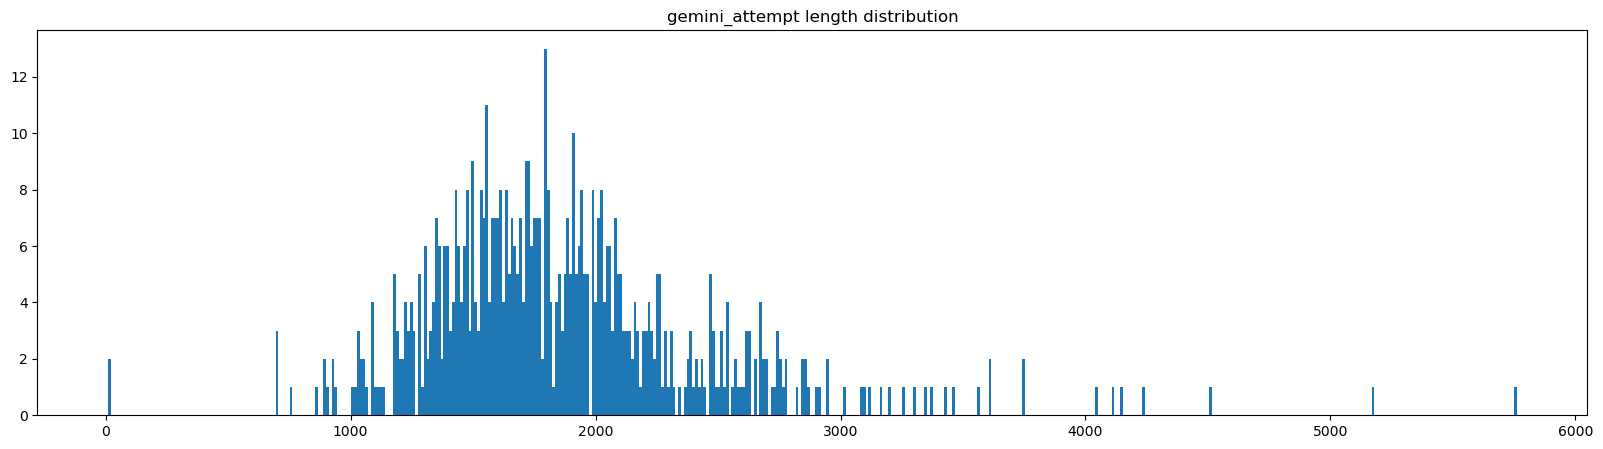

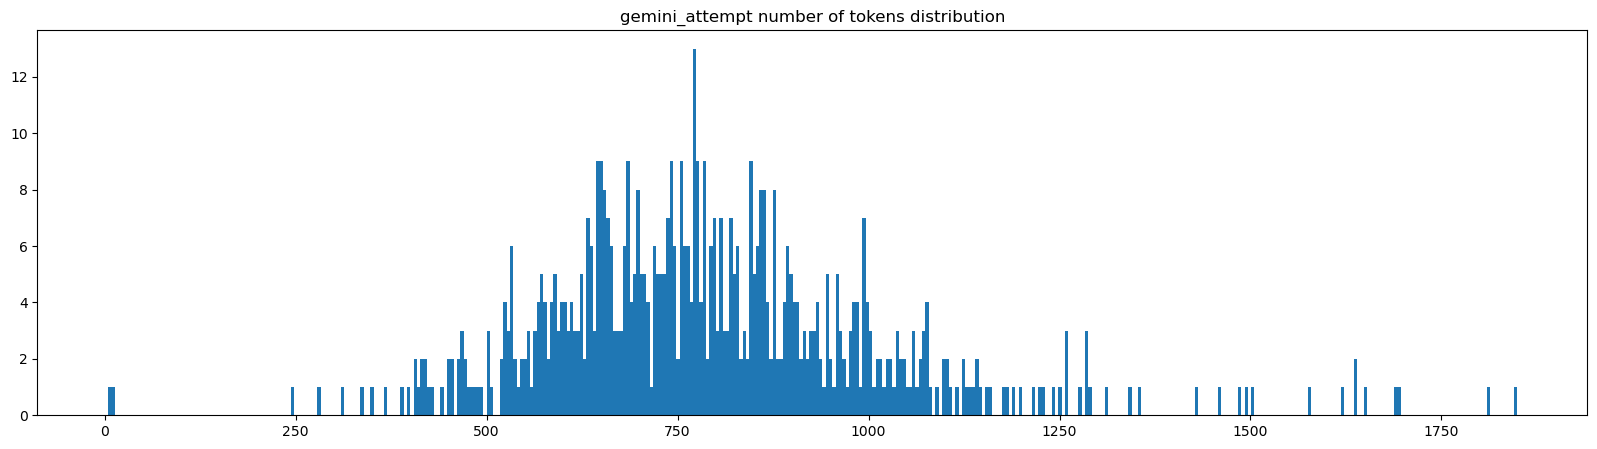

There is 623 unique gemini_attempt.


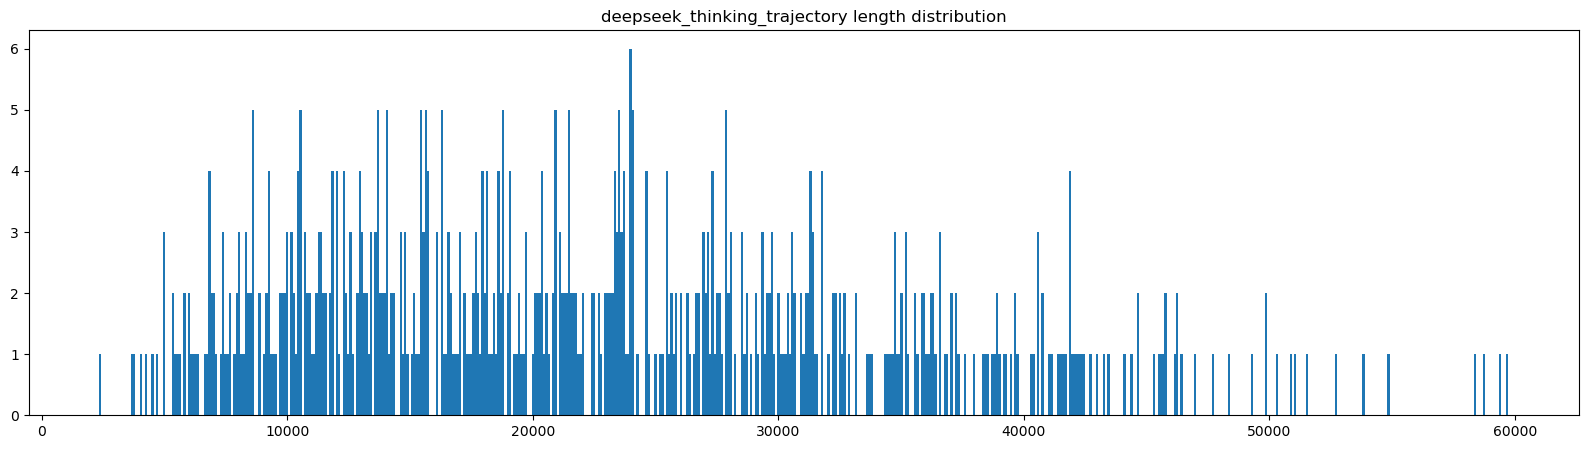

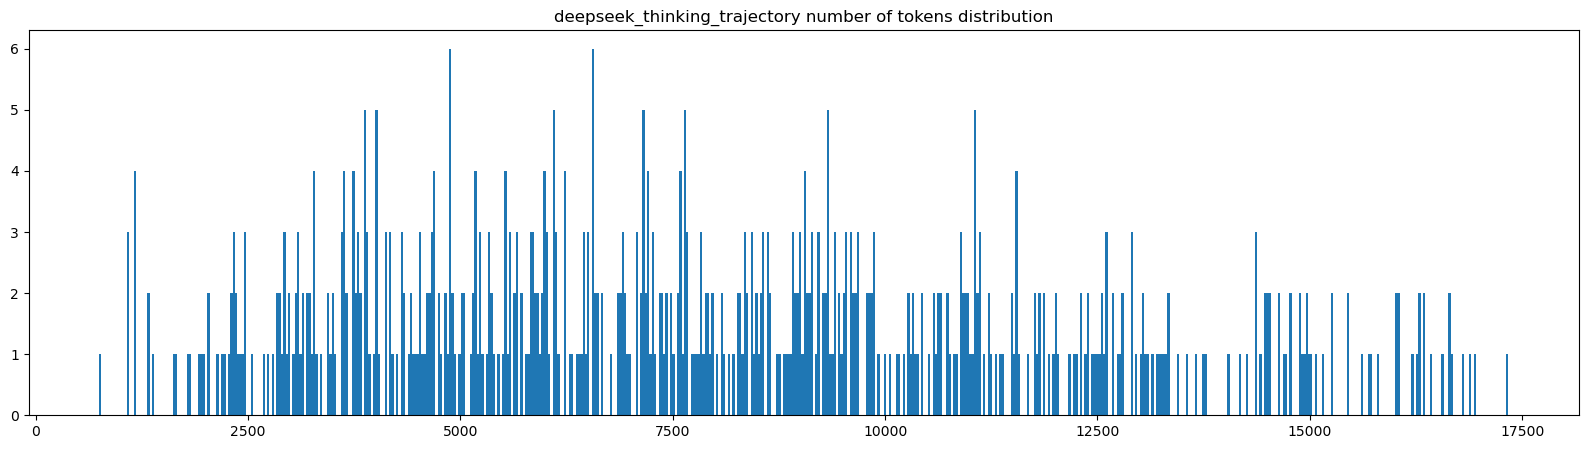

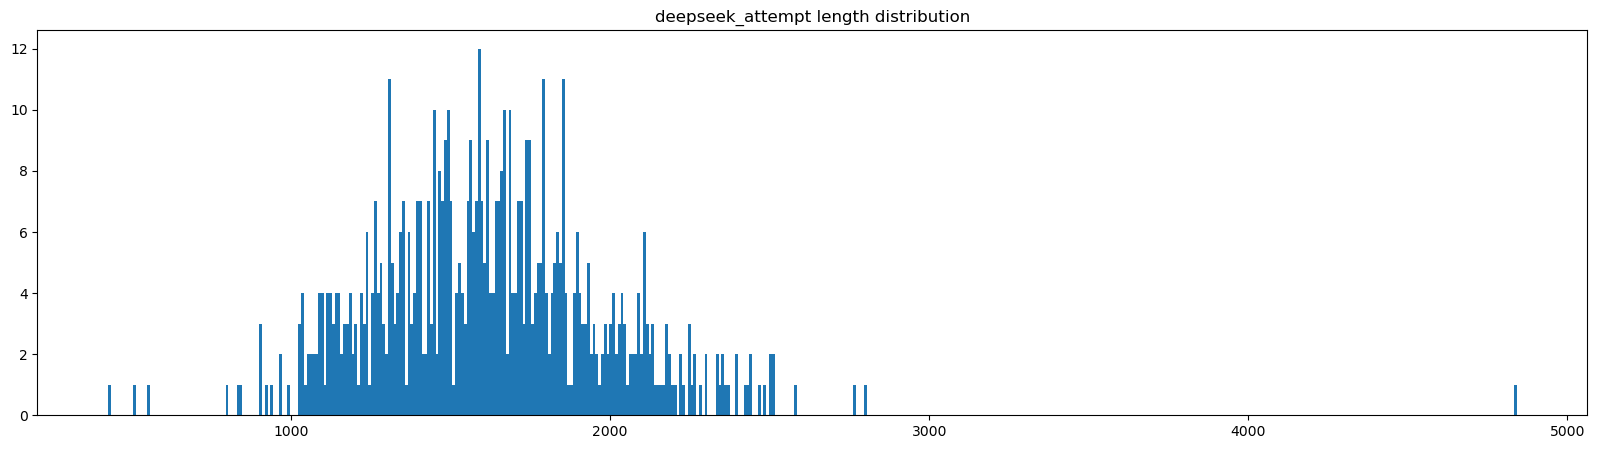

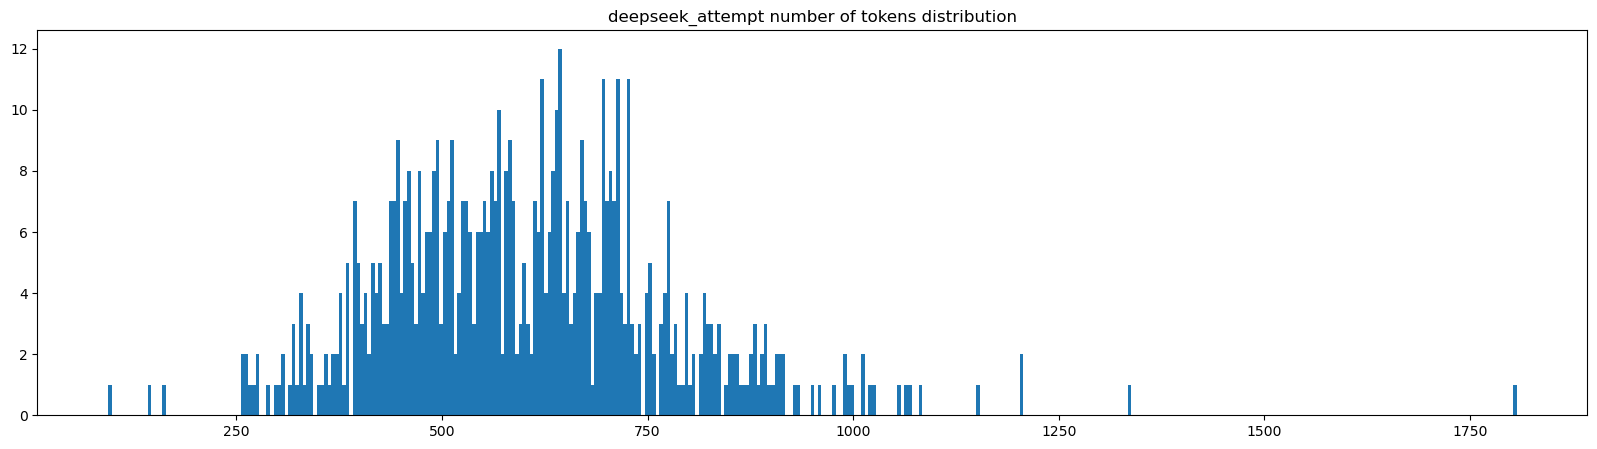

There is 623 unique deepseek_attempt.


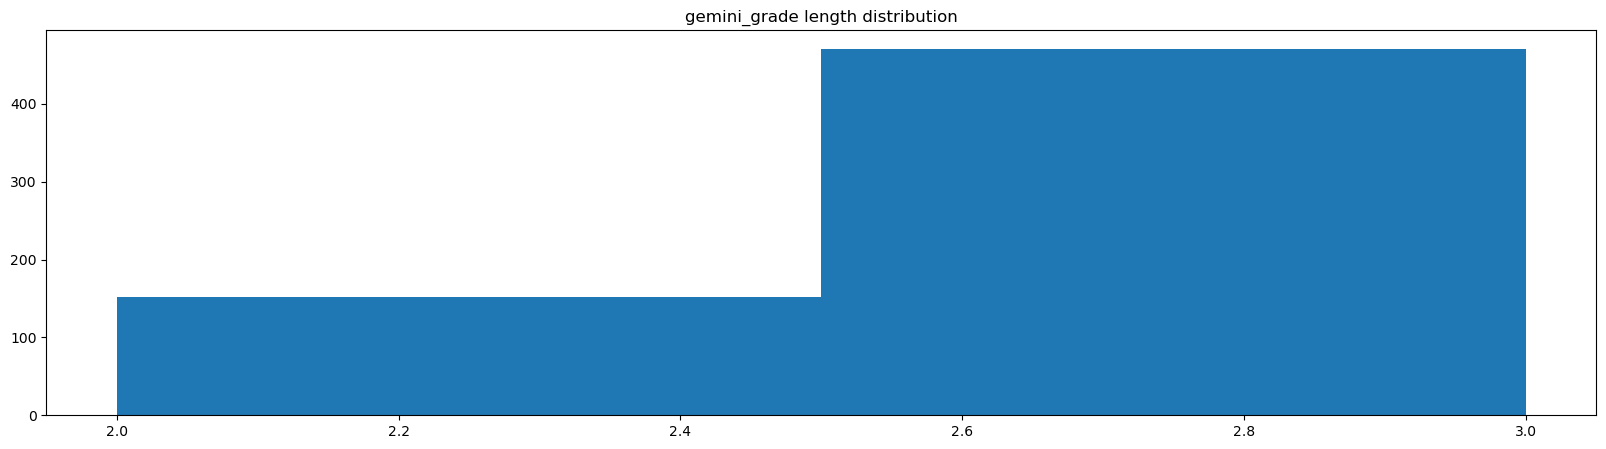

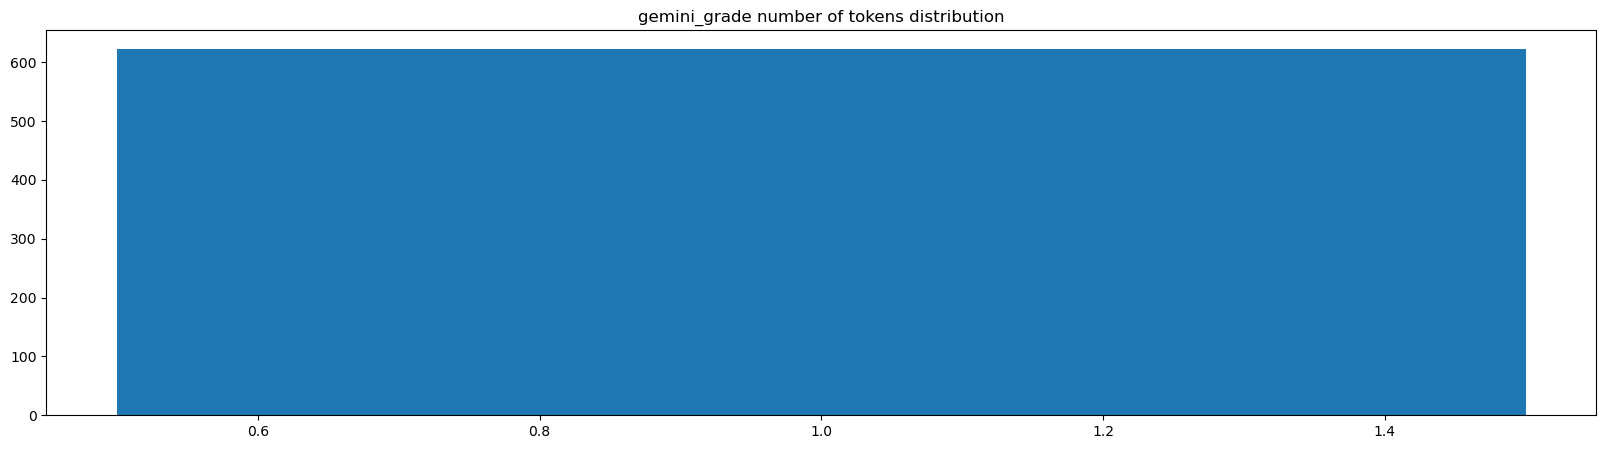

There is 2 unique gemini_grade.


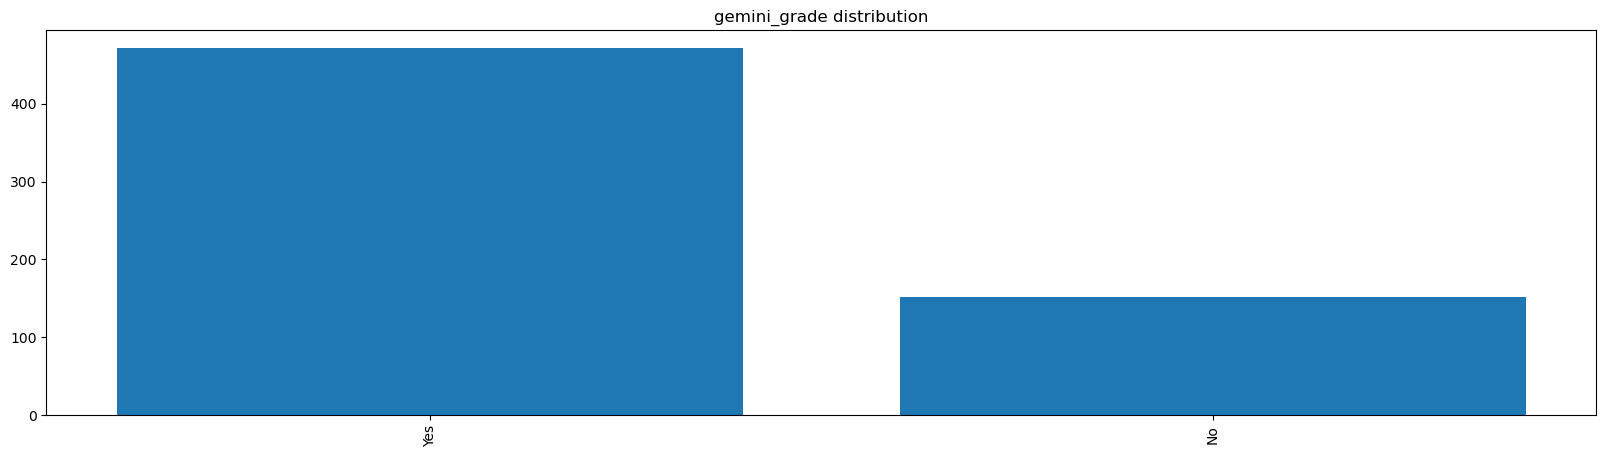

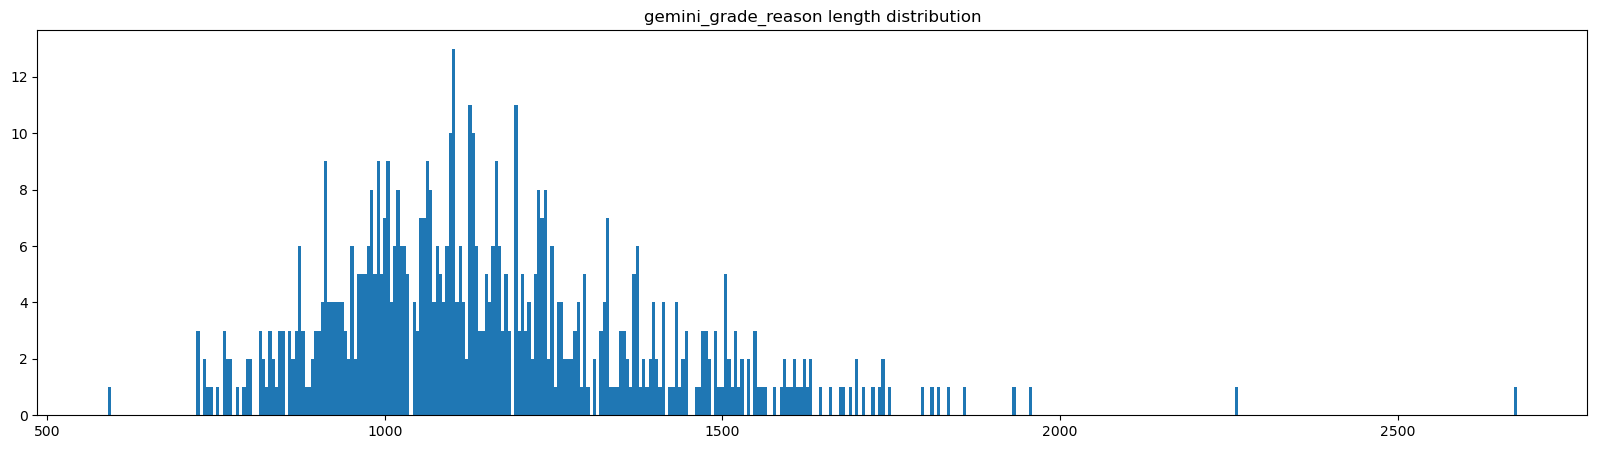

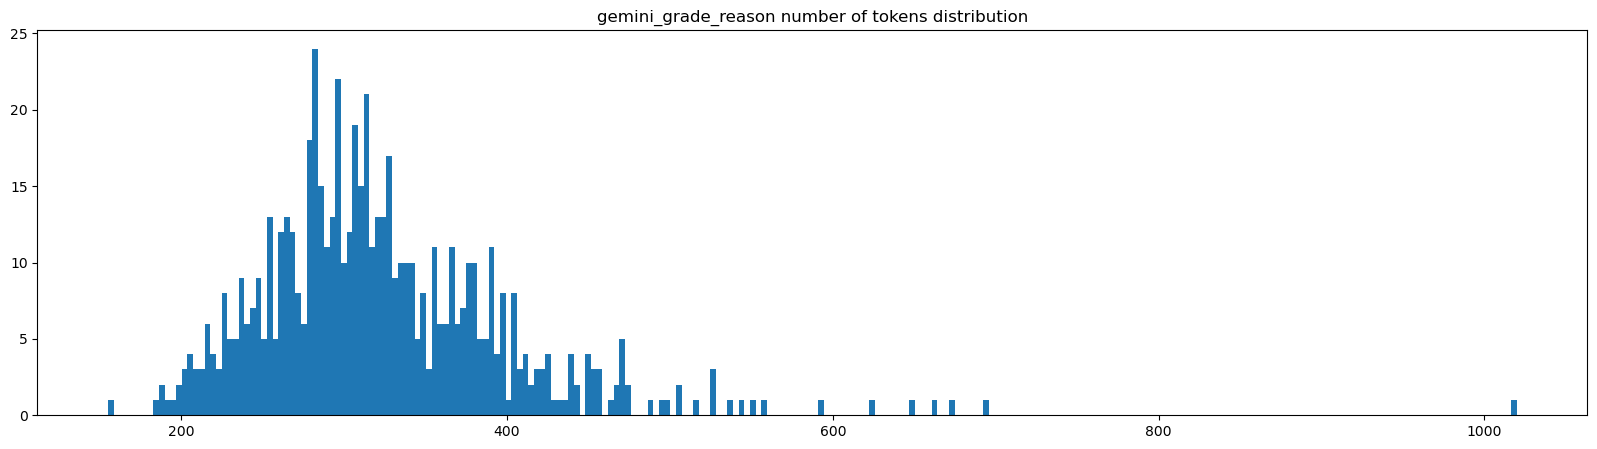

There is 623 unique gemini_grade_reason.


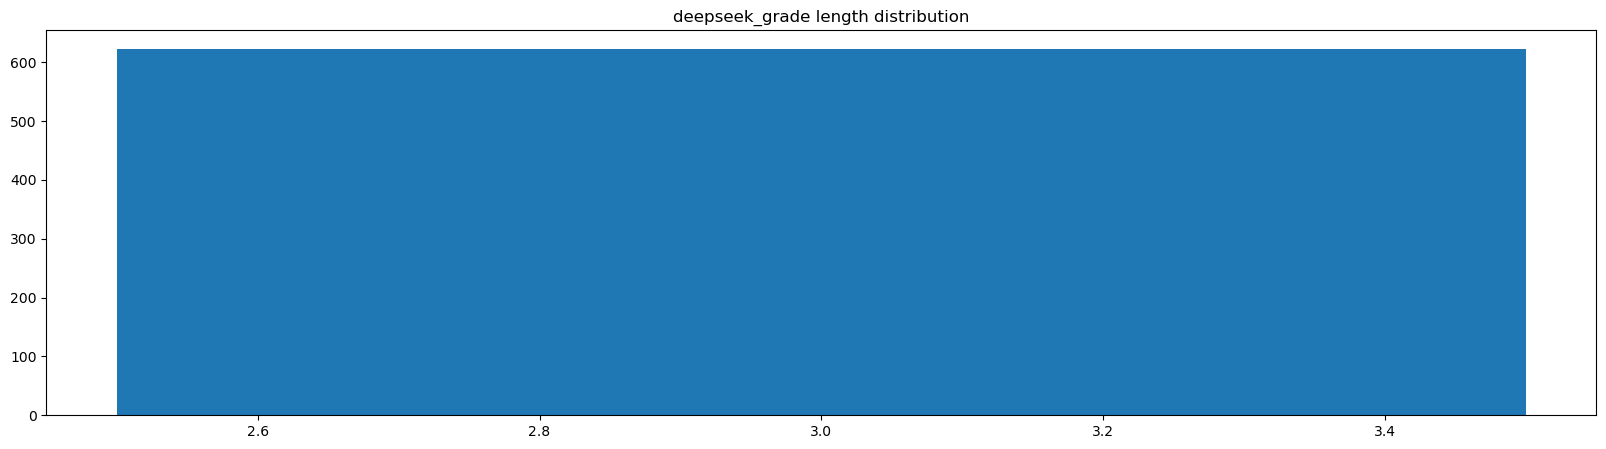

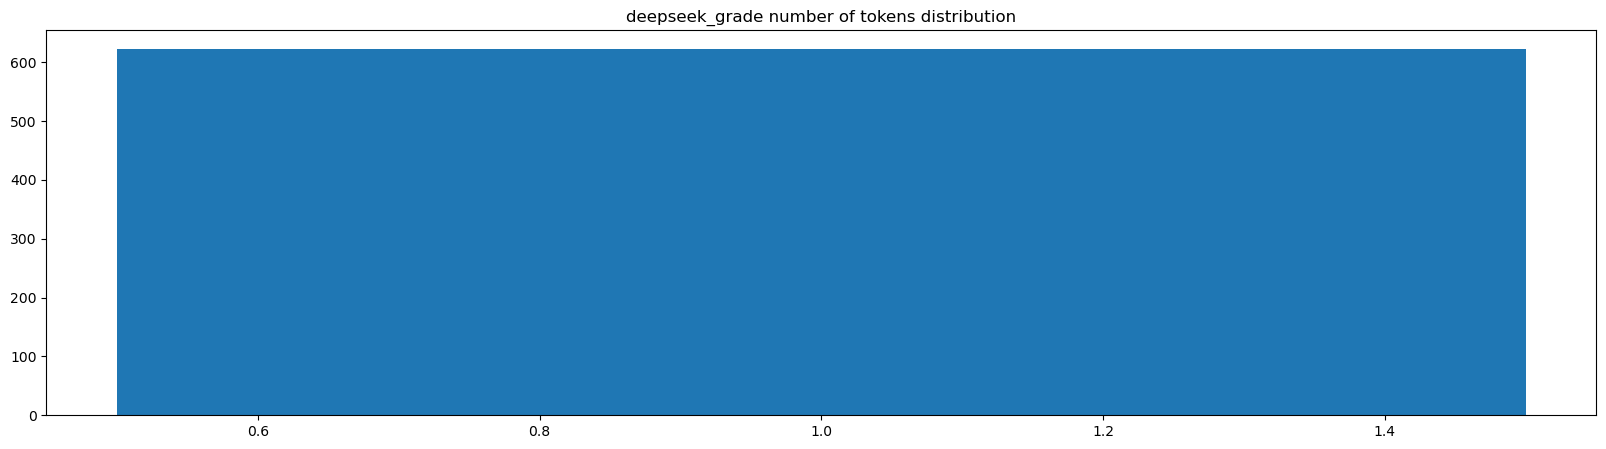

There is 1 unique deepseek_grade.


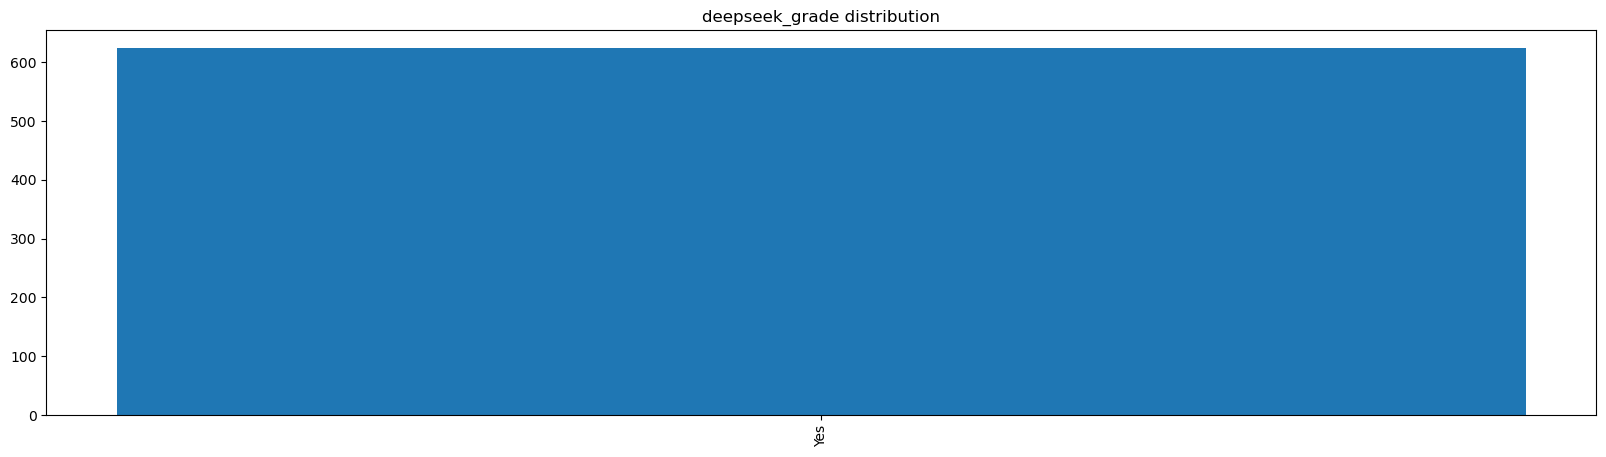

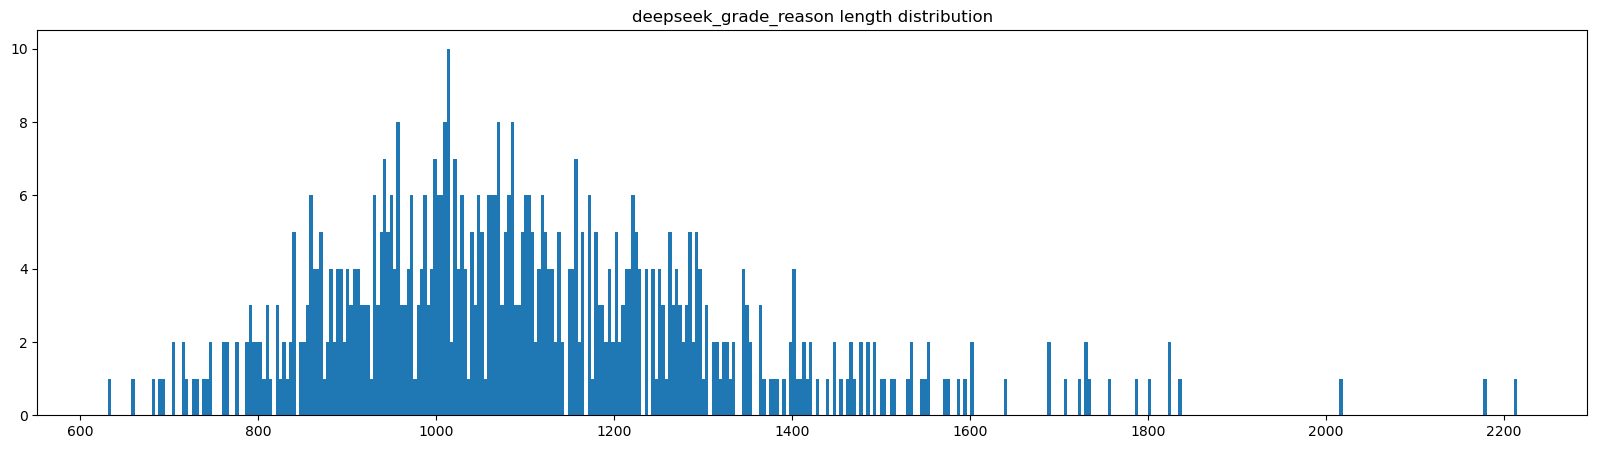

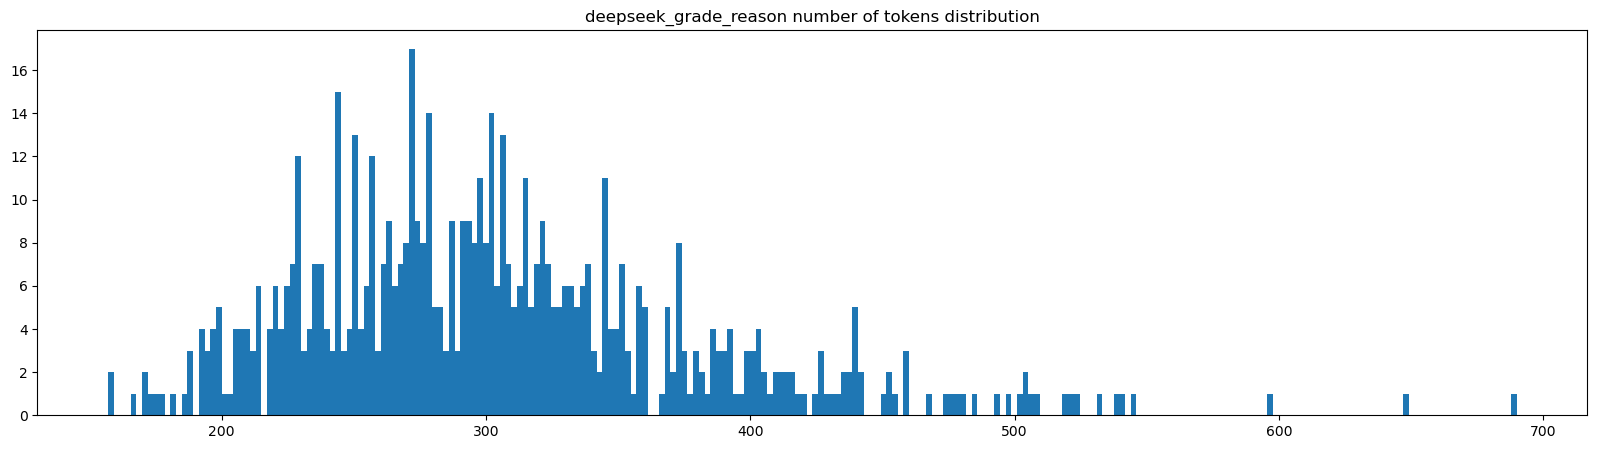

There is 623 unique deepseek_grade_reason.


In [34]:
s1k_1_1 = load_data("s1K-1.1")
s1k_1_1 = filter_s1k_1_1(s1k_1_1)
print_distributions(s1k_1_1, ['solution', 'question', 'cot_type', 'source_type', 'metadata', 'gemini_thinking_trajectory', 'gemini_attempt', 'deepseek_thinking_trajectory', 'deepseek_attempt', 'gemini_grade', 'gemini_grade_reason', 'deepseek_grade', 'deepseek_grade_reason'])

### SwallowMath

Generating train split: 1406346 examples [00:04, 314224.86 examples/s]


Features: ['text']
Number of samples: 10000
Sample: {
    "text": "## Calculating True Proportion\n\nThe true proportion can be estimated using the sample proportion, which is calculated as p\u2032 = x / n, where x represents the number of successes and n represents the sample size.\n\n## Standard Deviation (Sigma)\n\nThe standard deviation, denoted by \u03c3, is calculated using the formula \u03c3 = \u221a[\u03a3(x-x\u0304)\u00b2/n], where x represents each value in the dataset, x\u0304 is the mean, and n is the total number of values.\n\n## Proportion vs. Percentage\n\nProportion refers to the relation or equality between two ratios or fractions, while percentage is a ratio or fraction with a denominator of 100. To convert a proportion to a percentage, multiply the proportion by 100.\n\n## Converting Proportion to Percentage\n\nThe formula to convert a proportion to a percentage is: (Parts / Whole) \u00d7 100 = Percent.\n\n## Single Population Proportion Formula\n\nThe formula for th

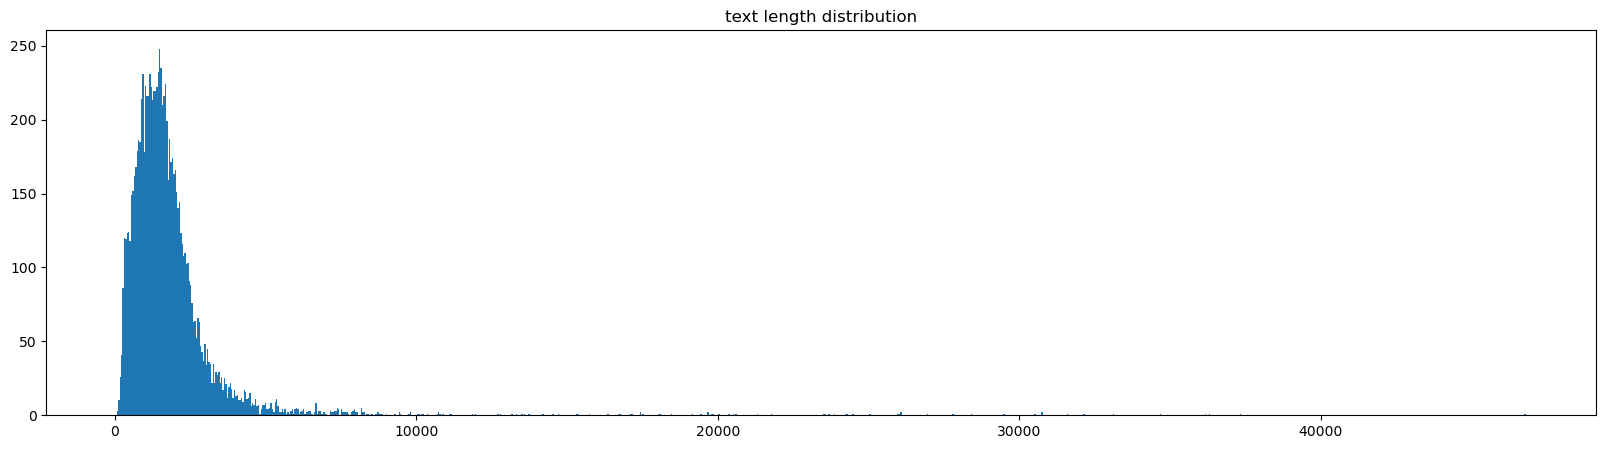

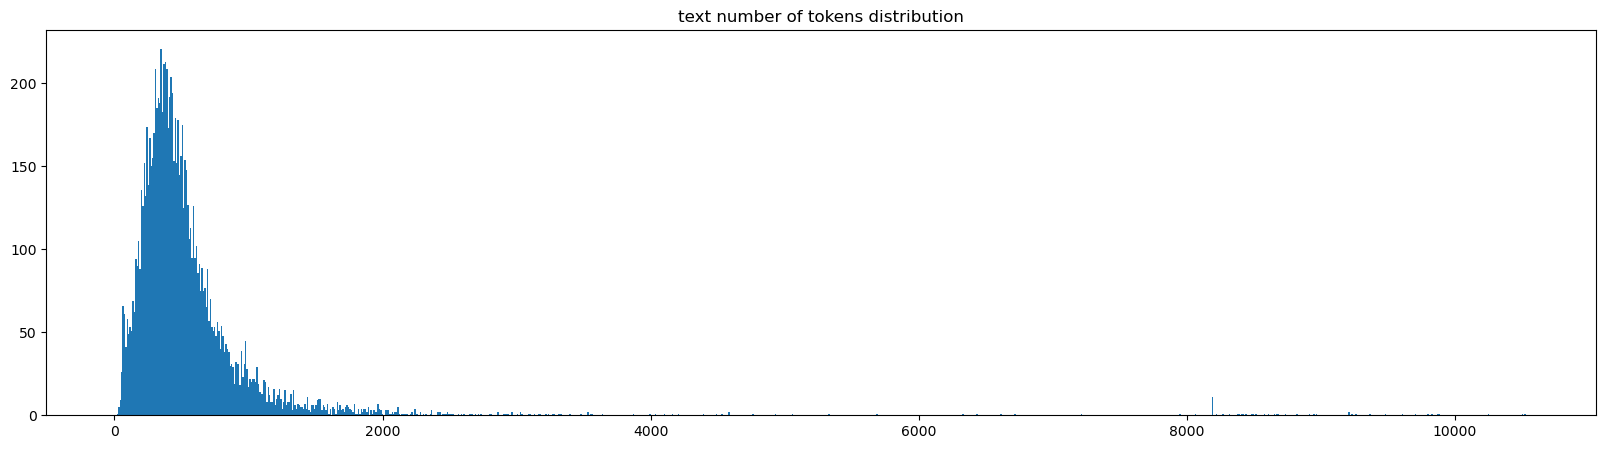

In [3]:
swallowmath = load_data("swallow-math").select(range(10000))
print_distributions(swallowmath, ['text'])

## Fusion datasets

### CoT

Processing dataset: am-deepseek-distill
Features: ['question', 'answer', 'question_source', 'answer_source', 'category', 'ground_truth', 'test_case', 'instruction_constrain', 'pass_rate_r1', 'pass_rate_7b', 'pass_rate_1.5b', 'verify_score', 'ppl', 'model_name']
Number of samples: 8211
Sample: {
    "answer": "<think>Okay, so the problem here is about figuring out how many flowers the orphanage received. The guy bought roses, lilies, sunflowers, and daisies. Each type of flower he bought 40 pieces. The question is asking for the total number of flowers. Hmm, that seems straightforward, but let me break it down step by step to make sure I don't make a mistake.\n\nFirst, let's list out the different types of flowers he bought. There are four kinds: roses, lilies, sunflowers, and daisies. Each of these he purchased 40 pieces of. So, roses \u2013 40, lilies \u2013 40, sunflowers \u2013 40, and daisies \u2013 40. That's four different flowers, each with 40 pieces.\n\nNow, to find the total n

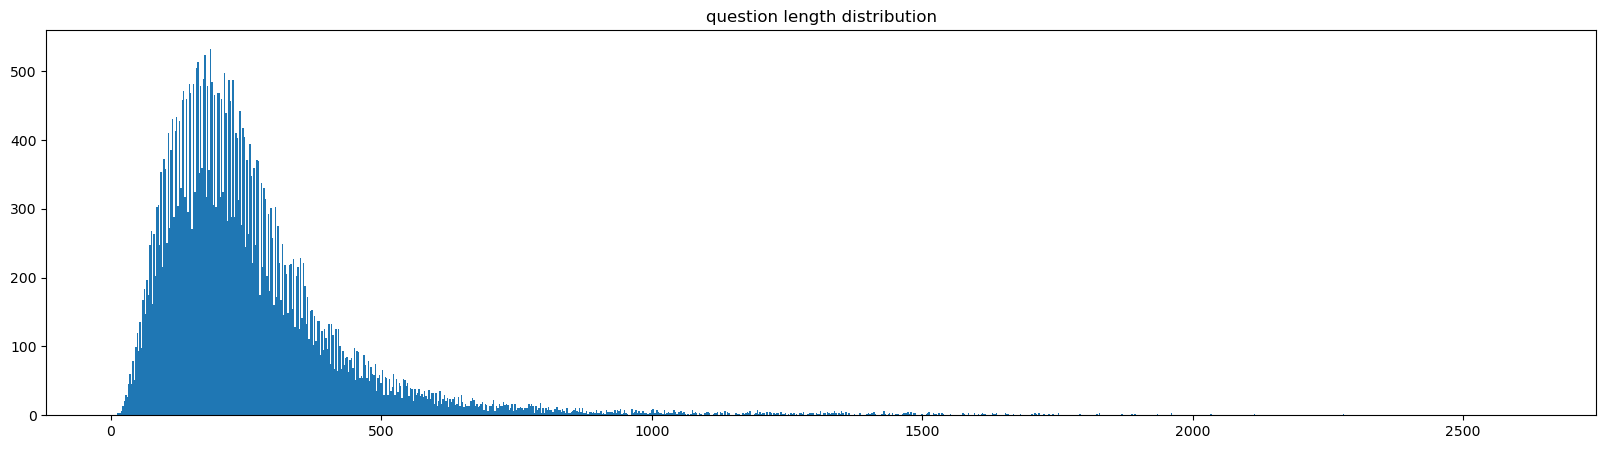

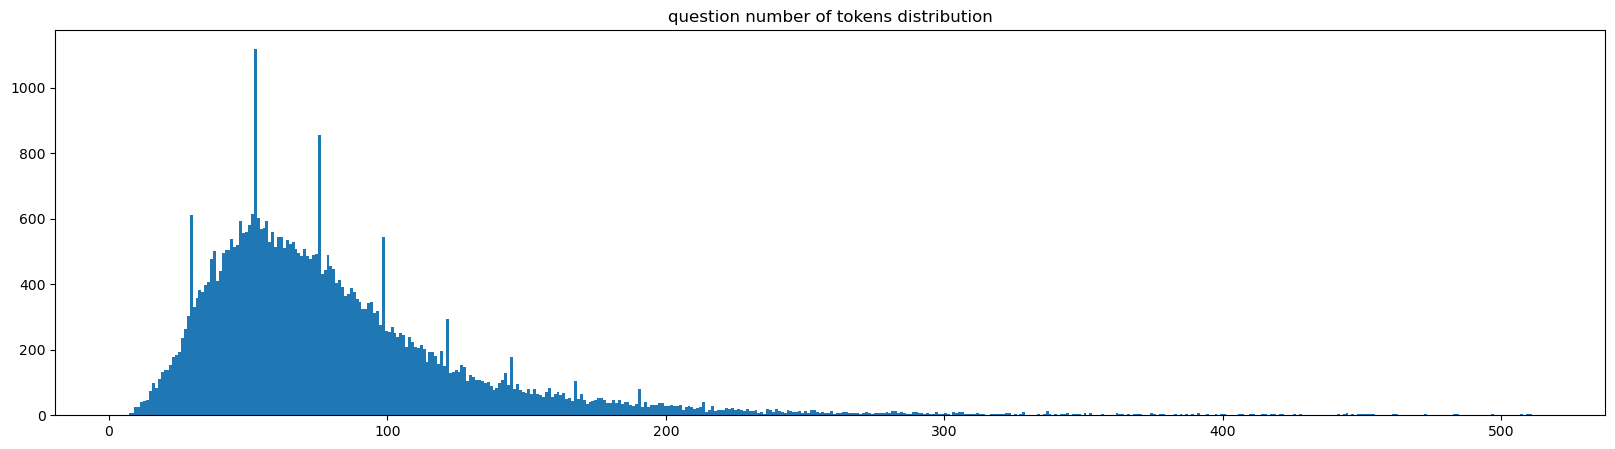

Number of 'None' answer: 9473


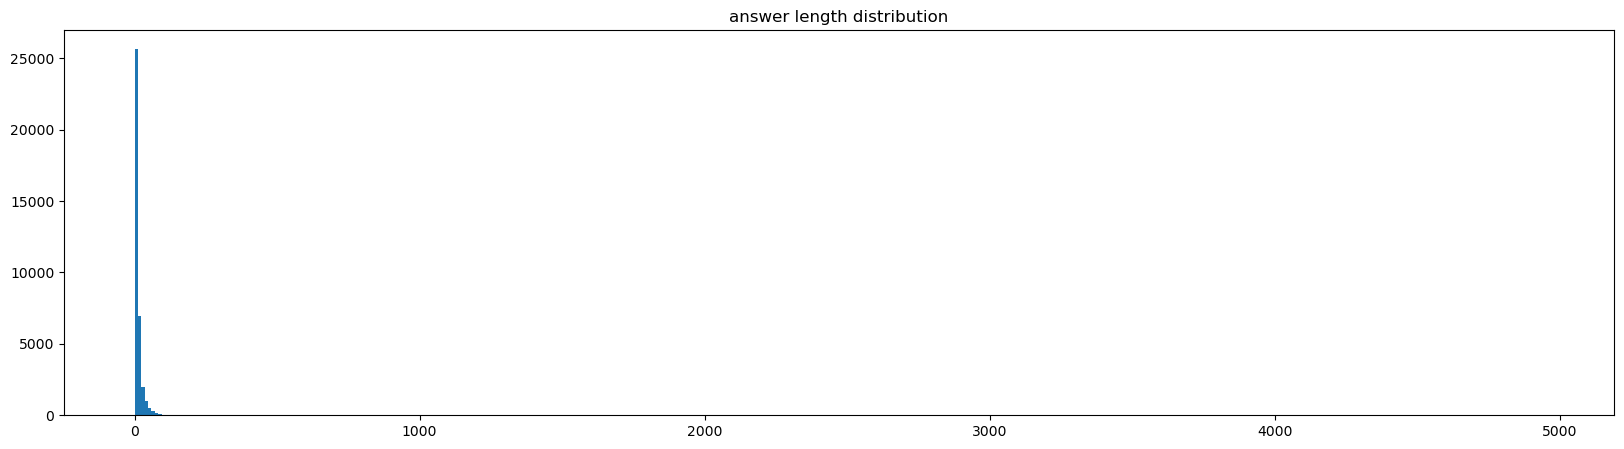

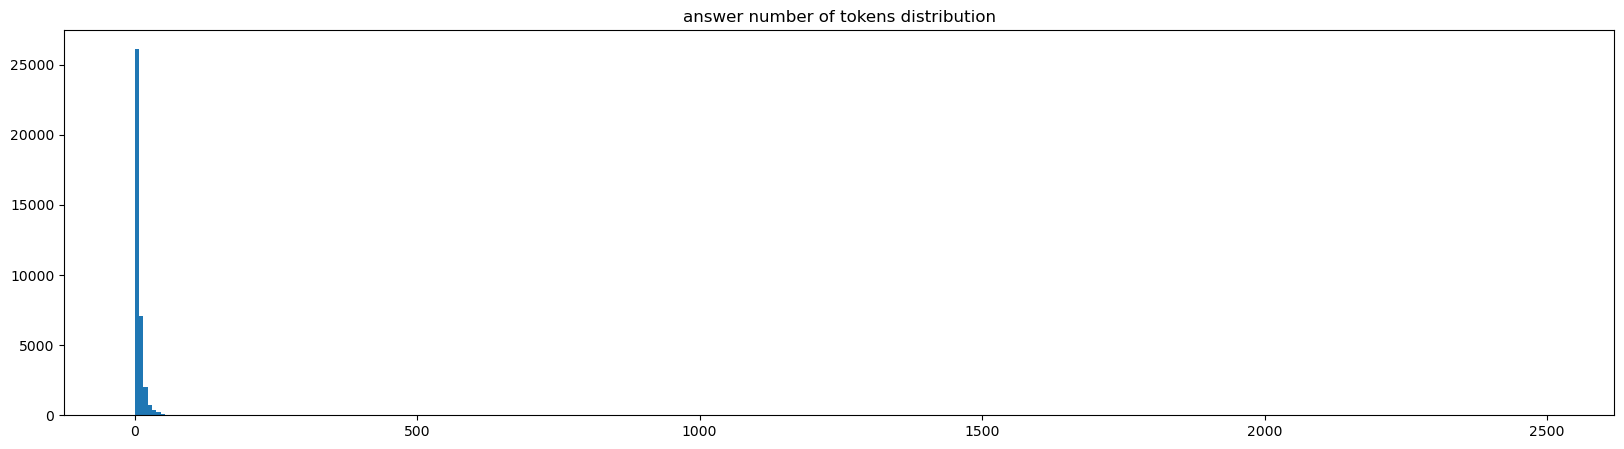

There is 15801 unique answer.
Number of 'None' solution: 8821


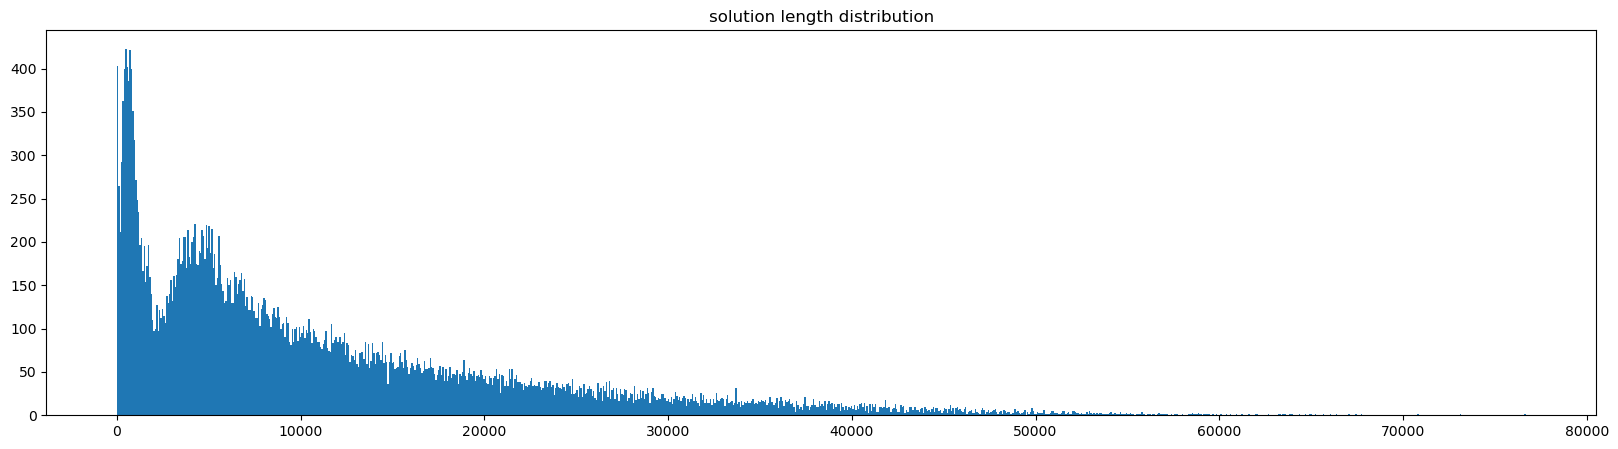

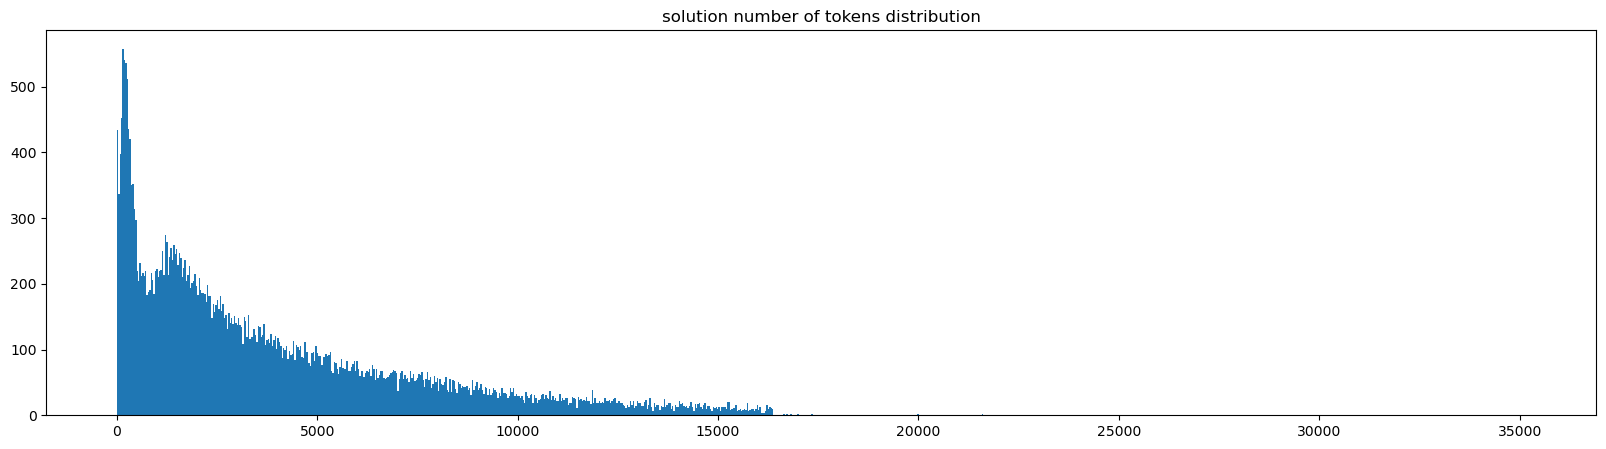

Number of 'None' source: 7967


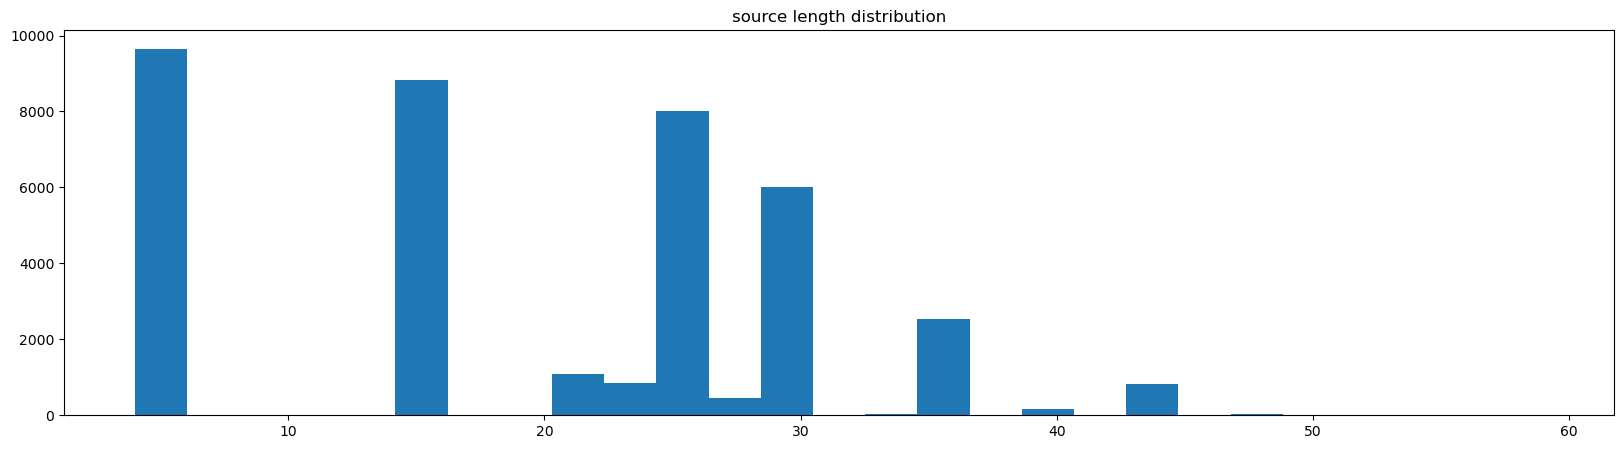

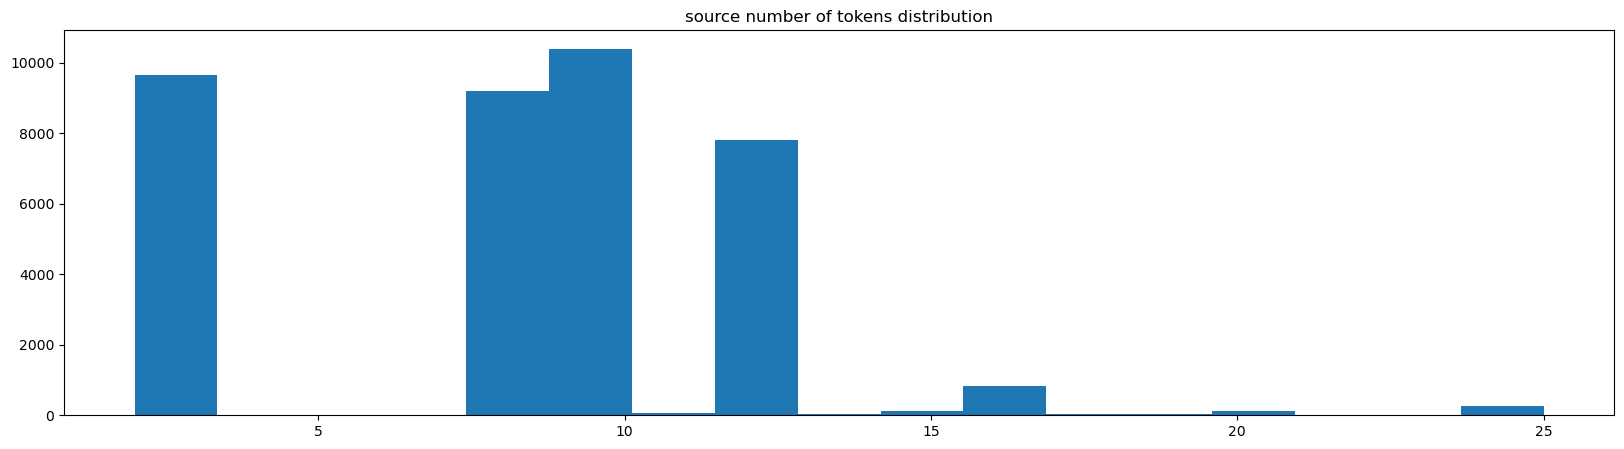

There is 58 unique source.


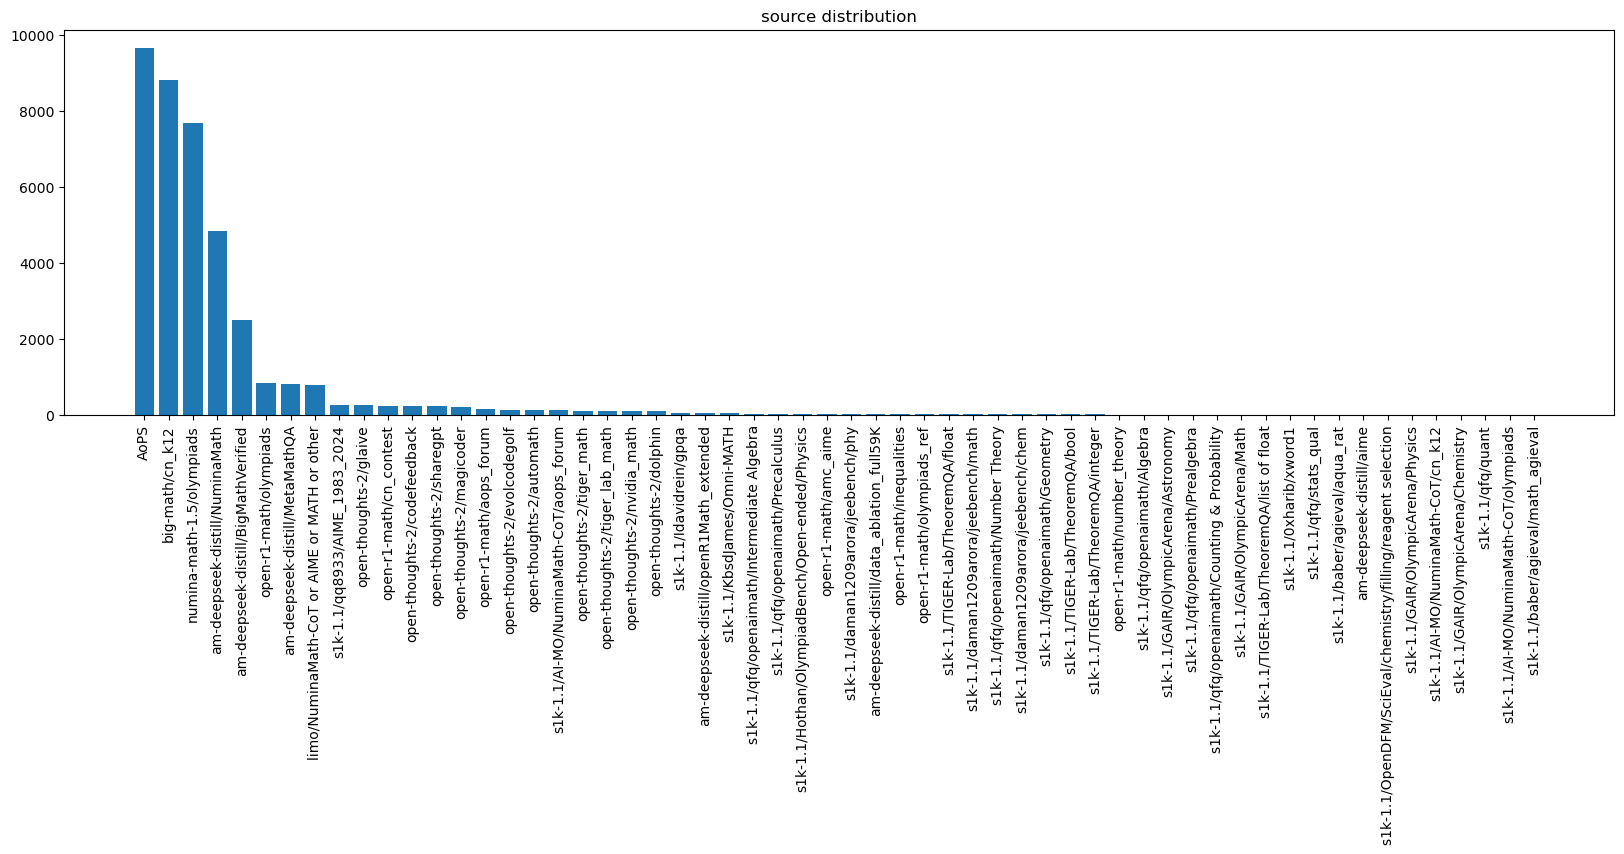

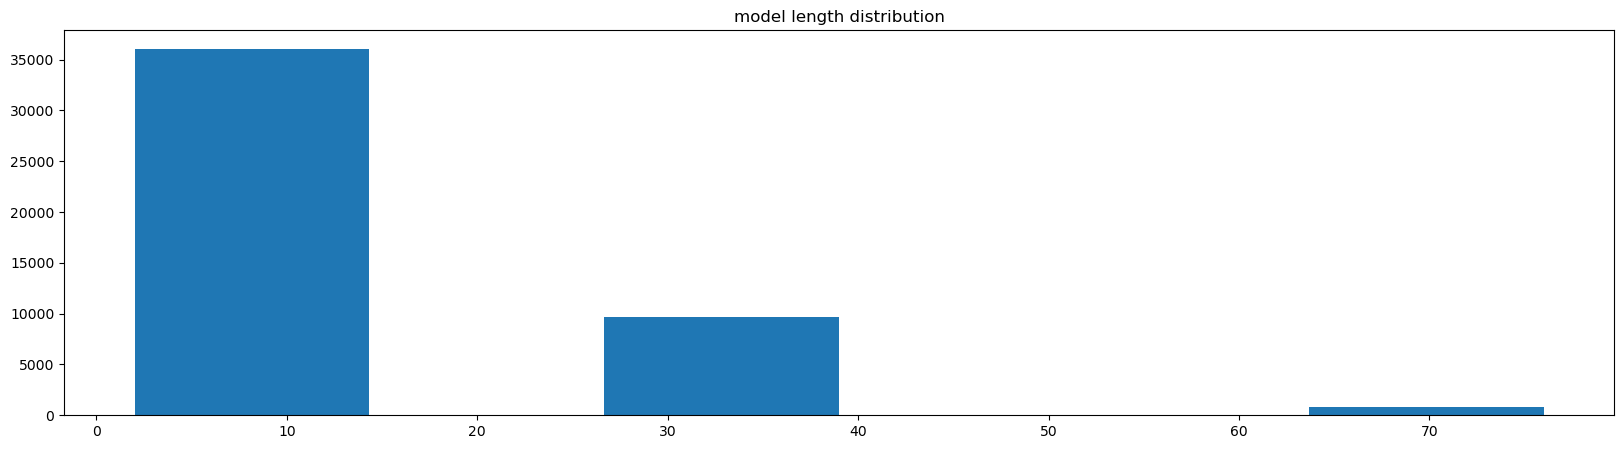

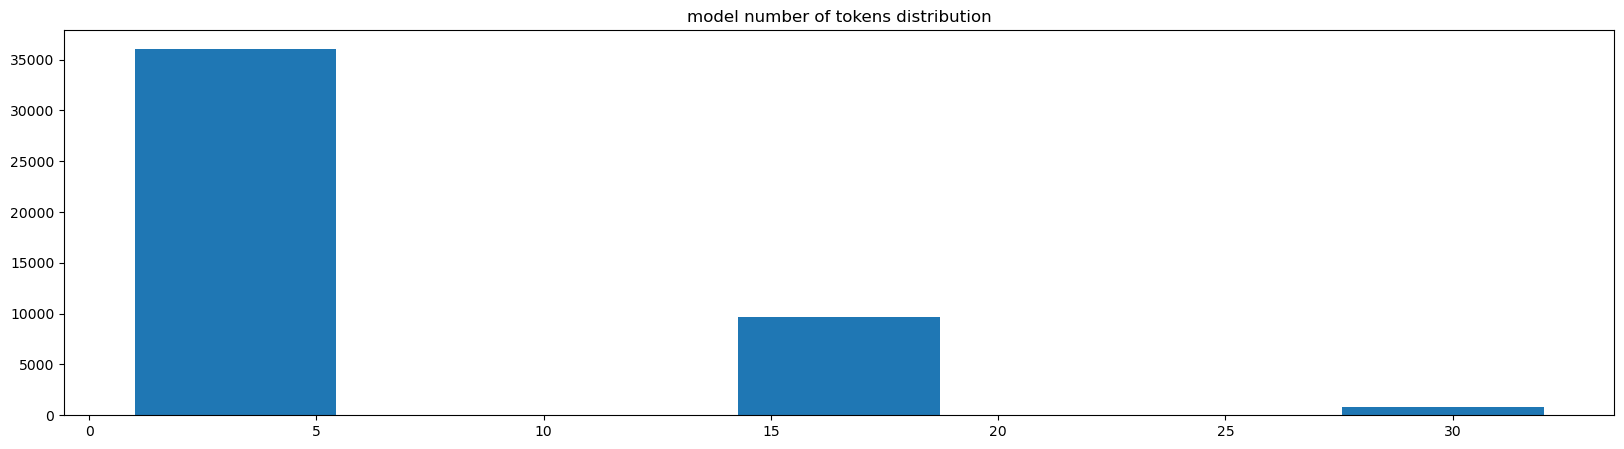

There is 7 unique model.


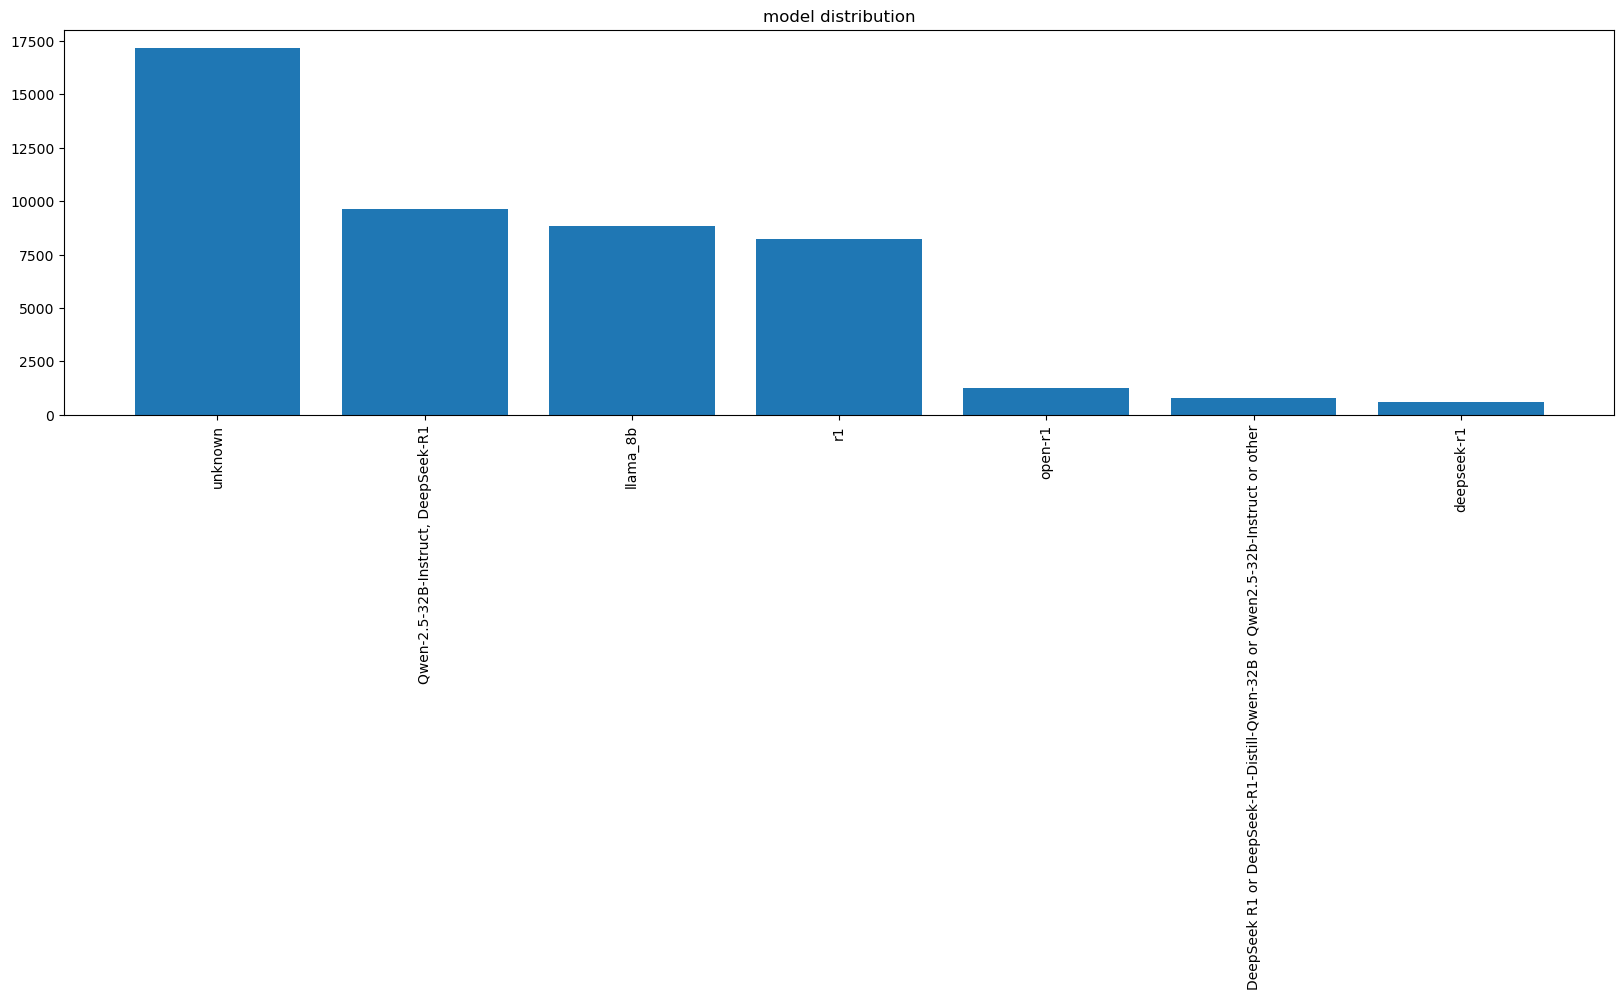

In [ ]:
cot_datasets = [
    {
        "name": "am-deepseek-distill",
        "dataset": am_deepseek_distill,
        "question": am_deepseek_distill["question"],
        "answer": am_deepseek_distill["ground_truth"],
        "solution": am_deepseek_distill["answer"],
        "source": ["am-deepseek-distill/" + source for source in am_deepseek_distill["question_source"]],
        "model": am_deepseek_distill["model_name"],
    },
    {
        "name": "big-math",
        "dataset": big_math,
        "question": big_math["problem"],
        "answer": big_math["answer"],
        "solution": [None] * len(big_math),
        "source": ["big-math/" + source for source in big_math["source"]],
        "model": [None] * len(big_math),
    },
    {
        "name": "limo",
        "dataset": limo,
        "question": limo["question"],
        "answer": limo["answer"],
        "solution": limo["solution"],
        "source": ["limo/NuminaMath-CoT or AIME or MATH or other"] * len(limo),
        "model": ["DeepSeek R1 or DeepSeek-R1-Distill-Qwen-32B or Qwen2.5-32b-Instruct or other"] * len(limo)
    },
    {
        "name": "limr",
        "dataset": limr,
        "question": limr["prompt"],
        "answer": limr["answer"],
        "solution": [None] * len(limr),
        "source": ["limr/" + source for source in limr["source"]],
        "model": [None] * len(limr)
    },
    {
        "name": "llama-nemotron",
        "dataset": llama_nemotron,
        "question": [x[0]["content"] for x in llama_nemotron["input"]],
        "answer": llama_nemotron["answer"],
        "solution": llama_nemotron["output"],
        "source": ["llama-nemotron/AoPS"] * len(llama_nemotron),
        "model": llama_nemotron["generator"],
    },
    {
        "name": "math-lvl5-fr",
        "dataset": math_lvl5_fr_train,
        "question": math_lvl5_fr_train["problem"],
        "answer": math_lvl5_fr_train["answer"],
        "solution": math_lvl5_fr_train["solution"],
        "source": ["math-lvl5-fr/math"] * len(math_lvl5_fr_train),
        "model": [None] * len(math_lvl5_fr_train),
    },
    {
        "name": "metamath-qa",
        "dataset": metamath_qa,
        "question": metamath_qa["query"],
        "answer": metamath_qa["answer"],
        "solution": metamath_qa["response"],
        "source": ["metamath-qa/" + subset for subset in metamath_qa["type"]],
        "model": ["unknown"] * len(metamath_qa),
    },
    {
        "name": "numinamath-1.5",
        "dataset": numinamath_1_5,
        "question": numinamath_1_5["problem"],
        "answer": numinamath_1_5["answer"],
        "solution": numinamath_1_5["solution"],
        "source": ["numina-math-1.5/" + source for source in numinamath_1_5["source"]],
        "model": ["unknown"] * len(numinamath_1_5),
    },
    {
        "name": "open-r1-math",
        "dataset": open_r1_math,
        "question": open_r1_math["problem"],
        "answer": open_r1_math["answer"],
        "solution": open_r1_math["generations"],
        "source": ["open-r1-math/" + source for source in open_r1_math["source"]],
        "model": ["open-r1"] * len(open_r1_math),
    },
    {
        "name": "open-thoughts-2",
        "dataset": open_thoughts_2,
        "question": [x[0]["value"] for x in open_thoughts_2["conversations"]],
        "answer": [None] * len(open_thoughts_2),
        "solution": [x[1]["value"] for x in open_thoughts_2["conversations"]],
        "source": ["open-thoughts-2/" + source if source is not None else None for source in open_thoughts_2["source"]],
        "model": ["unknown"] * len(open_thoughts_2),
    },
    {
        "name": "s1k-1.1",
        "dataset": s1k_1_1,
        "question": s1k_1_1["question"],
        "answer": s1k_1_1["solution"],
        "solution": s1k_1_1["deepseek_thinking_trajectory"],
        "source": ["s1k-1.1/" + source for source in s1k_1_1["source_type"]],
        "model": ["deepseek-r1"] * len(s1k_1_1),
    },
]

cot_dataset = fusion_datasets(cot_datasets)

print_distributions(cot_dataset, ['question', 'answer', 'solution', 'source', 'model'])

### Eval

Processing dataset: math-lvl5-fr
Features: ['problem', 'type', 'solution', 'answer']
Number of samples: 856
Sample: {
    "answer": "\\begin{pmatrix} 5/3 \\\\ 5/3 \\\\ 4/3 \\end{pmatrix}",
    "problem": "Soit $\\mathbf{a} = \\begin{pmatrix} 7 \\\\ - 1 \\\\ 4 \\end{pmatrix}$ et $\\mathbf{b} = \\begin{pmatrix} 3 \\\\ 1 \\\\ 2 \\end{pmatrix}.$ Trouver le vecteur $\\mathbf{c}$ tel que $\\mathbf{a},$ $\\mathbf{b},$ et $\\mathbf{c}$ soient collin\u00e9aires, et que $\\mathbf{b}$ bisecte l'angle entre $\\mathbf{a}$ et $\\mathbf{c}.$\n\n[asy]\nunitsize(0.5 cm);\n\npair A, B, C, O;\n\nA = (-2,5);\nB = (1,3);\nO = (0,0);\nC = extension(O, reflect(O,B)*(A), A, B);\n\ndraw(O--A,Arrow(6));\ndraw(O--B,Arrow(6));\ndraw(O--C,Arrow(6));\ndraw(interp(A,C,-0.1)--interp(A,C,1.1),dashed);\n\nlabel($\\mathbf{a}$, A, NE);\nlabel($\\mathbf{b}$, B, NE);\nlabel($\\mathbf{c}$, C, NE);\n[/asy]",
    "solution": "La ligne contenant $\\mathbf{p}$ et $\\mathbf{q}$ peut \u00eatre param\u00e9tr\u00e9e par\n\\[\\mathb

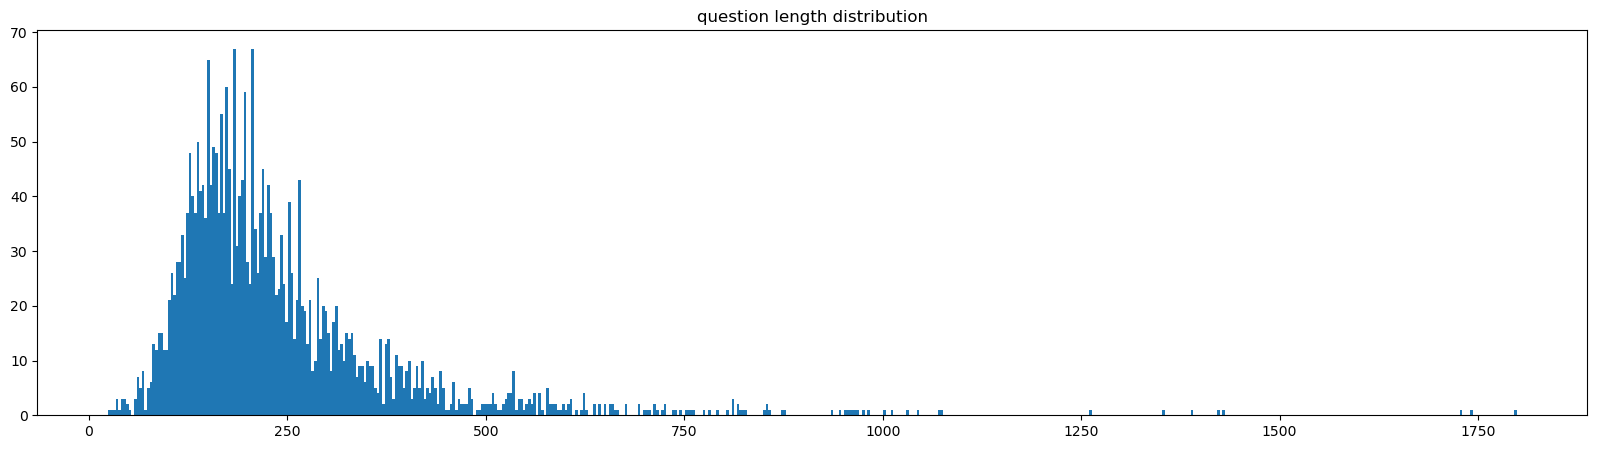

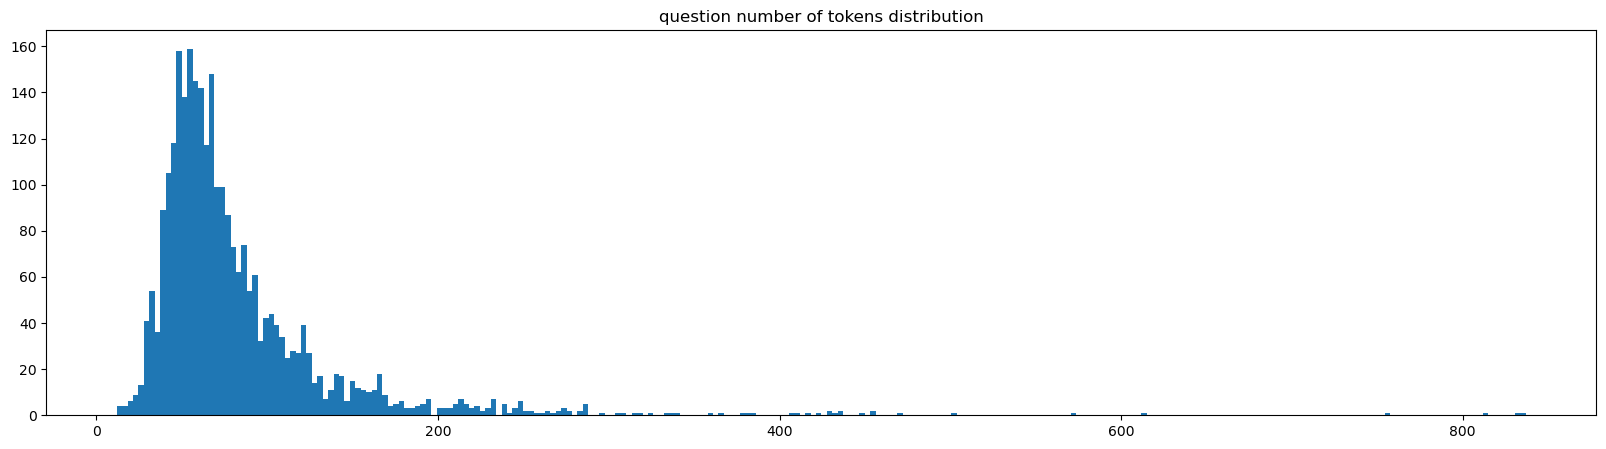

There is 2631 unique question.


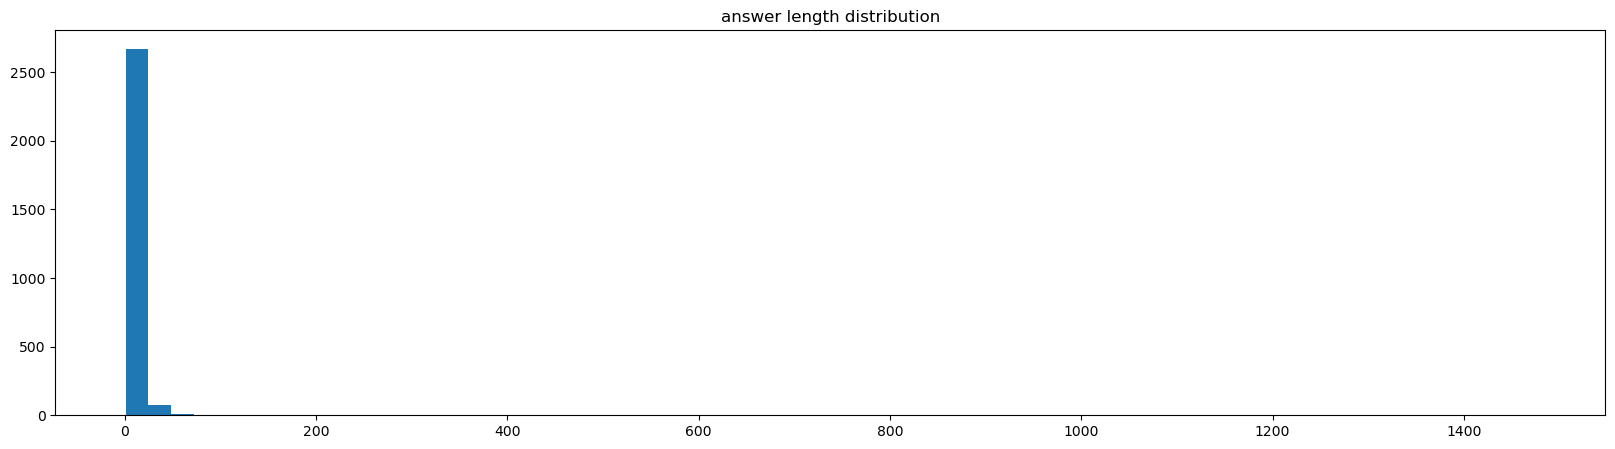

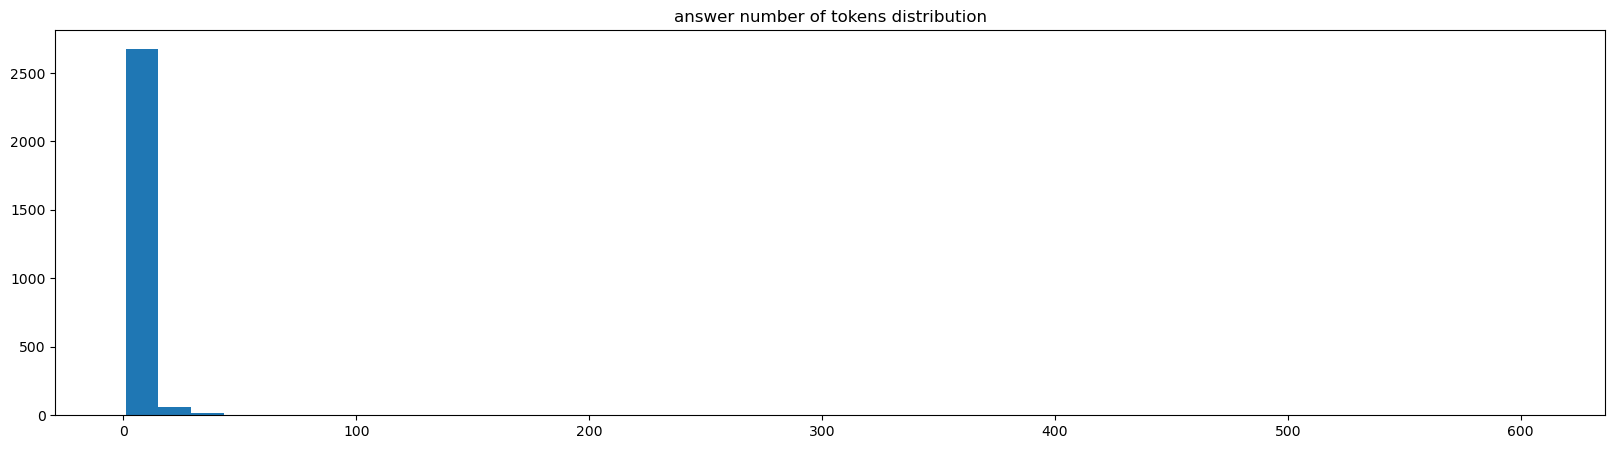

There is 1230 unique answer.


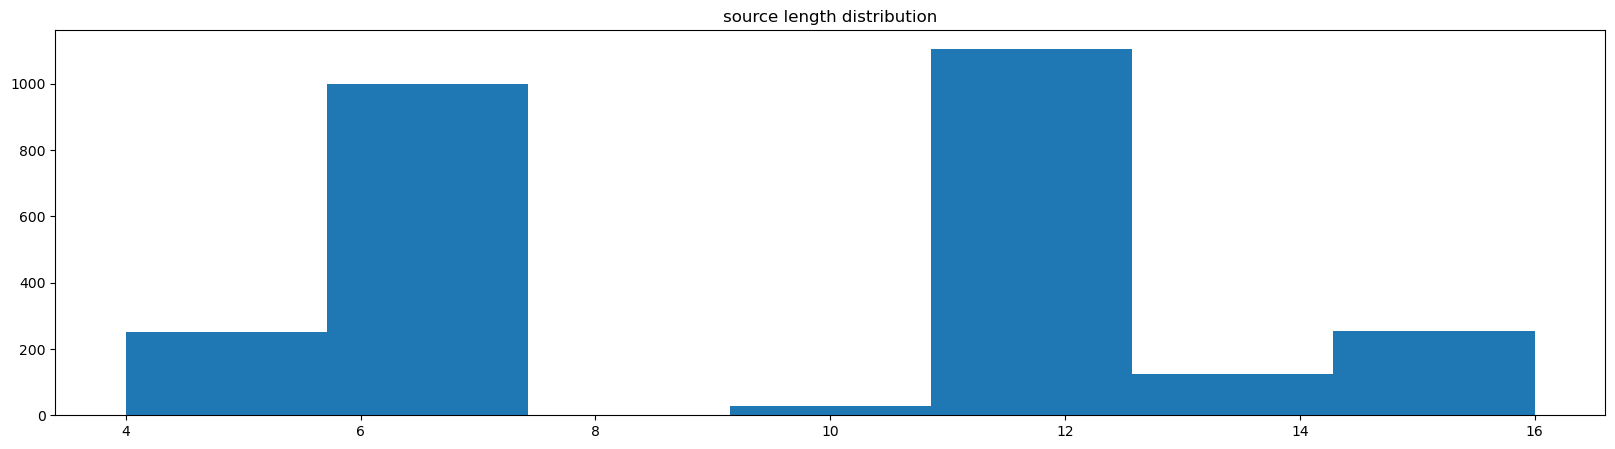

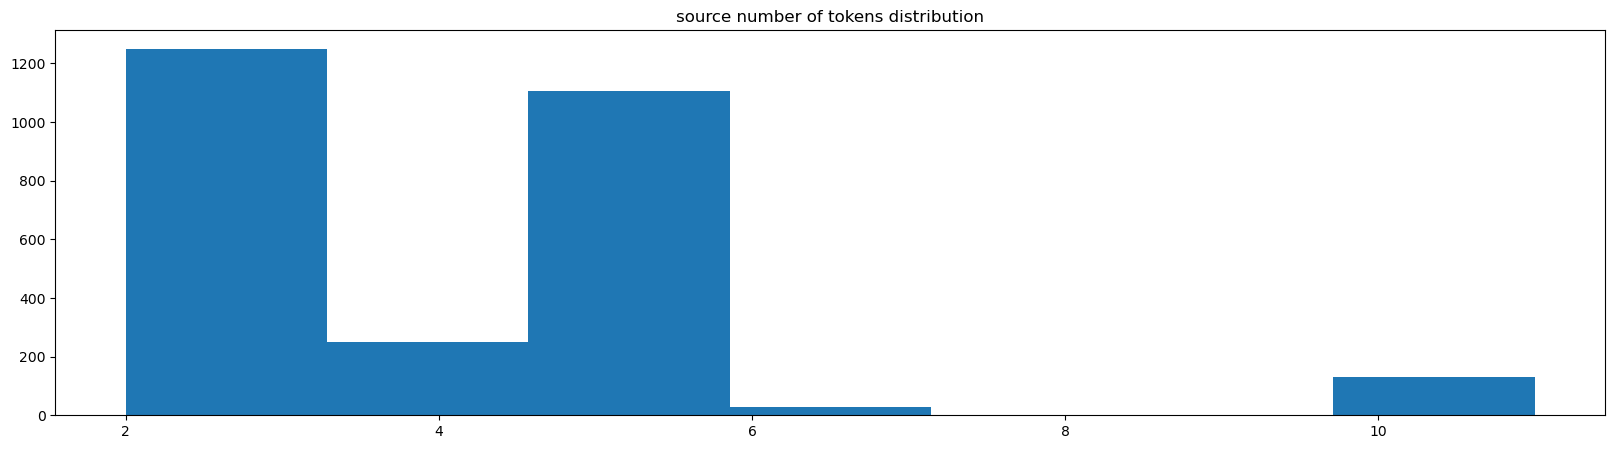

There is 10 unique source.


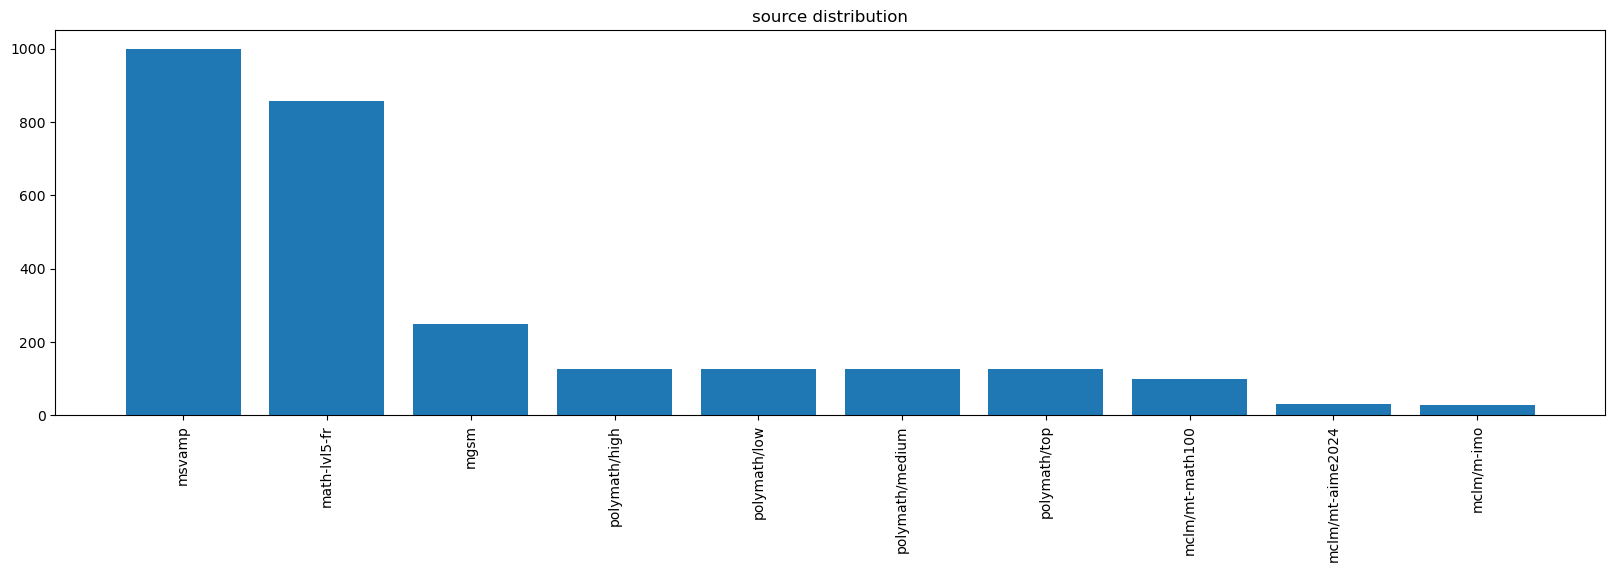

In [7]:
eval_datasets = [
    {
        "name": "math-lvl5-fr",
        "dataset": math_lvl5_fr_test,
        "question": math_lvl5_fr_test["problem"],
        "answer": math_lvl5_fr_test["answer"],
        "source": ["math-lvl5-fr"] * len(math_lvl5_fr_test),
    },
    {
        "name": "mclm",
        "dataset": mclm,
        "question": mclm["question"],
        "answer": mclm["answer"],
        "source": ["mclm/" + source for source in mclm["source"]],
    },
    {
        "name": "mgsm",
        "dataset": mgsm,
        "question": mgsm["question"],
        "answer": mgsm["answer"],
        "source": ["mgsm"] * len(mgsm),
    },
    {
        "name": "msvamp",
        "dataset": msvamp,
        "question": msvamp["m_query"],
        "answer": msvamp["response"],
        "source": ["msvamp"] * len(msvamp),
    },
    {
        "name": "polymath",
        "dataset": polymath,
        "question": polymath["question"],
        "answer": polymath["answer"],
        "source": ["polymath/" + (identifier).split("-")[0] for identifier in polymath["id"]],
    }
]

eval_dataset = fusion_datasets(eval_datasets)

print_distributions(eval_dataset, ['question', 'answer', 'source'])